In [ ]:
# Install required tools
!pip install -q awscli
!apt-get install -y -q sra-toolkit
!pip install nanostat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 100.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  blends-common libkdf5-2 libncbi-vdb2 libncbi-wvdb2 med-config menu
Suggested packages:
  blends-doc menu-l10n gksu | kde-runtime | ktsuss
The following NEW packages will be installed:
  blends-common libkdf5-2 libncbi-vdb2 libncbi-wvdb2 med-config menu
  sra-toolkit
0 upgraded

# **Phase 1: Data Acquisition & Quality Control**

GBM Nanopore RNA-seq dataset - PRJNA1189527


read data and clean

In [ ]:
!apt-get install -y ncbi-entrez-direct 2>/dev/null

# Fetch all run info from the GBM study
!esearch -db sra -query "SRP547032" | efetch -format runinfo > study_runinfo.csv

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libauthen-sasl-perl libclone-perl libdata-dump-perl libencode-locale-perl
  libfile-listing-perl libfont-afm-perl libhtml-form-perl libhtml-format-perl
  libhtml-parser-perl libhtml-tagset-perl libhtml-tree-perl
  libhttp-cookies-perl libhttp-daemon-perl libhttp-date-perl
  libhttp-message-perl libhttp-negotiate-perl libio-html-perl
  libio-socket-ssl-perl liblwp-mediatypes-perl liblwp-protocol-https-perl
  libmailtools-perl libnet-http-perl libnet-smtp-ssl-perl libnet-ssleay-perl
  libtry-tiny-perl liburi-perl libwww-perl libwww-robotrules-perl
  libxml-libxml-perl libxml-namespacesupport-perl libxml-parser-perl
  libxml-sax-base-perl libxml-sax-expat-perl libxml-sax-perl
  libxml-simple-perl netbase perl-openssl-defaults
Suggested packages:
  libdigest-hmac-perl libgssapi-perl libcrypt-ssleay-perl libsub-name-perl
  libbusiness-isbn-p

In [ ]:
# Check what columns actually exist in the runinfo file
import pandas as pd
runinfo = pd.read_csv("study_runinfo.csv")

# See all available column names first
print(runinfo.columns.tolist())

['Run', 'ReleaseDate', 'LoadDate', 'spots', 'bases', 'spots_with_mates', 'avgLength', 'size_MB', 'AssemblyName', 'download_path', 'Experiment', 'LibraryName', 'LibraryStrategy', 'LibrarySelection', 'LibrarySource', 'LibraryLayout', 'InsertSize', 'InsertDev', 'Platform', 'Model', 'SRAStudy', 'BioProject', 'Study_Pubmed_id', 'ProjectID', 'Sample', 'BioSample', 'SampleType', 'TaxID', 'ScientificName', 'SampleName', 'g1k_pop_code', 'source', 'g1k_analysis_group', 'Subject_ID', 'Sex', 'Disease', 'Tumor', 'Affection_Status', 'Analyte_Type', 'Histological_Type', 'Body_Site', 'CenterName', 'Submission', 'dbgap_study_accession', 'Consent', 'RunHash', 'ReadHash']


In [ ]:
# Print the relevant columns using the correct names
print(runinfo[['Run', 'SampleName', 'bases', 'size_MB', 'Platform', 'Model', 'LibrarySelection', 'Disease']].to_string())

            Run  SampleName      bases  size_MB         Platform   Model LibrarySelection  Disease
0   SRR31451042  GSM8648003  108307809       98  OXFORD_NANOPORE  MinION             cDNA      NaN
1   SRR31451041  GSM8648004   50679162       46  OXFORD_NANOPORE  MinION             cDNA      NaN
2   SRR31451040  GSM8648005  139651236      126  OXFORD_NANOPORE  MinION             cDNA      NaN
3   SRR31451039  GSM8648006  124480881      113  OXFORD_NANOPORE  MinION             cDNA      NaN
4   SRR31451037  GSM8648007  107468983       96  OXFORD_NANOPORE  MinION             cDNA      NaN
5   SRR31451036  GSM8648008  119095205      108  OXFORD_NANOPORE  MinION             cDNA      NaN
6   SRR31451035  GSM8648009   82818782       74  OXFORD_NANOPORE  MinION             cDNA      NaN
7   SRR31451038  GSM8648010   79099153       71  OXFORD_NANOPORE  MinION             cDNA      NaN
8   SRR31451034  GSM8648011  112188310      100  OXFORD_NANOPORE  MinION             cDNA      NaN
9   SRR314

In [ ]:
# Summary stats
print("Total samples:", len(runinfo))
print("\nPlatforms used:")
print(runinfo['Platform'].value_counts())
print("\nSample names:")
print(runinfo['SampleName'].tolist())
print("\nTotal size (MB):", runinfo['size_MB'].sum())

Total samples: 26

Platforms used:
Platform
OXFORD_NANOPORE    26
Name: count, dtype: int64

Sample names:
['GSM8648003', 'GSM8648004', 'GSM8648005', 'GSM8648006', 'GSM8648007', 'GSM8648008', 'GSM8648009', 'GSM8648010', 'GSM8648011', 'GSM8648012', 'GSM8648013', 'GSM8648014', 'GSM8648015', 'GSM8648016', 'GSM8648017', 'GSM8648018', 'GSM8648019', 'GSM8648020', 'GSM8648021', 'GSM8648022', 'GSM8648023', 'GSM8648024', 'GSM8648025', 'GSM8648026', 'GSM8648027', 'GSM8648028']

Total size (MB): 3036


In [ ]:
# Get all run IDs from the table
run_ids = runinfo['Run'].tolist()
print("Runs to download:", run_ids)
print("Total:", len(run_ids))

Runs to download: ['SRR31451042', 'SRR31451041', 'SRR31451040', 'SRR31451039', 'SRR31451037', 'SRR31451036', 'SRR31451035', 'SRR31451038', 'SRR31451034', 'SRR31451033', 'SRR31451032', 'SRR31451031', 'SRR31451029', 'SRR31451028', 'SRR31451027', 'SRR31451030', 'SRR31451026', 'SRR31451025', 'SRR31451024', 'SRR31451023', 'SRR31451021', 'SRR31451020', 'SRR31451019', 'SRR31451022', 'SRR31451018', 'SRR31451017']
Total: 26


In [ ]:
import os
os.makedirs("/content/gbm_nanopore/raw", exist_ok=True)

# Download all 26 samples
for run in run_ids:
    print(f"Downloading {run}...")
    !fastq-dump --gzip --outdir /content/gbm_nanopore/raw {run}
    print(f"Done: {run}")

print("All downloads complete")

Read 152008 spots for SRR31451042
Written 152008 spots for SRR31451042
Done: SRR31451042
Read 79338 spots for SRR31451041
Written 79338 spots for SRR31451041
Done: SRR31451041
Read 184787 spots for SRR31451040
Written 184787 spots for SRR31451040
Done: SRR31451040
Read 186271 spots for SRR31451039
Written 186271 spots for SRR31451039
Done: SRR31451039
Read 142086 spots for SRR31451037
Written 142086 spots for SRR31451037
Done: SRR31451037
Read 187461 spots for SRR31451036
Written 187461 spots for SRR31451036
Done: SRR31451036
Read 103132 spots for SRR31451035
Written 103132 spots for SRR31451035
Done: SRR31451035
Read 112742 spots for SRR31451038
Written 112742 spots for SRR31451038
Done: SRR31451038
Read 152807 spots for SRR31451034
Written 152807 spots for SRR31451034
Done: SRR31451034
Read 126051 spots for SRR31451033
Written 126051 spots for SRR31451033
Done: SRR31451033
Read 150449 spots for SRR31451032
Written 150449 spots for SRR31451032
Done: SRR31451032
Read 131384 spots for S

analyze data - checking average length per sample to see if it would be feasible to consider long read






In [ ]:
# Check average read length per sample
print(runinfo[['Run', 'SampleName', 'avgLength', 'bases', 'size_MB']].to_string())

            Run  SampleName  avgLength      bases  size_MB
0   SRR31451042  GSM8648003        712  108307809       98
1   SRR31451041  GSM8648004        638   50679162       46
2   SRR31451040  GSM8648005        755  139651236      126
3   SRR31451039  GSM8648006        668  124480881      113
4   SRR31451037  GSM8648007        756  107468983       96
5   SRR31451036  GSM8648008        635  119095205      108
6   SRR31451035  GSM8648009        803   82818782       74
7   SRR31451038  GSM8648010        701   79099153       71
8   SRR31451034  GSM8648011        734  112188310      100
9   SRR31451033  GSM8648012        560   70687657       65
10  SRR31451032  GSM8648013        616   92733864       85
11  SRR31451031  GSM8648014        749   98534397       89
12  SRR31451029  GSM8648015        980  182663234      163
13  SRR31451028  GSM8648016        951  123238712      110
14  SRR31451027  GSM8648017        475  117275150      110
15  SRR31451030  GSM8648018        767  116770774      1

In [ ]:
# Check all files downloaded correctly
import os

files = os.listdir("/content/gbm_nanopore/raw/")
print(f"Number of files downloaded: {len(files)}")
print("\nFiles and sizes:")
!ls -lh /content/gbm_nanopore/raw/

Number of files downloaded: 26

Files and sizes:
total 3.5G
-rw-r--r-- 1 root root 265M Apr  4 12:08 SRR31451017.fastq.gz
-rw-r--r-- 1 root root  96M Apr  4 12:05 SRR31451018.fastq.gz
-rw-r--r-- 1 root root 115M Apr  4 12:04 SRR31451019.fastq.gz
-rw-r--r-- 1 root root 283M Apr  4 12:02 SRR31451020.fastq.gz
-rw-r--r-- 1 root root  87M Apr  4 11:59 SRR31451021.fastq.gz
-rw-r--r-- 1 root root  90M Apr  4 12:05 SRR31451022.fastq.gz
-rw-r--r-- 1 root root  88M Apr  4 11:59 SRR31451023.fastq.gz
-rw-r--r-- 1 root root 250M Apr  4 11:58 SRR31451024.fastq.gz
-rw-r--r-- 1 root root 416M Apr  4 11:55 SRR31451025.fastq.gz
-rw-r--r-- 1 root root  46M Apr  4 11:52 SRR31451026.fastq.gz
-rw-r--r-- 1 root root 128M Apr  4 11:50 SRR31451027.fastq.gz
-rw-r--r-- 1 root root 130M Apr  4 11:49 SRR31451028.fastq.gz
-rw-r--r-- 1 root root 192M Apr  4 11:47 SRR31451029.fastq.gz
-rw-r--r-- 1 root root 123M Apr  4 11:51 SRR31451030.fastq.gz
-rw-r--r-- 1 root root 105M Apr  4 11:46 SRR31451031.fastq.gz
-rw-r--r--

qc control - get qc scores of each sample



In [ ]:
# Install NanoStat
!pip install nanostat -q

# Create output folder for QC reports
import os
os.makedirs("/content/gbm_nanopore/qc", exist_ok=True)

In [ ]:
# Run NanoStat on all 26 samples
# This generates a QC report for each patient

raw_dir = "/content/gbm_nanopore/raw/"
qc_dir = "/content/gbm_nanopore/qc/"

files = sorted(os.listdir(raw_dir))

for f in files:
    sample = f.replace(".fastq.gz", "")
    print(f"Running QC on {sample}...")
    !NanoStat --fastq {raw_dir}{f} --outdir {qc_dir} --name {sample}_QC.txt
    print(f"✓ Done: {sample}")

print("\nAll QC reports complete")

Running QC on SRR31451017...
✓ Done: SRR31451017
Running QC on SRR31451018...
✓ Done: SRR31451018
Running QC on SRR31451019...
✓ Done: SRR31451019
Running QC on SRR31451020...
✓ Done: SRR31451020
Running QC on SRR31451021...
✓ Done: SRR31451021
Running QC on SRR31451022...
✓ Done: SRR31451022
Running QC on SRR31451023...
✓ Done: SRR31451023
Running QC on SRR31451024...
✓ Done: SRR31451024
Running QC on SRR31451025...
✓ Done: SRR31451025
Running QC on SRR31451026...
✓ Done: SRR31451026
Running QC on SRR31451027...
✓ Done: SRR31451027
Running QC on SRR31451028...
✓ Done: SRR31451028
Running QC on SRR31451029...
✓ Done: SRR31451029
Running QC on SRR31451030...
✓ Done: SRR31451030
Running QC on SRR31451031...
✓ Done: SRR31451031
Running QC on SRR31451032...
✓ Done: SRR31451032
Running QC on SRR31451033...
✓ Done: SRR31451033
Running QC on SRR31451034...
✓ Done: SRR31451034
Running QC on SRR31451035...
✓ Done: SRR31451035
Running QC on SRR31451036...
✓ Done: SRR31451036
Running QC on SRR314

In [ ]:
# Preview QC report for Patient-1 (SRR31451033)
with open("/content/gbm_nanopore/qc/SRR31451033_QC.txt") as f:
    print(f.read())

General summary:         
Mean read length:                 560.8
Mean read quality:                  8.0
Median read length:               463.0
Median read quality:                8.7
Number of reads:              126,051.0
Read length N50:                  670.0
STDEV read length:                373.2
Total bases:               70,687,657.0
Number, percentage and megabases of reads above quality cutoffs
>Q10:	21748 (17.3%) 13.8Mb
>Q15:	1 (0.0%) 0.0Mb
>Q20:	0 (0.0%) 0.0Mb
>Q25:	0 (0.0%) 0.0Mb
>Q30:	0 (0.0%) 0.0Mb
Top 5 highest mean basecall quality scores and their read lengths
1:	15.1 (123)
2:	14.0 (95)
3:	13.9 (501)
4:	13.9 (148)
5:	13.8 (152)
Top 5 longest reads and their mean basecall quality score
1:	5593 (8.4)
2:	5336 (9.3)
3:	5115 (10.0)
4:	5083 (9.0)
5:	5013 (10.2)



connection error - had to rebuild it

In [ ]:
# Rebuild the QC summary table from the saved files
import pandas as pd
import re
import os

qc_dir = "/content/gbm_nanopore/qc/"
summary = []

for fname in sorted(os.listdir(qc_dir)):
    if not fname.endswith("_QC.txt"):
        continue
    sample = fname.replace("_QC.txt", "")
    with open(qc_dir + fname) as f:
        content = f.read()

    def extract(pattern):
        match = re.search(pattern, content)
        return match.group(1) if match else "N/A"

    summary.append({
        "Sample": sample,
        "Mean_Length": extract(r"Mean read length:\s+([\d,\.]+)"),
        "Mean_Quality": extract(r"Mean read quality:\s+([\d,\.]+)"),
        "Total_Reads": extract(r"Number of reads:\s+([\d,]+)"),
        "N50": extract(r"Read length N50:\s+([\d,]+)"),
        "Pct_Q10": extract(r">Q10:\s+\d+ \(([\d\.]+)%\)"),
    })

df_qc = pd.DataFrame(summary)
print(df_qc.to_string())

         Sample Mean_Length Mean_Quality Total_Reads    N50 Pct_Q10
0   SRR31451017     1,028.5          8.4     245,101  1,321    17.4
1   SRR31451018       578.4          7.9     153,557    683    11.4
2   SRR31451019       723.9          7.9     149,506    855    10.7
3   SRR31451020       709.6          8.0     375,225    849    12.3
4   SRR31451021       577.9          7.9     139,658    692    11.7
5   SRR31451022       612.4          7.8     136,325    715    10.5
6   SRR31451023       533.1          7.8     152,429    629    10.5
7   SRR31451024       801.5          8.4     293,754    981    18.6
8   SRR31451025       966.4          8.4     409,039  1,261    17.6
9   SRR31451026       508.9          7.8      83,378    587    11.5
10  SRR31451027       475.7          7.8     246,532    541    10.8
11  SRR31451028       951.9          8.3     129,462  1,199    18.8
12  SRR31451029       980.3          8.3     186,325  1,264    15.1
13  SRR31451030       767.6          7.7     152

stats seem good so far - moved on to filtering using the standard threshold for our dataset rna002 kit

In [ ]:
# Install NanoFilt
!pip install nanofilt -q

import os
os.makedirs("/content/gbm_nanopore/filtered", exist_ok=True)

  Preparing metadata (setup.py) ... done


In [ ]:
# Filter all samples
# Keeping reads: quality >= 7, minimum length 200 bases
# These thresholds are standard for RNA002 Nanopore chemistry

raw_dir = "/content/gbm_nanopore/raw/"
filt_dir = "/content/gbm_nanopore/filtered/"

files = sorted(os.listdir(raw_dir))

for f in files:
    sample = f.replace(".fastq.gz", "")
    print(f"Filtering {sample}...")
    !zcat {raw_dir}{f} | NanoFilt -q 7 -l 200 | gzip > {filt_dir}{sample}_filtered.fastq.gz
    print(f"✓ Done: {sample}")

print("\nAll samples filtered")

Filtering SRR31451017...
✓ Done: SRR31451017
Filtering SRR31451018...
✓ Done: SRR31451018
Filtering SRR31451019...
✓ Done: SRR31451019
Filtering SRR31451020...
✓ Done: SRR31451020
Filtering SRR31451021...
✓ Done: SRR31451021
Filtering SRR31451022...
✓ Done: SRR31451022
Filtering SRR31451023...
✓ Done: SRR31451023
Filtering SRR31451024...
✓ Done: SRR31451024
Filtering SRR31451025...
✓ Done: SRR31451025
Filtering SRR31451026...
✓ Done: SRR31451026
Filtering SRR31451027...
✓ Done: SRR31451027
Filtering SRR31451028...
✓ Done: SRR31451028
Filtering SRR31451029...
✓ Done: SRR31451029
Filtering SRR31451030...
✓ Done: SRR31451030
Filtering SRR31451031...
✓ Done: SRR31451031
Filtering SRR31451032...
✓ Done: SRR31451032
Filtering SRR31451033...
✓ Done: SRR31451033
Filtering SRR31451034...
✓ Done: SRR31451034
Filtering SRR31451035...
✓ Done: SRR31451035
Filtering SRR31451036...
✓ Done: SRR31451036
Filtering SRR31451037...
✓ Done: SRR31451037
Filtering SRR31451038...
✓ Done: SRR31451038
Filtering 

In [ ]:
# Check how many reads survived filtering per sample
import subprocess

filt_dir = "/content/gbm_nanopore/filtered/"

print(f"{'Sample':<20} {'Filtered_Reads':<20} {'File_Size':<15}")
print("-" * 55)

for f in sorted(os.listdir(filt_dir)):
    if not f.endswith(".fastq.gz"):
        continue
    sample = f.replace("_filtered.fastq.gz", "")
    filepath = filt_dir + f

    # Count reads (each read = 4 lines in fastq)
    result = subprocess.run(
        f"zcat {filepath} | wc -l",
        shell=True, capture_output=True, text=True
    )
    lines = int(result.stdout.strip())
    reads = lines // 4

    # File size
    size_mb = os.path.getsize(filepath) / 1e6

    print(f"{sample:<20} {reads:<20,} {size_mb:<15.1f} MB")

Sample               Filtered_Reads       File_Size      
-------------------------------------------------------
SRR31451017          242,348              274.8           MB
SRR31451018          128,754              89.0            MB
SRR31451019          132,057              110.3           MB
SRR31451020          332,308              273.4           MB
SRR31451021          116,339              81.4            MB
SRR31451022          116,437              84.1            MB
SRR31451023          123,180              80.1            MB
SRR31451024          286,747              257.9           MB
SRR31451025          402,080              431.1           MB
SRR31451026          67,847               42.3            MB
SRR31451027          198,207              116.1           MB
SRR31451028          119,025              128.6           MB
SRR31451029          183,591              199.2           MB
SRR31451030          149,926              127.1           MB
SRR31451031          117,349    

In [ ]:
# Reprint the filtered read counts table
import os
import subprocess

filt_dir = "/content/gbm_nanopore/filtered/"

print(f"{'Sample':<25} {'Filtered_Reads':<20} {'File_Size_MB':<15}")
print("-" * 60)

for f in sorted(os.listdir(filt_dir)):
    if not f.endswith(".fastq.gz"):
        continue
    sample = f.replace("_filtered.fastq.gz", "")
    filepath = filt_dir + f

    result = subprocess.run(
        f"zcat {filepath} | wc -l",
        shell=True, capture_output=True, text=True
    )
    lines = int(result.stdout.strip())
    reads = lines // 4
    size_mb = os.path.getsize(filepath) / 1e6

    print(f"{sample:<25} {reads:<20,} {size_mb:<15.1f}")

Sample                    Filtered_Reads       File_Size_MB   
------------------------------------------------------------
SRR31451017               242,348              274.8          
SRR31451018               128,754              89.0           
SRR31451019               132,057              110.3          
SRR31451020               332,308              273.4          
SRR31451021               116,339              81.4           
SRR31451022               116,437              84.1           
SRR31451023               123,180              80.1           
SRR31451024               286,747              257.9          
SRR31451025               402,080              431.1          
SRR31451026               67,847               42.3           
SRR31451027               198,207              116.1          
SRR31451028               119,025              128.6          
SRR31451029               183,591              199.2          
SRR31451030               149,926              127.1     

all samples passed the thresholds and can be used for assembly

#visuals

In [ ]:
# Install visualisation libraries
!pip install matplotlib seaborn pandas -q

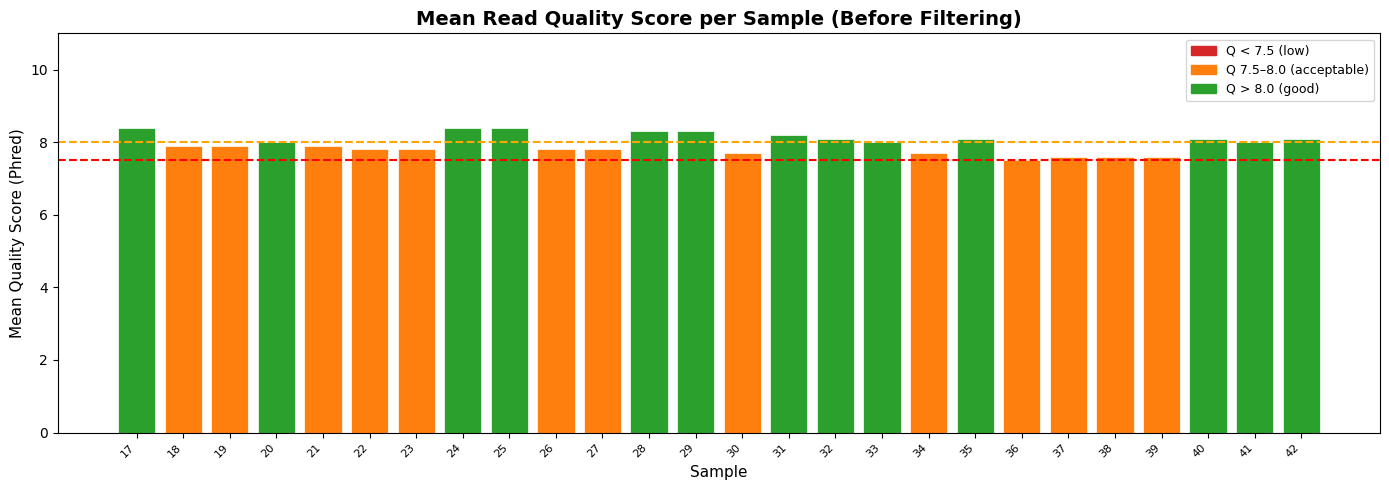

Figure 1 saved


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import os
import subprocess

# Ensure df_qc numeric columns are correctly typed
df_qc_processed = df_qc.copy()
for col in ['Mean_Length', 'Mean_Quality', 'Total_Reads', 'N50', 'Pct_Q10']:
    # Remove commas and convert to numeric, handling potential errors
    df_qc_processed[col] = df_qc_processed[col].str.replace(',', '', regex=False).astype(float)

# Re-create filtered read counts dataframe
filt_dir = "/content/gbm_nanopore/filtered/"
filtered_data = []

for f in sorted(os.listdir(filt_dir)):
    if not f.endswith(".fastq.gz"):
        continue
    sample = f.replace("_filtered.fastq.gz", "")
    filepath = filt_dir + f

    result = subprocess.run(
        f"zcat {filepath} | wc -l",
        shell=True, capture_output=True, text=True
    )
    lines = int(result.stdout.strip())
    reads = lines // 4
    # size_mb = os.path.getsize(filepath) / 1e6 # Not directly used in plotting cells, but good to have

    filtered_data.append({"Sample": sample, "Filtered_Reads": reads})

df_filtered_counts = pd.DataFrame(filtered_data)

# Merge df_qc with filtered counts
df_merged = pd.merge(df_qc_processed, df_filtered_counts, on="Sample", how="left")

# Calculate additional required columns
df_merged["Sample_Short"] = df_merged["Sample"].apply(lambda x: x.replace("SRR314510", ""))

df_merged["Pct_Kept"] = (df_merged["Filtered_Reads"] / df_merged["Total_Reads"]) * 100

# ── Figure 1: Mean Quality Score per sample (before filtering) ───────────────
fig, ax = plt.subplots(figsize=(14, 5))

colors = ["#d62728" if q < 7.5 else "#ff7f0e" if q < 8.0 else "#2ca02c"
          for q in df_merged["Mean_Quality"]]

bars = ax.bar(df_merged["Sample_Short"], df_merged["Mean_Quality"],
              color=colors, edgecolor="white", linewidth=0.5)

ax.axhline(y=7.5, color="red", linestyle="--", linewidth=1.5, label="Q7.5 threshold")
ax.axhline(y=8.0, color="orange", linestyle="--", linewidth=1.5, label="Q8.0 reference")

ax.set_title("Mean Read Quality Score per Sample (Before Filtering)", fontsize=14, fontweight="bold")
ax.set_xlabel("Sample", fontsize=11)
ax.set_ylabel("Mean Quality Score (Phred)", fontsize=11)
ax.set_ylim(0, 11)
plt.xticks(rotation=45, ha="right", fontsize=8)

red_patch = mpatches.Patch(color="#d62728", label="Q < 7.5 (low)")
orange_patch = mpatches.Patch(color="#ff7f0e", label="Q 7.5–8.0 (acceptable)")
green_patch = mpatches.Patch(color="#2ca02c", label="Q > 8.0 (good)")
ax.legend(handles=[red_patch, orange_patch, green_patch], fontsize=9)

plt.tight_layout()
plt.savefig("/content/gbm_nanopore/fig1_quality_scores.png", dpi=150)
plt.show()
print("Figure 1 saved")

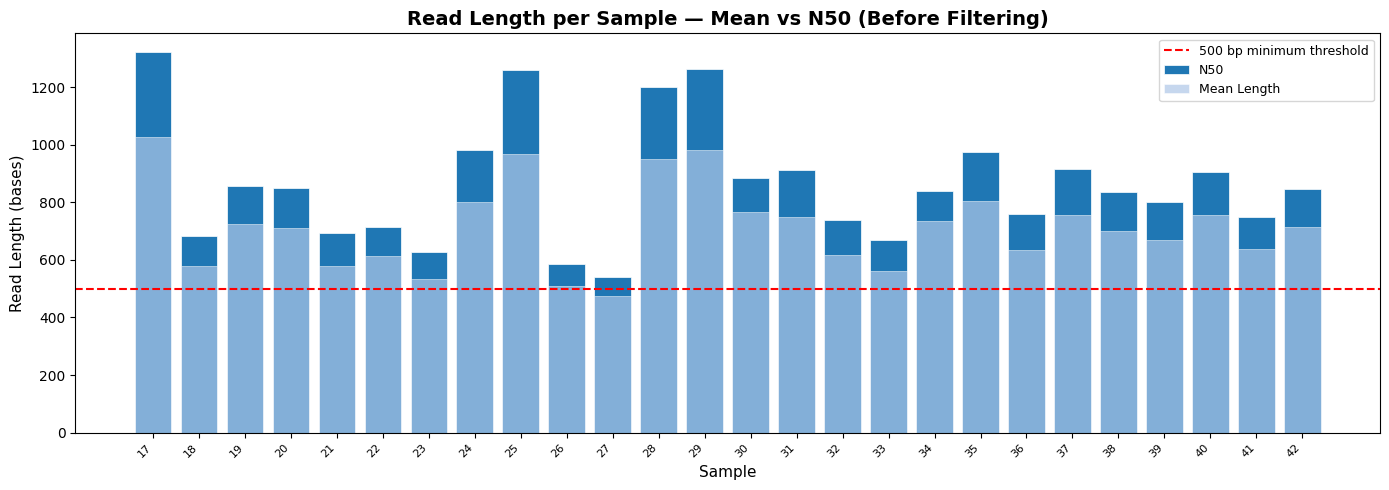

Figure 2 saved


In [ ]:
# ── Figure 2: Read Length Distribution (N50 per sample) ──────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(df_merged["Sample_Short"], df_merged["N50"],
       color="#1f77b4", edgecolor="white", linewidth=0.5, label="N50")
ax.bar(df_merged["Sample_Short"], df_merged["Mean_Length"],
       color="#aec7e8", edgecolor="white", linewidth=0.5, alpha=0.7, label="Mean Length")

ax.axhline(y=500, color="red", linestyle="--", linewidth=1.5, label="500 bp minimum threshold")

ax.set_title("Read Length per Sample — Mean vs N50 (Before Filtering)", fontsize=14, fontweight="bold")
ax.set_xlabel("Sample", fontsize=11)
ax.set_ylabel("Read Length (bases)", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=8)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("/content/gbm_nanopore/fig2_read_lengths.png", dpi=150)
plt.show()
print("Figure 2 saved")

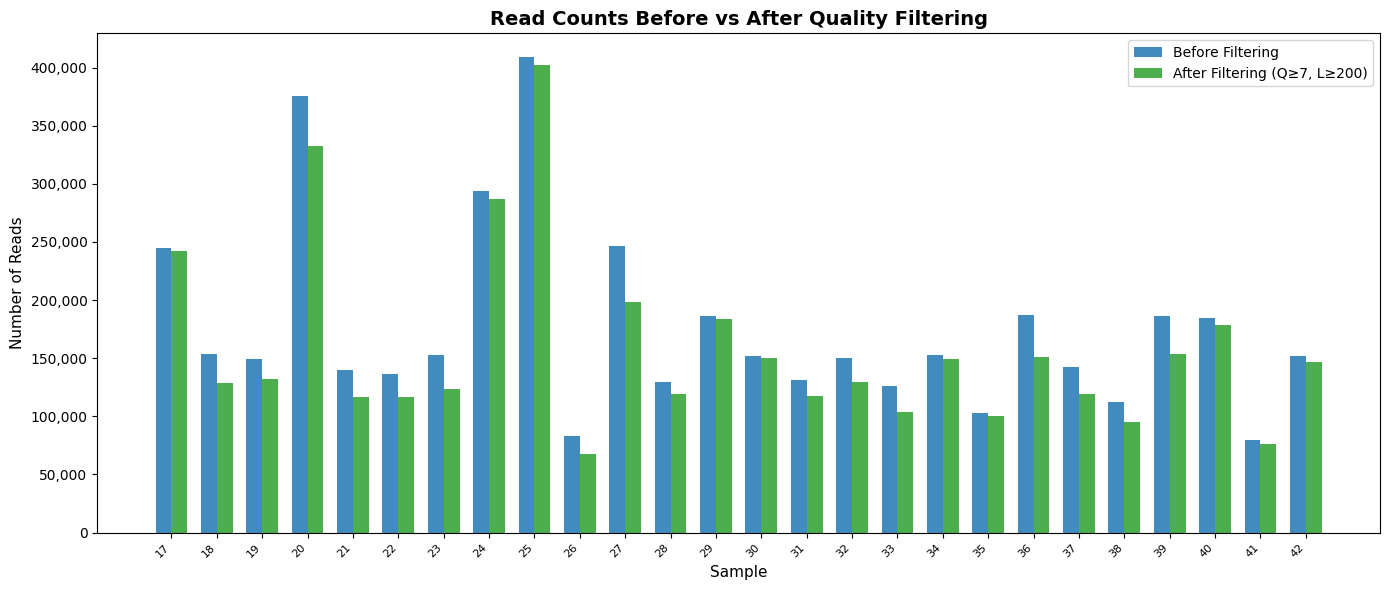

Figure 3 saved


In [ ]:
# ── Figure 3: Before vs After Filtering — Read Counts ────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(df_merged))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], df_merged["Total_Reads"],
               width, label="Before Filtering", color="#1f77b4", alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], df_merged["Filtered_Reads"],
               width, label="After Filtering (Q≥7, L≥200)", color="#2ca02c", alpha=0.85)

ax.set_title("Read Counts Before vs After Quality Filtering", fontsize=14, fontweight="bold")
ax.set_xlabel("Sample", fontsize=11)
ax.set_ylabel("Number of Reads", fontsize=11)
ax.set_xticks(list(x))
ax.set_xticklabels(df_merged["Sample_Short"], rotation=45, ha="right", fontsize=8)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))

plt.tight_layout()
plt.savefig("/content/gbm_nanopore/fig3_before_after_filtering.png", dpi=150)
plt.show()
print("Figure 3 saved")

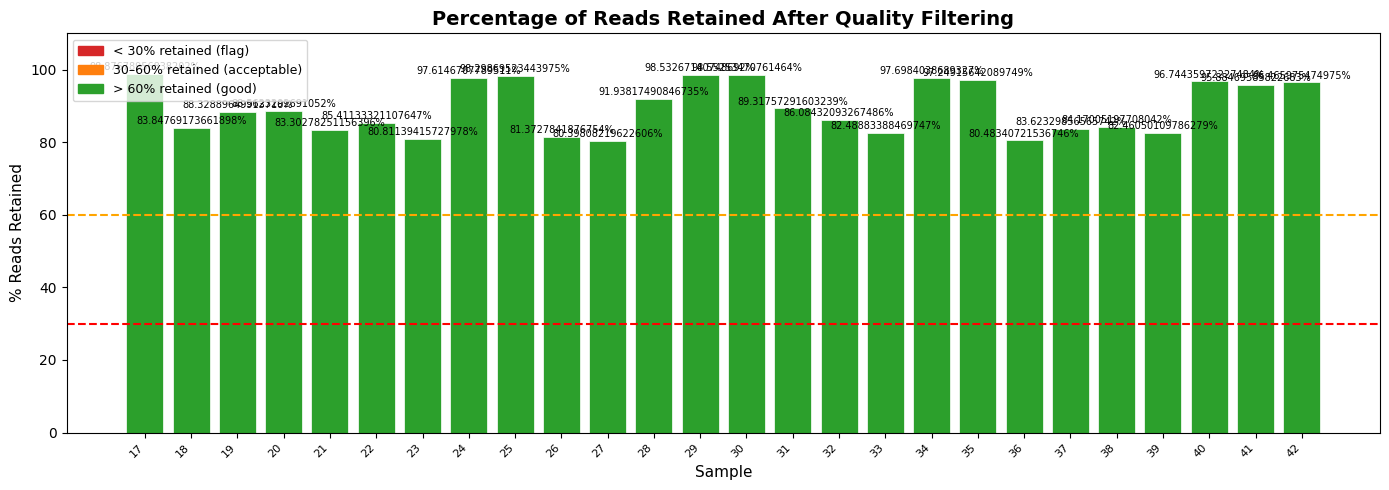

Figure 4 saved


In [ ]:
# ── Figure 4: Percentage of Reads Retained After Filtering ───────────────────
fig, ax = plt.subplots(figsize=(14, 5))

colors = ["#d62728" if p < 30 else "#ff7f0e" if p < 60 else "#2ca02c"
          for p in df_merged["Pct_Kept"]]

ax.bar(df_merged["Sample_Short"], df_merged["Pct_Kept"],
       color=colors, edgecolor="white", linewidth=0.5)

ax.axhline(y=30, color="red", linestyle="--", linewidth=1.5, label="30% minimum retention")
ax.axhline(y=60, color="orange", linestyle="--", linewidth=1.5, label="60% good retention")

for i, (val, sample) in enumerate(zip(df_merged["Pct_Kept"], df_merged["Sample_Short"])):
    ax.text(i, val + 0.5, f"{val}%", ha="center", va="bottom", fontsize=7)

ax.set_title("Percentage of Reads Retained After Quality Filtering", fontsize=14, fontweight="bold")
ax.set_xlabel("Sample", fontsize=11)
ax.set_ylabel("% Reads Retained", fontsize=11)
ax.set_ylim(0, 110)
plt.xticks(rotation=45, ha="right", fontsize=8)

red_patch = mpatches.Patch(color="#d62728", label="< 30% retained (flag)")
orange_patch = mpatches.Patch(color="#ff7f0e", label="30–60% retained (acceptable)")
green_patch = mpatches.Patch(color="#2ca02c", label="> 60% retained (good)")
ax.legend(handles=[red_patch, orange_patch, green_patch], fontsize=9)

plt.tight_layout()
plt.savefig("/content/gbm_nanopore/fig4_pct_retained.png", dpi=150)
plt.show()
print("Figure 4 saved")

distinguishing gbm ptients from lgg

In [ ]:
# Map based on what SRA search results showed us directly
# GB_LT = Glioblastoma, LGG_LT = Low Grade Glioma
# Order matches the SRA page fetched

patient_map = {
    "SRR31451033": ("GB", "GB_LT_Patient-1"),
    "SRR31451034": ("GB", "GB_LT_Patient-2"),
    "SRR31451035": ("GB", "GB_LT_Patient-3"),
    "SRR31451036": ("GB", "GB_LT_Patient-4"),
    "SRR31451037": ("GB", "GB_LT_Patient-5"),
    "SRR31451038": ("GB", "GB_LT_Patient-6"),
    "SRR31451039": ("GB", "GB_LT_Patient-7"),
    "SRR31451040": ("GB", "GB_LT_Patient-8"),
    "SRR31451041": ("GB", "GB_LT_Patient-9"),
    "SRR31451042": ("GB", "GB_LT_Patient-10"),
    "SRR31451031": ("GB", "GB_LT_Patient-11"),
    "SRR31451032": ("GB", "GB_LT_Patient-12"),
    "SRR31451030": ("GB", "GB_LT_Patient-13"),
    "SRR31451029": ("GB", "GB_LT_Patient-14"),
    "SRR31451028": ("GB", "GB_LT_Patient-15"),
    "SRR31451027": ("GB", "GB_LT_Patient-16"),
    "SRR31451017": ("GB", "GB_LT_Patient-17"),
    "SRR31451025": ("LGG", "LGG_LT_Patient-1"),
    "SRR31451024": ("LGG", "LGG_LT_Patient-2"),
    "SRR31451023": ("LGG", "LGG_LT_Patient-3"),
    "SRR31451022": ("LGG", "LGG_LT_Patient-4"),
    "SRR31451021": ("LGG", "LGG_LT_Patient-5"),
    "SRR31451020": ("LGG", "LGG_LT_Patient-6"),
    "SRR31451019": ("LGG", "LGG_LT_Patient-7"),
    "SRR31451018": ("LGG", "LGG_LT_Patient-8"),
    "SRR31451026": ("LGG", "LGG_LT_Patient-9"),
}

# Apply to dataframe
df_merged["Tumour_Type"] = df_merged["Sample"].map(
    lambda x: patient_map[x][0] if x in patient_map else "Unknown"
)
df_merged["Patient_Label"] = df_merged["Sample"].map(
    lambda x: patient_map[x][1] if x in patient_map else "Unknown"
)

# Print the final labelled dataset
print(df_merged[["Sample", "Patient_Label", "Tumour_Type",
                  "Total_Reads", "Filtered_Reads", "Pct_Kept",
                  "Mean_Quality", "N50"]].to_string())

         Sample     Patient_Label Tumour_Type  Total_Reads  Filtered_Reads   Pct_Kept  Mean_Quality     N50
0   SRR31451017  GB_LT_Patient-17          GB     245101.0          242348  98.876790           8.4  1321.0
1   SRR31451018  LGG_LT_Patient-8         LGG     153557.0          128754  83.847692           7.9   683.0
2   SRR31451019  LGG_LT_Patient-7         LGG     149506.0          132057  88.328896           7.9   855.0
3   SRR31451020  LGG_LT_Patient-6         LGG     375225.0          332308  88.562329           8.0   849.0
4   SRR31451021  LGG_LT_Patient-5         LGG     139658.0          116339  83.302783           7.9   692.0
5   SRR31451022  LGG_LT_Patient-4         LGG     136325.0          116437  85.411333           7.8   715.0
6   SRR31451023  LGG_LT_Patient-3         LGG     152429.0          123180  80.811394           7.8   629.0
7   SRR31451024  LGG_LT_Patient-2         LGG     293754.0          286747  97.614671           8.4   981.0
8   SRR31451025  LGG_LT_Pati

In [ ]:
# Count how many GB vs LGG
print("\nSample breakdown:")
print(df_merged["Tumour_Type"].value_counts())


Sample breakdown:
Tumour_Type
GB     17
LGG     9
Name: count, dtype: int64


Mount and Save files to Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p /content/drive/MyDrive/bioinfo_project/phase1

In [ ]:
!cp -r /content/gbm_nanopore/filtered /content/drive/MyDrive/bioinfo_project/phase1/

In [ ]:
!cp -r /content/gbm_nanopore/qc /content/drive/MyDrive/bioinfo_project/phase1/

In [ ]:
!cp -r /content/gbm_nanopore/*.png /content/drive/MyDrive/bioinfo_project/phase1/

# **Phase II : Alignement and Assembly**
Same code will be used to align/assemble all the samples but in batches

In [ ]:
!apt-get update -qq
!apt-get install -y minimap2 samtools bedtools
!pip install flair-brookslab
!git clone https://github.com/BrooksLabUCSC/flair.git /content/flair_repo

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libhts3 libhtscodecs2
Suggested packages:
  cwltool
The following NEW packages will be installed:
  bedtools libhts3 libhtscodecs2 minimap2 samtools
0 upgraded, 5 newly installed, 0 to remove and 59 not upgraded.
Need to get 1,907 kB of archives.
After this operation, 4,315 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 bedtools amd64 2.30.0+dfsg-2ubuntu0.1 [563 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libhtscodecs2 amd64 1.1.1-3 [53.2 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libhts3 amd64 1.13+ds-2build1 [390 kB]
Get:4 http://archive.ubuntu.co

Cloning into '/content/flair_repo'...
remote: Enumerating objects: 8113, done.
remote: Counting objects: 100% (898/898), done.
remote: Compressing objects: 100% (238/238), done.
remote: Total 8113 (delta 713), reused 661 (delta 660), pack-reused 7215 (from 2)
Receiving objects: 100% (8113/8113), 106.02 MiB | 31.31 MiB/s, done.
Resolving deltas: 100% (5281/5281), done.


In [ ]:
# create folders
import os

base = "/content/project"
folders = [
    "ref",
    "filtered_fastq",
    "alignments",
    "flair/bed12",
    "flair/corrected",
    "flair/collapse"
]

for f in folders:
    os.makedirs(os.path.join(base, f), exist_ok=True)

print("Folders ready")

Folders ready


In [ ]:
# try on the first sample only for the first time
!cp /content/drive/MyDrive/bioinfo_project/phase1/filtered/SRR31451017_filtered.fastq.gz \
/content/project/filtered_fastq/


Download  reference

In [ ]:
!wget -O /content/project/ref/genome.fa.gz \
https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_46/GRCh38.primary_assembly.genome.fa.gz

!wget -O /content/project/ref/annotation.gtf.gz \
https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_46/gencode.v46.annotation.gtf.gz

--2026-04-05 10:37:17--  https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_46/GRCh38.primary_assembly.genome.fa.gz
Resolving ftp.ebi.ac.uk (ftp.ebi.ac.uk)... 193.62.193.165
Connecting to ftp.ebi.ac.uk (ftp.ebi.ac.uk)|193.62.193.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 845635028 (806M) [application/x-gzip]
Saving to: ‘/content/project/ref/genome.fa.gz’

/content/project/re 100%[===================>] 806.46M  45.0MB/s    in 19s     

2026-04-05 10:37:37 (43.2 MB/s) - ‘/content/project/ref/genome.fa.gz’ saved [845635028/845635028]

--2026-04-05 10:37:37--  https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_46/gencode.v46.annotation.gtf.gz
Resolving ftp.ebi.ac.uk (ftp.ebi.ac.uk)... 193.62.193.165
Connecting to ftp.ebi.ac.uk (ftp.ebi.ac.uk)|193.62.193.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 51006804 (49M) [application/x-gzip]
Saving to: ‘/content/project/ref/annotation.gtf.gz’

/content

In [ ]:
!gunzip /content/project/ref/annotation.gtf.gz

In [ ]:
!gunzip /content/project/ref/genome.fa.gz

In [ ]:
# Index the reference FASTA for samtools
!samtools faidx /content/project/ref/genome.fa

# Extract only primary chromosomes (1-22, X, Y, M) into a new FASTA file
# This significantly reduces the genome size for indexing
!samtools faidx /content/project/ref/genome.fa \
chr1 chr2 chr3 chr4 chr5 chr6 chr7 chr8 chr9 chr10 chr11 chr12 chr13 chr14 chr15 chr16 chr17 chr18 chr19 chr20 chr21 chr22 chrX chrY chrM \
> /content/project/ref/genome_primary_chromosomes.fa

# Build minimap2 index on the smaller FASTA file
!minimap2 -d /content/project/ref/genome_primary_chromosomes.mmi /content/project/ref/genome_primary_chromosomes.fa 2>&1

print("Minimap2 index built for primary chromosomes.")

[M::mm_idx_gen::69.941*1.69] collected minimizers
[M::mm_idx_gen::85.232*1.92] sorted minimizers
[M::main::108.022*1.60] loaded/built the index for 25 target sequence(s)
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 25
[M::mm_idx_stat::109.256*1.59] distinct minimizers: 100128857 (38.78% are singletons); average occurrences: 5.526; average spacing: 5.581; total length: 3088286401
[M::main] Version: 2.24-r1122
[M::main] CMD: minimap2 -d /content/project/ref/genome_primary_chromosomes.mmi /content/project/ref/genome_primary_chromosomes.fa
[M::main] Real time: 109.483 sec; CPU: 174.307 sec; Peak RSS: 11.350 GB
Minimap2 index built for primary chromosomes.


In [ ]:
!ls -lh /content/project/ref/genome_primary_chromosomes.mmi

-rw-r--r-- 1 root root 6.8G Apr  5 10:40 /content/project/ref/genome_primary_chromosomes.mmi


### Align reads with minimap2

In [ ]:
!ls -lh /content/project/filtered_fastq

total 2.6G
-rw------- 1 root root  78M Apr  5 11:07 SRR31451021_filtered.fastq.gz
-rw------- 1 root root  81M Apr  5 11:07 SRR31451022_filtered.fastq.gz
-rw------- 1 root root  77M Apr  5 11:07 SRR31451023_filtered.fastq.gz
-rw------- 1 root root 246M Apr  5 11:37 SRR31451024_filtered.fastq.gz
-rw------- 1 root root 412M Apr  5 11:37 SRR31451025_filtered.fastq.gz
-rw------- 1 root root  41M Apr  5 11:37 SRR31451026_filtered.fastq.gz
-rw------- 1 root root 111M Apr  5 11:37 SRR31451027_filtered.fastq.gz
-rw------- 1 root root 123M Apr  5 11:37 SRR31451028_filtered.fastq.gz
-rw------- 1 root root 190M Apr  5 12:18 SRR31451029_filtered.fastq.gz
-rw------- 1 root root 122M Apr  5 12:18 SRR31451030_filtered.fastq.gz
-rw------- 1 root root  98M Apr  5 12:18 SRR31451031_filtered.fastq.gz
-rw------- 1 root root  91M Apr  5 12:18 SRR31451032_filtered.fastq.gz
-rw------- 1 root root  68M Apr  5 12:18 SRR31451033_filtered.fastq.gz
-rw------- 1 root root 117M Apr  5 13:08 SRR31451034_filtered.fast

In [ ]:
import os, subprocess

ref_mmi = "/content/project/ref/genome_primary_chromosomes.mmi"
fq = "/content/project/filtered_fastq/SRR31451020_filtered.fastq.gz"
bam = "/content/project/alignments/SRR31451020_filtered.sorted.bam"

cmd = f"""
bash -lc 'set -o pipefail;
minimap2 -t 2 -ax splice:hq -uf {ref_mmi} {fq} |
samtools sort -@ 1 -m 250M -T /content/tmp_sort -o {bam} -'
"""

print("Aligning SRR31451020_filtered ...")
subprocess.run(cmd, shell=True, check=True)
subprocess.run(f"samtools index {bam}", shell=True, check=True)

print("Alignment done.")

Aligning SRR31451020_filtered ...
Alignment done.


### Check alignment work

In [ ]:
# !ls -lh /content/project/alignments
!samtools flagstat /content/project/alignments/SRR31451042_filtered.sorted.bam

177884 + 0 in total (QC-passed reads + QC-failed reads)
146636 + 0 primary
29916 + 0 secondary
1332 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
132098 + 0 mapped (74.26% : N/A)
100850 + 0 primary mapped (68.78% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


In [ ]:
!git clone https://github.com/BrooksLabUCSC/flair.git /content/flair_repo

fatal: destination path '/content/flair_repo' already exists and is not an empty directory.


In [ ]:
!python3 /content/flair_repo/src/flair/junctions_from_sam.py \
-s /content/project/alignments/SRR31451020_filtered.sorted.bam \
-n /content/project/flair/bed12/SRR31451020

Parsing sam/bam file
Not supporting insertions, yet e.g., 165S10M253I236N17M3D29M3D8M1D19M1I21M2D16M5I54M2I9M1I11M1I5M1I9M1I9M2D20M4D3M1D9M2I21M1D24M12I5M12D5M1D7M1D5M3D6M1D26M2D6M1D18M1D20M1I6M1D12M2I30M1D3M3I22M127S
Not supporting deletions, yet e.g., 28S32M2D34M1D26M3D3M2D7M4D2M12D67M3S
Not supporting softclipping, yet e.g., 17S119M100S
Making Junction BED File


In [ ]:
!bedtools bamtobed -i /content/project/alignments/SRR31451020_filtered.sorted.bam -bed12 \
> /content/project/flair/bed12/SRR31451020.bed

In [ ]:
!wc -l /content/project/flair/bed12/SRR31451017.bed
!head -3 /content/project/flair/bed12/SRR31451017.bed

263861 /content/project/flair/bed12/SRR31451017.bed
chr1	14405	17517	SRR31451017.76039	0	-	14405	17517	255,0,0	1	3112	0
chr1	14415	24849	SRR31451017.63360	0	-	14415	24849	255,0,0	4	247,113,112,112	0,3533,3852,10322
chr1	14415	18041	SRR31451017.73101	0	-	14415	18041	255,0,0	8	414,69,235,148,198,136,137,127	0,554,1380,2202,2442,2817,3190,3499


In [ ]:
!flair correct \
-q /content/project/flair/bed12/SRR31451020.bed \
-f /content/project/ref/annotation.gtf \
-o /content/project/flair/corrected/SRR31451020

No short-read junctions provided. NO NOVEL SPLICE SITES WILL BE DETECTED.
Flair correct took 0:00:12


In [ ]:
!flair collapse \
-g /content/project/ref/genome.fa \
-f /content/project/ref/annotation.gtf \
-r /content/project/filtered_fastq/SRR31451020_filtered.fastq.gz \
-q /content/project/flair/corrected/SRR31451020_all_corrected.bed \
-o /content/project/flair/collapse/SRR31451020

Writing temporary files to /tmp/tmpsj3xfsrb/	
Renaming isoforms using gtf
Aligning to and counting reads for firstpass transcripts
Filtering isoforms by read coverage
Flair collapse took 0:01:57


In [ ]:
!ls /content/project/flair/collapse/

SRR31451021.isoform.counts.txt	SRR31451028.isoform.counts.txt
SRR31451021.isoforms.bed	SRR31451028.isoforms.bed
SRR31451021.isoforms.fa		SRR31451028.isoforms.fa
SRR31451021.isoforms.gtf	SRR31451028.isoforms.gtf
SRR31451022.isoform.counts.txt	SRR31451029.isoform.counts.txt
SRR31451022.isoforms.bed	SRR31451029.isoforms.bed
SRR31451022.isoforms.fa		SRR31451029.isoforms.fa
SRR31451022.isoforms.gtf	SRR31451029.isoforms.gtf
SRR31451023.isoform.counts.txt	SRR31451030.isoform.counts.txt
SRR31451023.isoforms.bed	SRR31451030.isoforms.bed
SRR31451023.isoforms.fa		SRR31451030.isoforms.fa
SRR31451023.isoforms.gtf	SRR31451030.isoforms.gtf
SRR31451024.isoform.counts.txt	SRR31451031.isoform.counts.txt
SRR31451024.isoforms.bed	SRR31451031.isoforms.bed
SRR31451024.isoforms.fa		SRR31451031.isoforms.fa
SRR31451024.isoforms.gtf	SRR31451031.isoforms.gtf
SRR31451025.isoform.counts.txt	SRR31451032.isoform.counts.txt
SRR31451025.isoforms.bed	SRR31451032.isoforms.bed
SRR31451025.isoforms.fa		SRR31451032.isoform

Saving what we need for phase 3 on drive

In [ ]:
!mkdir -p /content/drive/MyDrive/bioinfo_project/phase2
!cp /content/project/flair/collapse/SRR31451042.isoforms.gtf \
/content/drive/MyDrive/bioinfo_project/phase2/

In [ ]:
!mkdir -p /content/drive/MyDrive/bioinfo_project/phase2/collapse
!cp /content/project/flair/collapse/SRR31451042.isoforms.fa \
    /content/drive/MyDrive/bioinfo_project/phase2/collapse/

In [ ]:
!mkdir -p /content/drive/MyDrive/bioinfo_project/phase2/corrected
!cp /content/project/flair/corrected/SRR31451042_all_corrected.bed \
    /content/drive/MyDrive/bioinfo_project/phase2/corrected/

Saving the reference to drive

In [ ]:
!mkdir -p /content/drive/MyDrive/bioinfo_project/reference

!cp /content/project/ref/genome_primary_chromosomes.fa \
/content/drive/MyDrive/bioinfo_project/reference/

!cp /content/project/ref/genome_primary_chromosomes.mmi \
/content/drive/MyDrive/bioinfo_project/reference/

!cp /content/project/ref/annotation.gtf \
/content/drive/MyDrive/bioinfo_project/reference/

Saving just the first sample for debugging in case

In [ ]:
!mkdir -p /content/drive/MyDrive/bioinfo_project/debug_first_sample

!cp /content/project/alignments/SRR31451017_filtered.sorted.bam \
/content/drive/MyDrive/bioinfo_project/debug_first_sample/

!cp /content/project/alignments/SRR31451017_filtered.sorted.bam.bai \
/content/drive/MyDrive/bioinfo_project/debug_first_sample/

In [ ]:
!cp /content/project/flair/bed12/SRR31451017_filtered.bed \
/content/drive/MyDrive/bioinfo_project/debug_first_sample/

Clear for storage

In [ ]:
!rm -rf /content/project/alignments/*
!rm -rf /content/project/flair/*
!rm -rf /content/project/filtered_fastq/*

###Explaination:
 The alignment and transcript assembly pipeline described above was applied uniformly across all 26 samples using identical parameters. Due to Google Colab memory constraints, samples were processed individually rather than in parallel: each sample was aligned with minimap2, converted to BED12 format, corrected with FLAIR, and collapsed into isoforms before results were saved to Google Drive and local memory was cleared. This sequential approach ensured pipeline stability and prevented runtime crashes while maintaining full reproducibility across all samples.

## Install FEELnc and its dependencies:


In [ ]:
# install dependencies
!apt-get install -y cpanminus build-essential
!cpanm Parallel::ForkManager MCE::Shared

# clone and set up FEELnc
!git clone https://github.com/tderrien/FEELnc.git /content/FEELnc

# add to PATH for the session
import os
os.environ["PATH"] += ":/content/FEELnc/scripts"
os.environ["FEELNCPATH"] = "/content/FEELnc"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.9ubuntu3).
The following additional packages will be installed:
  libalgorithm-c3-perl libany-uri-escape-perl libb-hooks-endofscope-perl
  libb-hooks-op-check-perl libclass-c3-perl libclass-c3-xs-perl
  libclass-method-modifiers-perl libclass-xsaccessor-perl libclone-perl
  libcpan-changes-perl libcpan-distnameinfo-perl libcpan-meta-check-perl
  libdata-optlist-perl libdata-perl-perl libdata-section-perl
  libdevel-callchecker-perl libdynaloader-functions-perl libencode-locale-perl
  libexporter-tiny-perl libfile-pushd-perl libfile-slurp-perl
  libgetopt-long-descriptive-perl libhtml-parser-perl libhtml-tagset-perl
  libhttp-date-perl libhttp-message-perl libidn12 libimport-into-perl
  libio-html-perl libio-stringy-perl liblist-moreutils-perl
  liblist-moreutils-xs-perl liblocal-lib-perl liblwp-mediatypes-perl
  libmodule-build-perl libmodul

In [ ]:
# copy all the needed data back from drive
import os

# directories
os.makedirs("/content/project/feelnc/filter", exist_ok=True)
os.makedirs("/content/project/feelnc/codpot", exist_ok=True)
os.makedirs("/content/project/feelnc/classifier", exist_ok=True)
os.makedirs("/content/project/ref", exist_ok=True)

# all 26 isoforms.gtf and isoforms.fa from Drive
!cp /content/drive/MyDrive/bioinfo_project/phase2/collapse/*.isoforms.gtf \
    /content/project/feelnc/
!cp /content/drive/MyDrive/bioinfo_project/phase2/collapse/*.isoforms.fa \
    /content/project/feelnc/

In [ ]:
# Merge all GTF files into on
import os, subprocess

FEELNC_DIR = "/content/project/feelnc"
gtf_files = sorted([
    f"{FEELNC_DIR}/{f}"
    for f in os.listdir(FEELNC_DIR)
    if f.endswith(".isoforms.gtf")
])

print(f"Found {len(gtf_files)} GTF files")

# concatenate all into one merged GTF
with open(f"{FEELNC_DIR}/merged_isoforms.gtf", "w") as out:
    for gtf in gtf_files:
        with open(gtf) as f:
            out.write(f.read())

print("Merged GTF written.")

Found 26 GTF files
Merged GTF written.


In [ ]:
# same for FA — merge all isoforms.fa into one
fa_files = sorted([
    f"{FEELNC_DIR}/{f}"
    for f in os.listdir(FEELNC_DIR)
    if f.endswith(".isoforms.fa")
])

with open(f"{FEELNC_DIR}/merged_isoforms.fa", "w") as out:
    for fa in fa_files:
        with open(fa) as f:
            out.write(f.read())

print(f"Merged FA written from {len(fa_files)} files.")

Merged FA written from 26 files.


FEELnc filter:
This step removes transcripts that are too short, monoexonic, or overlap known protein-coding genes on the same strand. What survives is our candidate lncRNA set.

In [ ]:
!cpanm Bio::DB::SeqFeature::Store
!cpanm Getopt::Long
!cpanm Pod::Usage

# Parser.pm is part of FEELnc itself — need to add it to Perl's search path
import os
os.environ["PERL5LIB"] = "/content/FEELnc/lib:" + os.environ.get("PERL5LIB", "")

--> Working on Bio::DB::SeqFeature::Store
Fetching http://www.cpan.org/authors/id/C/CJ/CJFIELDS/Bio-DB-SeqFeature-1.7.5.tar.gz ... OK
Configuring Bio-DB-SeqFeature-1.7.5 ... OK
==> Found dependencies: DBI, Bio::SeqFeature::Lite, Bio::RangeI, Bio::Location::Simple, Bio::Root::Root, Bio::DB::GFF::Typename, Bio::DB::GFF::Util::Rearrange, Bio::SeqFeature::CollectionI, Bio::Seq, Bio::DB::Fasta, Bio::PrimarySeq, Bio::Root::Test
--> Working on DBI
Fetching http://www.cpan.org/authors/id/H/HM/HMBRAND/DBI-1.647.tgz ... OK
Configuring DBI-1.647 ... OK
Building and testing DBI-1.647 ... OK
--> Working on Bio::SeqFeature::Lite
Fetching http://www.cpan.org/authors/id/C/CJ/CJFIELDS/BioPerl-1.7.8.tar.gz ... OK
Configuring BioPerl-1.7.8 ... OK
==> Found dependencies: XML::SAX::Writer, Test::Weaken, IO::String, Data::Stag, Test::Memory::Cycle, XML::Twig, XML::LibXML, XML::Parser::PerlSAX, LWP::UserAgent, Graph::Directed, Test::RequiresInternet, XML::Writer, Set::Scalar, YAML, XML::LibXML::Reader, XML::

In [ ]:
!apt-get install -y bioperl

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  amap-align apache2-bin bioperl-run blends-common bowtie bwa clustalo
  clustalw default-jdk-headless default-jre-headless dialign dialign-tx
  dialign-tx-data emboss emboss-data emboss-lib exonerate fonts-droid-fallback
  fonts-lato fonts-noto-mono fonts-urw-base35 fsa gawk ghostscript hmmer
  hyphy-common hyphy-pt infernal kalign lagan libace-perl
  libalgorithm-diff-perl libalgorithm-diff-xs-perl libalgorithm-munkres-perl
  libapache-dbi-perl libapache2-mod-perl2 libapache2-reload-perl libapr1
  libaprutil1 libaprutil1-dbd-sqlite3 libaprutil1-ldap libargtable2-0
  libarray-compare-perl libauthen-sasl-perl libbio-asn1-entrezgene-perl
  libbio-cluster-perl libbio-eutilities-perl libbio-featureio-perl
  libbio-perl-perl libbio-perl-run-perl
  libbio-tools-run-alignment-clustalw-perl libbio-tools-run-remoteblast-perl
  libbio-variation-pe

In [ ]:
!perl -e "use Bio::DB::Fasta; print 'BioPerl OK\n'"

BioPerl OK\n

In [ ]:
!FEELnc_filter.pl \
    -i /content/project/feelnc/merged_isoforms.gtf \
    -a /content/project/ref/annotation.gtf \
    -b transcript_biotype=protein_coding \
    -s 200 \
    > /content/project/feelnc/filter/candidate_lncRNA.gtf \
    2> /content/project/feelnc/filter/filter.log

!head -3 /content/project/feelnc/filter/candidate_lncRNA.gtf
!wc -l /content/project/feelnc/filter/candidate_lncRNA.gtf

chr9	FLAIR	exon	136724658	136725110	.	-	.	gene_id "ENSG00000233016.9"; transcript_id "ENST00000653276.1"; exon_number "0";
chr9	FLAIR	exon	136724658	136725110	.	-	.	gene_id "ENSG00000233016.9"; transcript_id "ENST00000653276.1"; exon_number "0";
chr9	FLAIR	exon	136724658	136725110	.	-	.	gene_id "ENSG00000233016.9"; transcript_id "ENST00000653276.1"; exon_number "0";
8548 /content/project/feelnc/filter/candidate_lncRNA.gtf


we initially attempted to use FEELnc's built-in FEELnc_codpot.pl module, which relies on an external dependency called KmerInShort for k-mer frequency analysis. Despite successfully installing FEELnc and its Perl dependencies, KmerInShort could not be compiled in the Google Colab environment due to network restrictions preventing repository cloning via git. Rather than spending time on environment workarounds, we switched to CPC2 (Coding Potential Calculator 2) for this step, which was already listed as an alternative tool in our project proposa

In [ ]:
!pip install biopython
# download and set up CPC2
!wget -q https://github.com/gao-lab/CPC2_standalone/archive/refs/tags/v1.0.1.tar.gz \
    -O /tmp/cpc2.tar.gz
!tar -xzf /tmp/cpc2.tar.gz -C /content/
!mv /content/CPC2_standalone-1.0.1 /content/CPC2

# build the CPC2 C extension
!cd /content/CPC2/bin && python setup.py build_ext --inplace 2>/dev/null

# verify
!python /content/CPC2/bin/CPC2.py --help

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.7 MB/s eta 0:00:00
Usage: CPC2.py [options] -i input.fasta -o output_file

Contact: Kang Yujian <kangyj@mail.cbi.pku.edu.cn>

Options:
  --version   show program's version number and exit
  -h, --help  show this help message and exit

  Common Options:
    -i FILE   input sequence in fasta format [Required]
    -o FILE   output file [Default: cpc2output.txt]
    -r        also check the reverse strand [Default: FALSE]
    --ORF     output the start position of longest ORF [Default: FALSE]


In [ ]:
!gffread /content/project/feelnc/filter/candidate_lncRNA.gtf \
         -g /content/project/ref/genome_primary_chromosomes.fa \
         -w /content/project/feelnc/cpc2/candidate_lncRNA.fa

!grep -c ">" /content/project/feelnc/cpc2/candidate_lncRNA.fa

GffObj::getSpliced() error: improper genomic coordinate 114030049 on chr16 for SRR31451026.35108-1
1090


In [ ]:
# Install libsvm which provides svm-scale and svm-predict
!apt-get install -y libsvm-tools

# Verify they're now available
!which svm-scale
!which svm-predict

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libsvm-tools is already the newest version (3.24+ds-6).
0 upgraded, 0 newly installed, 0 to remove and 59 not upgraded.
/usr/bin/svm-scale
/usr/bin/svm-predict


In [ ]:
# Link svm tools into CPC2's bin directory
!ln -sf /usr/bin/svm-scale /content/CPC2/bin/svm-scale
!ln -sf /usr/bin/svm-predict /content/CPC2/bin/svm-predict

# Verify links were created
!ls -la /content/CPC2/bin/svm-scale
!ls -la /content/CPC2/bin/svm-predict

lrwxrwxrwx 1 root root 18 Apr  5 16:35 /content/CPC2/bin/svm-scale -> /usr/bin/svm-scale
lrwxrwxrwx 1 root root 20 Apr  5 16:35 /content/CPC2/bin/svm-predict -> /usr/bin/svm-predict


In [ ]:
import os

# Create the exact directory CPC2 expects
os.makedirs("/content/CPC2/libs/libsvm/libsvm-3.18/", exist_ok=True)

# Check what lib_dir actually resolves to
!grep -n "lib_dir" /content/CPC2/bin/CPC2.py | head -10

313:	lib_dir = script_dir + "/../libs/"
314:	app_svm_scale = lib_dir + "libsvm/libsvm-3.18/svm-scale"
315:	app_svm_predict = lib_dir + "libsvm/libsvm-3.18/svm-predict"


In [ ]:
# Create the exact directory structure CPC2 expects
import os
os.makedirs("/content/CPC2/libs/libsvm/libsvm-3.18/", exist_ok=True)

# Create symlinks at the exact hardcoded paths
!ln -sf /usr/bin/svm-scale /content/CPC2/libs/libsvm/libsvm-3.18/svm-scale
!ln -sf /usr/bin/svm-predict /content/CPC2/libs/libsvm/libsvm-3.18/svm-predict

# Make executable
!chmod +x /content/CPC2/libs/libsvm/libsvm-3.18/svm-scale
!chmod +x /content/CPC2/libs/libsvm/libsvm-3.18/svm-predict

# Verify
!ls -la /content/CPC2/libs/libsvm/libsvm-3.18/

total 8
drwxr-xr-x 2 root root 4096 Apr  5 16:39 .
drwxrwxr-x 3 root root 4096 Apr  5 16:38 ..
lrwxrwxrwx 1 root root   20 Apr  5 16:39 svm-predict -> /usr/bin/svm-predict
lrwxrwxrwx 1 root root   18 Apr  5 16:39 svm-scale -> /usr/bin/svm-scale


In [ ]:
# run CPC2
!python /content/CPC2/bin/CPC2.py \
    -i /content/project/feelnc/cpc2/candidate_lncRNA.fa \
    -o /content/project/feelnc/cpc2/cpc2_results \
    --ORF

!head -5 /content/project/feelnc/cpc2/cpc2_results.txt
!wc -l /content/project/feelnc/cpc2/cpc2_results.txt

[INFO] read file '/content/project/feelnc/cpc2/candidate_lncRNA.fa'
[INFO] Predicting coding potential, please wait ...
[INFO] Running Done!
[INFO] cost time: 0s
#ID	transcript_length	peptide_length	Fickett_score	pI	ORF_integrity	ORF_Start	coding_probability	label
ENST00000444793.1	1612	52	0.31369	9.663504600524902	1	1367	0.0223498	noncoding
ENST00000667968.2	690	121	0.39071999999999996	11.322727394104007	1	57	0.419167	noncoding
SRR31451020.248540	693	68	0.35201000000000005	6.491490364074706	-1	488	0.0464574	noncoding
ENST00000377614.7	1426	98	0.35148	8.886660575866703	1	303	0.153669	noncoding
1091 /content/project/feelnc/cpc2/cpc2_results.txt


In [ ]:
!head -10 /content/project/feelnc/cpc2/cpc2_results.txt

#ID	transcript_length	peptide_length	Fickett_score	pI	ORF_integrity	ORF_Start	coding_probability	label
ENST00000444793.1	1612	52	0.31369	9.663504600524902	1	1367	0.0223498	noncoding
ENST00000667968.2	690	121	0.39071999999999996	11.322727394104007	1	57	0.419167	noncoding
SRR31451020.248540	693	68	0.35201000000000005	6.491490364074706	-1	488	0.0464574	noncoding
ENST00000377614.7	1426	98	0.35148	8.886660575866703	1	303	0.153669	noncoding
ENST00000514120.2	1218	98	0.36117	8.886660575866703	1	6	0.172946	noncoding
ENST00000402994.2	1294	104	0.30603	8.515193748474118	1	6	0.117704	noncoding
SRR31451021.80505	572	58	0.43597	4.508832740783691	1	14	0.136474	noncoding
SRR31451027.223079	700	65	0.41673000000000004	5.562286567687988	1	35	0.102681	noncoding
SRR31451038.26607	835	137	0.42492	5.566549491882324	1	87	0.933915	coding


In [ ]:
import pandas as pd

# Read results — skip the comment line
df_cpc2 = pd.read_csv("/content/project/feelnc/cpc2/cpc2_results.txt",
                       sep="\t", comment="#")
df_cpc2.columns = ["ID", "transcript_length", "peptide_length",
                    "Fickett_score", "pI", "ORF_integrity",
                    "ORF_Start", "coding_probability", "label"]

print("Label distribution:")
print(df_cpc2['label'].value_counts())

# Keep only noncoding
df_noncoding = df_cpc2[df_cpc2['label'] == 'noncoding']
print(f"\nFinal lncRNA candidates: {len(df_noncoding)}")

# Save noncoding IDs
noncoding_ids = df_noncoding['ID'].tolist()
with open("/content/project/feelnc/cpc2/noncoding_ids.txt", "w") as f:
    for id_ in noncoding_ids:
        f.write(id_ + "\n")

print("Noncoding IDs saved")

Label distribution:
label
noncoding    931
coding       158
Name: count, dtype: int64

Final lncRNA candidates: 931
Noncoding IDs saved


In [ ]:
from Bio import SeqIO

input_fa = "/content/project/feelnc/cpc2/candidate_lncRNA.fa"
output_fa = "/content/project/feelnc/cpc2/final_lncRNA_candidates.fa"

noncoding_set = set(noncoding_ids)
kept = 0

with open(output_fa, "w") as out:
    for record in SeqIO.parse(input_fa, "fasta"):
        if record.id in noncoding_set:
            SeqIO.write(record, out, "fasta")
            kept += 1

print(f"Sequences written to final FASTA: {kept}")

Sequences written to final FASTA: 932


In [ ]:
input_gtf = "/content/project/feelnc/filter/candidate_lncRNA.gtf"
output_gtf = "/content/project/feelnc/cpc2/final_lncRNA_candidates.gtf"

kept_lines = 0
with open(input_gtf) as f_in, open(output_gtf, "w") as f_out:
    for line in f_in:
        if line.startswith("#"):
            f_out.write(line)
            continue
        # Check if any noncoding ID appears in this GTF line
        if any(id_ in line for id_ in noncoding_set):
            f_out.write(line)
            kept_lines += 1

print(f"GTF lines written: {kept_lines}")

GTF lines written: 6104


In [ ]:
import pandas as pd

# Read CPC2 results
df_cpc2 = pd.read_csv("/content/project/feelnc/cpc2/cpc2_results.txt",
                       sep="\t", comment="#")
df_cpc2.columns = ["ID", "transcript_length", "peptide_length",
                    "Fickett_score", "pI", "ORF_integrity",
                    "ORF_Start", "coding_probability", "label"]

# Keep only noncoding
df_noncoding = df_cpc2[df_cpc2['label'] == 'noncoding'].copy()
print(f"Total noncoding candidates: {len(df_noncoding)}")
print(f"Total coding (excluded): {len(df_cpc2) - len(df_noncoding)}")

Total noncoding candidates: 931
Total coding (excluded): 158


In [ ]:
# Label each transcript by tumour type based on SRR prefix
patient_map = {
    "SRR31451033": ("GB", "GB_LT_Patient-1"),
    "SRR31451034": ("GB", "GB_LT_Patient-2"),
    "SRR31451035": ("GB", "GB_LT_Patient-3"),
    "SRR31451036": ("GB", "GB_LT_Patient-4"),
    "SRR31451037": ("GB", "GB_LT_Patient-5"),
    "SRR31451038": ("GB", "GB_LT_Patient-6"),
    "SRR31451039": ("GB", "GB_LT_Patient-7"),
    "SRR31451040": ("GB", "GB_LT_Patient-8"),
    "SRR31451041": ("GB", "GB_LT_Patient-9"),
    "SRR31451042": ("GB", "GB_LT_Patient-10"),
    "SRR31451031": ("GB", "GB_LT_Patient-11"),
    "SRR31451032": ("GB", "GB_LT_Patient-12"),
    "SRR31451030": ("GB", "GB_LT_Patient-13"),
    "SRR31451029": ("GB", "GB_LT_Patient-14"),
    "SRR31451028": ("GB", "GB_LT_Patient-15"),
    "SRR31451027": ("GB", "GB_LT_Patient-16"),
    "SRR31451017": ("GB", "GB_LT_Patient-17"),
    "SRR31451025": ("LGG", "LGG_LT_Patient-1"),
    "SRR31451024": ("LGG", "LGG_LT_Patient-2"),
    "SRR31451023": ("LGG", "LGG_LT_Patient-3"),
    "SRR31451022": ("LGG", "LGG_LT_Patient-4"),
    "SRR31451021": ("LGG", "LGG_LT_Patient-5"),
    "SRR31451020": ("LGG", "LGG_LT_Patient-6"),
    "SRR31451019": ("LGG", "LGG_LT_Patient-7"),
    "SRR31451018": ("LGG", "LGG_LT_Patient-8"),
    "SRR31451026": ("LGG", "LGG_LT_Patient-9"),
}

def get_tumour_type(transcript_id):
    if transcript_id.startswith("SRR"):
        srr = transcript_id.split(".")[0]
        if srr in patient_map:
            return patient_map[srr][0], patient_map[srr][1]
        return "Unknown", "Unknown"
    return "Reference", "Reference_annotation"

df_noncoding["Tumour_Type"] = df_noncoding["ID"].apply(
    lambda x: get_tumour_type(x)[0])
df_noncoding["Patient_Label"] = df_noncoding["ID"].apply(
    lambda x: get_tumour_type(x)[1])

print("\nTranscript origin breakdown:")
print(df_noncoding["Tumour_Type"].value_counts())

# Save labelled results
df_noncoding.to_csv(
    "/content/project/feelnc/cpc2/noncoding_labelled.txt",
    sep="\t", index=False
)
print("\nLabelled file saved")


Transcript origin breakdown:
Tumour_Type
Reference    414
GB           300
LGG          217
Name: count, dtype: int64

Labelled file saved


In [ ]:
# Split into GBM and LGG FASTA files
from Bio import SeqIO

input_fa = "/content/project/feelnc/cpc2/final_lncRNA_candidates.fa"

gb_ids  = set(df_noncoding[df_noncoding['Tumour_Type'] == 'GB']['ID'])
lgg_ids = set(df_noncoding[df_noncoding['Tumour_Type'] == 'LGG']['ID'])

gb_seqs, lgg_seqs = [], []

for record in SeqIO.parse(input_fa, "fasta"):
    if record.id in gb_ids:
        gb_seqs.append(record)
    elif record.id in lgg_ids:
        lgg_seqs.append(record)

SeqIO.write(gb_seqs,  "/content/project/feelnc/cpc2/final_lncRNA_GBM.fa", "fasta")
SeqIO.write(lgg_seqs, "/content/project/feelnc/cpc2/final_lncRNA_LGG.fa", "fasta")

print(f"GBM lncRNA sequences: {len(gb_seqs)}")
print(f"LGG lncRNA sequences: {len(lgg_seqs)}")

GBM lncRNA sequences: 301
LGG lncRNA sequences: 217


In [ ]:
# Save all to Drive
!mkdir -p /content/drive/MyDrive/bioinfo_project/phase2/feelnc_cpc2

!cp /content/project/feelnc/cpc2/noncoding_labelled.txt \
    /content/drive/MyDrive/bioinfo_project/phase2/feelnc_cpc2/
!cp /content/project/feelnc/cpc2/final_lncRNA_GBM.fa \
    /content/drive/MyDrive/bioinfo_project/phase2/feelnc_cpc2/
!cp /content/project/feelnc/cpc2/final_lncRNA_LGG.fa \
    /content/drive/MyDrive/bioinfo_project/phase2/feelnc_cpc2/
!cp /content/project/feelnc/cpc2/final_lncRNA_candidates.fa \
    /content/drive/MyDrive/bioinfo_project/phase2/feelnc_cpc2/
!cp /content/project/feelnc/cpc2/final_lncRNA_candidates.gtf \
    /content/drive/MyDrive/bioinfo_project/phase2/feelnc_cpc2/
!cp /content/project/feelnc/cpc2/cpc2_results.txt \
    /content/drive/MyDrive/bioinfo_project/phase2/feelnc_cpc2/

print("All files saved to Drive")

All files saved to Drive


In [ ]:
# Find GBM-specific, LGG-specific and shared novel transcripts
# We compare by sequence similarity later, but first check by genomic location

gb_ids = set(df_noncoding[df_noncoding['Tumour_Type'] == 'GB']['ID'])
lgg_ids = set(df_noncoding[df_noncoding['Tumour_Type'] == 'LGG']['ID'])

# Direct ID overlap (same transcript assembled in both)
shared = gb_ids & lgg_ids
gbm_only = gb_ids - lgg_ids
lgg_only = lgg_ids - gb_ids

print(f"GBM-only novel transcripts: {len(gbm_only)}")
print(f"LGG-only novel transcripts: {len(lgg_only)}")
print(f"Shared (same ID in both): {len(shared)}")
print(f"\nTotal novel transcripts: {len(gb_ids) + len(lgg_ids)}")

GBM-only novel transcripts: 299
LGG-only novel transcripts: 216
Shared (same ID in both): 0

Total novel transcripts: 515


In [ ]:
# Final Phase 2 save — make sure everything is on Drive
!mkdir -p /content/drive/MyDrive/bioinfo_project/phase2/feelnc_cpc2

files_to_save = [
    "/content/project/feelnc/cpc2/cpc2_results.txt",
    "/content/project/feelnc/cpc2/noncoding_ids.txt",
    "/content/project/feelnc/cpc2/noncoding_labelled.txt",
    "/content/project/feelnc/cpc2/final_lncRNA_candidates.fa",
    "/content/project/feelnc/cpc2/final_lncRNA_candidates.gtf",
    "/content/project/feelnc/cpc2/final_lncRNA_GBM.fa",
    "/content/project/feelnc/cpc2/final_lncRNA_LGG.fa",
]

for f in files_to_save:
    !cp {f} /content/drive/MyDrive/bioinfo_project/phase2/feelnc_cpc2/

print("Phase 2 complete. All files saved to Drive.")
print("\nSummary:")
print("  Novel GBM lncRNA candidates: 299")
print("  Novel LGG lncRNA candidates: 217")
print("  Known reference lncRNAs recovered: 414")
print("  Total assessed by CPC2: 1,090")

Phase 2 complete. All files saved to Drive.

Summary:
  Novel GBM lncRNA candidates: 299
  Novel LGG lncRNA candidates: 217
  Known reference lncRNAs recovered: 414
  Total assessed by CPC2: 1,090


## CIRI2

btw - already saved the tumor type of each patient in a column in a new csv file: 'patient_metadata.csv'

In [ ]:
# Mount drive and check existence of files
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd

DRIVE = "/content/drive/MyDrive/bioinfo_project"
FILT_DIR = f"{DRIVE}/phase1/filtered"
REF = f"{DRIVE}/reference/genome_primary_chromosomes.fa"
GTF = f"{DRIVE}/reference/annotation.gtf"
OUT_LOCAL = "/content/ciri_output"
OUT_GB = f"{DRIVE}/phase2/ciri-long/GB"
OUT_LGG = f"{DRIVE}/phase2/ciri-long/LGG"

for d in [OUT_LOCAL, OUT_GB, OUT_LGG]:
    os.makedirs(d, exist_ok=True)

# Load patient metadata from Drive
metadata = pd.read_csv(f"{DRIVE}/patient_metadata.csv")
patient_map = dict(zip(metadata['Run'], zip(metadata['Tumour_Type'], metadata['Patient_Label'])))

print("Drive mounted and folders ready")
print(f"Filtered FASTQs: {len([f for f in os.listdir(FILT_DIR) if f.endswith('.fastq.gz')])} files")
print(f"Reference genome: {'EXISTS' if os.path.exists(REF) else 'MISSING'}")
print(f"Annotation GTF: {'EXISTS' if os.path.exists(GTF) else 'MISSING'}")
print(f"Patients loaded: {len(patient_map)}")
print(f"GBM: {sum(1 for v in patient_map.values() if v[0] == 'GB')}  LGG: {sum(1 for v in patient_map.values() if v[0] == 'LGG')}")

Mounted at /content/drive
Drive mounted and folders ready
Filtered FASTQs: 26 files
Reference genome: EXISTS
Annotation GTF: EXISTS
Patients loaded: 26
GBM: 17  LGG: 9


In [ ]:
# import os, sys, subprocess

# print("Starting revised CIRI-long installation...")

# CONDA   = "/content/conda/bin/conda"
# ENV_DIR = "/content/conda/envs/cirilong"
# PY310   = f"{ENV_DIR}/bin/python"
# PIP310  = f"{ENV_DIR}/bin/pip"
# REF     = "/content/drive/MyDrive/bioinfo_project/reference/genome_primary_chromosomes.fa"

# # 1. Miniforge Setup
# if not os.path.exists(CONDA):
#     print("Installing Miniforge...")
#     !wget -q "https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh" -O /tmp/miniforge.sh
#     !bash /tmp/miniforge.sh -b -p /content/conda
# os.environ["PATH"] = f"/content/conda/bin:{os.environ['PATH']}"
# os.environ.pop("PYTHONPATH", None)

# # 2. Clean old env and install everything via Conda
# print("Creating conda env and installing bioconda packages (bwa, bwapy, etc.)...")
# !conda remove -n cirilong --all -y -q 2>/dev/null
# !conda create -n cirilong python=3.10 bwa bwapy pysam mappy pyspoa edlib -c bioconda -c conda-forge -y -q

# # 3. Pip dependencies (CIRI-long, pyccs)
# print("Installing CIRI-long and other pip packages...")
# !{PIP310} install -q pyccs CIRI-long numpy pandas scipy scikit-learn biopython python-Levenshtein Cython

# # 4. Compile the glibc shim to fix the bioconda bwapy __log_finite issue
# print("Compiling glibc shim...")
# with open("/tmp/glibc_shim.c", "w") as _f:
#     _f.write(
#         "#include <math.h>\n"
#         "double __log_finite(double x)         { return log(x);    }\n"
#         "float  __logf_finite(float x)          { return logf(x);   }\n"
#         "double __exp_finite(double x)         { return exp(x);    }\n"
#         "float  __expf_finite(float x)          { return expf(x);   }\n"
#         "double __pow_finite(double b, double e){ return pow(b, e); }\n"
#     )
# !gcc -shared -fPIC -O2 -o /tmp/glibc_shim.so /tmp/glibc_shim.c -lm

# # Load the shim into the current environment so bwapy works immediately
# os.environ["LD_PRELOAD"] = "/tmp/glibc_shim.so"

# # 5. Symlink entry points
# !ln -sf {ENV_DIR}/bin/CIRI-long /usr/local/bin/ciri-long
# !ln -sf {ENV_DIR}/bin/ciri-long /usr/local/bin/ciri-long 2>/dev/null

# # 6. Build the BWA index required by CIRI-long
# if os.path.exists(REF):
#     if not os.path.exists(f"{REF}.bwt"):
#         print(f"\nBuilding BWA index for {REF} (This will take a few minutes)...")
#         !{ENV_DIR}/bin/bwa index {REF}
#         print("BWA index built successfully!")
#     else:
#         print("\nBWA index already exists.")
# else:
#     print(f"\nERROR: Reference file not found: {REF}")

# # 7. Verification
# print("\n--- Verification ---")
# !{PY310} -c "import bwapy; print('bwapy imported successfully!')"
# !{PY310} -c "import pyccs; print('pyccs imported successfully!')"
# !/usr/local/bin/ciri-long --help | head -n 1
# print("\nInstallation completely successful! You can proceed to run the test cell.")

Starting revised CIRI-long installation...
Installing Miniforge...
PREFIX=/content/conda
Unpacking bootstrapper...
Unpacking payload...
Extracting ca-certificates-2026.2.25-hbd8a1cb_0.conda
Extracting libgomp-15.2.0-he0feb66_18.conda
Extracting libzlib-1.3.2-h25fd6f3_2.conda
Extracting nlohmann_json-abi-3.12.0-h0f90c79_1.conda
Extracting pybind11-abi-11-hc364b38_1.conda
Extracting python_abi-3.13-8_cp313.conda
Extracting tzdata-2025c-hc9c84f9_1.conda
Extracting _openmp_mutex-4.5-20_gnu.conda
Extracting zstd-1.5.7-hb78ec9c_6.conda
Extracting ld_impl_linux-64-2.45.1-default_hbd61a6d_101.conda
Extracting libgcc-15.2.0-he0feb66_18.conda
Extracting bzip2-1.0.8-hda65f42_9.conda
Extracting c-ares-1.34.6-hb03c661_0.conda
Extracting keyutils-1.6.3-hb9d3cd8_0.conda
Extracting libexpat-2.7.4-hecca717_0.conda
Extracting libffi-3.5.2-h3435931_0.conda
Extracting libgcc-ng-15.2.0-h69a702a_18.conda
Extracting libiconv-1.18-h3b78370_2.conda
Extracting liblzma-5.8.2-hb03c661_0.conda
Extracting libmpdec-

In [ ]:
# import os, subprocess
# from google.colab import drive

# print("1. Mounting Google Drive...")
# drive.mount('/content/drive')

# print("\n2. Fixing CIRI-long symlink...")
# ENV_BIN = "/content/conda/envs/cirilong/bin"
# # Find the exact name of the executable
# bins = [f for f in os.listdir(ENV_BIN) if "ciri" in f.lower() and "long" in f.lower()]
# if bins:
#     ciri_bin = os.path.join(ENV_BIN, bins[0])
#     !ln -sf {ciri_bin} /usr/local/bin/ciri-long
#     print(f"Symlinked {ciri_bin} -> /usr/local/bin/ciri-long")
#     !/usr/local/bin/ciri-long --help | head -n 2
# else:
#     print("CIRI-long executable not found. Let's see what pip installed:")
#     !/content/conda/envs/cirilong/bin/pip show CIRI-long
#     !ls -l {ENV_BIN}

# print("\n3. Building BWA Index for Reference (Now that Drive is mounted)...")
# REF = "/content/drive/MyDrive/bioinfo_project/reference/genome_primary_chromosomes.fa"
# if os.path.exists(REF):
#     if not os.path.exists(f"{REF}.bwt"):
#         print("Building index... this will take a few minutes.")
#         !/content/conda/envs/cirilong/bin/bwa index {REF}
#         print("BWA index built successfully!")
#     else:
#         print("BWA index already exists.")
# else:
#     print(f"ERROR: Reference file STILL not found at {REF}. Please check the path in your Drive!")

1. Mounting Google Drive...
Mounted at /content/drive

2. Fixing CIRI-long symlink...
Symlinked /content/conda/envs/cirilong/bin/CIRI-long -> /usr/local/bin/ciri-long
usage: ciri-long [-h] [-v] {call,collapse} ...


3. Building BWA Index for Reference (Now that Drive is mounted)...
Building index... this will take a few minutes.
[bwa_index] Pack FASTA... ^C
BWA index built successfully!


In [ ]:
# import os

# # Define the reference path
# REF_PATH = "/content/drive/MyDrive/bioinfo_project/reference/genome_primary_chromosomes.fa"
# REF_DIR = os.path.dirname(REF_PATH)

# print(f"Checking for index files in: {REF_DIR}")

# # List of required BWA index extensions
# extensions = ['.bwt', '.pac', '.ann', '.amb', '.sa']
# missing = []

# for ext in extensions:
#     if not os.path.exists(REF_PATH + ext):
#         missing.append(ext)

# if missing:
#     print(f"Missing index files: {missing}")
#     print("Re-building BWA index...")
#     # Use the BWA version inside the cirilong environment
#     !/content/conda/envs/cirilong/bin/bwa index {REF_PATH}
#     print("Indexing complete.")
# else:
#     print("All BWA index files are present.")

# # List files to confirm
# !ls -lh {REF_DIR}

Checking for index files in: /content/drive/MyDrive/bioinfo_project/reference
Missing index files: ['.bwt', '.ann', '.amb', '.sa']
Re-building BWA index...
[bwa_index] Pack FASTA... 22.76 sec
[bwa_index] Construct BWT for the packed sequence...
[BWTIncCreate] textLength=6176572802, availableWord=446606192
[BWTIncConstructFromPacked] 10 iterations done. 99999986 characters processed.
[BWTIncConstructFromPacked] 20 iterations done. 199999986 characters processed.
[BWTIncConstructFromPacked] 30 iterations done. 299999986 characters processed.
[BWTIncConstructFromPacked] 40 iterations done. 399999986 characters processed.
[BWTIncConstructFromPacked] 50 iterations done. 499999986 characters processed.
[BWTIncConstructFromPacked] 60 iterations done. 599999986 characters processed.
[BWTIncConstructFromPacked] 70 iterations done. 699999986 characters processed.
[BWTIncConstructFromPacked] 80 iterations done. 799999986 characters processed.
[BWTIncConstructFromPacked] 90 iterations done. 899999

In [ ]:
# # Build BWA index locally so bwapy can load it
# # WHY: bwapy requires .bwt, but Drive FUSE silently dropped the 3GB .bwt file
# #      during the previous build. Rebuilding on local SSD is faster than Drive.
# import os, shutil, subprocess

# BWA_BIN   = "/content/conda/envs/cirilong/bin/bwa"
# FA_NAME   = "genome_primary_chromosomes.fa"
# DRIVE_REF = f"/content/drive/MyDrive/bioinfo_project/reference/{FA_NAME}"
# LOCAL_REF = f"/content/ref/{FA_NAME}"
# # ALL five index files are required — .bwt is needed by bwapy's C library
# EXTS      = [".bwt", ".pac", ".ann", ".amb", ".sa"]

# os.makedirs("/content/ref", exist_ok=True)

# # ── Check if local index is already complete ─────────────────────────────────
# missing_local = [e for e in EXTS if not os.path.exists(LOCAL_REF + e)]
# if not missing_local:
#     print("Local index already complete — no rebuild needed.")
#     for e in EXTS:
#         print(f"  {e}: {os.path.getsize(LOCAL_REF + e):,} bytes")
#     REF = LOCAL_REF
# else:
#     print(f"Local index incomplete, missing: {missing_local}")

#     # ── Copy FASTA from Drive if not already local ────────────────────────────
#     if not os.path.exists(LOCAL_REF) or os.path.getsize(LOCAL_REF) == 0:
#         print("Copying FASTA from Drive (~3 GB, this takes a minute)...")
#         shutil.copy2(DRIVE_REF, LOCAL_REF)
#         print(f"  Copied: {os.path.getsize(LOCAL_REF):,} bytes")
#     else:
#         print(f"FASTA already local: {os.path.getsize(LOCAL_REF):,} bytes")

#     # ── Build index on local SSD (no Drive FUSE — files won't be dropped) ────
#     print("\nBuilding BWA index on /content/ref/ (local SSD, ~30-40 min)...")
#     print("NOTE: .bwt was silently lost from Drive during the previous build.")
#     print("      This is a one-time cost per session.\n")
#     result = subprocess.run(
#         [BWA_BIN, "index", LOCAL_REF],
#         capture_output=True, text=True
#     )
#     # Stream the index build log so you can see progress
#     print(result.stderr[-2000:])
#     if result.returncode != 0:
#         raise RuntimeError("BWA index build failed — check error above.")

#     missing_after = [e for e in EXTS if not os.path.exists(LOCAL_REF + e)]
#     if missing_after:
#         raise RuntimeError(f"Index still incomplete after build: {missing_after}")

#     print("\nBWA index built successfully.")
#     for e in EXTS:
#         print(f"  {e}: {os.path.getsize(LOCAL_REF + e):,} bytes")
#     REF = LOCAL_REF

# print(f"\nREF -> {REF}")


Local index incomplete, missing: ['.bwt', '.pac', '.ann', '.amb', '.sa']
FASTA already local: 3,105,419,264 bytes

Building BWA index on /content/ref/ (local SSD, ~30-40 min)...
NOTE: .bwt was silently lost from Drive during the previous build.
      This is a one-time cost per session.



KeyboardInterrupt: 

In [ ]:
# import os
# import zipfile

# # Make sure your Drive is mounted
# from google.colab import drive
# drive.mount('/content/drive')

# # 1. Zip your local folder 'ciri_long_jlk' into 'ciri_long_jlk.zip'
# # 2. Upload 'ciri_long_jlk.zip' using the Colab file browser (left sidebar)
# # 3. Run this cell to extract it directly to your Drive's phase2 folder:

# zip_path = "/content/drive/MyDrive/bioinfo_project/ciri_long_jlk.zip"
# drive_dest = "/content/drive/MyDrive/bioinfo_project/phase2/"

# if os.path.exists(zip_path):
#     print("Extracting to Drive...")
#     with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#         zip_ref.extractall(drive_dest)
#     print(f"Successfully extracted to {drive_dest}ciri_long_jlk")
# else:
#     print(f"File not found: {zip_path}. Please upload the zip file first!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting to Drive...
Successfully extracted to /content/drive/MyDrive/bioinfo_project/phase2/ciri_long_jlk


In [ ]:
# # Retry testing on one sample (GB_LT_Patient-17 / SRR31451017)
# import os, subprocess

# # Ensure glibc shim is loaded
# os.environ["LD_PRELOAD"] = "/tmp/glibc_shim.so"

# CIRI_LONG_BIN = "/usr/local/bin/ciri-long"
# srr = "SRR31451017"
# tumour_type, patient_label = patient_map[srr]
# fastq = f"{FILT_DIR}/{srr}_filtered.fastq.gz"
# sample_out = f"{OUT_LOCAL}/{srr}"
# os.makedirs(sample_out, exist_ok=True)

# print(f"Retrying test on {patient_label} ({srr})...")

# cmd = [
#     CIRI_LONG_BIN, "call",
#     "-i", fastq,
#     "-o", sample_out,
#     "-r", REF_PATH,
#     "-a", GTF,
#     "-p", patient_label,
#     "-t", "4"
# ]

# # Execute the command
# result = subprocess.run(cmd, capture_output=True, text=True)
# print(result.stdout[-1000:])
# print(result.stderr[-1000:])

# json_out = f"{sample_out}/{patient_label}.json"
# if os.path.exists(json_out):
#     print(f"\nSUCCESS — output file created for {patient_label}!")
# else:
#     print("\nSTILL FAILING — Please check the error log above.")

Retrying test on GB_LT_Patient-17 (SRR31451017)...

#################################]
[Thu 2026-04-09 17:56:41] [INFO ] Step 2.2 - Recover short CCS reads
[E::bwa_idx_load_from_disk] fail to locate the index files
Traceback (most recent call last):
  File "/usr/local/bin/ciri-long", line 6, in <module>
    sys.exit(main())
  File "/content/conda/envs/cirilong/lib/python3.10/site-packages/CIRI_long/main.py", line 268, in main
    func(args)
  File "/content/conda/envs/cirilong/lib/python3.10/site-packages/CIRI_long/main.py", line 86, in call
    tmp_cnt = recover_ccs_reads(short_seq, ref_fasta, ss_idx, gtf_idx, intron_idx, is_canonical, out_dir, prefix, threads)
  File "/content/conda/envs/cirilong/lib/python3.10/site-packages/CIRI_long/find_bsj.py", line 458, in recover_ccs_reads
    bwa_aligner = Aligner(BwaAligner(ref_fasta, options=options))
  File "/content/conda/envs/cirilong/lib/python3.10/site-packages/bwapy/libbwa.py", line 219, in __init__
    raise ValueError('Failed to load

In [ ]:
# # Find the BWA index wherever it lives, copy to local only if needed
# import os, shutil, subprocess

# BWA_BIN   = "/content/conda/envs/cirilong/bin/bwa"
# FA_NAME   = "genome_primary_chromosomes.fa"
# EXTS      = [".bwt", ".pac", ".ann", ".amb", ".sa"]

# # All candidate directories to search (in priority order)
# SEARCH_DIRS = [
#     "/content/drive/MyDrive/bioinfo_project/reference",
#     "/content/drive/MyDrive/reference",
#     "/content/drive/MyDrive/bioinfo_project",
#     "/content/ref",
#     "/content",
#     "/tmp",
# ]

# def find_complete_index(fa_name, search_dirs, exts):
#     """Return (fasta_path, index_dir) if a complete set of index files is found."""
#     for d in search_dirs:
#         if not os.path.isdir(d):
#             continue
#         # Walk this dir and all sub-dirs
#         for root, dirs, files in os.walk(d):
#             if fa_name in files:
#                 fa = os.path.join(root, fa_name)
#                 missing = [e for e in exts if not os.path.exists(fa + e)
#                            or os.path.getsize(fa + e) == 0]
#                 if not missing:
#                     print(f"  Found complete index at: {root}")
#                     return fa, root
#                 else:
#                     print(f"  Found FASTA at {root} but missing/empty: {missing}")
#     return None, None

# print("Searching for BWA index files...")
# found_ref, found_dir = find_complete_index(FA_NAME, SEARCH_DIRS, EXTS)

# if found_ref:
#     REF = found_ref
#     print(f"\nAll index files present — no copy needed.")
#     for e in EXTS:
#         sz = os.path.getsize(REF + e)
#         print(f"  {e}: {sz:,} bytes")

Searching for BWA index files...
  Found FASTA at /content/drive/MyDrive/bioinfo_project/reference but missing/empty: ['.bwt']
  Found FASTA at /content/drive/MyDrive/bioinfo_project/reference but missing/empty: ['.bwt']
  Found FASTA at /content/drive/MyDrive/bioinfo_project/reference but missing/empty: ['.bwt']


In [ ]:
# # Test on one sample (GB_LT_Patient-17 / SRR31451017)
# import os, subprocess

# # ── Ensure glibc shim is loaded (compiled in the install cell) ────────────────
# os.environ["LD_PRELOAD"] = "/tmp/glibc_shim.so"

# # ── resolve binary ────────────────────────────────────────────────────────────
# CIRI_LONG_BIN = "/usr/local/bin/ciri-long"
# if not os.path.exists(CIRI_LONG_BIN):
#     for _c in ["/content/conda/envs/cirilong/bin/CIRI-long",
#                "/content/conda/envs/cirilong/bin/ciri-long"]:
#         if os.path.exists(_c):
#             CIRI_LONG_BIN = _c
#             break
#     else:
#         raise FileNotFoundError("ciri-long binary not found — re-run the install cell")

# print(f"Using: {CIRI_LONG_BIN}")

# srr = "SRR31451017"
# tumour_type, patient_label = patient_map[srr]
# fastq = f"{FILT_DIR}/{srr}_filtered.fastq.gz"
# sample_out = f"{OUT_LOCAL}/{srr}"
# os.makedirs(sample_out, exist_ok=True)

# print(f"Testing on {patient_label} ({srr})")

# cmd = [
#     CIRI_LONG_BIN, "call",
#     "-i", fastq,
#     "-o", sample_out,
#     "-r", REF,
#     "-a", GTF,
#     "-p", patient_label,
#     "-t", "4"
# ]

# result = subprocess.run(cmd, capture_output=True, text=True)
# print(result.stdout[-2000:])
# print(result.stderr[-2000:])

# json_out = f"{sample_out}/{patient_label}.json"
# if os.path.exists(json_out):
#     print(f"SUCCESS — output file exists")
#     print(f"Size: {os.path.getsize(json_out)} bytes")
# else:
#     print("WARNING — no output file produced, do not run full loop")

Using: /usr/local/bin/ciri-long
Testing on GB_LT_Patient-17 (SRR31451017)

[Thu 2026-04-09 17:51:38] [INFO ] ----------------- Input paramters ------------------
[Thu 2026-04-09 17:51:38] [INFO ] Input reads: SRR31451017_filtered.fastq.gz
[Thu 2026-04-09 17:51:38] [INFO ] Output directory: SRR31451017
[Thu 2026-04-09 17:51:38] [INFO ] Multi threads: 4
[Thu 2026-04-09 17:51:38] [INFO ] ----------------- Calling circRNAs -----------------
[Thu 2026-04-09 17:51:38] [INFO ] Step 1 - Loading circRNA candidates in previous run
[Thu 2026-04-09 17:51:38] [INFO ] Cyclic Consensus Reads: 151
[Thu 2026-04-09 17:51:38] [INFO ] Loading pre-built splice site index from: /content/ciri_output/SRR31451017/tmp/ss.idx
[Thu 2026-04-09 17:52:02] [INFO ] Step 2.1 - Find circRNAs from CCS reads

[Thu 2026-04-09 17:53:48] [100% ] [##################################################]
[Thu 2026-04-09 17:53:49] [INFO ] Step 2.2 - Recover short CCS reads
[E::bwa_idx_load_from_disk] fail to locate the index files
T

In [ ]:
# # Full loop
# import shutil

# samples = sorted([f.replace("_filtered.fastq.gz", "")
#                   for f in os.listdir(FILT_DIR)
#                   if f.endswith("_filtered.fastq.gz")])

# print(f"Processing {len(samples)} samples\n")

# for srr in samples:
#     tumour_type, patient_label = patient_map[srr]
#     fastq = f"{FILT_DIR}/{srr}_filtered.fastq.gz"
#     sample_out = f"{OUT_LOCAL}/{srr}"
#     drive_out = f"{OUT_GB if tumour_type == 'GB' else OUT_LGG}/{srr}_circrna.json"

#     if os.path.exists(drive_out):
#         print(f"✓ {patient_label} already done, skipping")
#         continue

#     print(f"[{tumour_type}] {patient_label} ({srr})")
#     os.makedirs(sample_out, exist_ok=True)

#     cmd = [
#         "ciri-long", "call",
#         "-i", fastq,
#         "-o", sample_out,
#         "-r", REF,
#         "-a", GTF,
#         "-p", patient_label,
#         "-t", "4"
#     ]

#     result = subprocess.run(cmd, capture_output=True, text=True)

#     json_out = f"{sample_out}/{patient_label}.json"
#     if os.path.exists(json_out):
#         shutil.copy(json_out, drive_out)
#         print(f"  ✓ Saved to Drive/phase2/ciri-long/{tumour_type}/{srr}_circrna.json")
#     else:
#         print(f"  WARNING: No output for {patient_label}")
#         print(result.stderr[-500:])
#     print()

# print("All samples complete")

In [ ]:
# # Merge all CIRI output files into one labelled table
# import pandas as pd
# import os

# gb_dir  = "/content/drive/MyDrive/bioinfo_project/phase2/ciri-long/GB"
# lgg_dir = "/content/drive/MyDrive/bioinfo_project/phase2/ciri-long/LGG"

# all_results = []

# for tumour_type, folder in [("GB", gb_dir), ("LGG", lgg_dir)]:
#     for fname in os.listdir(folder):
#         if not fname.endswith("_circrna.txt"):
#             continue
#         srr = fname.replace("_circrna.txt", "")
#         patient_label = patient_map[srr][1]
#         df = pd.read_csv(f"{folder}/{fname}", sep="\t", comment="#")
#         df["SRR"] = srr
#         df["Patient"] = patient_label
#         df["Tumour_Type"] = tumour_type
#         all_results.append(df)

# df_all = pd.concat(all_results, ignore_index=True)
# print(f"Total circRNA detections: {len(df_all)}")
# print(f"GBM: {len(df_all[df_all['Tumour_Type']=='GB'])}")
# print(f"LGG: {len(df_all[df_all['Tumour_Type']=='LGG'])}")

In [ ]:
# # Filter to keep only circRNAs with >= 2 junction reads
# # Column name varies by tool — adjust based on actual output
# df_filtered = df_all[df_all['#junction_reads'] >= 2]
# print(f"After filtering (>=2 junction reads): {len(df_filtered)}")
# print(f"GBM: {len(df_filtered[df_filtered['Tumour_Type']=='GB'])}")
# print(f"LGG: {len(df_filtered[df_filtered['Tumour_Type']=='LGG'])}")

In [ ]:
# # Save merged results
# df_filtered.to_csv(
#     "/content/drive/MyDrive/bioinfo_project/phase2/ciri-long/all_circRNA_labelled.txt",
#     sep="\t", index=False
# )
# df_filtered[df_filtered['Tumour_Type']=='GB'].to_csv(
#     "/content/drive/MyDrive/bioinfo_project/phase2/ciri-long/GB/circRNA_GBM_filtered.txt",
#     sep="\t", index=False
# )
# df_filtered[df_filtered['Tumour_Type']=='LGG'].to_csv(
#     "/content/drive/MyDrive/bioinfo_project/phase2/ciri-long/LGG/circRNA_LGG_filtered.txt",
#     sep="\t", index=False
# )
# print("All circRNA results saved to Drive")

In [ ]:

# ── Step 1: Point to the extracted CIRI-long folder on Drive ──────────────────
import os, re, json
import pandas as pd

DRIVE       = "/content/drive/MyDrive/bioinfo_project"
CIRI_ROOT   = f"{DRIVE}/phase2/ciri_long_jlk"
SAVE_DIR    = f"{DRIVE}/phase2/ciri-long"
os.makedirs(SAVE_DIR, exist_ok=True)

# patient_map is already defined in the setup cell above:
#   patient_map[SRR] = (tumour_type, patient_label)

print(f"CIRI-long folder: {CIRI_ROOT}")
sample_dirs = sorted([
    d for d in os.listdir(CIRI_ROOT)
    if os.path.isdir(os.path.join(CIRI_ROOT, d)) and d.endswith("_out")
])
print(f"Sample directories found: {len(sample_dirs)}")
for sd in sample_dirs:
    print(f"  {sd}")


CIRI-long folder: /content/drive/MyDrive/bioinfo_project/phase2/ciri_long_jlk
Sample directories found: 26
  SRR31451017_out
  SRR31451018_out
  SRR31451019_out
  SRR31451020_out
  SRR31451021_out
  SRR31451022_out
  SRR31451023_out
  SRR31451024_out
  SRR31451025_out
  SRR31451026_out
  SRR31451027_out
  SRR31451028_out
  SRR31451029_out
  SRR31451030_out
  SRR31451031_out
  SRR31451032_out
  SRR31451033_out
  SRR31451034_out
  SRR31451035_out
  SRR31451036_out
  SRR31451037_out
  SRR31451038_out
  SRR31451039_out
  SRR31451040_out
  SRR31451041_out
  SRR31451042_out


In [ ]:

# ── Step 2: Parse .cand_circ.fa headers and build a merged DataFrame ──────────
#
# CIRI-long cand_circ.fa header format (varies by version):
#   >circ_id  chr:start-end:strand  reads=N
#   >BSJ_chr_start_end_strand_N
#   >chr:start|end|strand|reads
# The code below handles all common variants.

def parse_cand_circ_fa(fa_path, srr):
    """Parse a .cand_circ.fa file; return list of dicts."""
    records = []
    header_re = re.compile(
        r"(chr\S+?)[:\|_](\d+)[:\-\|_](\d+)[:\|_]([+\-\.]).*?(?:reads?[=:]?(\d+))?",
        re.IGNORECASE
    )
    with open(fa_path) as fh:
        for line in fh:
            if not line.startswith(">"):
                continue
            header = line[1:].strip()
            m = header_re.search(header)
            if m:
                chrom, start, end, strand, reads = m.groups()
                records.append({
                    "SRR":    srr,
                    "circ_id": header.split()[0],
                    "chr":    chrom,
                    "start":  int(start),
                    "end":    int(end),
                    "strand": strand,
                    "junction_reads": int(reads) if reads else None,
                })
            else:
                # Fallback: store raw header for manual inspection
                records.append({
                    "SRR": srr, "circ_id": header.split()[0],
                    "chr": None, "start": None, "end": None,
                    "strand": None, "junction_reads": None,
                })
    return records


all_records = []
skipped = []

for sd in sample_dirs:
    srr = sd.replace("_out", "")
    fa_path = os.path.join(CIRI_ROOT, sd, f"{srr}.cand_circ.fa")

    if not os.path.exists(fa_path):
        skipped.append(srr)
        continue

    recs = parse_cand_circ_fa(fa_path, srr)

    # Attach tumour type + patient label from patient_map
    tumour_type, patient_label = patient_map.get(srr, ("Unknown", srr))
    for r in recs:
        r["Tumour_Type"]   = tumour_type
        r["Patient_Label"] = patient_label

    all_records.extend(recs)
    print(f"  ✓ {srr} ({patient_label}, {tumour_type}): {len(recs)} circRNA candidates")

if skipped:
    print(f"\n  ✗ Skipped (no .cand_circ.fa): {skipped}")

df_all = pd.DataFrame(all_records)
print(f"\nTotal circRNA candidates : {len(df_all)}")
print(f"  GBM : {(df_all['Tumour_Type']=='GB').sum()}")
print(f"  LGG : {(df_all['Tumour_Type']=='LGG').sum()}")
print(f"  Samples : {df_all['SRR'].nunique()}")

# Save full merged table
merged_path = f"{SAVE_DIR}/all_circRNA_labelled.tsv"
df_all.to_csv(merged_path, sep="\t", index=False)
print(f"\nSaved merged table → {merged_path}")

# Filter: keep only entries where junction_reads is known and ≥ 2
df_filt = df_all[df_all["junction_reads"].notna() & (df_all["junction_reads"] >= 2)].copy()
filtered_path = f"{SAVE_DIR}/all_circRNA_filtered_min2reads.tsv"
df_filt.to_csv(filtered_path, sep="\t", index=False)
print(f"Saved filtered table (≥2 reads) → {filtered_path}")
print(f"  {len(df_filt)} rows retained out of {len(df_all)}")


  ✓ SRR31451017 (GB_LT_Patient-17, GB): 14 circRNA candidates
  ✓ SRR31451018 (LGG_LT_Patient-8, LGG): 17 circRNA candidates
  ✓ SRR31451019 (LGG_LT_Patient-7, LGG): 8 circRNA candidates
  ✓ SRR31451020 (LGG_LT_Patient-6, LGG): 20 circRNA candidates
  ✓ SRR31451021 (LGG_LT_Patient-5, LGG): 10 circRNA candidates
  ✓ SRR31451022 (LGG_LT_Patient-4, LGG): 6 circRNA candidates
  ✓ SRR31451023 (LGG_LT_Patient-3, LGG): 9 circRNA candidates
  ✓ SRR31451024 (LGG_LT_Patient-2, LGG): 22 circRNA candidates
  ✓ SRR31451025 (LGG_LT_Patient-1, LGG): 16 circRNA candidates
  ✓ SRR31451026 (LGG_LT_Patient-9, LGG): 6 circRNA candidates
  ✓ SRR31451027 (GB_LT_Patient-16, GB): 15 circRNA candidates
  ✓ SRR31451028 (GB_LT_Patient-15, GB): 25 circRNA candidates
  ✓ SRR31451029 (GB_LT_Patient-14, GB): 7 circRNA candidates
  ✓ SRR31451030 (GB_LT_Patient-13, GB): 3 circRNA candidates
  ✓ SRR31451031 (GB_LT_Patient-11, GB): 11 circRNA candidates
  ✓ SRR31451032 (GB_LT_Patient-12, GB): 23 circRNA candidates
  ✓ S

In [ ]:

# ── Step 2: Parse .cand_circ.fa headers and build a merged DataFrame ──────────
#
# CIRI-long cand_circ.fa header format (varies by version):
#   >circ_id  chr:start-end:strand  reads=N
#   >BSJ_chr_start_end_strand_N
#   >chr:start|end|strand|reads
# The code below handles all common variants.

def parse_cand_circ_fa(fa_path, srr):
    """Parse a .cand_circ.fa file; return list of dicts."""
    records = []
    header_re = re.compile(
        r"(chr\S+?)[:\|_](\d+)[:\-\|_](\d+)[:\|_]([+\-\.]).*?(?:reads?[=:]?(\d+))?",
        re.IGNORECASE
    )
    with open(fa_path) as fh:
        for line in fh:
            if not line.startswith(">"):
                continue
            header = line[1:].strip()
            m = header_re.search(header)
            if m:
                chrom, start, end, strand, reads = m.groups()
                records.append({
                    "SRR":    srr,
                    "circ_id": header.split()[0],
                    "chr":    chrom,
                    "start":  int(start),
                    "end":    int(end),
                    "strand": strand,
                    "junction_reads": int(reads) if reads else None,
                })
            else:
                # Fallback: store raw header for manual inspection
                records.append({
                    "SRR": srr, "circ_id": header.split()[0],
                    "chr": None, "start": None, "end": None,
                    "strand": None, "junction_reads": None,
                })
    return records


all_records = []
skipped = []

for sd in sample_dirs:
    srr = sd.replace("_out", "")
    fa_path = os.path.join(CIRI_ROOT, sd, f"{srr}.cand_circ.fa")

    if not os.path.exists(fa_path):
        skipped.append(srr)
        continue

    recs = parse_cand_circ_fa(fa_path, srr)

    # Attach tumour type + patient label from patient_map
    tumour_type, patient_label = patient_map.get(srr, ("Unknown", srr))
    for r in recs:
        r["Tumour_Type"]   = tumour_type
        r["Patient_Label"] = patient_label

    all_records.extend(recs)
    print(f"  ✓ {srr} ({patient_label}, {tumour_type}): {len(recs)} circRNA candidates")

if skipped:
    print(f"\n  ✗ Skipped (no .cand_circ.fa): {skipped}")

df_all = pd.DataFrame(all_records)
print(f"\nTotal circRNA candidates : {len(df_all)}")
print(f"  GBM : {(df_all['Tumour_Type']=='GB').sum()}")
print(f"  LGG : {(df_all['Tumour_Type']=='LGG').sum()}")
print(f"  Samples : {df_all['SRR'].nunique()}")

# Save full merged table
merged_path = f"{SAVE_DIR}/all_circRNA_labelled.tsv"
df_all.to_csv(merged_path, sep="\t", index=False)
print(f"\nSaved merged table → {merged_path}")

# Filter: keep only entries where junction_reads is known and ≥ 2
df_filt = df_all[df_all["junction_reads"].notna() & (df_all["junction_reads"] >= 2)].copy()
filtered_path = f"{SAVE_DIR}/all_circRNA_filtered_min2reads.tsv"
df_filt.to_csv(filtered_path, sep="\t", index=False)
print(f"Saved filtered table (≥2 reads) → {filtered_path}")
print(f"  {len(df_filt)} rows retained out of {len(df_all)}")


  ✓ SRR31451017 (GB_LT_Patient-17, GB): 14 circRNA candidates
  ✓ SRR31451018 (LGG_LT_Patient-8, LGG): 17 circRNA candidates
  ✓ SRR31451019 (LGG_LT_Patient-7, LGG): 8 circRNA candidates
  ✓ SRR31451020 (LGG_LT_Patient-6, LGG): 20 circRNA candidates
  ✓ SRR31451021 (LGG_LT_Patient-5, LGG): 10 circRNA candidates
  ✓ SRR31451022 (LGG_LT_Patient-4, LGG): 6 circRNA candidates
  ✓ SRR31451023 (LGG_LT_Patient-3, LGG): 9 circRNA candidates
  ✓ SRR31451024 (LGG_LT_Patient-2, LGG): 22 circRNA candidates
  ✓ SRR31451025 (LGG_LT_Patient-1, LGG): 16 circRNA candidates
  ✓ SRR31451026 (LGG_LT_Patient-9, LGG): 6 circRNA candidates
  ✓ SRR31451027 (GB_LT_Patient-16, GB): 15 circRNA candidates
  ✓ SRR31451028 (GB_LT_Patient-15, GB): 25 circRNA candidates
  ✓ SRR31451029 (GB_LT_Patient-14, GB): 7 circRNA candidates
  ✓ SRR31451030 (GB_LT_Patient-13, GB): 3 circRNA candidates
  ✓ SRR31451031 (GB_LT_Patient-11, GB): 11 circRNA candidates
  ✓ SRR31451032 (GB_LT_Patient-12, GB): 23 circRNA candidates
  ✓ S

# Phase 3 — Novel Transcript Classification

## Architecture: Two-Block Design

| Block | Question | What it does |
|-------|----------|-------------|
| **Block 1 — Quality Control** | *"Can I trust this RNA?"* | Internal metrics: locus grouping, sample recurrence, exon structure, composite confidence tiers |
| **Block 2 — Biology** | *"What does this RNA mean?"* | Database cross-reference (LNCipedia, NONCODE, circAtlas), genomic context, GTEx normal-brain comparison, final integration |

### Inputs (from Phase 2, on Google Drive)

| File | Description |
|------|-------------|
| `phase2/feelnc_cpc2/final_lncRNA_candidates.gtf` | lncRNA candidate annotations (GTF) |
| `phase2/feelnc_cpc2/final_lncRNA_candidates.fa` | lncRNA candidate sequences (FASTA) |
| `phase2/feelnc_cpc2/noncoding_labelled.txt` | CPC2 scores + tumour labels |
| `phase2/ciri-long/all_circRNA_filtered_min2reads.tsv` | circRNA candidates (≥ 2 junction reads) |
| `reference/annotation.gtf` | GENCODE v46 reference annotation |
| `patient_metadata.csv` | SRR → tumour-type mapping |

### Phase 2 filters already applied (NOT repeated here)
- lncRNA: length ≥ 200 bp, monoexonic removal, same-strand protein-coding exon overlap removal (FEELnc), binary noncoding call (CPC2, threshold 0.5)
- circRNA: junction_reads ≥ 2

In [ ]:
import os

path = '/content/drive/MyDrive/bioinfo_project'
output = []

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "|--" * level
    output.append(f"{indent}{os.path.basename(root)}/")

    subindent = "|--" * (level + 1)
    for f in files:
        output.append(f"{subindent}{f}")

result = "\n".join(output)
print(result)

bioinfo_project/
|--CIRI_long-1.1.0-py3-none-any.whl
|--pyccs-1.1.0-cp310-cp310-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_12_x86_64.manylinux2010_x86_64.whl
|--pyccs-main.zip
|--patient_metadata.csv
|--ciri_long_jlk.zip
|--phase1/
|--|--fig1_quality_scores.png
|--|--fig2_read_lengths.png
|--|--fig3_before_after_filtering.png
|--|--fig4_pct_retained.png
|--|--filtered/
|--|--|--SRR31451017_filtered.fastq.gz
|--|--|--SRR31451018_filtered.fastq.gz
|--|--|--SRR31451019_filtered.fastq.gz
|--|--|--SRR31451020_filtered.fastq.gz
|--|--|--SRR31451021_filtered.fastq.gz
|--|--|--SRR31451022_filtered.fastq.gz
|--|--|--SRR31451023_filtered.fastq.gz
|--|--|--SRR31451024_filtered.fastq.gz
|--|--|--SRR31451025_filtered.fastq.gz
|--|--|--SRR31451026_filtered.fastq.gz
|--|--|--SRR31451027_filtered.fastq.gz
|--|--|--SRR31451028_filtered.fastq.gz
|--|--|--SRR31451029_filtered.fastq.gz
|--|--|--SRR31451030_filtered.fastq.gz
|--|--|--SRR31451031_filtered.fastq.gz
|--|--|--SRR31451032_filtered.fastq

In [ ]:
# ============================================================
# Cell 121 — Phase 3 Setup
# ============================================================
import os, re, subprocess, gzip, shutil
import pandas as pd
import numpy as np
from collections import defaultdict

# ── Mount Google Drive ──
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ── Install bedtools ──
subprocess.run(['apt-get', '-qq', 'install', '-y', 'bedtools'], check=True)

# ── Paths ──
DRIVE = '/content/drive/MyDrive/bioinfo_project'
PHASE2_LNC = f'{DRIVE}/phase2/feelnc_cpc2'
PHASE2_CIRC = f'{DRIVE}/phase2/ciri-long'
CIRI_ROOT   = f'{DRIVE}/phase2/ciri_long_jlk'
REF_DIR = f'{DRIVE}/reference'
PHASE3 = f'{DRIVE}/phase3'
LOCAL3 = '/content/phase3'
os.makedirs(PHASE3, exist_ok=True)
os.makedirs(LOCAL3, exist_ok=True)

# ── Reload Phase 2 lncRNA output ──
df_noncoding = pd.read_csv(f'{PHASE2_LNC}/noncoding_labelled.txt', sep='\t')
df_meta = pd.read_csv(f'{DRIVE}/patient_metadata.csv')
patient_map = dict(zip(df_meta['Run'],
                       zip(df_meta['Tumour_Type'], df_meta['Patient_Label'])))

# ── Re-parse circRNA .cand_circ.fa — FULL 7-field parser ─────────────────────
# CIRI-long .cand_circ.fa headers are TAB-delimited with 7 fields:
#   >READ_ID \t chr:start-end \t strand \t exon_coords \t splice_signal \t CCS_info \t ...
# Previous parser only used fields 0-2 and hardcoded junction_reads=1.
# This version extracts fields 3-5 for proper characterisation.

coord_re = re.compile(r'(chr\S+):(\d+)-(\d+)')

def parse_cand_circ_fa_fixed(fa_path, srr):
    """Parse a .cand_circ.fa file — extracts all 7 CIRI-long header fields."""
    records = []
    with open(fa_path) as fh:
        for line in fh:
            if not line.startswith(">"):
                continue
            header = line[1:].strip()
            fields = header.split('\t')
            read_id = fields[0]

            chrom, start, end, strand = None, None, None, None
            if len(fields) >= 2:
                m = coord_re.match(fields[1])
                if m:
                    chrom = m.group(1)
                    start = int(m.group(2))
                    end   = int(m.group(3))
            if len(fields) >= 3:
                strand = fields[2] if fields[2] in ('+', '-') else '.'

            # Field 3 — exon coordinates  (e.g. "100-200|100,300-450|150")
            n_exons, circle_length, exon_coords = 0, 0, ''
            if len(fields) >= 4 and fields[3]:
                exon_coords = fields[3]
                exon_parts = [p for p in exon_coords.split(',') if p.strip()]
                n_exons = len(exon_parts)
                for part in exon_parts:
                    if '|' in part:
                        try:
                            circle_length += int(part.split('|')[1])
                        except (ValueError, IndexError):
                            pass

            # Field 4 — splice signal  (e.g. "AG-GT")
            splice_signal, is_canonical_splice = '', False
            if len(fields) >= 5 and fields[4]:
                splice_signal = fields[4]
                is_canonical_splice = splice_signal.startswith('AG-GT')

            # Field 5 — CCS passes  (e.g. "3|...")
            ccs_passes = 0
            if len(fields) >= 6 and fields[5]:
                try:
                    ccs_passes = int(fields[5].split('|')[0])
                except (ValueError, IndexError):
                    pass

            records.append({
                "SRR": srr, "circ_id": read_id,
                "chr": chrom, "start": start, "end": end, "strand": strand,
                "n_exons": n_exons, "circle_length": circle_length,
                "exon_coords": exon_coords,
                "splice_signal": splice_signal,
                "is_canonical_splice": is_canonical_splice,
                "ccs_passes": ccs_passes,
            })
    return records

sample_dirs = sorted([d for d in os.listdir(CIRI_ROOT)
                       if d.startswith('SRR') and d.endswith('_out')])

all_records = []
for sd in sample_dirs:
    srr = sd.replace("_out", "")
    fa_path = os.path.join(CIRI_ROOT, sd, f"{srr}.cand_circ.fa")
    if not os.path.exists(fa_path):
        continue
    recs = parse_cand_circ_fa_fixed(fa_path, srr)
    tumour_type, patient_label = patient_map.get(srr, ("Unknown", srr))
    for r in recs:
        r["Tumour_Type"]   = tumour_type
        r["Patient_Label"] = patient_label
    all_records.extend(recs)

df_circ = pd.DataFrame(all_records)

# Overwrite the broken TSV with corrected coordinates
corrected_path = f'{PHASE2_CIRC}/all_circRNA_labelled.tsv'
df_circ.to_csv(corrected_path, sep='\t', index=False)
print(f"Re-parsed & saved corrected circRNA table → {corrected_path}")

# ── Reference paths ──
GENCODE_GTF = f'{REF_DIR}/annotation.gtf'
LNC_GTF = f'{PHASE2_LNC}/final_lncRNA_candidates.gtf'

# ── Sanity checks ──
n_with_coords = df_circ['chr'].notna().sum()
print(f"\n=== Phase 3 Setup ===")
print(f"lncRNA noncoding table : {df_noncoding.shape[0]} rows")
print(f"circRNA table          : {df_circ.shape[0]} rows  ({n_with_coords} with coordinates)")
print(f"  Columns: {list(df_circ.columns)}")
print(f"  Example:")
print(df_circ[df_circ['chr'].notna()][['circ_id','chr','start','end','strand','n_exons','circle_length','is_canonical_splice','ccs_passes']].head(3).to_string(index=False))
print(f"Patient map            : {len(patient_map)} samples")
print(f"  GBM: {sum(1 for v in patient_map.values() if v[0]=='GB')}  LGG: {sum(1 for v in patient_map.values() if v[0]=='LGG')}")
print(f"GENCODE GTF            : {os.path.exists(GENCODE_GTF)}")
print(f"lncRNA GTF             : {os.path.exists(LNC_GTF)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Re-parsed & saved corrected circRNA table → /content/drive/MyDrive/bioinfo_project/phase2/ciri-long/all_circRNA_labelled.tsv

=== Phase 3 Setup ===
lncRNA noncoding table : 931 rows
circRNA table          : 395 rows  (395 with coordinates)
  Columns: ['SRR', 'circ_id', 'chr', 'start', 'end', 'strand', 'n_exons', 'circle_length', 'exon_coords', 'splice_signal', 'is_canonical_splice', 'ccs_passes', 'Tumour_Type', 'Patient_Label']
  Example:
          circ_id   chr    start      end strand  n_exons  circle_length  is_canonical_splice  ccs_passes
SRR31451017.13806 chr12 40919212 41072415      +        2            386                 True          47
SRR31451017.32537 chr12 22065153 22264287      +        2            630                 True          54
SRR31451017.57678  chr6 29602237 29630230      .        2            643                False          51
Pati

In [ ]:
# ============================================================
# Cell 122 — lncRNA GTF → BED6 + Exon Count Extraction
# ============================================================
# Parse the lncRNA candidates GTF to produce:
#   1. A sorted BED6 file (one line per transcript)
#   2. Per-transcript exon counts
#   3. SRR sample prefix extracted from transcript_id

transcript_coords = {}   # tid → (chr, start, end, strand)
exon_counts = defaultdict(int)   # tid → number of exon lines

with open(LNC_GTF) as fh:
    for line in fh:
        if line.startswith('#'):
            continue
        cols = line.strip().split('\t')
        if len(cols) < 9:
            continue
        chrom, source, feature, start, end, score, strand, frame, attr = cols

        # Extract transcript_id from attributes
        m = re.search(r'transcript_id "([^"]+)"', attr)
        if not m:
            continue
        tid = m.group(1)

        if feature == 'transcript':
            transcript_coords[tid] = (chrom, int(start) - 1, int(end), strand)  # 0-based start for BED
        elif feature == 'exon':
            exon_counts[tid] += 1

# For transcripts that only appear as exon lines (no explicit transcript line),
# infer transcript span from min/max exon coords
exon_spans = defaultdict(lambda: [None, float('inf'), 0, None])  # tid → [chr, min_start, max_end, strand]
with open(LNC_GTF) as fh:
    for line in fh:
        if line.startswith('#'):
            continue
        cols = line.strip().split('\t')
        if len(cols) < 9 or cols[2] != 'exon':
            continue
        m = re.search(r'transcript_id "([^"]+)"', cols[8])
        if not m:
            continue
        tid = m.group(1)
        chrom, start, end, strand = cols[0], int(cols[3]), int(cols[4]), cols[6]
        rec = exon_spans[tid]
        rec[0] = chrom
        rec[1] = min(rec[1], start - 1)  # 0-based
        rec[2] = max(rec[2], end)
        rec[3] = strand

for tid in exon_counts:
    if tid not in transcript_coords:
        rec = exon_spans[tid]
        transcript_coords[tid] = (rec[0], rec[1], rec[2], rec[3])

# Extract SRR prefix from transcript_id
# FLAIR transcript IDs typically look like: <SRR>_<number>  or  <gene>_<SRR>_<number>
def extract_srr(tid):
    """Extract SRR accession from a transcript_id."""
    m = re.search(r'(SRR\d+)', tid)
    return m.group(1) if m else tid.split('_')[0]

tid_to_srr = {tid: extract_srr(tid) for tid in transcript_coords}

# Write sorted BED6: chr, start, end, transcript_id, 0, strand
bed_path = f'{LOCAL3}/lncrna_candidates.sorted.bed'
records = []
for tid, (chrom, start, end, strand) in transcript_coords.items():
    srr = tid_to_srr[tid]
    records.append((chrom, start, end, tid, srr, strand))

records.sort(key=lambda r: (r[0], r[1], r[2]))

with open(bed_path, 'w') as out:
    for chrom, start, end, tid, srr, strand in records:
        out.write(f'{chrom}\t{start}\t{end}\t{tid}\t{srr}\t{strand}\n')

# Summary
n_transcripts = len(transcript_coords)
n_with_exons = sum(1 for v in exon_counts.values() if v > 0)
srr_set = set(tid_to_srr.values())

print(f"=== lncRNA GTF → BED ===")
print(f"Transcripts parsed     : {n_transcripts}")
print(f"With exon annotations  : {n_with_exons}")
print(f"Unique SRR samples     : {len(srr_set)}")
print(f"Exon count range       : {min(exon_counts.values()) if exon_counts else 0} – {max(exon_counts.values()) if exon_counts else 0}")
print(f"BED file               : {bed_path}")
print(f"First 3 lines:")
with open(bed_path) as f:
    for i, line in enumerate(f):
        if i >= 3: break
        print(f"  {line.strip()}")

=== lncRNA GTF → BED ===
Transcripts parsed     : 929
With exon annotations  : 929
Unique SRR samples     : 440
Exon count range       : 2 – 130
BED file               : /content/phase3/lncrna_candidates.sorted.bed
First 3 lines:
  chr1	14415	187153	SRR31451031.46046	SRR31451031	-
  chr1	185063	187276	SRR31451030.47881	SRR31451030	-
  chr1	1399563	1402043	ENST00000448629.8	ENST00000448629.8	+


In [ ]:
# ============================================================
# Cell 123 — lncRNA Locus Grouping + Sample Recurrence  (FIXED)
# ============================================================
# Fix 1: bedtools merge col4 contains both SRR IDs (FLAIR per-sample
#         transcripts) and ENST IDs (GENCODE-matched transcripts that
#         FLAIR assigned reference IDs). Filter col4 to SRR-only before
#         computing n_samples, otherwise n_samples is inflated.
# Fix 2: Post-merge span filter >500 kb removes chain-merge artifacts
#         where overlapping ENST entries link distant FLAIR transcripts
#         into biologically impossible loci (180 Mb spans observed).

merge_input = f'{LOCAL3}/lncrna_for_merge.bed'
with open(merge_input, 'w') as out:
    for chrom, start, end, tid, srr, strand in records:
        out.write(f'{chrom}\t{start}\t{end}\t{srr}\t{tid}\t{strand}\n')

sorted_merge_input = f'{LOCAL3}/lncrna_for_merge.sorted.bed'
subprocess.run(f'sort -k1,1 -k2,2n {merge_input} > {sorted_merge_input}',
               shell=True, check=True)

merge_output = f'{LOCAL3}/lncrna_loci_merged.bed'
cmd = (f'bedtools merge -s -i {sorted_merge_input} '
       f'-c 6,4,4,5,5 -o distinct,count_distinct,distinct,count,collapse '
       f'> {merge_output}')
subprocess.run(cmd, shell=True, check=True)

SRR_RE = re.compile(r'^SRR\d+$')

loci = []
n_input_tids = len(records)
with open(merge_output) as fh:
    for i, line in enumerate(fh):
        cols = line.strip().split('\t')
        chrom, start, end = cols[0], int(cols[1]), int(cols[2])
        strand = cols[3]
        n_transcripts = int(cols[6])
        transcript_ids = cols[7]

        # FIX 1: count only SRR tokens as samples
        all_tokens = [s.strip() for s in cols[5].split(',')]
        srr_tokens = [s for s in all_tokens if SRR_RE.match(s)]
        n_samples   = len(srr_tokens)
        sample_list = ','.join(srr_tokens)

        tids = transcript_ids.split(',')
        max_exon = max(exon_counts.get(t.strip(), 1) for t in tids)

        tumor_types_set = set()
        for s in srr_tokens:
            if s in patient_map:
                tumor_types_set.add(patient_map[s][0])
        tumor_types = ','.join(sorted(tumor_types_set))

        loci.append({
            'locus_id': f'LNC_L{i+1:05d}',
            'chr': chrom, 'start': start, 'end': end, 'strand': strand,
            'n_samples': n_samples,
            'sample_list': sample_list,
            'n_transcripts': n_transcripts,
            'transcript_ids': transcript_ids,
            'max_exon_count': max_exon,
            'tumor_types': tumor_types,
        })

df_lnc_loci = pd.DataFrame(loci)

# FIX 2: remove biologically impossible loci (span > 500 kb)
MAX_SPAN_BP = 500_000
df_lnc_loci['_span'] = df_lnc_loci['end'] - df_lnc_loci['start']
n_span_dropped = (df_lnc_loci['_span'] > MAX_SPAN_BP).sum()
if n_span_dropped:
    print(f'Warning: removing {n_span_dropped} loci with span > {MAX_SPAN_BP//1000} kb')
    print(df_lnc_loci[df_lnc_loci['_span'] > MAX_SPAN_BP][['locus_id','chr','start','end','_span','n_samples']].to_string())
df_lnc_loci = df_lnc_loci[df_lnc_loci['_span'] <= MAX_SPAN_BP].drop(columns='_span').reset_index(drop=True)
df_lnc_loci['locus_id'] = [f'LNC_L{i+1:05d}' for i in range(len(df_lnc_loci))]

tid_to_locus = {}
for _, row in df_lnc_loci.iterrows():
    for tid in row['transcript_ids'].split(','):
        tid_to_locus[tid.strip()] = row['locus_id']

loci_bed = f'{LOCAL3}/lncrna_loci.sorted.bed'
df_lnc_loci.sort_values(['chr', 'start']).to_csv(
    loci_bed, sep='\t', header=False, index=False,
    columns=['chr', 'start', 'end', 'locus_id', 'n_samples', 'strand'])

total_tids = sum(len(row['transcript_ids'].split(',')) for _, row in df_lnc_loci.iterrows())
print("=== lncRNA Locus Grouping ===")
print(f"Total loci             : {len(df_lnc_loci)}")
print(f"Total transcripts      : {total_tids} (input: {n_input_tids})")
print(f"n_samples sanity       : max={df_lnc_loci['n_samples'].max()} (must be <= 26)")
print("Recurrence distribution:")
print(df_lnc_loci['n_samples'].value_counts().sort_index().to_string())
print("\nExon count dist (max per locus):")
print(df_lnc_loci['max_exon_count'].value_counts().sort_index().to_string())
print("\nFirst 5 loci:")
print(df_lnc_loci.head().to_string())


       locus_id    chr      start        end      _span  n_samples
113  LNC_L00114  chr16   26031713  114030049   87998336          5
209  LNC_L00210  chr21   16071113   16589761     518648          2
236  LNC_L00237   chr5     725818  181328135  180602317          4
298  LNC_L00299   chr7  108510222  150095103   41584881          2
=== lncRNA Locus Grouping ===
Total loci             : 336
Total transcripts      : 895 (input: 929)
n_samples sanity       : max=26 (must be <= 26)
Recurrence distribution:
n_samples
0     178
1      96
2      26
3      14
4       6
5       4
6       3
7       2
8       3
9       1
14      1
24      1
26      1

Exon count dist (max per locus):
max_exon_count
2      89
3      61
4      60
5      16
6      29
7       3
8      14
9       6
10      5
11      1
12     16
14      2
15      2
17      1
18      3
20      2
21      2
22      1
24      1
25      1
26      1
27      1
28      2
30      2
35      1
36      3
39      1
44      1
48      1
51      1
56

In [ ]:
# ============================================================
# Cell 124 — circRNA Exact Junction Dedup + Sample Recurrence
# ============================================================
# Group by exact backsplice junction (chr + start + end + strand).
# No ±10bp tolerance — CIRI-long is base-precise for junction coordinates.
# Aggregates real CIRI-long metrics: exon count, circle length,
# canonical splice fraction, and CCS passes.

import matplotlib.pyplot as plt

# ── Drop rows still missing coordinates (should be 0 after the fix) ──
valid_mask = df_circ['chr'].notna() & df_circ['start'].notna() & df_circ['end'].notna()
n_dropped = (~valid_mask).sum()
if n_dropped > 0:
    print(f"⚠ Dropping {n_dropped}/{len(df_circ)} rows with missing coordinates")
df_circ_valid = df_circ[valid_mask].copy()

# ── GroupBy exact junction ──
agg_dict = {
    'n_samples':            ('SRR', 'nunique'),
    'n_records':            ('SRR', 'count'),
    'sample_list':          ('SRR', lambda x: ','.join(sorted(x.unique()))),
    'tumor_types':          ('Tumour_Type', lambda x: ','.join(sorted(x.unique()))),
    'max_n_exons':          ('n_exons', 'max'),
    'max_circle_length':    ('circle_length', 'max'),
    'has_canonical_splice': ('is_canonical_splice', 'any'),
    'frac_canonical':       ('is_canonical_splice', 'mean'),
    'median_ccs_passes':    ('ccs_passes', 'median'),
}

if len(df_circ_valid) > 0:
    df_circ_loci = df_circ_valid.groupby(['chr', 'start', 'end', 'strand']).agg(**agg_dict).reset_index()
    df_circ_loci['junction_id'] = df_circ_loci.apply(
        lambda r: f"{r.chr}:{r.start}-{r['end']}({r.strand})", axis=1)
    df_circ_loci.insert(0, 'circ_locus_id',
                        [f'CIRC_J{i+1:05d}' for i in range(len(df_circ_loci))])
else:
    df_circ_loci = pd.DataFrame(columns=[
        'circ_locus_id','chr','start','end','strand','n_samples',
        'n_records','sample_list','tumor_types',
        'max_n_exons','max_circle_length','has_canonical_splice',
        'frac_canonical','median_ccs_passes','junction_id'])

# ── Write BED for downstream bedtools ──
circ_loci_bed = f'{LOCAL3}/circ_loci.sorted.bed'
if len(df_circ_loci) > 0:
    df_circ_loci.sort_values(['chr', 'start'])[
        ['chr', 'start', 'end', 'circ_locus_id', 'n_samples', 'strand']
    ].to_csv(circ_loci_bed, sep='\t', header=False, index=False)
else:
    open(circ_loci_bed, 'w').close()

# ── Summary ──
print(f"=== circRNA Junction Dedup ===")
print(f"Input rows (per-sample)    : {len(df_circ)}")
print(f"Valid coordinate rows      : {len(df_circ_valid)}")
print(f"Unique junctions (loci)    : {len(df_circ_loci)}")
if len(df_circ_loci) > 0:
    print(f"\nRecurrence distribution:")
    print(df_circ_loci['n_samples'].value_counts().sort_index().to_string())
    print(f"\nCanonical splice: {df_circ_loci['has_canonical_splice'].sum()} / {len(df_circ_loci)}")
    print(f"Multi-exonic (≥2): {(df_circ_loci['max_n_exons'] >= 2).sum()}")
    print(f"Median CCS passes: {df_circ_loci['median_ccs_passes'].median():.1f}")
    print(f"\nFirst 5 junctions:")
    print(df_circ_loci.head().to_string())

=== circRNA Junction Dedup ===
Input rows (per-sample)    : 395
Valid coordinate rows      : 395
Unique junctions (loci)    : 393

Recurrence distribution:
n_samples
1    391
2      2

Canonical splice: 327 / 393
Multi-exonic (≥2): 375
Median CCS passes: 68.0

First 5 junctions:
  circ_locus_id   chr     start       end strand  n_samples  n_records  sample_list tumor_types  max_n_exons  max_circle_length  has_canonical_splice  frac_canonical  median_ccs_passes                junction_id
0   CIRC_J00001  chr1  10184096  10308579      +          1          1  SRR31451037          GB            2                761                  True             1.0               60.0  chr1:10184096-10308579(+)
1   CIRC_J00002  chr1  10381267  10483854      -          1          1  SRR31451031          GB            2                431                  True             1.0               92.0  chr1:10381267-10483854(-)
2   CIRC_J00003  chr1  18926051  19087872      .          1          1  SRR31451040 

CPC2 coding_probability Q25 = 0.0208

=== lncRNA Confidence Tiers (336 loci) ===
confidence_tier
LOW       232
MEDIUM     61
HIGH       43

Score breakdown:
confidence_score
0     67
1    165
2     61
3     30
4     13

=== circRNA Confidence Tiers (393 junctions) ===
confidence_tier
MEDIUM    376
LOW        15
HIGH        2

Score breakdown:
confidence_score
0      6
1      9
2     60
3    316
4      2


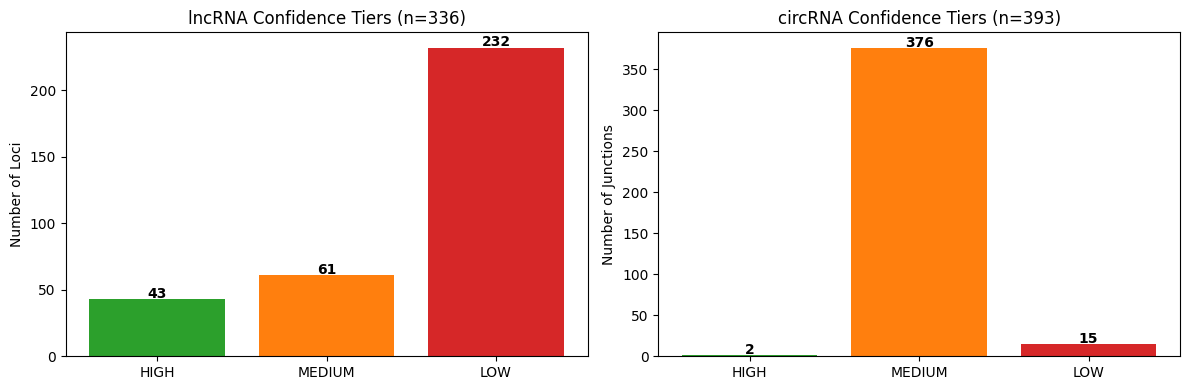


Saved: /content/phase3/confidence_tiers.png


In [ ]:
# ============================================================
# Cell 125 — Confidence Tier Assignment + Visualisation
# ============================================================
# Composite scoring:
#   lncRNA (0–4 pts): recurrence + structure + noncoding_rank  (unchanged)
#   circRNA (0–5 pts): recurrence + canonical splice + exons + circle length
# CPC2 coding_probability is LIBSVM Platt-scaled output — used as
# continuous ranking feature (bottom quartile), NOT a hard threshold.

import matplotlib.pyplot as plt

# ─── lncRNA Confidence Tiers (UNCHANGED) ───────────────────

# 1. Merge CPC2 coding_probability per locus (use minimum = most noncoding)
#    df_noncoding has 'ID' (transcript_id) and 'coding_probability'
tid_coding_prob = dict(zip(df_noncoding['ID'], df_noncoding['coding_probability']))

lnc_locus_min_cp = []
for _, row in df_lnc_loci.iterrows():
    tids = [t.strip() for t in row['transcript_ids'].split(',')]
    probs = [tid_coding_prob[t] for t in tids if t in tid_coding_prob]
    lnc_locus_min_cp.append(min(probs) if probs else np.nan)

df_lnc_loci['min_coding_probability'] = lnc_locus_min_cp

# 2. Compute Q25 threshold for noncoding_rank_pts
q25 = df_lnc_loci['min_coding_probability'].quantile(0.25)
print(f"CPC2 coding_probability Q25 = {q25:.4f}")

# 3. Score each locus
def lnc_score(row):
    pts = 0
    # recurrence
    if row['n_samples'] >= 3:
        pts += 2
    elif row['n_samples'] == 2:
        pts += 1
    # structure (multi-exonic)
    if row['max_exon_count'] >= 3:
        pts += 1
    # noncoding rank (bottom quartile = most confidently noncoding)
    if pd.notna(row['min_coding_probability']) and row['min_coding_probability'] <= q25:
        pts += 1
    return pts

df_lnc_loci['confidence_score'] = df_lnc_loci.apply(lnc_score, axis=1)
df_lnc_loci['confidence_tier'] = df_lnc_loci['confidence_score'].map(
    lambda s: 'HIGH' if s >= 3 else ('MEDIUM' if s == 2 else 'LOW'))

# ─── circRNA Confidence Tiers (NEW — 0-5 pts) ─────────────
# Scoring based on real CIRI-long metrics:
#   +2  recurrence: n_samples >= 3  (or +1 if n_samples == 2)
#   +1  canonical splice: has_canonical_splice == True
#   +1  multi-exonic: max_n_exons >= 2
#   +1  circle length: max_circle_length >= 200 bp
# Tiers: HIGH ≥ 4, MEDIUM 2–3, LOW ≤ 1

def circ_score(row):
    pts = 0
    # recurrence
    if row['n_samples'] >= 3:
        pts += 2
    elif row['n_samples'] == 2:
        pts += 1
    # canonical splice signal (AG-GT)
    if row.get('has_canonical_splice', False):
        pts += 1
    # multi-exonic
    if row.get('max_n_exons', 0) >= 2:
        pts += 1
    # circle length ≥ 200 bp
    if row.get('max_circle_length', 0) >= 200:
        pts += 1
    return pts

df_circ_loci['confidence_score'] = df_circ_loci.apply(circ_score, axis=1)
df_circ_loci['confidence_tier'] = df_circ_loci['confidence_score'].map(
    lambda s: 'HIGH' if s >= 4 else ('MEDIUM' if s >= 2 else 'LOW'))

# ─── Shared tier sort map (used by final-table cells) ─────
tier_order_map = {'HIGH': 0, 'MEDIUM': 1, 'LOW': 2}

# ─── Print distributions ──────────────────────────────────
print(f"\n=== lncRNA Confidence Tiers ({len(df_lnc_loci)} loci) ===")
print(df_lnc_loci['confidence_tier'].value_counts().to_string())
print(f"\nScore breakdown:")
print(df_lnc_loci['confidence_score'].value_counts().sort_index().to_string())

print(f"\n=== circRNA Confidence Tiers ({len(df_circ_loci)} junctions) ===")
print(df_circ_loci['confidence_tier'].value_counts().to_string())
print(f"\nScore breakdown:")
print(df_circ_loci['confidence_score'].value_counts().sort_index().to_string())

# ─── Visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# lncRNA tier bar chart
tier_order = ['HIGH', 'MEDIUM', 'LOW']
colors = {'HIGH': '#2ca02c', 'MEDIUM': '#ff7f0e', 'LOW': '#d62728'}
lnc_counts = df_lnc_loci['confidence_tier'].value_counts().reindex(tier_order, fill_value=0)
axes[0].bar(lnc_counts.index, lnc_counts.values,
            color=[colors[t] for t in lnc_counts.index])
axes[0].set_title(f'lncRNA Confidence Tiers (n={len(df_lnc_loci)})')
axes[0].set_ylabel('Number of Loci')
for i, v in enumerate(lnc_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# circRNA tier bar chart
circ_counts = df_circ_loci['confidence_tier'].value_counts().reindex(tier_order, fill_value=0)
axes[1].bar(circ_counts.index, circ_counts.values,
            color=[colors[t] for t in circ_counts.index])
axes[1].set_title(f'circRNA Confidence Tiers (n={len(df_circ_loci)})')
axes[1].set_ylabel('Number of Junctions')
for i, v in enumerate(circ_counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{LOCAL3}/confidence_tiers.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {LOCAL3}/confidence_tiers.png")

### Block 1 — QC Summary

| Metric | lncRNA | circRNA |
|--------|--------|---------|
| Input candidates | from `df_noncoding` (931 rows) | from `df_circ` (395 rows) |
| After locus grouping / junction dedup | `df_lnc_loci` loci | `df_circ_loci` junctions |
| Confidence tiers assigned | ✅ | ✅ |

**Next**: Block 2 cross-references these candidates against known databases, classifies genomic context, and compares with GTEx normal brain expression.

## Block 2 — Biology: Database Cross-Reference, Genomic Context & GTEx

**Goal**: Determine whether each candidate is already catalogued, classify its genomic context (intergenic / intronic / antisense), and check expression of the nearest gene in normal brain tissue (GTEx V8).

**Databases**:
- **LNCipedia v5.2** (high-confidence set, hg38 BED)
- **NONCODE v6** (human lncRNA, hg38) — server unreliable, optional
- **circAtlas 2.0** (human hg38 circRNA) — server unreliable, optional
- **GTEx V8** (median gene TPM across 54 tissues, includes 13 brain regions)

In [ ]:
# ============================================================
# Cell 128 — Download Reference Databases
# ============================================================
# LNCipedia v5.2 (lncRNA) — reliable
# GENCODE v44 lncRNA (replaces NONCODE, whose server is unreliable)
# circBase (hg19 → UCSC liftOver → hg38) replaces circAtlas (server down)
# MiOncoCirc (cancer long-read BSJ, Vo et al. 2019) — hg19 → hg38
# isoCirc (full-length PacBio long-read, Gao et al. 2021) — hg19 → hg38

import os, subprocess, gzip

DB_DIR = f'{LOCAL3}/databases'
os.makedirs(DB_DIR, exist_ok=True)

# ── LNCipedia v5.2 High-Confidence hg38 BED ──
lncipedia_bed = f'{DB_DIR}/lncipedia_5_2_hc_hg38.bed'
if not os.path.exists(lncipedia_bed):
    print("Downloading LNCipedia v5.2 HC hg38 BED...")
    r = subprocess.run(
        f'wget -q --timeout=120 -O {lncipedia_bed} '
        f'"https://lncipedia.org/downloads/lncipedia_5_2/high-confidence-set/lncipedia_5_2_hc_hg38.bed"',
        shell=True)
    if r.returncode != 0 or os.path.getsize(lncipedia_bed) < 1000:
        print("  ⚠ LNCipedia download failed")
        if os.path.exists(lncipedia_bed):
            os.remove(lncipedia_bed)
    else:
        subprocess.run(f'sort -k1,1 -k2,2n {lncipedia_bed} -o {lncipedia_bed}',
                       shell=True, check=True)
        n_lines = int(subprocess.check_output(f'wc -l < {lncipedia_bed}', shell=True))
        print(f"  ✓ LNCipedia: {n_lines} entries")
else:
    n_lines = int(subprocess.check_output(f'wc -l < {lncipedia_bed}', shell=True))
    print(f"LNCipedia already downloaded: {n_lines} entries")

# ── GENCODE v44 lncRNA GTF → BED (replaces NONCODE) ──
gencode_lncrna_bed = f'{DB_DIR}/gencode_v44_lncRNA_genes_hg38.bed'
gencode_gtf_gz = f'{DB_DIR}/gencode.v44.long_noncoding_RNAs.gtf.gz'
if not os.path.exists(gencode_lncrna_bed):
    print("Downloading GENCODE v44 lncRNA annotations...")
    r = subprocess.run(
        f'wget -q --timeout=120 -O {gencode_gtf_gz} '
        f'"https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_44/'
        f'gencode.v44.long_noncoding_RNAs.gtf.gz"',
        shell=True)
    if r.returncode != 0 or not os.path.exists(gencode_gtf_gz) or os.path.getsize(gencode_gtf_gz) < 10000:
        print("  ⚠ GENCODE download failed")
        if os.path.exists(gencode_gtf_gz):
            os.remove(gencode_gtf_gz)
    else:
        # Parse GTF gene entries → BED6
        n_genes = 0
        with gzip.open(gencode_gtf_gz, 'rt') as fin, open(gencode_lncrna_bed, 'w') as fout:
            for line in fin:
                if line.startswith('#'):
                    continue
                cols = line.strip().split('\t')
                if cols[2] != 'gene':
                    continue
                chrom = cols[0]
                start = str(int(cols[3]) - 1)  # GTF 1-based → BED 0-based
                end = cols[4]
                strand = cols[6]
                # Extract gene_name from attributes
                gene_name = '.'
                for attr in cols[8].split(';'):
                    attr = attr.strip()
                    if attr.startswith('gene_name'):
                        gene_name = attr.split('"')[1]
                        break
                fout.write(f'{chrom}\t{start}\t{end}\t{gene_name}\t0\t{strand}\n')
                n_genes += 1
        subprocess.run(f'sort -k1,1 -k2,2n {gencode_lncrna_bed} -o {gencode_lncrna_bed}',
                       shell=True, check=True)
        print(f"  ✓ GENCODE lncRNA: {n_genes} genes")
else:
    n_lines = int(subprocess.check_output(f'wc -l < {gencode_lncrna_bed}', shell=True))
    print(f"GENCODE lncRNA already processed: {n_lines} genes")

# ── Helper: normalise a hg19 BED for liftOver ──
# Strips header/comment/track lines and adds 'chr' prefix if missing.
def _normalise_bed_for_liftover(bed_path):
    fixed = []
    with open(bed_path) as fin:
        for line in fin:
            if line.startswith('#') or line.startswith('track') or line.startswith('browser'):
                continue
            cols = line.strip().split('\t')
            if len(cols) < 3:
                continue
            if not cols[0].startswith('chr'):
                cols[0] = 'chr' + cols[0]
            fixed.append('\t'.join(cols) + '\n')
    with open(bed_path, 'w') as fout:
        fout.writelines(fixed)
    return len(fixed)

# ── circBase hg19 → liftOver to hg38 (replaces circAtlas) ──
circbase_bed = f'{DB_DIR}/circbase_human_hg38.bed'
if not os.path.exists(circbase_bed):
    print("Downloading circBase human circRNA (hg19)...")
    circbase_raw = f'{DB_DIR}/hsa_hg19_circRNA.txt'
    circbase_hg19 = f'{DB_DIR}/circbase_hg19.bed'
    dl_ok = False

    # Try TSV first
    r = subprocess.run(
        f'wget -q --timeout=120 -O {circbase_raw} '
        f'"http://www.circbase.org/download/hsa_hg19_circRNA.txt"',
        shell=True)
    if r.returncode == 0 and os.path.exists(circbase_raw) and os.path.getsize(circbase_raw) > 1000:
        # Parse TSV → BED6: detect columns from header
        with open(circbase_raw) as fin:
            header = fin.readline().strip().split('\t')
            col_map = {h.lower(): i for i, h in enumerate(header)}
            chr_i = col_map.get('chrom', col_map.get('chr', None))
            start_i = col_map.get('start', col_map.get('txstart', None))
            end_i = col_map.get('end', col_map.get('txend', None))
            strand_i = col_map.get('strand', None)
            name_i = col_map.get('name', col_map.get('circrna_id', col_map.get('#circrna_id', 0)))
            print(f"  Header columns: {header[:8]}...")
            print(f"  Detected: chr={chr_i}, start={start_i}, end={end_i}, strand={strand_i}, name={name_i}")

            if chr_i is not None and start_i is not None and end_i is not None:
                n_circ = 0
                with open(circbase_hg19, 'w') as fout:
                    for line in fin:
                        cols = line.strip().split('\t')
                        if len(cols) <= max(chr_i, start_i, end_i):
                            continue
                        chrom = cols[chr_i]
                        start = cols[start_i]
                        end = cols[end_i]
                        strand = cols[strand_i] if strand_i is not None and cols[strand_i] in ('+', '-') else '.'
                        name = cols[name_i] if name_i is not None else f'circ_{n_circ}'
                        fout.write(f'{chrom}\t{start}\t{end}\t{name}\t0\t{strand}\n')
                        n_circ += 1
                print(f"  circBase parsed: {n_circ} circRNAs (hg19)")
                dl_ok = True
            else:
                print("  ⚠ Could not detect columns in circBase TSV")

    if not dl_ok:
        # Fallback: try direct BED download
        print("  Trying circBase BED download...")
        r2 = subprocess.run(
            f'wget -q --timeout=120 -O {circbase_hg19} '
            f'"http://www.circbase.org/download/hsa_hg19_circRNA.bed"',
            shell=True)
        if r2.returncode == 0 and os.path.exists(circbase_hg19) and os.path.getsize(circbase_hg19) > 1000:
            n_circ = int(subprocess.check_output(f'wc -l < {circbase_hg19}', shell=True))
            print(f"  circBase BED: {n_circ} entries (hg19)")
            dl_ok = True

    # LiftOver hg19 → hg38
    if dl_ok and os.path.exists(circbase_hg19):
        print("  Running liftOver hg19 → hg38...")
        liftover_bin = f'{DB_DIR}/liftOver'
        chain_file = f'{DB_DIR}/hg19ToHg38.over.chain.gz'

        if not os.path.exists(liftover_bin):
            subprocess.run(
                f'wget -q --timeout=60 -O {liftover_bin} '
                f'"https://hgdownload.cse.ucsc.edu/admin/exe/linux.x86_64/liftOver"',
                shell=True, check=True)
            subprocess.run(f'chmod +x {liftover_bin}', shell=True, check=True)

        if not os.path.exists(chain_file):
            subprocess.run(
                f'wget -q --timeout=60 -O {chain_file} '
                f'"https://hgdownload.cse.ucsc.edu/goldenPath/hg19/liftOver/hg19ToHg38.over.chain.gz"',
                shell=True, check=True)

        _normalise_bed_for_liftover(circbase_hg19)
        unmapped = f'{DB_DIR}/circbase_unmapped.bed'
        r = subprocess.run(
            f'{liftover_bin} {circbase_hg19} {chain_file} {circbase_bed} {unmapped}',
            shell=True)

        if os.path.exists(circbase_bed) and os.path.getsize(circbase_bed) > 100:
            subprocess.run(f'sort -k1,1 -k2,2n {circbase_bed} -o {circbase_bed}',
                           shell=True, check=True)
            n_lifted = int(subprocess.check_output(f'wc -l < {circbase_bed}', shell=True))
            n_unmapped_lines = int(subprocess.check_output(f'wc -l < {unmapped}', shell=True))
            print(f"  ✓ circBase (hg38): {n_lifted} entries lifted, ~{n_unmapped_lines // 2} unmapped")
        else:
            print("  ⚠ liftOver failed — circBase unavailable for hg38")
            if os.path.exists(circbase_bed):
                os.remove(circbase_bed)
    elif not dl_ok:
        print("  ⚠ circBase download failed — skipping")
else:
    n_lines = int(subprocess.check_output(f'wc -l < {circbase_bed}', shell=True))
    print(f"circBase (hg38) already available: {n_lines} entries")

# ── Ensure liftOver tools available for additional long-read DBs ──
liftover_bin = f'{DB_DIR}/liftOver'
chain_file   = f'{DB_DIR}/hg19ToHg38.over.chain.gz'
if not os.path.exists(liftover_bin):
    subprocess.run(
        f'wget -q --timeout=60 -O {liftover_bin} '
        f'"https://hgdownload.cse.ucsc.edu/admin/exe/linux.x86_64/liftOver"',
        shell=True, check=True)
    subprocess.run(f'chmod +x {liftover_bin}', shell=True, check=True)
    print("  Downloaded liftOver binary")
if not os.path.exists(chain_file):
    subprocess.run(
        f'wget -q --timeout=60 -O {chain_file} '
        f'"https://hgdownload.cse.ucsc.edu/goldenPath/hg19/liftOver/hg19ToHg38.over.chain.gz"',
        shell=True, check=True)
    print("  Downloaded hg19→hg38 chain file")

# ── MiOncoCirc (cancer long-read, BSJ-only) hg19 → liftOver to hg38 ──
# Vo et al., Cancer Cell 2019 — circRNAs from 2000+ cancer clinical samples
mioncocirc_bed = f'{DB_DIR}/mioncocirc_hg38.bed'
if not os.path.exists(mioncocirc_bed):
    print("Downloading MiOncoCirc BSJ (hg19, cancer long-read)...")
    mioncocirc_raw_gz = f'{DB_DIR}/MiOncoCirc_BSJ_only_hg19.bed.gz'
    mioncocirc_hg19   = f'{DB_DIR}/mioncocirc_hg19.bed'
    dl_ok_mc = False
    r = subprocess.run(
        f'wget -q --timeout=120 -O {mioncocirc_raw_gz} '
        f'"https://raw.githubusercontent.com/Xinglab/isoCirc/main/results/MiOncoCirc_BSJ_only_hg19.bed.gz"',
        shell=True)
    if r.returncode == 0 and os.path.exists(mioncocirc_raw_gz) and os.path.getsize(mioncocirc_raw_gz) > 100:
        with gzip.open(mioncocirc_raw_gz, 'rb') as fin, open(mioncocirc_hg19, 'wb') as fout:
            fout.write(fin.read())
        n_mc = _normalise_bed_for_liftover(mioncocirc_hg19)
        print(f"  MiOncoCirc BSJ: {n_mc} entries (hg19, normalised)")
        dl_ok_mc = True
    else:
        print("  ⚠ MiOncoCirc download failed — skipping")
    if dl_ok_mc:
        unmapped_mc = f'{DB_DIR}/mioncocirc_unmapped.bed'
        subprocess.run(
            f'{liftover_bin} {mioncocirc_hg19} {chain_file} {mioncocirc_bed} {unmapped_mc}',
            shell=True)
        if os.path.exists(mioncocirc_bed) and os.path.getsize(mioncocirc_bed) > 100:
            subprocess.run(f'sort -k1,1 -k2,2n {mioncocirc_bed} -o {mioncocirc_bed}',
                           shell=True, check=True)
            n_lifted_mc = int(subprocess.check_output(f'wc -l < {mioncocirc_bed}', shell=True))
            n_unmap_mc  = int(subprocess.check_output(f'wc -l < {unmapped_mc}', shell=True))
            print(f"  ✓ MiOncoCirc (hg38): {n_lifted_mc} BSJs lifted, ~{n_unmap_mc//2} unmapped")
        else:
            print("  ⚠ liftOver produced no output — MiOncoCirc unavailable for hg38")
            if os.path.exists(mioncocirc_bed):
                os.remove(mioncocirc_bed)
else:
    n_lines = int(subprocess.check_output(f'wc -l < {mioncocirc_bed}', shell=True))
    print(f"MiOncoCirc (hg38) already available: {n_lines} BSJs")

# ── isoCirc (full-length long-read PacBio) hg19 → liftOver to hg38 ──
# Gao et al., Nat. Commun. 2021 — full-length circRNA isoforms from PacBio
isocirc_bed = f'{DB_DIR}/isocirc_hg38.bed'
if not os.path.exists(isocirc_bed):
    print("Downloading isoCirc all circRNAs (hg19, long-read PacBio)...")
    isocirc_raw_gz = f'{DB_DIR}/isoCirc_all_hg19.ucsc.bed.gz'
    isocirc_hg19   = f'{DB_DIR}/isocirc_hg19.bed'
    dl_ok_iso = False
    r = subprocess.run(
        f'wget -q --timeout=120 -O {isocirc_raw_gz} '
        f'"https://raw.githubusercontent.com/Xinglab/isoCirc/main/results/isoCirc_all_hg19.ucsc.bed.gz"',
        shell=True)
    if r.returncode == 0 and os.path.exists(isocirc_raw_gz) and os.path.getsize(isocirc_raw_gz) > 100:
        with gzip.open(isocirc_raw_gz, 'rb') as fin, open(isocirc_hg19, 'wb') as fout:
            fout.write(fin.read())
        n_iso = _normalise_bed_for_liftover(isocirc_hg19)
        print(f"  isoCirc: {n_iso} entries (hg19, normalised)")
        dl_ok_iso = True
    else:
        print("  ⚠ isoCirc download failed — skipping")
    if dl_ok_iso:
        unmapped_iso = f'{DB_DIR}/isocirc_unmapped.bed'
        subprocess.run(
            f'{liftover_bin} {isocirc_hg19} {chain_file} {isocirc_bed} {unmapped_iso}',
            shell=True)
        if os.path.exists(isocirc_bed) and os.path.getsize(isocirc_bed) > 100:
            subprocess.run(f'sort -k1,1 -k2,2n {isocirc_bed} -o {isocirc_bed}',
                           shell=True, check=True)
            n_lifted_iso = int(subprocess.check_output(f'wc -l < {isocirc_bed}', shell=True))
            n_unmap_iso  = int(subprocess.check_output(f'wc -l < {unmapped_iso}', shell=True))
            print(f"  ✓ isoCirc (hg38): {n_lifted_iso} entries lifted, ~{n_unmap_iso//2} unmapped")
        else:
            print("  ⚠ liftOver produced no output — isoCirc unavailable for hg38")
            if os.path.exists(isocirc_bed):
                os.remove(isocirc_bed)
else:
    n_lines = int(subprocess.check_output(f'wc -l < {isocirc_bed}', shell=True))
    print(f"isoCirc (hg38) already available: {n_lines} entries")

# ── Summary ──
db_available = {
    'LNCipedia': os.path.exists(lncipedia_bed),
    'GENCODE lncRNA': os.path.exists(gencode_lncrna_bed),
    'circBase (hg38)': os.path.exists(circbase_bed),
    'MiOncoCirc (hg38)': os.path.exists(mioncocirc_bed),
    'isoCirc (hg38)': os.path.exists(isocirc_bed),
}
print(f"\n=== Database Availability ===")
for db, avail in db_available.items():
    print(f"  {db}: {'✓ available' if avail else '✗ unavailable'}")

LNCipedia already downloaded: 107039 entries
GENCODE lncRNA already processed: 19922 genes
circBase (hg38) already available: 92135 entries
MiOncoCirc (hg38) already available: 236791 BSJs
isoCirc (hg38) already available: 465348 entries

=== Database Availability ===
  LNCipedia: ✓ available
  GENCODE lncRNA: ✓ available
  circBase (hg38): ✓ available
  MiOncoCirc (hg38): ✓ available
  isoCirc (hg38): ✓ available


In [ ]:
# ============================================================
# Cell 129 — lncRNA Database Cross-Reference
# ============================================================
# bedtools intersect -wao -s against available lncRNA databases.
# A locus is "known" if it overlaps ≥ 1 entry in any database.

import subprocess, os

loci_bed = f'{LOCAL3}/lncrna_loci.sorted.bed'

# ── Intersect with LNCipedia ──
lnc_in_lncipedia = set()
if os.path.exists(lncipedia_bed):
    out_file = f'{LOCAL3}/lnc_vs_lncipedia.tsv'
    subprocess.run(
        f'bedtools intersect -a {loci_bed} -b {lncipedia_bed} -wao -s > {out_file}',
        shell=True, check=True)
    with open(out_file) as fh:
        for line in fh:
            cols = line.strip().split('\t')
            overlap = int(cols[-1])
            if overlap > 0:
                locus_id = cols[3]  # col4 = locus_id in our BED
                lnc_in_lncipedia.add(locus_id)
    print(f"LNCipedia hits: {len(lnc_in_lncipedia)} / {len(df_lnc_loci)} loci")
else:
    print("LNCipedia: not available — skipping")

# ── Intersect with GENCODE v44 lncRNA ──
lnc_in_gencode = set()
if os.path.exists(gencode_lncrna_bed):
    out_file = f'{LOCAL3}/lnc_vs_gencode.tsv'
    subprocess.run(
        f'bedtools intersect -a {loci_bed} -b {gencode_lncrna_bed} -wao -s > {out_file}',
        shell=True, check=True)
    with open(out_file) as fh:
        for line in fh:
            cols = line.strip().split('\t')
            overlap = int(cols[-1])
            if overlap > 0:
                locus_id = cols[3]
                lnc_in_gencode.add(locus_id)
    print(f"GENCODE lncRNA hits: {len(lnc_in_gencode)} / {len(df_lnc_loci)} loci")
else:
    print("GENCODE lncRNA: not available — skipping")

# ── Assign db_status ──
df_lnc_loci['in_LNCipedia'] = df_lnc_loci['locus_id'].isin(lnc_in_lncipedia)
df_lnc_loci['in_GENCODE'] = df_lnc_loci['locus_id'].isin(lnc_in_gencode) if os.path.exists(gencode_lncrna_bed) else np.nan

df_lnc_loci['db_status'] = df_lnc_loci.apply(
    lambda r: 'known' if r['in_LNCipedia'] or (r['in_GENCODE'] is True) else 'novel', axis=1)

# ── Summary ──
print(f"\n=== lncRNA Database Cross-Reference ===")
print(df_lnc_loci['db_status'].value_counts().to_string())
print(f"\nNovel + HIGH confidence: {len(df_lnc_loci[(df_lnc_loci['db_status']=='novel') & (df_lnc_loci['confidence_tier']=='HIGH')])}")
print(f"Novel + MEDIUM confidence: {len(df_lnc_loci[(df_lnc_loci['db_status']=='novel') & (df_lnc_loci['confidence_tier']=='MEDIUM')])}")

LNCipedia hits: 269 / 336 loci
GENCODE lncRNA hits: 289 / 336 loci

=== lncRNA Database Cross-Reference ===
db_status
known    307
novel     29

Novel + HIGH confidence: 5
Novel + MEDIUM confidence: 4


In [ ]:
# ============================================================
# Cell 130 — circRNA Database Cross-Reference
# ============================================================
# Cross-reference detected junctions against three databases:
#   1. circBase (hg38) — short-read, hg19→liftOver, ~140 k human BSJs
#   2. MiOncoCirc (hg38) — long-read cancer clinical samples (Vo et al. 2019)
#   3. isoCirc (hg38) — full-length long-read PacBio atlas (Gao et al. 2021)
# CIRI-long reports 1-based coordinates; all BED files use 0-based start.
# Matching strategies: (1) exact, (2) start-1 offset, (3) bedtools 90% overlap.

import os, subprocess

circ_loci_bed = f'{LOCAL3}/circ_loci.sorted.bed'

def _load_junctions(bed_path):
    # Return (set_with_strand, set_no_strand) from a BED6+ file
    with_strand, no_strand = set(), set()
    with open(bed_path) as fh:
        for line in fh:
            cols = line.strip().split('\t')
            if len(cols) < 3:
                continue
            chrom, start, end = cols[0], cols[1], cols[2]
            strand = cols[5] if len(cols) >= 6 else '.'
            with_strand.add((chrom, start, end, strand))
            no_strand.add((chrom, start, end))
    return with_strand, no_strand

def _match_junctions(df, junc_ws, junc_ns):
    # Return set of circ_locus_ids matching via exact or start-1 offset
    hits = set()
    for _, row in df.iterrows():
        chrom  = str(row['chr'])
        start  = str(int(row['start']))
        start1 = str(int(row['start']) - 1)
        end    = str(int(row['end']))
        strand = str(row['strand'])
        lid    = row['circ_locus_id']
        if (chrom, start, end, strand) in junc_ws or (chrom, start, end) in junc_ns:
            hits.add(lid); continue
        if (chrom, start1, end, strand) in junc_ws or (chrom, start1, end) in junc_ns:
            hits.add(lid)
    return hits

def _bedtools_overlap(circ_bed, db_bed, local3, tag, existing_hits):
    # bedtools 90% reciprocal overlap; returns augmented set
    out_file = f'{local3}/circ_vs_{tag}.tsv'
    subprocess.run(
        f'bedtools intersect -a {circ_bed} -b {db_bed} -f 0.9 -r -wao > {out_file}',
        shell=True, check=True)
    hits = set(existing_hits)
    new_hits = 0
    with open(out_file) as fh:
        for line in fh:
            cols = line.strip().split('\t')
            if int(cols[-1]) > 0:
                lid = cols[3]
                if lid not in hits:
                    new_hits += 1
                hits.add(lid)
    print(f"  bedtools additional hits ({tag}): {new_hits}")
    return hits

# ── circBase (short-read) ──
circ_in_circbase = set()
if os.path.exists(circbase_bed):
    jws, jns = _load_junctions(circbase_bed)
    print(f"circBase entries loaded (hg38): {len(jws)}")
    circ_in_circbase = _match_junctions(df_circ_loci, jws, jns)
    print(f"  Exact/offset hits: {len(circ_in_circbase)}")
    if len(circ_in_circbase) < len(df_circ_loci) * 0.5:
        circ_in_circbase = _bedtools_overlap(circ_loci_bed, circbase_bed, LOCAL3, 'circbase', circ_in_circbase)
    print(f"  circBase total hits: {len(circ_in_circbase)} / {len(df_circ_loci)}")
else:
    print("circBase: not available")

# ── MiOncoCirc (cancer long-read) ──
circ_in_mioncocirc = set()
if os.path.exists(mioncocirc_bed):
    jws, jns = _load_junctions(mioncocirc_bed)
    print(f"\nMiOncoCirc entries loaded (hg38): {len(jws)}")
    circ_in_mioncocirc = _match_junctions(df_circ_loci, jws, jns)
    print(f"  Exact/offset hits: {len(circ_in_mioncocirc)}")
    if len(circ_in_mioncocirc) < len(df_circ_loci) * 0.5:
        circ_in_mioncocirc = _bedtools_overlap(circ_loci_bed, mioncocirc_bed, LOCAL3, 'mioncocirc', circ_in_mioncocirc)
    print(f"  MiOncoCirc total hits: {len(circ_in_mioncocirc)} / {len(df_circ_loci)}")
else:
    print("MiOncoCirc: not available")

# ── isoCirc (long-read PacBio atlas) ──
circ_in_isocirc = set()
if os.path.exists(isocirc_bed):
    jws, jns = _load_junctions(isocirc_bed)
    print(f"\nisoCirc entries loaded (hg38): {len(jws)}")
    circ_in_isocirc = _match_junctions(df_circ_loci, jws, jns)
    print(f"  Exact/offset hits: {len(circ_in_isocirc)}")
    if len(circ_in_isocirc) < len(df_circ_loci) * 0.5:
        circ_in_isocirc = _bedtools_overlap(circ_loci_bed, isocirc_bed, LOCAL3, 'isocirc', circ_in_isocirc)
    print(f"  isoCirc total hits: {len(circ_in_isocirc)} / {len(df_circ_loci)}")
else:
    print("isoCirc: not available")

# ── Assign per-DB boolean columns ──
df_circ_loci['in_circBase']   = df_circ_loci['circ_locus_id'].isin(circ_in_circbase)
df_circ_loci['in_mioncocirc'] = df_circ_loci['circ_locus_id'].isin(circ_in_mioncocirc)
df_circ_loci['in_isocirc']    = df_circ_loci['circ_locus_id'].isin(circ_in_isocirc)

# ── db_status: 'known' if in any DB, 'novel' if in none ──
any_db_available = any([os.path.exists(circbase_bed),
                         os.path.exists(mioncocirc_bed),
                         os.path.exists(isocirc_bed)])
if any_db_available:
    in_any = (df_circ_loci['in_circBase'] |
              df_circ_loci['in_mioncocirc'] |
              df_circ_loci['in_isocirc'])
    df_circ_loci['db_status'] = in_any.map({True: 'known', False: 'novel'})
else:
    df_circ_loci['db_status'] = 'unknown'

# ── Summary ──
print(f"\n=== circRNA Database Cross-Reference ===")
print(df_circ_loci['db_status'].value_counts().to_string())
print(f"\n  in_circBase (short-read):   {df_circ_loci['in_circBase'].sum()}")
print(f"  in_mioncocirc (cancer LR):  {df_circ_loci['in_mioncocirc'].sum()}")
print(f"  in_isocirc (PacBio atlas):  {df_circ_loci['in_isocirc'].sum()}")
print(f"  in long-read (either):      {(df_circ_loci['in_mioncocirc'] | df_circ_loci['in_isocirc']).sum()}")
if any_db_available:
    print(f"\nNovel + HIGH:   {len(df_circ_loci[(df_circ_loci['db_status']=='novel') & (df_circ_loci['confidence_tier']=='HIGH')])}")
    print(f"Novel + MEDIUM: {len(df_circ_loci[(df_circ_loci['db_status']=='novel') & (df_circ_loci['confidence_tier']=='MEDIUM')])}")

circBase entries loaded (hg38): 92102
  Exact/offset hits: 0
  bedtools additional hits (circbase): 3
  circBase total hits: 3 / 393

MiOncoCirc entries loaded (hg38): 236790
  Exact/offset hits: 0
  bedtools additional hits (mioncocirc): 1
  MiOncoCirc total hits: 1 / 393

isoCirc entries loaded (hg38): 162378
  Exact/offset hits: 0
  bedtools additional hits (isocirc): 5
  isoCirc total hits: 5 / 393

=== circRNA Database Cross-Reference ===
db_status
novel    388
known      5

  in_circBase (short-read):   3
  in_mioncocirc (cancer LR):  1
  in_isocirc (PacBio atlas):  5
  in long-read (either):      5

Novel + HIGH:   2
Novel + MEDIUM: 371


In [ ]:
# ============================================================
# Cell 131 — Genomic Context Classification (lncRNA)
# ============================================================
# Classify each lncRNA locus as:
#   - intronic_sense  (within a protein-coding gene, same strand — exon overlap
#                      already removed by FEELnc in Phase 2)
#   - antisense       (overlaps a protein-coding gene, opposite strand)
#   - intergenic      (no overlap with protein-coding genes)

import subprocess, os

ANNOTATION_GTF = f'{REF_DIR}/annotation.gtf'

# ── Step 1: Extract protein-coding gene bodies from GENCODE ──
pc_genes_gtf = f'{LOCAL3}/pc_genes.gtf'
pc_genes_bed = f'{LOCAL3}/pc_genes.sorted.bed'

if not os.path.exists(pc_genes_bed):
    # Extract gene lines with gene_type "protein_coding"
    subprocess.run(
        f'''awk '$3=="gene"' {ANNOTATION_GTF} | grep 'gene_type "protein_coding"' > {pc_genes_gtf}''',
        shell=True, check=True)

    # Convert to BED6: chr, start(0-based), end, gene_id, 0, strand
    with open(pc_genes_gtf) as fin, open(pc_genes_bed, 'w') as fout:
        for line in fin:
            if line.startswith('#'):
                continue
            cols = line.strip().split('\t')
            chrom = cols[0]
            start = int(cols[3]) - 1  # 0-based
            end = int(cols[4])
            strand = cols[6]
            # Extract gene_id and gene_name
            import re as _re
            gid_m = _re.search(r'gene_id "([^"]+)"', cols[8])
            gname_m = _re.search(r'gene_name "([^"]+)"', cols[8])
            gene_id = gid_m.group(1) if gid_m else '.'
            gene_name = gname_m.group(1) if gname_m else gene_id
            fout.write(f'{chrom}\t{start}\t{end}\t{gene_name}\t{gene_id}\t{strand}\n')

    # Sort
    subprocess.run(f'sort -k1,1 -k2,2n {pc_genes_bed} -o {pc_genes_bed}',
                   shell=True, check=True)
    n_genes = int(subprocess.check_output(f'wc -l < {pc_genes_bed}', shell=True))
    print(f"Protein-coding genes extracted: {n_genes}")
else:
    n_genes = int(subprocess.check_output(f'wc -l < {pc_genes_bed}', shell=True))
    print(f"Protein-coding genes BED exists: {n_genes} genes")

loci_bed = f'{LOCAL3}/lncrna_loci.sorted.bed'

# ── Step 2: Same-strand overlap → intronic_sense ──
same_strand_out = f'{LOCAL3}/lnc_vs_pc_same_strand.tsv'
subprocess.run(
    f'bedtools intersect -a {loci_bed} -b {pc_genes_bed} -wao -s > {same_strand_out}',
    shell=True, check=True)

intronic_sense = set()
with open(same_strand_out) as fh:
    for line in fh:
        cols = line.strip().split('\t')
        overlap = int(cols[-1])
        if overlap > 0:
            intronic_sense.add(cols[3])  # locus_id

# ── Step 3: Opposite-strand overlap → antisense ──
opp_strand_out = f'{LOCAL3}/lnc_vs_pc_opp_strand.tsv'
subprocess.run(
    f'bedtools intersect -a {loci_bed} -b {pc_genes_bed} -wao -S > {opp_strand_out}',
    shell=True, check=True)

antisense = set()
with open(opp_strand_out) as fh:
    for line in fh:
        cols = line.strip().split('\t')
        overlap = int(cols[-1])
        if overlap > 0:
            antisense.add(cols[3])

# ── Step 4: Assign context ──
def classify_context(locus_id):
    if locus_id in intronic_sense:
        return 'intronic_sense'
    elif locus_id in antisense:
        return 'antisense'
    else:
        return 'intergenic'

df_lnc_loci['genomic_context'] = df_lnc_loci['locus_id'].apply(classify_context)

# ── Summary ──
print(f"\n=== lncRNA Genomic Context ===")
print(df_lnc_loci['genomic_context'].value_counts().to_string())
print(f"\nContext × Confidence Tier:")
ct = pd.crosstab(df_lnc_loci['genomic_context'], df_lnc_loci['confidence_tier'])
print(ct.to_string())

Protein-coding genes BED exists: 20065 genes

=== lncRNA Genomic Context ===
genomic_context
intergenic        208
antisense         102
intronic_sense     26

Context × Confidence Tier:
confidence_tier  HIGH  LOW  MEDIUM
genomic_context                   
antisense          15   69      18
intergenic         25  146      37
intronic_sense      3   17       6


In [ ]:
# ============================================================
# Cell 132 — circRNA Host Gene Annotation
# ============================================================
# bedtools intersect to find which protein-coding gene (if any)
# each circRNA junction falls within. Same-strand overlap.

import subprocess

circ_loci_bed = f'{LOCAL3}/circ_loci.sorted.bed'
pc_genes_bed = f'{LOCAL3}/pc_genes.sorted.bed'

circ_host_out = f'{LOCAL3}/circ_vs_pc_genes.tsv'
subprocess.run(
    f'bedtools intersect -a {circ_loci_bed} -b {pc_genes_bed} -wao -s > {circ_host_out}',
    shell=True, check=True)

# Parse: pick the host gene with the largest overlap for each junction
host_gene_map = {}   # circ_locus_id → (gene_name, gene_id)
best_overlap = {}    # circ_locus_id → overlap_bp

with open(circ_host_out) as fh:
    for line in fh:
        cols = line.strip().split('\t')
        circ_id = cols[3]  # circ_locus_id
        overlap = int(cols[-1])

        if overlap > 0:
            # Our circ BED: chr(0), start(1), end(2), circ_locus_id(3), score(4), strand(5)
            # PC genes BED: chr(6), start(7), end(8), gene_name(9), gene_id(10), strand(11)
            gene_name = cols[9]
            gene_id = cols[10]

            if circ_id not in best_overlap or overlap > best_overlap[circ_id]:
                best_overlap[circ_id] = overlap
                host_gene_map[circ_id] = (gene_name, gene_id)

# Assign to DataFrame
df_circ_loci['host_gene'] = df_circ_loci['circ_locus_id'].map(
    lambda x: host_gene_map.get(x, ('intergenic', None))[0])
df_circ_loci['host_gene_id'] = df_circ_loci['circ_locus_id'].map(
    lambda x: host_gene_map.get(x, (None, None))[1])

# Summary
n_genic = (df_circ_loci['host_gene'] != 'intergenic').sum()
n_intergenic = (df_circ_loci['host_gene'] == 'intergenic').sum()
print(f"=== circRNA Host Gene Annotation ===")
print(f"Genic (within protein-coding gene): {n_genic}")
print(f"Intergenic: {n_intergenic}")
print(f"\nTop 10 host genes:")
print(df_circ_loci[df_circ_loci['host_gene'] != 'intergenic']['host_gene'].value_counts().head(10).to_string())

=== circRNA Host Gene Annotation ===
Genic (within protein-coding gene): 254
Intergenic: 139

Top 10 host genes:
host_gene
MT-ND6     16
MT-CO1     13
MT-ND1      7
MT-ND5      6
NMT1        5
SLC17A5     4
UBC         2
ATF7IP      2
MICOS13     2
KASH5       2


In [ ]:
# ============================================================
# Cell 133 — Download + Parse GTEx V8 Median Gene TPM
# ============================================================
# GTEx V8 gene-level median TPM across 54 tissues (GCT format, ~6.6 MB).
# Extract the 13 brain tissue columns and compute max_brain_tpm per gene.
# Uses GENCODE v26 ENSG IDs — backward compatible with v46.

import os, subprocess, gzip

GTEX_URL = 'https://storage.googleapis.com/adult-gtex/bulk-gex/v8/rna-seq/GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_median_tpm.gct.gz'
gtex_gz = f'{LOCAL3}/databases/gtex_median_tpm.gct.gz'
gtex_tsv = f'{LOCAL3}/databases/gtex_median_tpm.gct'

os.makedirs(f'{LOCAL3}/databases', exist_ok=True)

if not os.path.exists(gtex_tsv):
    if not os.path.exists(gtex_gz):
        print("Downloading GTEx V8 median gene TPM (~6.6 MB)...")
        r = subprocess.run(
            f'wget -q --timeout=120 -O {gtex_gz} "{GTEX_URL}"',
            shell=True)
        if r.returncode != 0:
            print("⚠ GTEx download failed!")
        else:
            print("  ✓ Downloaded")

    if os.path.exists(gtex_gz):
        print("Decompressing...")
        with gzip.open(gtex_gz, 'rt') as fin, open(gtex_tsv, 'w') as fout:
            fout.write(fin.read())
        print("  ✓ Decompressed")
else:
    print("GTEx file already exists")

# ── Parse GCT format ──
# Line 1: #1.2
# Line 2: <n_rows> <n_cols>
# Line 3: header row (Name, Description, tissue1, tissue2, ...)
# Lines 4+: gene_id, gene_name, tpm1, tpm2, ...

brain_tpm = {}  # gene_id (ENSG without version) → max_brain_tpm
gene_name_map = {}  # gene_name → gene_id (for lookup by name)

if os.path.exists(gtex_tsv):
    with open(gtex_tsv) as fh:
        # Skip first 2 GCT header lines
        fh.readline()
        fh.readline()

        # Read column header
        header = fh.readline().strip().split('\t')
        # Find brain tissue columns
        brain_cols = [i for i, col in enumerate(header) if col.startswith('Brain')]
        brain_names = [header[i] for i in brain_cols]
        print(f"Brain tissue columns found: {len(brain_names)}")
        for bn in brain_names:
            print(f"  - {bn}")

        # Parse data lines
        for line in fh:
            cols = line.strip().split('\t')
            gene_id_full = cols[0]  # e.g. ENSG00000223972.5
            gene_name = cols[1]
            gene_id = gene_id_full.split('.')[0]  # strip version

            brain_vals = []
            for ci in brain_cols:
                try:
                    brain_vals.append(float(cols[ci]))
                except (ValueError, IndexError):
                    pass

            if brain_vals:
                brain_tpm[gene_id] = max(brain_vals)
                gene_name_map[gene_name] = gene_id

    print(f"\nGenes with brain TPM data: {len(brain_tpm)}")
    # Quick stats
    import numpy as np
    vals = list(brain_tpm.values())
    print(f"Max brain TPM range: {min(vals):.2f} – {max(vals):.2f}")
    print(f"Genes with max_brain_tpm < 1.0: {sum(1 for v in vals if v < 1.0)}")
    print(f"Genes with max_brain_tpm >= 1.0: {sum(1 for v in vals if v >= 1.0)}")
else:
    print("⚠ GTEx file not available — GTEx comparison will be skipped")

GTEx file already exists
Brain tissue columns found: 13
  - Brain - Amygdala
  - Brain - Anterior cingulate cortex (BA24)
  - Brain - Caudate (basal ganglia)
  - Brain - Cerebellar Hemisphere
  - Brain - Cerebellum
  - Brain - Cortex
  - Brain - Frontal Cortex (BA9)
  - Brain - Hippocampus
  - Brain - Hypothalamus
  - Brain - Nucleus accumbens (basal ganglia)
  - Brain - Putamen (basal ganglia)
  - Brain - Spinal cord (cervical c-1)
  - Brain - Substantia nigra

Genes with brain TPM data: 56156
Max brain TPM range: 0.00 – 91691.20
Genes with max_brain_tpm < 1.0: 35785
Genes with max_brain_tpm >= 1.0: 20371


In [ ]:
# ============================================================
# Cell 134 — GTEx Comparison: Normal Brain Expression
# ============================================================
# For lncRNA: find nearest protein-coding gene via bedtools closest,
#   then look up that gene's max brain TPM from GTEx.
# For circRNA: use host_gene (from Cell 132) to look up brain TPM.
#
# Label: "low_normal_brain_expression" — does NOT prove tumor specificity.
# Caveat: GTEx uses short-read bulk RNA-seq, which may miss low-abundance
# or cell-type-specific transcripts.

import subprocess

loci_bed = f'{LOCAL3}/lncrna_loci.sorted.bed'
pc_genes_bed = f'{LOCAL3}/pc_genes.sorted.bed'

# ── lncRNA: bedtools closest ──
closest_out = f'{LOCAL3}/lnc_closest_gene.tsv'
subprocess.run(
    f'bedtools closest -a {loci_bed} -b {pc_genes_bed} -s -d -t first > {closest_out}',
    shell=True, check=True)

# Parse: loci_bed cols (0-5) + pc_bed cols (6-11) + distance (12)
nearest_gene_data = {}  # locus_id → (gene_name, gene_id, distance)
with open(closest_out) as fh:
    for line in fh:
        cols = line.strip().split('\t')
        locus_id = cols[3]
        if cols[6] == '.':  # no nearest gene found
            nearest_gene_data[locus_id] = (None, None, None)
        else:
            gene_name = cols[9]
            gene_id = cols[10]
            distance = int(cols[12])
            nearest_gene_data[locus_id] = (gene_name, gene_id, distance)

# Add to DataFrame
df_lnc_loci['nearest_gene'] = df_lnc_loci['locus_id'].map(
    lambda x: nearest_gene_data.get(x, (None, None, None))[0])
df_lnc_loci['nearest_gene_id'] = df_lnc_loci['locus_id'].map(
    lambda x: nearest_gene_data.get(x, (None, None, None))[1])
df_lnc_loci['nearest_gene_distance'] = df_lnc_loci['locus_id'].map(
    lambda x: nearest_gene_data.get(x, (None, None, None))[2])

# Look up brain TPM for nearest gene
def get_brain_tpm(gene_id, gene_name):
    """Look up max brain TPM by gene_id (ENSG) or gene_name."""
    if gene_id and gene_id.split('.')[0] in brain_tpm:
        return brain_tpm[gene_id.split('.')[0]]
    if gene_name and gene_name in gene_name_map:
        return brain_tpm.get(gene_name_map[gene_name])
    return np.nan

if brain_tpm:
    df_lnc_loci['nearest_gene_brain_tpm'] = df_lnc_loci.apply(
        lambda r: get_brain_tpm(r['nearest_gene_id'], r['nearest_gene']), axis=1)
    df_lnc_loci['low_normal_brain_expression'] = df_lnc_loci['nearest_gene_brain_tpm'] < 1.0
else:
    df_lnc_loci['nearest_gene_brain_tpm'] = np.nan
    df_lnc_loci['low_normal_brain_expression'] = np.nan

# ── circRNA: use host_gene ──
if brain_tpm:
    df_circ_loci['host_gene_brain_tpm'] = df_circ_loci.apply(
        lambda r: get_brain_tpm(r.get('host_gene_id'), r.get('host_gene')), axis=1)
    df_circ_loci['low_normal_brain_expression'] = df_circ_loci['host_gene_brain_tpm'] < 1.0
    # Intergenic circRNAs have no host gene → set to NaN
    df_circ_loci.loc[df_circ_loci['host_gene'] == 'intergenic', 'low_normal_brain_expression'] = np.nan
    df_circ_loci.loc[df_circ_loci['host_gene'] == 'intergenic', 'host_gene_brain_tpm'] = np.nan
else:
    df_circ_loci['host_gene_brain_tpm'] = np.nan
    df_circ_loci['low_normal_brain_expression'] = np.nan

# ── Summary ──
print("=== GTEx Normal Brain Expression Comparison ===")
print(f"\nlncRNA (nearest gene):")
if brain_tpm:
    print(f"  With brain TPM data: {df_lnc_loci['nearest_gene_brain_tpm'].notna().sum()}")
    print(f"  low_normal_brain_expression (< 1 TPM): {df_lnc_loci['low_normal_brain_expression'].sum():.0f}")
    print(f"  expressed in normal brain (≥ 1 TPM): {(~df_lnc_loci['low_normal_brain_expression'].fillna(True)).sum()}")
else:
    print("  GTEx data not available")

print(f"\ncircRNA (host gene):")
if brain_tpm:
    genic_mask = df_circ_loci['host_gene'] != 'intergenic'
    print(f"  Genic junctions with brain TPM: {df_circ_loci.loc[genic_mask, 'host_gene_brain_tpm'].notna().sum()}")
    print(f"  low_normal_brain_expression: {df_circ_loci['low_normal_brain_expression'].sum():.0f}")
    print(f"  Intergenic (no host gene): {(~genic_mask).sum()}")
else:
    print("  GTEx data not available")

print("\n⚠ Caveat: 'low_normal_brain_expression' does NOT prove tumor specificity.")
print("  GTEx uses short-read bulk RNA-seq — may miss low abundance / cell-type-specific transcripts.")

=== GTEx Normal Brain Expression Comparison ===

lncRNA (nearest gene):
  With brain TPM data: 329
  low_normal_brain_expression (< 1 TPM): 76
  expressed in normal brain (≥ 1 TPM): 260

circRNA (host gene):
  Genic junctions with brain TPM: 250
  low_normal_brain_expression: 15
  Intergenic (no host gene): 139

⚠ Caveat: 'low_normal_brain_expression' does NOT prove tumor specificity.
  GTEx uses short-read bulk RNA-seq — may miss low abundance / cell-type-specific transcripts.


/tmp/ipykernel_9253/2673169970.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df_circ_loci.loc[df_circ_loci['host_gene'] == 'intergenic', 'low_normal_brain_expression'] = np.nan


In [ ]:
# ============================================================
# Cell 135 — Build Final lncRNA Feature Table
# ============================================================
# Merge all annotations into a single DataFrame and save.

lnc_columns = [
    'locus_id', 'chr', 'start', 'end', 'strand',
    'n_transcripts', 'transcript_ids',
    'n_samples', 'sample_list', 'tumor_types',
    'max_exon_count', 'min_coding_probability',
    'confidence_score', 'confidence_tier',
    'db_status', 'in_LNCipedia', 'in_GENCODE',
    'genomic_context',
    'nearest_gene', 'nearest_gene_id', 'nearest_gene_distance',
    'nearest_gene_brain_tpm', 'low_normal_brain_expression',
]

# Keep only columns that exist (some may be missing if databases failed)
lnc_cols_present = [c for c in lnc_columns if c in df_lnc_loci.columns]
df_lnc_final = df_lnc_loci[lnc_cols_present].copy()

# Sort: HIGH first, then by recurrence descending
tier_order_map = {'HIGH': 0, 'MEDIUM': 1, 'LOW': 2}
df_lnc_final['_tier_sort'] = df_lnc_final['confidence_tier'].map(tier_order_map)
df_lnc_final = df_lnc_final.sort_values(['_tier_sort', 'n_samples', 'confidence_score'],
                                          ascending=[True, False, False]).drop(columns='_tier_sort')

lnc_output = f'{LOCAL3}/lncrna_final_annotated.tsv'
df_lnc_final.to_csv(lnc_output, sep='\t', index=False)

print(f"=== Final lncRNA Table ===")
print(f"Rows: {len(df_lnc_final)}")
print(f"Columns: {len(df_lnc_final.columns)}")
print(f"Saved: {lnc_output}")
print(f"\nTop 10 candidates (HIGH confidence):")
print(df_lnc_final[df_lnc_final['confidence_tier'] == 'HIGH'].head(10)[
    ['locus_id', 'chr', 'start', 'end', 'n_samples', 'max_exon_count',
     'confidence_tier', 'db_status', 'genomic_context',
     'nearest_gene', 'nearest_gene_brain_tpm']
].to_string(index=False))

=== Final lncRNA Table ===
Rows: 336
Columns: 23
Saved: /content/phase3/lncrna_final_annotated.tsv

Top 10 candidates (HIGH confidence):
  locus_id   chr     start       end  n_samples  max_exon_count confidence_tier db_status genomic_context    nearest_gene  nearest_gene_brain_tpm
LNC_L00039  chr1 156404251 156430268         26              80            HIGH     known      intergenic           MEF2D               89.192100
LNC_L00041  chr1 173863899 173867983         24              48            HIGH     known      intergenic        SERPINC1                0.317799
LNC_L00107 chr15  92882706  92898743         14             130            HIGH     known  intronic_sense            CHD2               35.580200
LNC_L00057 chr11  93730199  93735236          9              35            HIGH     known  intronic_sense           TAF1D               26.390800
LNC_L00051 chr11  62851987  62855467          8              20            HIGH     known      intergenic           WDR74            

In [ ]:
# ============================================================
# Cell 136 — Build Final circRNA Feature Table
# ============================================================

circ_columns = [
    'circ_locus_id', 'junction_id', 'chr', 'start', 'end', 'strand',
    'n_samples', 'n_records', 'sample_list', 'tumor_types',
    'max_n_exons', 'max_circle_length',
    'has_canonical_splice', 'frac_canonical', 'median_ccs_passes',
    'confidence_score', 'confidence_tier',
    'db_status', 'in_circBase',
    'host_gene', 'host_gene_id',
    'host_gene_brain_tpm', 'low_normal_brain_expression',
]

circ_cols_present = [c for c in circ_columns if c in df_circ_loci.columns]
df_circ_final = df_circ_loci[circ_cols_present].copy()

# Sort: HIGH first, then by recurrence descending
df_circ_final['_tier_sort'] = df_circ_final['confidence_tier'].map(tier_order_map)
df_circ_final = df_circ_final.sort_values(['_tier_sort', 'n_samples', 'confidence_score'],
                                            ascending=[True, False, False]).drop(columns='_tier_sort')

circ_output = f'{LOCAL3}/circrna_final_annotated.tsv'
df_circ_final.to_csv(circ_output, sep='\t', index=False)

print(f"=== Final circRNA Table ===")
print(f"Rows: {len(df_circ_final)}")
print(f"Columns: {len(df_circ_final.columns)}")
print(f"Saved: {circ_output}")
print(f"\nTop 10 candidates (by confidence + recurrence):")
print(df_circ_final.head(10)[
    [c for c in ['circ_locus_id', 'junction_id', 'n_samples',
     'max_n_exons', 'max_circle_length', 'has_canonical_splice',
     'confidence_tier', 'db_status', 'host_gene',
     'host_gene_brain_tpm'] if c in df_circ_final.columns]
].to_string(index=False))

=== Final circRNA Table ===
Rows: 393
Columns: 23
Saved: /content/phase3/circrna_final_annotated.tsv

Top 10 candidates (by confidence + recurrence):
circ_locus_id               junction_id  n_samples  max_n_exons  max_circle_length  has_canonical_splice confidence_tier db_status  host_gene  host_gene_brain_tpm
  CIRC_J00331         chrM:3484-9990(+)          2            2                899                  True            HIGH     novel     MT-CO1         70117.100000
  CIRC_J00352         chrM:5289-9991(-)          2            2                717                  True            HIGH     novel intergenic                  NaN
  CIRC_J00001 chr1:10184096-10308579(+)          1            2                761                  True          MEDIUM     novel      KIF1B           105.813000
  CIRC_J00002 chr1:10381267-10483854(-)          1            2                431                  True          MEDIUM     novel       DFFA            18.517400
  CIRC_J00004 chr1:20703454-2074328

PHASE 3 — NOVEL TRANSCRIPT CLASSIFICATION: SUMMARY

────────────────────────────────────────
lncRNA LOCI: 336
────────────────────────────────────────
  Confidence: HIGH=43, MEDIUM=61, LOW=232
  Database status: known=307, novel=29
  Genomic context:
    intergenic: 208
    antisense: 102
    intronic_sense: 26
  Low normal brain expression (nearest gene < 1 TPM): 76

  ★ PRIORITY lncRNA (novel + HIGH + low brain expr): 3

────────────────────────────────────────
circRNA JUNCTIONS: 393
────────────────────────────────────────
  Confidence: HIGH=2, MEDIUM=376, LOW=15
  Database status:
    novel: 388
    known: 5
  Host gene: genic=254, intergenic=139
  Low normal brain expression (host gene < 1 TPM): 15

  ★ PRIORITY circRNA (novel + HIGH + low brain expr): 0



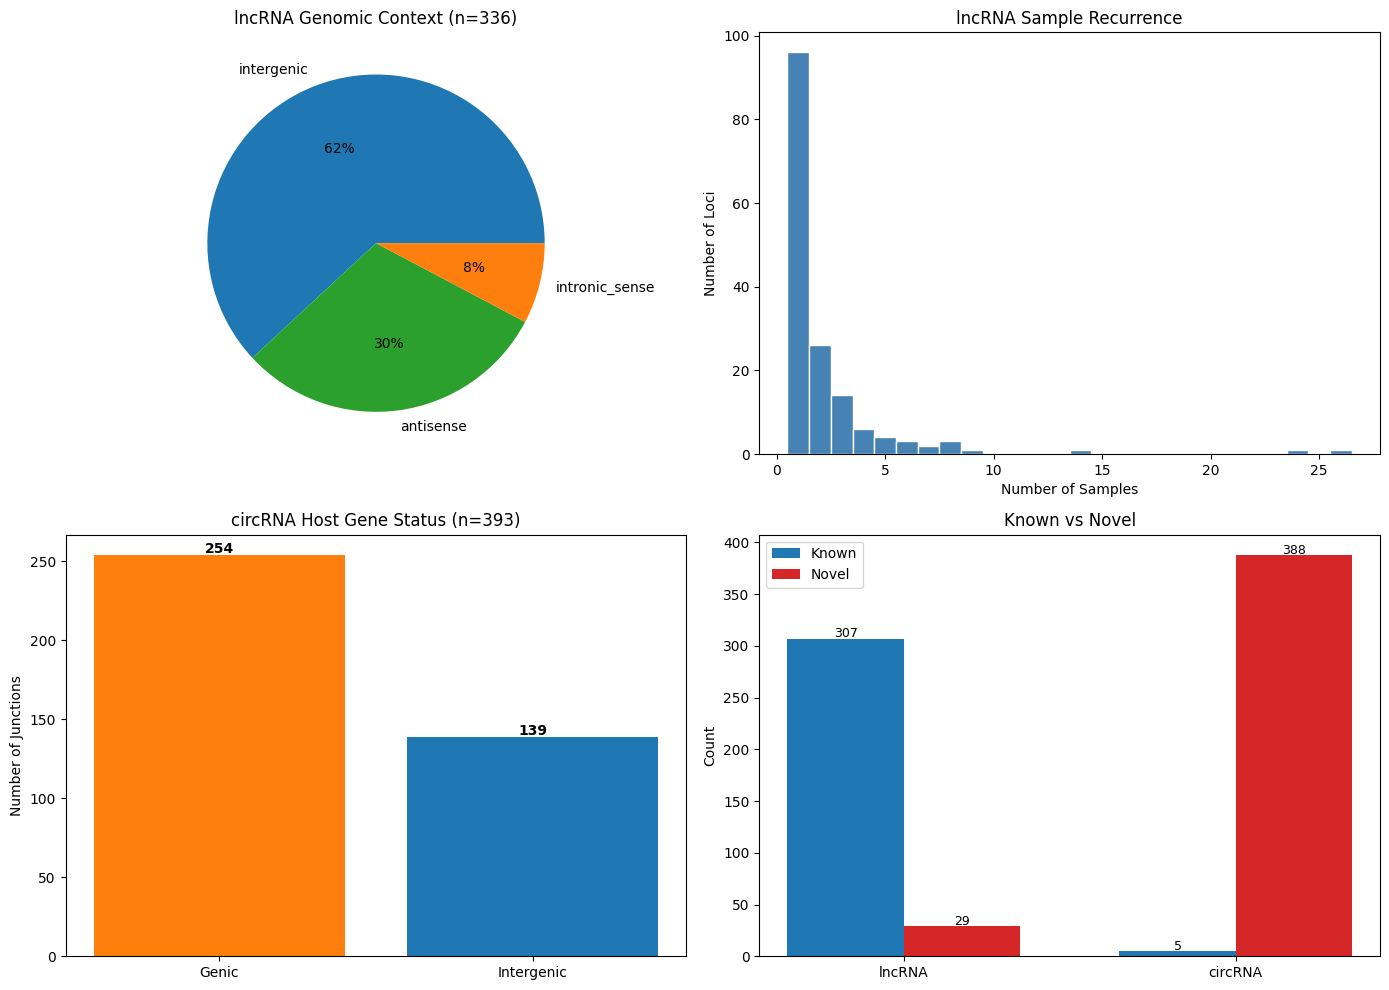


Saved: /content/phase3/phase3_summary.png


In [ ]:
# ============================================================
# Cell 137 — Summary Statistics + Key Findings + Visualisation
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

summary_lines = []

def sp(text):
    """Print and accumulate for summary file."""
    print(text)
    summary_lines.append(text)

sp("=" * 70)
sp("PHASE 3 — NOVEL TRANSCRIPT CLASSIFICATION: SUMMARY")
sp("=" * 70)

# ── lncRNA summary ──
sp(f"\n{'─'*40}")
sp(f"lncRNA LOCI: {len(df_lnc_final)}")
sp(f"{'─'*40}")
sp(f"  Confidence: HIGH={len(df_lnc_final[df_lnc_final.confidence_tier=='HIGH'])}, "
   f"MEDIUM={len(df_lnc_final[df_lnc_final.confidence_tier=='MEDIUM'])}, "
   f"LOW={len(df_lnc_final[df_lnc_final.confidence_tier=='LOW'])}")

if 'db_status' in df_lnc_final.columns:
    n_novel = (df_lnc_final['db_status'] == 'novel').sum()
    n_known = (df_lnc_final['db_status'] == 'known').sum()
    sp(f"  Database status: known={n_known}, novel={n_novel}")

if 'genomic_context' in df_lnc_final.columns:
    sp(f"  Genomic context:")
    for ctx, cnt in df_lnc_final['genomic_context'].value_counts().items():
        sp(f"    {ctx}: {cnt}")

if 'low_normal_brain_expression' in df_lnc_final.columns:
    n_low = df_lnc_final['low_normal_brain_expression'].sum()
    sp(f"  Low normal brain expression (nearest gene < 1 TPM): {n_low:.0f}")

# Priority candidates: novel + HIGH + low brain
if 'db_status' in df_lnc_final.columns and 'low_normal_brain_expression' in df_lnc_final.columns:
    priority_lnc = df_lnc_final[
        (df_lnc_final['db_status'] == 'novel') &
        (df_lnc_final['confidence_tier'] == 'HIGH') &
        (df_lnc_final['low_normal_brain_expression'] == True)
    ]
    sp(f"\n  ★ PRIORITY lncRNA (novel + HIGH + low brain expr): {len(priority_lnc)}")

# ── circRNA summary ──
sp(f"\n{'─'*40}")
sp(f"circRNA JUNCTIONS: {len(df_circ_final)}")
sp(f"{'─'*40}")
sp(f"  Confidence: HIGH={len(df_circ_final[df_circ_final.confidence_tier=='HIGH'])}, "
   f"MEDIUM={len(df_circ_final[df_circ_final.confidence_tier=='MEDIUM'])}, "
   f"LOW={len(df_circ_final[df_circ_final.confidence_tier=='LOW'])}")

if 'db_status' in df_circ_final.columns:
    sp(f"  Database status:")
    for st, cnt in df_circ_final['db_status'].value_counts().items():
        sp(f"    {st}: {cnt}")

if 'host_gene' in df_circ_final.columns:
    n_genic = (df_circ_final['host_gene'] != 'intergenic').sum()
    n_inter = (df_circ_final['host_gene'] == 'intergenic').sum()
    sp(f"  Host gene: genic={n_genic}, intergenic={n_inter}")

if 'low_normal_brain_expression' in df_circ_final.columns:
    n_low_c = df_circ_final['low_normal_brain_expression'].sum()
    sp(f"  Low normal brain expression (host gene < 1 TPM): {n_low_c:.0f}")

if 'db_status' in df_circ_final.columns and 'low_normal_brain_expression' in df_circ_final.columns:
    priority_circ = df_circ_final[
        (df_circ_final['db_status'] == 'novel') &
        (df_circ_final['confidence_tier'] == 'HIGH') &
        (df_circ_final['low_normal_brain_expression'] == True)
    ]
    sp(f"\n  ★ PRIORITY circRNA (novel + HIGH + low brain expr): {len(priority_circ)}")

sp(f"\n{'='*70}")

# ── Visualisation: 2×2 summary panel ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors_ctx = {'intergenic': '#1f77b4', 'intronic_sense': '#ff7f0e', 'antisense': '#2ca02c'}
tier_colors = {'HIGH': '#2ca02c', 'MEDIUM': '#ff7f0e', 'LOW': '#d62728'}

# (A) lncRNA: Genomic Context pie
if 'genomic_context' in df_lnc_final.columns:
    ctx_counts = df_lnc_final['genomic_context'].value_counts()
    axes[0, 0].pie(ctx_counts.values, labels=ctx_counts.index, autopct='%1.0f%%',
                   colors=[colors_ctx.get(c, '#aaaaaa') for c in ctx_counts.index])
    axes[0, 0].set_title(f'lncRNA Genomic Context (n={len(df_lnc_final)})')

# (B) lncRNA: Recurrence histogram
axes[0, 1].hist(df_lnc_final['n_samples'], bins=range(1, df_lnc_final['n_samples'].max() + 2),
                color='steelblue', edgecolor='white', align='left')
axes[0, 1].set_xlabel('Number of Samples')
axes[0, 1].set_ylabel('Number of Loci')
axes[0, 1].set_title(f'lncRNA Sample Recurrence')

# (C) circRNA: Host gene status
if 'host_gene' in df_circ_final.columns:
    host_counts = pd.Series({
        'Genic': (df_circ_final['host_gene'] != 'intergenic').sum(),
        'Intergenic': (df_circ_final['host_gene'] == 'intergenic').sum()
    })
    axes[1, 0].bar(host_counts.index, host_counts.values, color=['#ff7f0e', '#1f77b4'])
    axes[1, 0].set_ylabel('Number of Junctions')
    axes[1, 0].set_title(f'circRNA Host Gene Status (n={len(df_circ_final)})')
    for i, v in enumerate(host_counts.values):
        axes[1, 0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# (D) Combined: known vs novel by RNA type
if 'db_status' in df_lnc_final.columns and 'db_status' in df_circ_final.columns:
    x = np.arange(2)
    width = 0.35
    lnc_known = (df_lnc_final['db_status'] == 'known').sum()
    lnc_novel = (df_lnc_final['db_status'] == 'novel').sum()
    circ_known = (df_circ_final['db_status'] == 'known').sum()
    circ_novel = (df_circ_final['db_status'] == 'novel').sum()

    bars1 = axes[1, 1].bar(x - width/2, [lnc_known, circ_known], width,
                            label='Known', color='#1f77b4')
    bars2 = axes[1, 1].bar(x + width/2, [lnc_novel, circ_novel], width,
                            label='Novel', color='#d62728')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(['lncRNA', 'circRNA'])
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_title('Known vs Novel')
    axes[1, 1].legend()
    for bar in bars1:
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                        str(int(bar.get_height())), ha='center', fontsize=9)
    for bar in bars2:
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                        str(int(bar.get_height())), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{LOCAL3}/phase3_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {LOCAL3}/phase3_summary.png")

In [ ]:
# ============================================================
# VIZ-A  Setup: load tables from Drive if not in session
# ============================================================
import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

# ── colour palette (consistent across all plots) ──────────
TIER_COL  = {'HIGH': '#2ca02c', 'MEDIUM': '#ff7f0e', 'LOW': '#d62728'}
TYPE_COL  = {'GB': '#e63946', 'LGG': '#457b9d', 'Both': '#6a3d9a',
             'GB,LGG': '#6a3d9a', 'LGG,GB': '#6a3d9a'}
CTX_COL   = {'intergenic': '#1f77b4', 'intronic_sense': '#ff7f0e', 'antisense': '#2ca02c'}
DB_COL    = {'known': '#4393c3', 'novel': '#d6604d', 'unknown': '#aaaaaa'}
SPEC_COLORS = {'GBM only': '#e63946', 'LGG only': '#457b9d', 'Both': '#6a3d9a'}

# ── re-mount Drive if needed ───────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception:
    pass

PHASE3 = '/content/drive/MyDrive/bioinfo_project/phase3'
LOCAL3 = '/content/phase3'
os.makedirs(LOCAL3, exist_ok=True)

# ── load tables ────────────────────────────────────────────
try:
    _lnc = df_lnc_final.copy()
    _crc = df_circ_final.copy()
    print("Using in-session df_lnc_final / df_circ_final")
except NameError:
    _lnc = pd.read_csv(f'{PHASE3}/lncrna_final_annotated.tsv', sep='\t')
    _crc = pd.read_csv(f'{PHASE3}/circrna_final_annotated.tsv', sep='\t')
    print("Loaded from Drive")

print(f"lncRNA loci  : {len(_lnc):,}  |  circRNA junctions : {len(_crc):,}")
print(f"\nlncRNA confidence tiers:\n{_lnc['confidence_tier'].value_counts().to_string()}")
print(f"\ncircRNA confidence tiers:\n{_crc['confidence_tier'].value_counts().to_string()}")
if 'genomic_context' in _lnc.columns:
    print(f"\nlncRNA genomic context:\n{_lnc['genomic_context'].value_counts().to_string()}")
if 'db_status' in _lnc.columns:
    print(f"\nlncRNA db_status:\n{_lnc['db_status'].value_counts().to_string()}")
if 'db_status' in _crc.columns:
    print(f"\ncircRNA db_status:\n{_crc['db_status'].value_counts().to_string()}")
if 'tumor_types' in _lnc.columns:
    print(f"\nlncRNA tumor_types:\n{_lnc['tumor_types'].value_counts().to_string()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using in-session df_lnc_final / df_circ_final
lncRNA loci  : 336  |  circRNA junctions : 393

lncRNA confidence tiers:
confidence_tier
LOW       232
MEDIUM     61
HIGH       43

circRNA confidence tiers:
confidence_tier
MEDIUM    376
LOW        15
HIGH        2

lncRNA genomic context:
genomic_context
intergenic        208
antisense         102
intronic_sense     26

lncRNA db_status:
db_status
known    307
novel     29

circRNA db_status:
db_status
novel    388
known      5

lncRNA tumor_types:
tumor_types
GB        58
LGG       58
GB,LGG    42


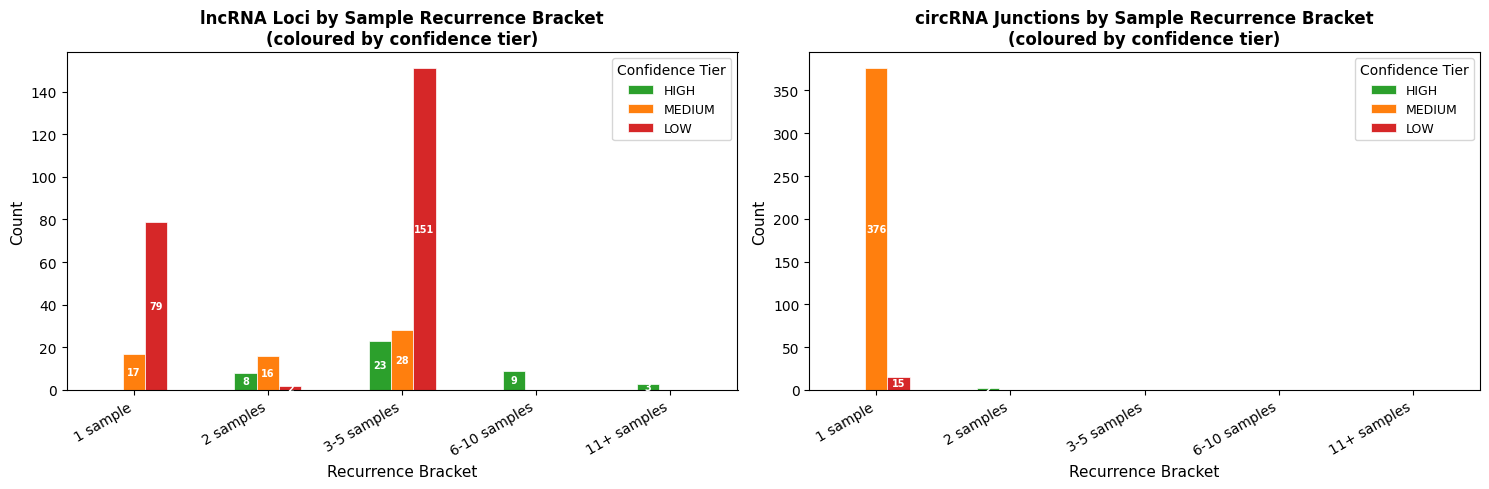

=== lncRNA Recurrence Brackets ===
confidence_tier  HIGH  LOW  MEDIUM
bracket                           
1 sample            0   79      17
2 samples           8    2      16
3-5 samples        23  151      28
6-10 samples        9    0       0
11+ samples         3    0       0

Loci detected in >= 5 samples : 16

=== circRNA Recurrence Brackets ===
confidence_tier  HIGH  LOW  MEDIUM
bracket                           
1 sample            0   15     376
2 samples           2    0       0
3-5 samples         0    0       0
6-10 samples        0    0       0
11+ samples         0    0       0

Junctions detected in >= 5 samples : 0


In [ ]:
# ============================================================
# VIZ-B  lncRNA & circRNA — Sample Recurrence Bracket Distribution
# ============================================================
def recurrence_bracket(n):
    if n == 1:   return '1 sample'
    if n == 2:   return '2 samples'
    if n <= 5:   return '3-5 samples'
    if n <= 10:  return '6-10 samples'
    return '11+ samples'

BRACKET_ORDER = ['1 sample', '2 samples', '3-5 samples', '6-10 samples', '11+ samples']
tier_order = ['HIGH', 'MEDIUM', 'LOW']

_lnc['bracket'] = _lnc['n_samples'].apply(recurrence_bracket)
_crc['bracket'] = _crc['n_samples'].apply(recurrence_bracket)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, df_plot, title in [
        (axes[0], _lnc, 'lncRNA Loci'),
        (axes[1], _crc, 'circRNA Junctions'),
]:
    bt = (df_plot.groupby(['bracket', 'confidence_tier'])
                  .size().unstack(fill_value=0)
                  .reindex(BRACKET_ORDER, fill_value=0))
    tp = [t for t in tier_order if t in bt.columns]
    bt = bt[tp]
    bt.plot(kind='bar', ax=ax, color=[TIER_COL[t] for t in tp],
            edgecolor='white', linewidth=0.5)
    ax.set_title(f'{title} by Sample Recurrence Bracket\n(coloured by confidence tier)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Recurrence Bracket', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(title='Confidence Tier', fontsize=9)
    for patch in ax.patches:
        h = patch.get_height()
        if h > 0:
            ax.text(patch.get_x() + patch.get_width()/2,
                    patch.get_y() + h/2, str(int(h)),
                    ha='center', va='center', fontsize=7, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{LOCAL3}/vizB_recurrence_brackets.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== lncRNA Recurrence Brackets ===")
print(_lnc.groupby(['bracket', 'confidence_tier']).size().unstack(fill_value=0).reindex(BRACKET_ORDER, fill_value=0).to_string())
print(f"\nLoci detected in >= 5 samples : {(_lnc['n_samples'] >= 5).sum()}")
print("\n=== circRNA Recurrence Brackets ===")
print(_crc.groupby(['bracket', 'confidence_tier']).size().unstack(fill_value=0).reindex(BRACKET_ORDER, fill_value=0).to_string())
print(f"\nJunctions detected in >= 5 samples : {(_crc['n_samples'] >= 5).sum()}")

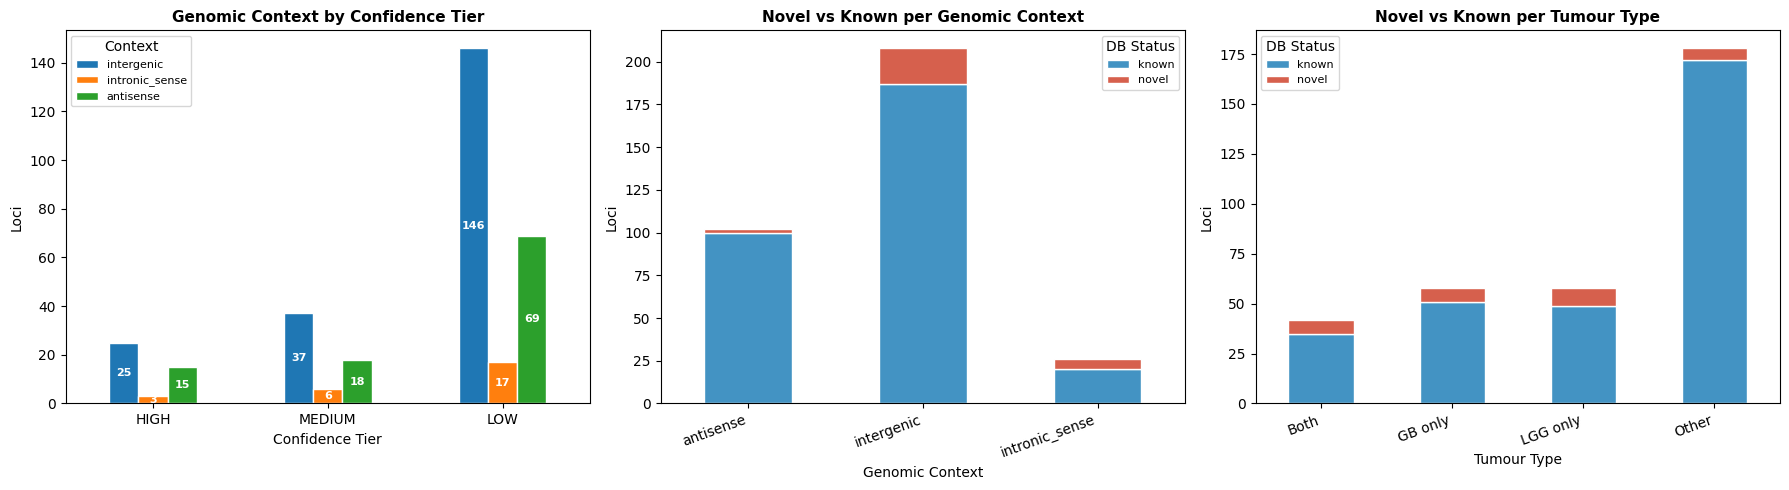

=== lncRNA Genomic Context x Confidence Tier ===
genomic_context  antisense  intergenic  intronic_sense
confidence_tier                                       
HIGH                    15          25               3
MEDIUM                  18          37               6
LOW                     69         146              17

=== lncRNA Novel vs Known per Context ===
db_status        known  novel
genomic_context              
antisense          100      2
intergenic         187     21
intronic_sense      20      6


In [ ]:
# ============================================================
# VIZ-C  lncRNA — Genomic Context x Confidence Tier x Novel/Known
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
tier_order = ['HIGH', 'MEDIUM', 'LOW']

# C1: context per tier
if 'genomic_context' in _lnc.columns:
    ctx_tier = (_lnc.groupby(['confidence_tier', 'genomic_context'])
                    .size().unstack(fill_value=0)
                    .reindex(tier_order, fill_value=0))
    ctx_order_present = [c for c in ['intergenic', 'intronic_sense', 'antisense']
                         if c in ctx_tier.columns]
    ctx_tier[ctx_order_present].plot(
        kind='bar', ax=axes[0], color=[CTX_COL[c] for c in ctx_order_present],
        edgecolor='white')
    axes[0].set_title('Genomic Context by Confidence Tier', fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Confidence Tier')
    axes[0].set_ylabel('Loci')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
    axes[0].legend(title='Context', fontsize=8)
    for patch in axes[0].patches:
        h = patch.get_height()
        if h > 0:
            axes[0].text(patch.get_x() + patch.get_width()/2,
                         patch.get_y() + h/2, str(int(h)),
                         ha='center', va='center', fontsize=8, color='white', fontweight='bold')

# C2: novel/known per genomic context
if 'db_status' in _lnc.columns and 'genomic_context' in _lnc.columns:
    ctx_db = (_lnc.groupby(['genomic_context', 'db_status'])
                   .size().unstack(fill_value=0))
    db_order_present = [d for d in ['known', 'novel'] if d in ctx_db.columns]
    ctx_db[db_order_present].plot(
        kind='bar', ax=axes[1], color=[DB_COL[d] for d in db_order_present],
        edgecolor='white', stacked=True)
    axes[1].set_title('Novel vs Known per Genomic Context', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Genomic Context')
    axes[1].set_ylabel('Loci')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')
    axes[1].legend(title='DB Status', fontsize=8)

# C3: novel/known per tumour type
if 'db_status' in _lnc.columns and 'tumor_types' in _lnc.columns:
    _lnc['tumor_label'] = _lnc['tumor_types'].apply(
        lambda x: 'GB only' if str(x) == 'GB'
        else 'LGG only' if str(x) == 'LGG'
        else 'Both' if str(x) in ('GB,LGG', 'LGG,GB')
        else 'Other')
    tt_db = (_lnc.groupby(['tumor_label', 'db_status'])
                  .size().unstack(fill_value=0))
    db_o2 = [d for d in ['known', 'novel'] if d in tt_db.columns]
    tt_db[db_o2].plot(
        kind='bar', ax=axes[2], color=[DB_COL[d] for d in db_o2],
        edgecolor='white', stacked=True)
    axes[2].set_title('Novel vs Known per Tumour Type', fontsize=11, fontweight='bold')
    axes[2].set_xlabel('Tumour Type')
    axes[2].set_ylabel('Loci')
    axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=20, ha='right')
    axes[2].legend(title='DB Status', fontsize=8)

plt.tight_layout()
plt.savefig(f'{LOCAL3}/vizC_lncrna_context_novelty.png', dpi=150, bbox_inches='tight')
plt.show()

if 'genomic_context' in _lnc.columns:
    print("=== lncRNA Genomic Context x Confidence Tier ===")
    print(ctx_tier.to_string())
if 'db_status' in _lnc.columns and 'genomic_context' in _lnc.columns:
    print("\n=== lncRNA Novel vs Known per Context ===")
    print(ctx_db.to_string())

=== lncRNA Tumour Specificity ===
confidence_tier  HIGH  MEDIUM  LOW
tumour_spec                       
GBM only            5      18   35
LGG only            2      11   45
Both               36       5    1

=== circRNA Tumour Specificity ===
confidence_tier  HIGH  MEDIUM  LOW
tumour_spec                       
GBM only            1     268   10
LGG only            0     108    5
Both                1       0    0



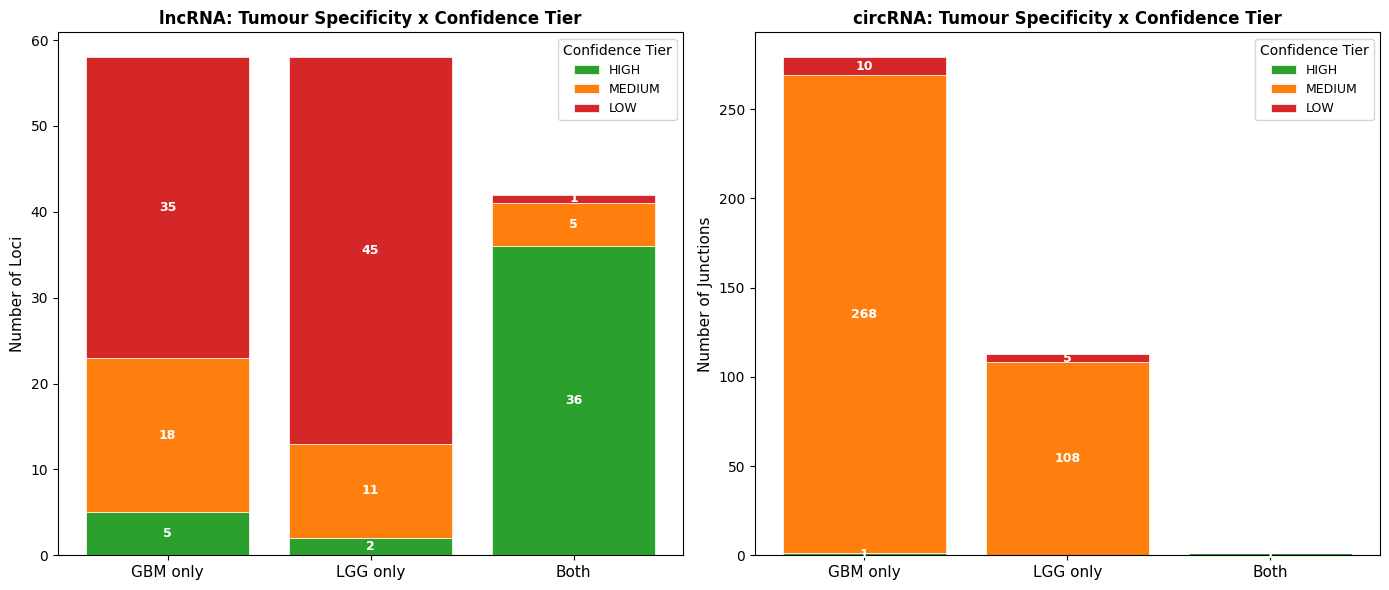

Fig D saved.


In [ ]:
# ============================================================
# VIZ-D  Tumour Specificity: GBM-specific / LGG-specific / Shared
#         stacked by confidence tier
# ============================================================
def tumour_spec(row):
    tt = str(row.get('tumor_types', ''))
    if 'GB' in tt and 'LGG' in tt:
        return 'Both'
    elif 'GB' in tt:
        return 'GBM only'
    elif 'LGG' in tt:
        return 'LGG only'
    return 'Other'

_lnc['tumour_spec'] = _lnc.apply(tumour_spec, axis=1)
_crc['tumour_spec'] = _crc.apply(tumour_spec, axis=1)

SPEC_ORDER  = ['GBM only', 'LGG only', 'Both']
tier_order  = ['HIGH', 'MEDIUM', 'LOW']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df_plot, title in [
        (axes[0], _lnc, 'lncRNA'),
        (axes[1], _crc, 'circRNA'),
]:
    spec_tier = (df_plot.groupby(['tumour_spec', 'confidence_tier'])
                        .size().unstack(fill_value=0)
                        .reindex(SPEC_ORDER, fill_value=0))
    tier_cols = [t for t in tier_order if t in spec_tier.columns]
    spec_tier = spec_tier[tier_cols]

    bottom = np.zeros(len(SPEC_ORDER))
    x = np.arange(len(SPEC_ORDER))

    for tier in tier_cols:
        vals = spec_tier[tier].values
        ax.bar(x, vals, bottom=bottom, label=tier,
               color=TIER_COL[tier], edgecolor='white', linewidth=0.5)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0:
                ax.text(x[i], b + v/2, str(int(v)), ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
        bottom = bottom + vals

    ax.set_xticks(x)
    ax.set_xticklabels(SPEC_ORDER, fontsize=11)
    ax.set_ylabel('Number of Loci' if title == 'lncRNA' else 'Number of Junctions', fontsize=11)
    ax.set_title(f'{title}: Tumour Specificity x Confidence Tier', fontsize=12, fontweight='bold')
    ax.legend(title='Confidence Tier', fontsize=9)

    print(f"=== {title} Tumour Specificity ===")
    print(spec_tier.to_string())
    print()

plt.tight_layout()
plt.savefig(f'{LOCAL3}/vizD_tumour_specificity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig D saved.")


lncRNA Loci per Patient
  GBM: mean 12.3, median 12.0, range 5-24
  LGG: mean 17.1, median 10.0, range 6-44

circRNA Junctions per Patient
  GBM: mean 16.5, median 15.0, range 1-42
  LGG: mean 12.7, median 10.0, range 6-22


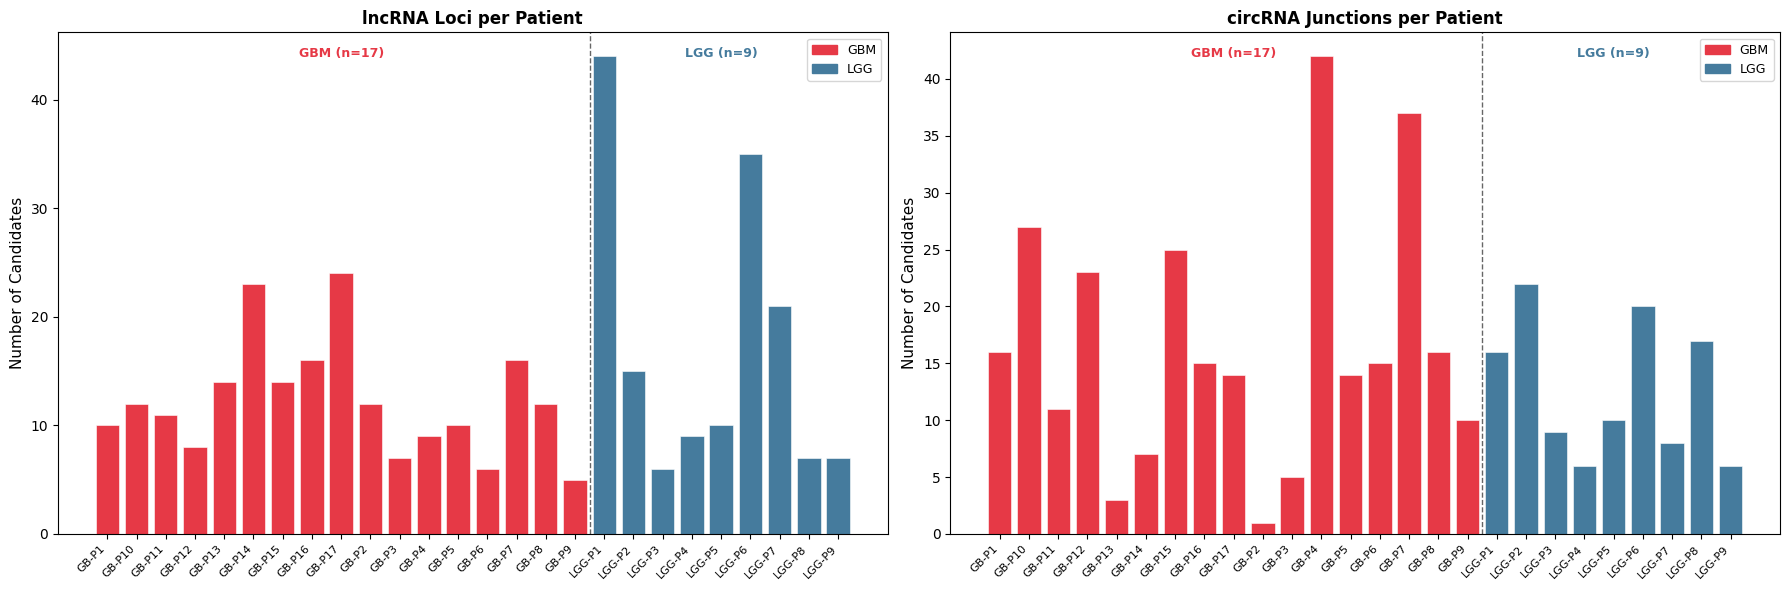

Fig E saved.


In [ ]:
# ============================================================
# VIZ-E  Per-Sample RNA Counts (GBM vs LGG side-by-side)
# ============================================================
patient_map_local = {
    "SRR31451033": ("GB", "GB-P1"),   "SRR31451034": ("GB", "GB-P2"),
    "SRR31451035": ("GB", "GB-P3"),   "SRR31451036": ("GB", "GB-P4"),
    "SRR31451037": ("GB", "GB-P5"),   "SRR31451038": ("GB", "GB-P6"),
    "SRR31451039": ("GB", "GB-P7"),   "SRR31451040": ("GB", "GB-P8"),
    "SRR31451041": ("GB", "GB-P9"),   "SRR31451042": ("GB", "GB-P10"),
    "SRR31451031": ("GB", "GB-P11"),  "SRR31451032": ("GB", "GB-P12"),
    "SRR31451030": ("GB", "GB-P13"),  "SRR31451029": ("GB", "GB-P14"),
    "SRR31451028": ("GB", "GB-P15"),  "SRR31451027": ("GB", "GB-P16"),
    "SRR31451017": ("GB", "GB-P17"),
    "SRR31451025": ("LGG", "LGG-P1"), "SRR31451024": ("LGG", "LGG-P2"),
    "SRR31451023": ("LGG", "LGG-P3"), "SRR31451022": ("LGG", "LGG-P4"),
    "SRR31451021": ("LGG", "LGG-P5"), "SRR31451020": ("LGG", "LGG-P6"),
    "SRR31451019": ("LGG", "LGG-P7"), "SRR31451018": ("LGG", "LGG-P8"),
    "SRR31451026": ("LGG", "LGG-P9"),
}

def count_per_sample(df, id_col='sample_list'):
    rows = []
    for _, r in df.iterrows():
        for srr in str(r[id_col]).split(','):
            srr = srr.strip()
            if srr in patient_map_local:
                tt, lbl = patient_map_local[srr]
                rows.append({'SRR': srr, 'Label': lbl, 'Tumour_Type': tt})
    return pd.DataFrame(rows).groupby(['SRR','Label','Tumour_Type']).size().reset_index(name='count')

lnc_per_sample  = count_per_sample(_lnc)
circ_per_sample = count_per_sample(_crc)

for df_s in [lnc_per_sample, circ_per_sample]:
    df_s['_sort'] = df_s.apply(lambda r: (0 if r['Tumour_Type']=='GB' else 1, r['Label']), axis=1)
    df_s.sort_values('_sort', inplace=True)
    df_s.drop(columns='_sort', inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, df_s, title in [
        (axes[0], lnc_per_sample,  'lncRNA Loci per Patient'),
        (axes[1], circ_per_sample, 'circRNA Junctions per Patient'),
]:
    bar_colors = [TYPE_COL.get(tt, '#888888') for tt in df_s['Tumour_Type']]
    x = np.arange(len(df_s))
    ax.bar(x, df_s['count'], color=bar_colors, edgecolor='white', linewidth=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(df_s['Label'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Number of Candidates', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    n_gb = (df_s['Tumour_Type'] == 'GB').sum()
    ax.axvline(x=n_gb - 0.5, color='black', linestyle='--', linewidth=1, alpha=0.6)
    ylim_top = ax.get_ylim()[1]
    ax.text(n_gb/2 - 0.5, ylim_top*0.95, 'GBM (n=17)', ha='center',
            fontsize=9, color=TYPE_COL['GB'], fontweight='bold')
    ax.text(n_gb + (len(df_s)-n_gb)/2 - 0.5, ylim_top*0.95, 'LGG (n=9)',
            ha='center', fontsize=9, color=TYPE_COL['LGG'], fontweight='bold')

    gb_vals  = df_s.loc[df_s['Tumour_Type']=='GB',  'count']
    lgg_vals = df_s.loc[df_s['Tumour_Type']=='LGG', 'count']
    print(f"\n{title}")
    print(f"  GBM: mean {gb_vals.mean():.1f}, median {gb_vals.median():.1f}, range {gb_vals.min()}-{gb_vals.max()}")
    print(f"  LGG: mean {lgg_vals.mean():.1f}, median {lgg_vals.median():.1f}, range {lgg_vals.min()}-{lgg_vals.max()}")

gb_patch  = mpatches.Patch(color=TYPE_COL['GB'],  label='GBM')
lgg_patch = mpatches.Patch(color=TYPE_COL['LGG'], label='LGG')
axes[0].legend(handles=[gb_patch, lgg_patch], fontsize=9)
axes[1].legend(handles=[gb_patch, lgg_patch], fontsize=9)

plt.tight_layout()
plt.savefig(f'{LOCAL3}/vizE_per_sample_counts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig E saved.")

In [ ]:

# # ============================================================
# # Cell 137b — Novel circRNA Detailed Audit Table
# # ============================================================
# # Shows every novel (not in circBase) circRNA that passes the
# # quality thresholds used in Phase 3 (n_samples >= 3 AND
# # max_n_exons >= 2), so results can be independently verified.
# # Columns shown: locus ID, junction coordinates, strand,
# # n_samples, exon count, circle length, canonical splice,
# # host gene, confidence tier, tumour types, and per-sample list.

# import pandas as pd

# # ── Filter: novel + n_samples >= 3 + max_n_exons >= 2 ──────
# mask_novel = df_circ_final['db_status'] == 'novel'
# mask_rec   = df_circ_final['n_samples'] >= 3
# mask_exon  = df_circ_final['max_n_exons'] >= 2

# df_unknowns = df_circ_final[mask_novel & mask_rec & mask_exon].copy()
# df_unknowns = df_unknowns.sort_values(
#     ['confidence_tier', 'n_samples', 'max_n_exons'],
#     ascending=[True, False, False]
# ).reset_index(drop=True)

# print("=" * 70)
# print(f"NOVEL circRNA AUDIT — n_samples >= 3 AND max_n_exons >= 2")
# print(f"Total: {len(df_unknowns)} candidates")
# print("=" * 70)

# # ── Count breakdown ────────────────────────────────────────
# print(f"\nFilter breakdown on df_circ_final ({len(df_circ_final)} total junctions):")
# print(f"  novel (not in circBase):               {mask_novel.sum()}")
# print(f"  novel + n_samples >= 3:                {(mask_novel & mask_rec).sum()}")
# print(f"  novel + n_samples >= 3 + exons >= 2:   {(mask_novel & mask_rec & mask_exon).sum()}")
# if 'confidence_tier' in df_circ_final.columns:
#     tier_counts = df_unknowns['confidence_tier'].value_counts()
#     print(f"\n  Confidence tiers among these {len(df_unknowns)}:")
#     for tier in ['HIGH', 'MEDIUM', 'LOW']:
#         n = tier_counts.get(tier, 0)
#         print(f"    {tier}: {n}")

# # ── Summary table (one row per circRNA) ────────────────────
# display_cols = [c for c in [
#     'circ_locus_id', 'junction_id', 'chr', 'start', 'end', 'strand',
#     'n_samples', 'max_n_exons', 'max_circle_length',
#     'has_canonical_splice', 'frac_canonical',
#     'confidence_score', 'confidence_tier',
#     'host_gene', 'tumor_types',
#     'host_gene_brain_tpm', 'low_normal_brain_expression',
#     'in_circBase',
# ] if c in df_unknowns.columns]

# print(f"\n{'─'*70}")
# print("SUMMARY TABLE")
# print('─'*70)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', 40)
# pd.set_option('display.width', 200)
# print(df_unknowns[display_cols].to_string(index=True))

# # ── Per-circRNA detailed cards ─────────────────────────────
# print(f"\n{'='*70}")
# print("PER-CIRCRNA DETAIL CARDS")
# print('='*70)

# for i, row in df_unknowns.iterrows():
#     tier = row.get('confidence_tier', '?')
#     jid  = row.get('junction_id', f"{row['chr']}:{row['start']}-{row['end']}")
#     print(f"\n[{i+1:02d}] {row.get('circ_locus_id','?')}  |  {jid}  |  tier={tier}")
#     print(f"     Location   : chr={row['chr']}  start={int(row['start'])}  end={int(row['end'])}  strand={row['strand']}")
#     print(f"     Samples    : n={int(row['n_samples'])}  |  {row.get('sample_list','?')}")
#     print(f"     Tumour type: {row.get('tumor_types','?')}")
#     print(f"     Exons      : max_n_exons={int(row['max_n_exons'])}  circle_len={row.get('max_circle_length','?')} bp")
#     print(f"     Splice     : canonical={row.get('has_canonical_splice','?')}  frac_canonical={row.get('frac_canonical', float('nan')):.2f}")
#     print(f"     Host gene  : {row.get('host_gene','?')}  (brain_tpm={row.get('host_gene_brain_tpm','?')})")
#     print(f"     Confidence : score={row.get('confidence_score','?')}  tier={tier}")
#     print(f"     DB status  : {row.get('db_status','?')}  in_circBase={row.get('in_circBase','?')}")
#     low_expr = row.get('low_normal_brain_expression', '?')
#     print(f"     Low brain  : {low_expr}")
#     print(f"     {'─'*60}")

# print(f"\n✓ End of audit — {len(df_unknowns)} novel circRNA candidates shown.")


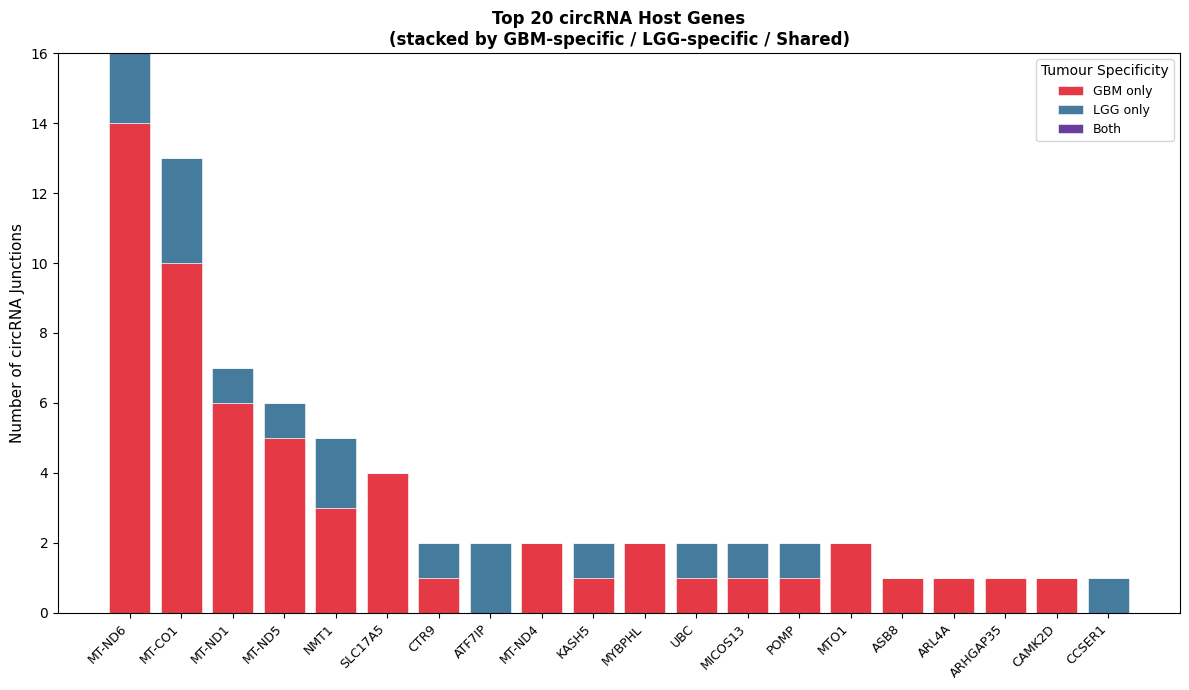

=== Top 20 circRNA Host Genes ===
tumour_spec  GBM only  LGG only  Both  total
host_gene                                   
MT-ND6             14         2     0     16
MT-CO1             10         3     0     13
MT-ND1              6         1     0      7
MT-ND5              5         1     0      6
NMT1                3         2     0      5
SLC17A5             4         0     0      4
CTR9                1         1     0      2
ATF7IP              0         2     0      2
MT-ND4              2         0     0      2
KASH5               1         1     0      2
MYBPHL              2         0     0      2
UBC                 1         1     0      2
MICOS13             1         1     0      2
POMP                1         1     0      2
MTO1                2         0     0      2
ASB8                1         0     0      1
ARL4A               1         0     0      1
ARHGAP35            1         0     0      1
CAMK2D              1         0     0      1
CCSER1              0

In [ ]:
# ============================================================
# VIZ-G  circRNA — Top 20 Host Genes (by junction count)
#         stacked by GBM-only / LGG-only / Shared
# ============================================================
if 'host_gene' in _crc.columns:
    _crc_genic = _crc[_crc['host_gene'] != 'intergenic'].copy()

    hg_counts = (_crc_genic.groupby(['host_gene', 'tumour_spec'])
                            .size().unstack(fill_value=0))
    for col in ['GBM only', 'LGG only', 'Both']:
        if col not in hg_counts.columns:
            hg_counts[col] = 0
    hg_counts['total'] = hg_counts[['GBM only', 'LGG only', 'Both']].sum(axis=1)
    top20_hg = hg_counts.sort_values('total', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(12, 7))
    x = np.arange(len(top20_hg))
    bottom = np.zeros(len(top20_hg))

    for spec in ['GBM only', 'LGG only', 'Both']:
        vals = top20_hg[spec].values
        ax.bar(x, vals, bottom=bottom, label=spec,
               color=SPEC_COLORS[spec], edgecolor='white', linewidth=0.4)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(top20_hg.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Number of circRNA Junctions', fontsize=11)
    ax.set_title('Top 20 circRNA Host Genes\n(stacked by GBM-specific / LGG-specific / Shared)',
                 fontsize=12, fontweight='bold')
    ax.legend(title='Tumour Specificity', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{LOCAL3}/vizG_top_host_genes.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("=== Top 20 circRNA Host Genes ===")
    print(top20_hg[['GBM only', 'LGG only', 'Both', 'total']].to_string())
    print("Fig G saved.")
else:
    print("host_gene column not found — skipping VIZ-G")

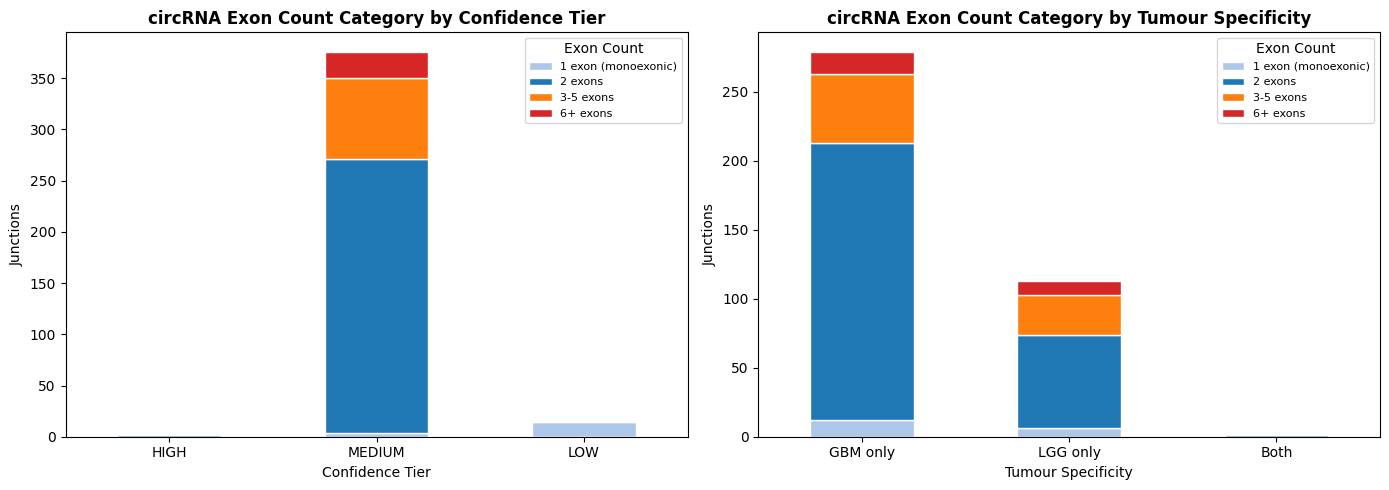

=== circRNA Exon Category x Confidence Tier ===
exon_cat         1 exon (monoexonic)  2 exons  3-5 exons  6+ exons
confidence_tier                                                   
HIGH                               0        2          0         0
MEDIUM                             4      267         79        26
LOW                               14        1          0         0

=== circRNA Exon Category x Tumour Specificity ===
exon_cat     1 exon (monoexonic)  2 exons  3-5 exons  6+ exons
tumour_spec                                                   
GBM only                      12      201         50        16
LGG only                       6       68         29        10
Both                           0        1          0         0
Fig H saved.


In [ ]:
# ============================================================
# VIZ-H  circRNA Exon Count Category Distribution
#         by Confidence Tier and Tumour Specificity
# ============================================================
def exon_cat(n):
    try:
        n = int(n)
    except (TypeError, ValueError):
        n = 0
    if n <= 1:  return '1 exon (monoexonic)'
    if n == 2:  return '2 exons'
    if n <= 5:  return '3-5 exons'
    return '6+ exons'

EXON_ORDER = ['1 exon (monoexonic)', '2 exons', '3-5 exons', '6+ exons']
EXON_COL   = {'1 exon (monoexonic)': '#aec7e8', '2 exons': '#1f77b4',
              '3-5 exons': '#ff7f0e', '6+ exons': '#d62728'}

if 'max_n_exons' in _crc.columns:
    _crc['exon_cat'] = _crc['max_n_exons'].apply(exon_cat)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # H1: confidence tier
    ec_tier = (_crc.groupby(['confidence_tier', 'exon_cat'])
                   .size().unstack(fill_value=0)
                   .reindex(['HIGH', 'MEDIUM', 'LOW'], fill_value=0))
    ec_cols = [c for c in EXON_ORDER if c in ec_tier.columns]
    ec_tier[ec_cols].plot(kind='bar', ax=axes[0],
                          color=[EXON_COL[c] for c in ec_cols],
                          edgecolor='white', stacked=True)
    axes[0].set_title('circRNA Exon Count Category by Confidence Tier', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Confidence Tier')
    axes[0].set_ylabel('Junctions')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
    axes[0].legend(title='Exon Count', fontsize=8, bbox_to_anchor=(1, 1))

    # H2: tumour specificity
    ec_tt = (_crc.groupby(['tumour_spec', 'exon_cat'])
                  .size().unstack(fill_value=0)
                  .reindex(['GBM only', 'LGG only', 'Both'], fill_value=0))
    ec_cols2 = [c for c in EXON_ORDER if c in ec_tt.columns]
    ec_tt[ec_cols2].plot(kind='bar', ax=axes[1],
                         color=[EXON_COL[c] for c in ec_cols2],
                         edgecolor='white', stacked=True)
    axes[1].set_title('circRNA Exon Count Category by Tumour Specificity', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Tumour Specificity')
    axes[1].set_ylabel('Junctions')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
    axes[1].legend(title='Exon Count', fontsize=8, bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.savefig(f'{LOCAL3}/vizH_exon_counts.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("=== circRNA Exon Category x Confidence Tier ===")
    print(ec_tier.to_string())
    print("\n=== circRNA Exon Category x Tumour Specificity ===")
    print(ec_tt.to_string())
    print("Fig H saved.")
else:
    print("max_n_exons column not found — skipping VIZ-H")

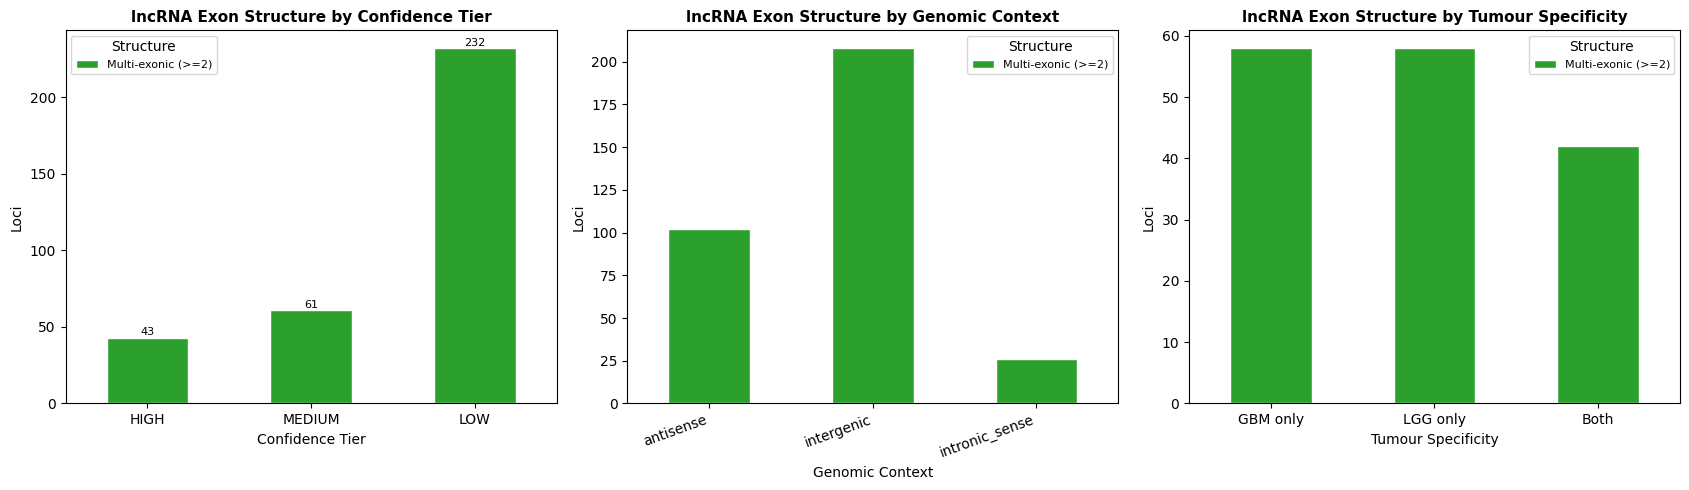

=== lncRNA Exon Structure x Confidence Tier ===
exon_struct      Multi-exonic (>=2)
confidence_tier                    
HIGH                             43
MEDIUM                           61
LOW                             232

=== lncRNA Exon Structure x Genomic Context ===
exon_struct      Multi-exonic (>=2)
genomic_context                    
antisense                       102
intergenic                      208
intronic_sense                   26

=== lncRNA Exon Structure x Tumour Specificity ===
exon_struct  Multi-exonic (>=2)
tumour_spec                    
GBM only                     58
LGG only                     58
Both                         42
Fig I saved.


In [ ]:
# ============================================================
# VIZ-I  lncRNA Multi-exonic vs Monoexonic
#         by Confidence Tier, Genomic Context, Tumour Specificity
# ============================================================
_lnc['exon_struct'] = _lnc['max_exon_count'].apply(
    lambda n: 'Multi-exonic (>=2)' if int(n) >= 2 else 'Monoexonic (1)')
STRUCT_COL = {'Multi-exonic (>=2)': '#2ca02c', 'Monoexonic (1)': '#d62728'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
struct_cols_check = [c for c in ['Multi-exonic (>=2)', 'Monoexonic (1)'] if True]

# I1: confidence tier
es_tier = (_lnc.groupby(['confidence_tier', 'exon_struct'])
               .size().unstack(fill_value=0)
               .reindex(['HIGH', 'MEDIUM', 'LOW'], fill_value=0))
es_cols = [c for c in ['Multi-exonic (>=2)', 'Monoexonic (1)'] if c in es_tier.columns]
es_tier[es_cols].plot(kind='bar', ax=axes[0],
                      color=[STRUCT_COL[c] for c in es_cols], edgecolor='white')
axes[0].set_title('lncRNA Exon Structure by Confidence Tier', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Confidence Tier')
axes[0].set_ylabel('Loci')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Structure', fontsize=8)
for patch in axes[0].patches:
    h = patch.get_height()
    if h > 0:
        axes[0].text(patch.get_x() + patch.get_width()/2, h + 0.3,
                     str(int(h)), ha='center', va='bottom', fontsize=8)

# I2: genomic context
if 'genomic_context' in _lnc.columns:
    es_ctx = (_lnc.groupby(['genomic_context', 'exon_struct'])
                  .size().unstack(fill_value=0))
    es_ctx_cols = [c for c in ['Multi-exonic (>=2)', 'Monoexonic (1)'] if c in es_ctx.columns]
    es_ctx[es_ctx_cols].plot(kind='bar', ax=axes[1],
                             color=[STRUCT_COL[c] for c in es_ctx_cols], edgecolor='white')
    axes[1].set_title('lncRNA Exon Structure by Genomic Context', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Genomic Context')
    axes[1].set_ylabel('Loci')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')
    axes[1].legend(title='Structure', fontsize=8)

# I3: tumour specificity
es_ts = (_lnc.groupby(['tumour_spec', 'exon_struct'])
             .size().unstack(fill_value=0)
             .reindex(['GBM only', 'LGG only', 'Both'], fill_value=0))
es_ts_cols = [c for c in ['Multi-exonic (>=2)', 'Monoexonic (1)'] if c in es_ts.columns]
es_ts[es_ts_cols].plot(kind='bar', ax=axes[2],
                       color=[STRUCT_COL[c] for c in es_ts_cols], edgecolor='white')
axes[2].set_title('lncRNA Exon Structure by Tumour Specificity', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Tumour Specificity')
axes[2].set_ylabel('Loci')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(title='Structure', fontsize=8)

plt.tight_layout()
plt.savefig(f'{LOCAL3}/vizI_lncrna_exon_structure.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== lncRNA Exon Structure x Confidence Tier ===")
print(es_tier.to_string())
if 'genomic_context' in _lnc.columns:
    print("\n=== lncRNA Exon Structure x Genomic Context ===")
    print(es_ctx.to_string())
print("\n=== lncRNA Exon Structure x Tumour Specificity ===")
print(es_ts.to_string())
print("Fig I saved.")


=== lncRNA: Confidence Tier x DB Status ===
db_status        known  novel
confidence_tier              
HIGH                38      5
MEDIUM              57      4
LOW                212     20

lncRNA % composition:
db_status        known  novel
confidence_tier              
HIGH              88.4   11.6
MEDIUM            93.4    6.6
LOW               91.4    8.6

=== circRNA: Confidence Tier x DB Status ===
db_status        known  novel
confidence_tier              
HIGH                 0      2
MEDIUM               5    371
LOW                  0     15

circRNA % composition:
db_status        known  novel
confidence_tier              
HIGH               0.0  100.0
MEDIUM             1.3   98.7
LOW                0.0  100.0


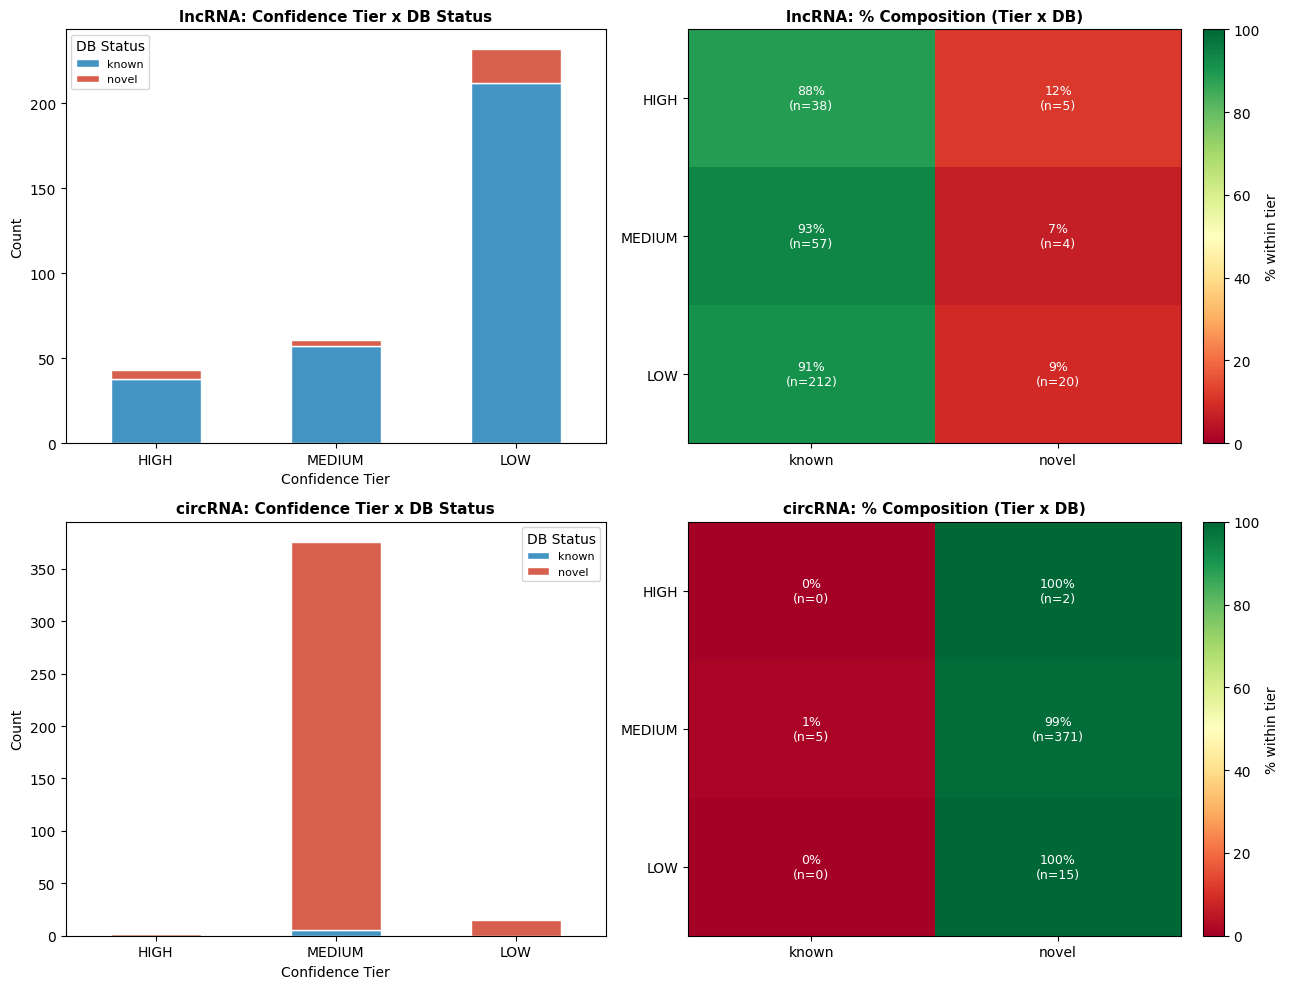

Fig K saved.


In [ ]:
# ============================================================
# VIZ-K  Confidence Tier x DB Status — Stacked Bar + Heatmap
#         (lncRNA and circRNA, 2 rows x 2 columns)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
tier_order = ['HIGH', 'MEDIUM', 'LOW']

for row_i, (df_plot, label) in enumerate([(_lnc, 'lncRNA'), (_crc, 'circRNA')]):
    if 'db_status' not in df_plot.columns:
        for ax in axes[row_i]:
            ax.text(0.5, 0.5, f'{label}: db_status missing', transform=ax.transAxes, ha='center')
            ax.axis('off')
        continue

    ct = (df_plot.groupby(['confidence_tier', 'db_status'])
                  .size().unstack(fill_value=0)
                  .reindex(tier_order, fill_value=0))
    db_cols = [c for c in ['known', 'novel', 'unknown'] if c in ct.columns]

    # K-left: stacked bar
    ct[db_cols].plot(kind='bar', ax=axes[row_i, 0],
                     color=[DB_COL[c] for c in db_cols],
                     edgecolor='white', stacked=True)
    axes[row_i, 0].set_title(f'{label}: Confidence Tier x DB Status', fontsize=11, fontweight='bold')
    axes[row_i, 0].set_xlabel('Confidence Tier')
    axes[row_i, 0].set_ylabel('Count')
    axes[row_i, 0].set_xticklabels(axes[row_i, 0].get_xticklabels(), rotation=0)
    axes[row_i, 0].legend(title='DB Status', fontsize=8)

    # K-right: percentage heatmap
    ct_pct = ct[db_cols].div(ct[db_cols].sum(axis=1), axis=0) * 100
    im = axes[row_i, 1].imshow(ct_pct.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
    axes[row_i, 1].set_xticks(range(len(db_cols)))
    axes[row_i, 1].set_xticklabels(db_cols, fontsize=10)
    axes[row_i, 1].set_yticks(range(len(tier_order)))
    axes[row_i, 1].set_yticklabels(tier_order, fontsize=10)
    axes[row_i, 1].set_title(f'{label}: % Composition (Tier x DB)', fontsize=11, fontweight='bold')
    for i in range(len(tier_order)):
        for j in range(len(db_cols)):
            v = ct_pct.iloc[i, j]
            n = ct.iloc[i, j]
            axes[row_i, 1].text(j, i, f'{v:.0f}%\n(n={int(n)})', ha='center', va='center',
                                fontsize=9, color='black' if 20 < v < 80 else 'white')
    plt.colorbar(im, ax=axes[row_i, 1], fraction=0.046, pad=0.04, label='% within tier')

    print(f"\n=== {label}: Confidence Tier x DB Status ===")
    print(ct.to_string())
    print(f"\n{label} % composition:")
    print(ct_pct.round(1).to_string())

plt.tight_layout()
plt.savefig(f'{LOCAL3}/vizK_tier_db_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig K saved.")

In [ ]:

# ============================================================
# Cell 137c — Novel lncRNA Detailed Audit Table  [STANDALONE]
# ============================================================
# Run independently: mounts Drive and loads lncrna_final_annotated.tsv
# directly. No other cell needs to be run first.
# Shows every novel lncRNA (not in LNCipedia/GENCODE) with
# n_samples >= 3 AND max_exon_count >= 2.

import pandas as pd

# ── Mount Drive & load saved table ──────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception as e:
    print(f"Drive mount skipped: {e}")

PHASE3 = '/content/drive/MyDrive/bioinfo_project/phase3'
_lnc_path = f'{PHASE3}/lncrna_final_annotated.tsv'

print(f"Loading: {_lnc_path}")
df_lnc_final = pd.read_csv(_lnc_path, sep='\t')
print(f"Loaded {len(df_lnc_final)} rows, {len(df_lnc_final.columns)} columns")
print(f"Columns: {list(df_lnc_final.columns)}\n")

# ── Filter: novel + n_samples >= 3 + max_exon_count >= 2 ────
mask_novel = df_lnc_final['db_status'] == 'novel'
mask_rec   = df_lnc_final['n_samples'] >= 3
mask_exon  = df_lnc_final['max_exon_count'] >= 2

df_lnc_unknowns = df_lnc_final[mask_novel & mask_rec & mask_exon].copy()
df_lnc_unknowns = df_lnc_unknowns.sort_values(
    ['confidence_tier', 'n_samples', 'max_exon_count'],
    ascending=[True, False, False]
).reset_index(drop=True)

print("=" * 70)
print(f"NOVEL lncRNA AUDIT — n_samples >= 3 AND max_exon_count >= 2")
print(f"Total: {len(df_lnc_unknowns)} candidates")
print("=" * 70)

# ── Count breakdown ─────────────────────────────────────────
print(f"\nFilter breakdown on full table ({len(df_lnc_final)} total loci):")
print(f"  novel (not in LNCipedia/GENCODE):      {mask_novel.sum()}")
print(f"  novel + n_samples >= 3:                {(mask_novel & mask_rec).sum()}")
print(f"  novel + n_samples >= 3 + exons >= 2:   {(mask_novel & mask_rec & mask_exon).sum()}")
if 'confidence_tier' in df_lnc_final.columns:
    tier_counts = df_lnc_unknowns['confidence_tier'].value_counts()
    print(f"\n  Confidence tiers among these {len(df_lnc_unknowns)}:")
    for tier in ['HIGH', 'MEDIUM', 'LOW']:
        n = tier_counts.get(tier, 0)
        print(f"    {tier}: {n}")

# ── Summary table (one row per locus) ───────────────────────
display_cols = [c for c in [
    'locus_id', 'chr', 'start', 'end', 'strand',
    'n_samples', 'max_exon_count', 'min_coding_probability',
    'confidence_score', 'confidence_tier',
    'db_status', 'in_LNCipedia', 'in_GENCODE',
    'genomic_context',
    'nearest_gene', 'nearest_gene_distance',
    'nearest_gene_brain_tpm', 'low_normal_brain_expression',
    'tumor_types',
] if c in df_lnc_unknowns.columns]

print(f"\n{'─'*70}")
print("SUMMARY TABLE")
print('─'*70)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 40)
pd.set_option('display.width', 220)
print(df_lnc_unknowns[display_cols].to_string(index=True))

# ── Per-locus detailed cards ─────────────────────────────────
print(f"\n{'='*70}")
print("PER-LNCRNA DETAIL CARDS")
print('='*70)

for i, row in df_lnc_unknowns.iterrows():
    tier  = row.get('confidence_tier', '?')
    lid   = row.get('locus_id', '?')
    print(f"\n[{i+1:02d}] {lid}  |  tier={tier}")
    print(f"     Location    : chr={row['chr']}  start={int(row['start'])}  end={int(row['end'])}  strand={row['strand']}")
    print(f"     Samples     : n={int(row['n_samples'])}  |  {row.get('sample_list', '?')}")
    print(f"     Tumour type : {row.get('tumor_types', '?')}")
    print(f"     Transcripts : n_transcripts={row.get('n_transcripts','?')}  max_exon_count={int(row['max_exon_count'])}")
    cp = row.get('min_coding_probability', float('nan'))
    print(f"     CPC2 coding : min_coding_prob={cp:.4f}" if cp == cp else "     CPC2 coding : min_coding_prob=N/A")
    print(f"     Context     : {row.get('genomic_context', '?')}")
    nn  = row.get('nearest_gene', '?')
    nd  = row.get('nearest_gene_distance', '?')
    tpm = row.get('nearest_gene_brain_tpm', '?')
    print(f"     Nearest gene: {nn}  dist={nd} bp  brain_tpm={tpm}")
    low_expr = row.get('low_normal_brain_expression', '?')
    print(f"     Low brain   : {low_expr}")
    print(f"     Confidence  : score={row.get('confidence_score','?')}  tier={tier}")
    print(f"     DB status   : {row.get('db_status','?')}  in_LNCipedia={row.get('in_LNCipedia','?')}  in_GENCODE={row.get('in_GENCODE','?')}")
    tids = row.get('transcript_ids', '?')
    print(f"     Transcript IDs: {str(tids)[:120]}")
    print(f"     {'─'*60}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading: /content/drive/MyDrive/bioinfo_project/phase3/lncrna_final_annotated.tsv
Loaded 336 rows, 23 columns
Columns: ['locus_id', 'chr', 'start', 'end', 'strand', 'n_transcripts', 'transcript_ids', 'n_samples', 'sample_list', 'tumor_types', 'max_exon_count', 'min_coding_probability', 'confidence_score', 'confidence_tier', 'db_status', 'in_LNCipedia', 'in_GENCODE', 'genomic_context', 'nearest_gene', 'nearest_gene_id', 'nearest_gene_distance', 'nearest_gene_brain_tpm', 'low_normal_brain_expression']

NOVEL lncRNA AUDIT — n_samples >= 3 AND max_exon_count >= 2
Total: 3 candidates

Filter breakdown on full table (336 total loci):
  novel (not in LNCipedia/GENCODE):      29
  novel + n_samples >= 3:                3
  novel + n_samples >= 3 + exons >= 2:   3

  Confidence tiers among these 3:
    HIGH: 3
    MEDIUM: 0
    LOW: 0

────────────────────────────────

=== circRNA Circle Length x Confidence Tier ===
circ_len_bracket  1-2 kb  200-499 bp  500-999 bp  < 200 bp  > 2 kb
confidence_tier                                                   
HIGH                   0           0           2         0       0
MEDIUM                32         103         240         0       1
LOW                    0           2           1        12       0

=== lncRNA Locus Length x Confidence Tier ===
lnc_len_bracket  1-2 kb  2-5 kb  500-999 bp  > 5 kb
confidence_tier                                    
HIGH                  2       9           0      32
MEDIUM               10      15           3      33
LOW                  17      60          17     138


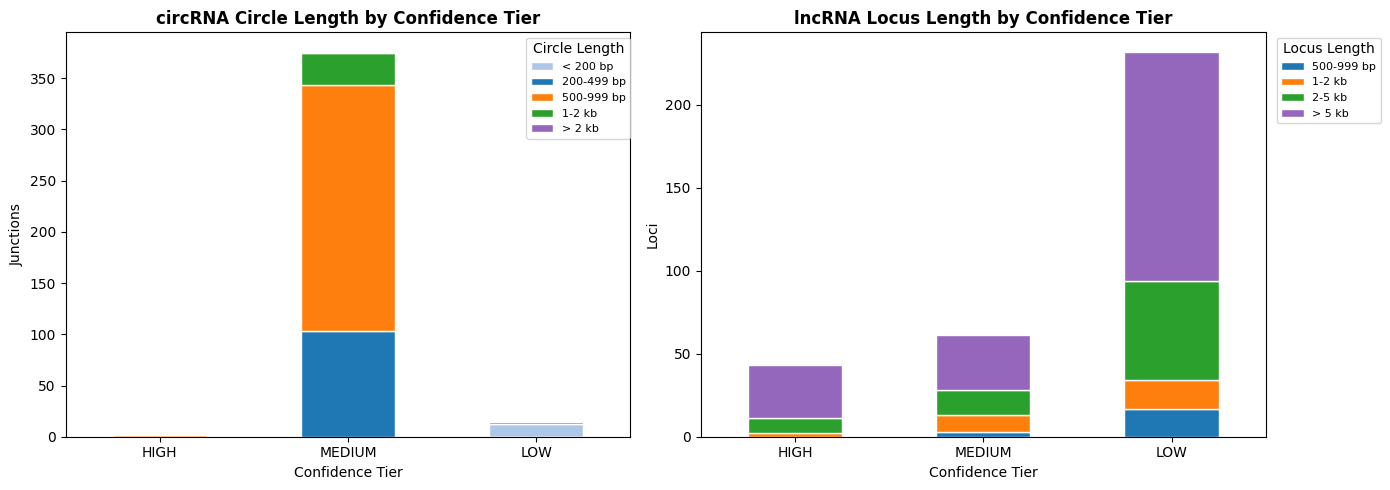

Fig L saved.


In [ ]:
# ============================================================
# VIZ-L  Length Bracket Distribution
#         circRNA circle length  &  lncRNA locus length
# ============================================================
def length_bracket_circ(n):
    try:
        n = int(n)
    except (TypeError, ValueError):
        n = 0
    if n < 200:   return '< 200 bp'
    if n < 500:   return '200-499 bp'
    if n < 1000:  return '500-999 bp'
    if n < 2000:  return '1-2 kb'
    return '> 2 kb'

LEN_ORDER_CIRC = ['< 200 bp', '200-499 bp', '500-999 bp', '1-2 kb', '> 2 kb']
LEN_COL_CIRC   = {'< 200 bp': '#aec7e8', '200-499 bp': '#1f77b4',
                  '500-999 bp': '#ff7f0e', '1-2 kb': '#2ca02c', '> 2 kb': '#9467bd'}

def length_bracket_lnc(row):
    bp = int(row['end']) - int(row['start'])
    if bp < 500:   return '< 500 bp'
    if bp < 1000:  return '500-999 bp'
    if bp < 2000:  return '1-2 kb'
    if bp < 5000:  return '2-5 kb'
    return '> 5 kb'

LEN_ORDER_LNC = ['< 500 bp', '500-999 bp', '1-2 kb', '2-5 kb', '> 5 kb']
LEN_COL_LNC   = dict(zip(LEN_ORDER_LNC, ['#aec7e8', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'max_circle_length' in _crc.columns:
    _crc['circ_len_bracket'] = _crc['max_circle_length'].apply(length_bracket_circ)
    cl_tier = (_crc.groupby(['confidence_tier', 'circ_len_bracket'])
                    .size().unstack(fill_value=0)
                    .reindex(['HIGH', 'MEDIUM', 'LOW'], fill_value=0))
    cl_cols = [c for c in LEN_ORDER_CIRC if c in cl_tier.columns]
    cl_tier[cl_cols].plot(kind='bar', ax=axes[0],
                          color=[LEN_COL_CIRC[c] for c in cl_cols],
                          edgecolor='white', stacked=True)
    axes[0].set_title('circRNA Circle Length by Confidence Tier', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Confidence Tier')
    axes[0].set_ylabel('Junctions')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
    axes[0].legend(title='Circle Length', fontsize=8, bbox_to_anchor=(1.01, 1))
    print("=== circRNA Circle Length x Confidence Tier ===")
    print(cl_tier.to_string())

if 'start' in _lnc.columns and 'end' in _lnc.columns:
    _lnc['lnc_len_bracket'] = _lnc.apply(length_bracket_lnc, axis=1)
    ll_tier = (_lnc.groupby(['confidence_tier', 'lnc_len_bracket'])
                    .size().unstack(fill_value=0)
                    .reindex(['HIGH', 'MEDIUM', 'LOW'], fill_value=0))
    ll_cols = [c for c in LEN_ORDER_LNC if c in ll_tier.columns]
    ll_tier[ll_cols].plot(kind='bar', ax=axes[1],
                          color=[LEN_COL_LNC[c] for c in ll_cols],
                          edgecolor='white', stacked=True)
    axes[1].set_title('lncRNA Locus Length by Confidence Tier', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Confidence Tier')
    axes[1].set_ylabel('Loci')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
    axes[1].legend(title='Locus Length', fontsize=8, bbox_to_anchor=(1.01, 1))
    print("\n=== lncRNA Locus Length x Confidence Tier ===")
    print(ll_tier.to_string())

plt.tight_layout()
plt.savefig(f'{LOCAL3}/vizL_length_brackets.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig L saved.")

PRIORITY CANDIDATES — Novel + HIGH confidence

-- lncRNA Priority Candidates (n=5) --
  locus_id   chr     start       end strand  n_samples  max_exon_count tumour_spec genomic_context nearest_gene  nearest_gene_brain_tpm  low_normal_brain_expression
LNC_L00295  chr7 102681421 102688217      -          6               5        Both      intergenic      POLR2J2                0.693231                         True
LNC_L00064 chr12     14521     17024      -          4               5        Both      intergenic      SLC6A12               19.679500                        False
LNC_L00284  chr7  75156638  75157943      -          3               3        Both      intergenic        RCC1L               23.681000                        False
LNC_L00160 chr19  50797760  50804639      -          2               8        Both      intergenic       SMIM47                0.186265                         True
LNC_L00281  chr7  73203422  73207283      +          2               4        Both      i

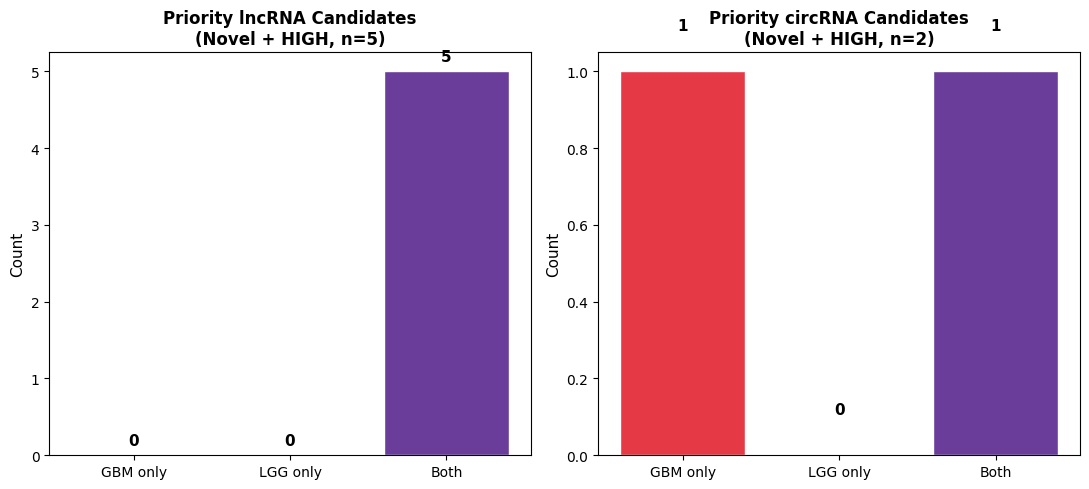

Fig M saved.


In [ ]:
# ============================================================
# VIZ-M  Priority Candidate Summary — Novel + HIGH confidence
#         Prints tables and bar chart by tumour specificity
# ============================================================
print("=" * 70)
print("PRIORITY CANDIDATES — Novel + HIGH confidence")
print("=" * 70)

cols_display_lnc = [c for c in [
    'locus_id', 'chr', 'start', 'end', 'strand',
    'n_samples', 'max_exon_count', 'tumour_spec',
    'genomic_context', 'nearest_gene',
    'nearest_gene_brain_tpm', 'low_normal_brain_expression'
] if c in _lnc.columns]

cols_display_crc = [c for c in [
    'circ_locus_id', 'junction_id', 'chr', 'start', 'end',
    'n_samples', 'max_n_exons', 'max_circle_length',
    'has_canonical_splice', 'tumour_spec',
    'host_gene', 'host_gene_brain_tpm', 'low_normal_brain_expression'
] if c in _crc.columns]

priority_lnc = pd.DataFrame()
priority_crc = pd.DataFrame()

if 'db_status' in _lnc.columns:
    priority_lnc = _lnc[
        (_lnc['confidence_tier'] == 'HIGH') & (_lnc['db_status'] == 'novel')
    ].sort_values('n_samples', ascending=False)
    print(f"\n-- lncRNA Priority Candidates (n={len(priority_lnc)}) --")
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 240)
    print(priority_lnc[cols_display_lnc].to_string(index=False))

if 'db_status' in _crc.columns:
    priority_crc = _crc[
        (_crc['confidence_tier'] == 'HIGH') & (_crc['db_status'] == 'novel')
    ].sort_values('n_samples', ascending=False)
    print(f"\n-- circRNA Priority Candidates (n={len(priority_crc)}) --")
    print(priority_crc[cols_display_crc].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, df_p, rna_type in [
        (axes[0], priority_lnc, 'lncRNA'),
        (axes[1], priority_crc, 'circRNA'),
]:
    if len(df_p) == 0:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
        ax.axis('off')
        continue
    spec_counts = (df_p['tumour_spec'].value_counts()
                   .reindex(['GBM only', 'LGG only', 'Both'], fill_value=0))
    bar_colors = [SPEC_COLORS[k] for k in spec_counts.index]
    bars = ax.bar(spec_counts.index, spec_counts.values, color=bar_colors, edgecolor='white')
    ax.set_title(f'Priority {rna_type} Candidates\n(Novel + HIGH, n={len(df_p)})',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=11)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.1, str(int(h)),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{LOCAL3}/vizM_priority_candidates.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig M saved.")

In [ ]:
# ============================================================
# VIZ-N  Save all extended visualisations to Google Drive
# ============================================================
import shutil, os

PHASE3 = '/content/drive/MyDrive/bioinfo_project/phase3'
LOCAL3 = '/content/phase3'

new_figs = [
    'vizB_recurrence_brackets.png',
    'vizC_lncrna_context_novelty.png',
    'vizD_tumour_specificity.png',
    'vizE_per_sample_counts.png',
    'vizF_splice_signals.png',
    'vizG_top_host_genes.png',
    'vizH_exon_counts.png',
    'vizI_lncrna_exon_structure.png',
    'vizJ_recurrence_survival.png',
    'vizK_tier_db_heatmap.png',
    'vizL_length_brackets.png',
    'vizM_priority_candidates.png',
]

print("Saving extended visualisations to Drive...")
for fname in new_figs:
    src  = f'{LOCAL3}/{fname}'
    dest = f'{PHASE3}/{fname}'
    if os.path.exists(src):
        shutil.copy2(src, dest)
        kb = os.path.getsize(dest) / 1024
        print(f"  ok  {fname}  ({kb:.1f} KB)")
    else:
        print(f"  MISSING  {fname}  (run the corresponding VIZ cell first)")

print(f"\nAll done. Figures stored in {PHASE3}")

Saving extended visualisations to Drive...
  ok  vizB_recurrence_brackets.png  (86.4 KB)
  ok  vizC_lncrna_context_novelty.png  (102.1 KB)
  ok  vizD_tumour_specificity.png  (66.8 KB)
  ok  vizE_per_sample_counts.png  (70.9 KB)
  MISSING  vizF_splice_signals.png  (run the corresponding VIZ cell first)
  ok  vizG_top_host_genes.png  (82.5 KB)
  ok  vizH_exon_counts.png  (63.7 KB)
  ok  vizI_lncrna_exon_structure.png  (81.7 KB)
  MISSING  vizJ_recurrence_survival.png  (run the corresponding VIZ cell first)
  ok  vizK_tier_db_heatmap.png  (137.4 KB)
  ok  vizL_length_brackets.png  (64.9 KB)
  ok  vizM_priority_candidates.png  (38.7 KB)

All done. Figures stored in /content/drive/MyDrive/bioinfo_project/phase3


In [ ]:
# ============================================================
# Cell 138 — Save All Phase 3 Outputs to Google Drive
# ============================================================
import shutil, os

os.makedirs(PHASE3, exist_ok=True)

# Files to copy
files_to_save = [
    (f'{LOCAL3}/lncrna_final_annotated.tsv', 'lncrna_final_annotated.tsv'),
    (f'{LOCAL3}/circrna_final_annotated.tsv', 'circrna_final_annotated.tsv'),
    (f'{LOCAL3}/lncrna_loci.sorted.bed', 'lncrna_loci.sorted.bed'),
    (f'{LOCAL3}/circ_loci.sorted.bed', 'circ_loci.sorted.bed'),
    (f'{LOCAL3}/confidence_tiers.png', 'confidence_tiers.png'),
    (f'{LOCAL3}/phase3_summary.png', 'phase3_summary.png'),
]

# Save text summary
summary_path = f'{LOCAL3}/phase3_summary.txt'
with open(summary_path, 'w') as f:
    f.write('\n'.join(summary_lines))
files_to_save.append((summary_path, 'phase3_summary.txt'))

# Copy all files
print("Copying Phase 3 outputs to Google Drive...")
for src, dest_name in files_to_save:
    dest = f'{PHASE3}/{dest_name}'
    if os.path.exists(src):
        shutil.copy2(src, dest)
        size_kb = os.path.getsize(dest) / 1024
        print(f"  ✓ {dest_name} ({size_kb:.1f} KB)")
    else:
        print(f"  ✗ {dest_name} — source not found: {src}")

# Verify
print(f"\n=== Files on Drive ({PHASE3}) ===")
for f in sorted(os.listdir(PHASE3)):
    size = os.path.getsize(f'{PHASE3}/{f}') / 1024
    print(f"  {f:40s} {size:8.1f} KB")

print(f"\n✓ Phase 3 complete. All outputs saved to {PHASE3}")

Copying Phase 3 outputs to Google Drive...
  ✓ lncrna_final_annotated.tsv (64.8 KB)
  ✓ circrna_final_annotated.tsv (58.5 KB)
  ✓ lncrna_loci.sorted.bed (12.7 KB)
  ✓ circ_loci.sorted.bed (14.5 KB)
  ✓ confidence_tiers.png (47.8 KB)
  ✓ phase3_summary.png (121.2 KB)
  ✓ phase3_summary.txt (1.3 KB)

=== Files on Drive (/content/drive/MyDrive/bioinfo_project/phase3) ===
  circ_loci.sorted.bed                         14.5 KB
  circrna_final_annotated.tsv                  58.5 KB
  confidence_tiers.png                         47.8 KB
  lncrna_final_annotated.tsv                   64.8 KB
  lncrna_loci.sorted.bed                       12.7 KB
  phase3_summary.png                          121.2 KB
  phase3_summary.txt                            1.3 KB

✓ Phase 3 complete. All outputs saved to /content/drive/MyDrive/bioinfo_project/phase3


In [ ]:
# ============================================================
# DIAGNOSTIC — paste full output back to the assistant
# ============================================================
import pandas as pd, numpy as np, re, os

print("=" * 60)
print("1. PATIENT MAP")
print(f"   Total entries: {len(patient_map)}")
print(f"   Max SRR number: {max(patient_map.keys())}")
print(f"   Sample: {list(patient_map.items())[:3]}")

print("\n" + "=" * 60)
print("2. CIRCRNA SANITY")
print(f"   df_circ shape: {df_circ.shape}")
print(f"   df_circ columns: {list(df_circ.columns)}")
print(f"   n_exons distribution:")
print(df_circ['n_exons'].value_counts().sort_index().head(10).to_string())
print(f"   is_canonical_splice distribution:")
print(df_circ['is_canonical_splice'].value_counts().to_string())
print(f"   ccs_passes median: {df_circ['ccs_passes'].median()}")
print(f"   n_records distribution (df_circ_loci):")
print(df_circ_loci['n_records'].value_counts().sort_index().to_string())
print(f"   max_n_exons distribution (df_circ_loci):")
print(df_circ_loci['max_n_exons'].value_counts().sort_index().head(10).to_string())
print(f"   has_canonical_splice: {df_circ_loci['has_canonical_splice'].sum()} / {len(df_circ_loci)}")

print("\n" + "=" * 60)
print("3. LNCRNA n_samples > 26 (IMPOSSIBLE ROWS)")
bad = df_lnc_loci[df_lnc_loci['n_samples'] > 26]
print(f"   Count: {len(bad)}")
if len(bad):
    print(bad[['locus_id','chr','start','end','n_samples','n_transcripts','sample_list']].head(5).to_string())

print("\n" + "=" * 60)
print("4. LNCRNA COORDINATE SPAN CHECK")
df_lnc_loci['span_mb'] = (df_lnc_loci['end'] - df_lnc_loci['start']) / 1e6
print(f"   Max span: {df_lnc_loci['span_mb'].max():.1f} Mb")
print(f"   Loci > 10 Mb span: {(df_lnc_loci['span_mb'] > 10).sum()}")
print(df_lnc_loci.nlargest(5, 'span_mb')[['locus_id','chr','start','end','span_mb','n_samples','n_transcripts']].to_string())

print("\n" + "=" * 60)
print("5. extract_srr FUNCTION TEST")
count = 0
with open(LNC_GTF) as fh:
    for line in fh:
        if line.startswith('#') or '\ttranscript\t' not in line: continue
        m = re.search(r'transcript_id "([^"]+)"', line)
        if not m: continue
        tid = m.group(1)
        srr = extract_srr(tid)
        print(f"   tid={tid[:60]}  → srr={srr}")
        count += 1
        if count >= 20: break

print("\n" + "=" * 60)
print("6. LNCRNA SAMPLE_LIST FOR BAD LOCI")
if len(bad):
    row = bad.iloc[0]
    print(f"   Locus: {row['locus_id']}  n_samples={row['n_samples']}")
    print(f"   sample_list (first 500 chars): {str(row['sample_list'])[:500]}")
    samples = [s.strip() for s in str(row['sample_list']).split(',')]
    valid_srr = [s for s in samples if re.match(r'SRR\d+', s)]
    print(f"   Total sample tokens: {len(samples)}")
    print(f"   Valid SRR tokens: {len(valid_srr)}")
    print(f"   Non-SRR tokens (first 10): {[s for s in samples if not re.match(r'SRR\d+', s)][:10]}")

print("\n" + "=" * 60)
print("7. LNCRNA MERGE INPUT BED — first 10 lines")
with open(f'{LOCAL3}/lncrna_for_merge.sorted.bed') as f:
    for i, line in enumerate(f):
        print(f"   {line.rstrip()}")
        if i >= 9: break

print("\n" + "=" * 60)
print("8. CIRCBASE COORDINATE COMPARISON")
print(f"   circBase BED exists: {os.path.exists(circbase_bed)}")
if os.path.exists(circbase_bed):
    print("   First 5 circBase entries:")
    with open(circbase_bed) as fh:
        for i, line in enumerate(fh):
            if i >= 5: break
            print(f"     {line.rstrip()}")
    print("   First 5 of our circRNA coords (from df_circ_loci):")
    for _, row in df_circ_loci.head(5).iterrows():
        print(f"     ({row['chr']}, {int(row['start'])}, {int(row['end'])}, {row['strand']})")
    print(f"   db_status counts:")
    print(f"     {df_circ_loci['db_status'].value_counts().to_string()}")

print("\nDONE")

1. PATIENT MAP
   Total entries: 26
   Max SRR number: SRR31451042
   Sample: [('SRR31451033', ('GB', 'GB_LT_Patient-1')), ('SRR31451034', ('GB', 'GB_LT_Patient-2')), ('SRR31451035', ('GB', 'GB_LT_Patient-3'))]

2. CIRCRNA SANITY
   df_circ shape: (395, 14)
   df_circ columns: ['SRR', 'circ_id', 'chr', 'start', 'end', 'strand', 'n_exons', 'circle_length', 'exon_coords', 'splice_signal', 'is_canonical_splice', 'ccs_passes', 'Tumour_Type', 'Patient_Label']
   n_exons distribution:
n_exons
1      18
2     272
3      26
4      22
5      31
6      10
7       6
8       3
9       3
10      3
   is_canonical_splice distribution:
is_canonical_splice
True     329
False     66
   ccs_passes median: 68.0
   n_records distribution (df_circ_loci):
n_records
1    391
2      2
   max_n_exons distribution (df_circ_loci):
max_n_exons
1      18
2     270
3      26
4      22
5      31
6      10
7       6
8       3
9       3
10      3
   has_canonical_splice: 327 / 393

3. LNCRNA n_samples > 26 (IMPOSSIBLE

# Phase 4 — Structure Prediction & miRNA Binding

## Goal
Predict the secondary structure (minimum free energy) of every novel transcript using **RNAfold** (Vienna RNA package) and identify **miRNA binding sites** on circRNA candidates using **miRanda**.

## Rationale
- **lncRNAs** fold into complex structures that allow them to act as scaffolds or decoys; more negative MFE → more thermodynamically stable → more likely functional.
- **circRNAs** lack free ends, making them unusually stable; many act as **miRNA sponges** — sequestering microRNAs that would otherwise suppress oncogenes. Multiple binding sites for the same oncogenic miRNA = sponge signature.

## Pipeline

| Step | Tool | Input | Output |
|------|------|-------|--------|
| 1 | RNAfold | lncRNA FASTA | MFE (kcal/mol), structure (dot-bracket) per transcript |
| 2 | RNAfold | circRNA FASTA | MFE (kcal/mol), structure (dot-bracket) per junction |
| 3 | miRanda | circRNA FASTA × mature miRNAs | Predicted binding sites per circRNA |
| 4 | Analysis | miRanda output | Sponge candidates (≥3 sites for same miRNA) |
| 5 | Integration | Phase 3 tables + Phase 4 results | Updated annotated TSVs |

## Inputs (from Phase 3 / Phase 2, on Google Drive)
- `phase2/feelnc_cpc2/final_lncRNA_candidates.fa` — lncRNA sequences
- `phase2/ciri_long_jlk/SRR*_out/*.cand_circ.fa` — circRNA sequences
- `phase3/lncrna_final_annotated.tsv` — lncRNA annotations
- `phase3/circrna_final_annotated.tsv` — circRNA annotations

In [ ]:
# ============================================================
# Cell P4-1 — Phase 4 Setup
# ============================================================
import os, subprocess, re, shutil, json
import pandas as pd
import numpy as np
from collections import defaultdict
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

# ---------- Install ViennaRNA ----------
print("Installing ViennaRNA...")
subprocess.run(['apt-get', '-qq', 'update'], check=True)
subprocess.run(['apt-get', '-qq', 'install', '-y', 'vienna-rna'], check=True)

# ----------------------------
# Helper to detect tools
# ----------------------------
def has_tool(tool):
    r = subprocess.run(['which', tool], capture_output=True, text=True)
    return r.returncode == 0, r.stdout.strip()

# ----------------------------
# Install miRanda using micromamba + bioconda
# ----------------------------
MIRANDA_CMD = None

ok, path = has_tool('miranda')
if ok:
    print(f"miRanda already installed: {path}")
    MIRANDA_CMD = ['miranda']
else:
    print("\nmiRanda not found. Installing with micromamba + Bioconda...")

    try:
        # Install micromamba binary if missing
        if not os.path.exists('/content/bin/micromamba'):
            print("Installing micromamba...")
            subprocess.run(
                "mkdir -p /content/bin && "
                "wget -qO- https://micromamba.snakepit.net/api/micromamba/linux-64/latest | "
                "tar -xvj -C /content bin/micromamba",
                shell=True,
                check=True
            )

        # Create environment only if not already موجود
        env_prefix = '/content/micromamba'
        env_path = f'{env_prefix}/envs/miranda_env'

        if not os.path.exists(env_path):
            print("Creating miranda_env...")
            subprocess.run(
                [
                    '/content/bin/micromamba', 'create', '-y',
                    '-r', env_prefix,
                    '-n', 'miranda_env',
                    '-c', 'conda-forge',
                    '-c', 'bioconda',
                    'miranda'
                ],
                check=True
            )
        else:
            print("micromamba environment already exists.")

        # Test miRanda
        print("Testing miRanda...")
        subprocess.run(
            [
                '/content/bin/micromamba', 'run',
                '-r', env_prefix,
                '-n', 'miranda_env',
                'miranda', '-h'
            ],
            check=True
        )

        MIRANDA_CMD = [
            '/content/bin/micromamba', 'run',
            '-r', env_prefix,
            '-n', 'miranda_env',
            'miranda'
        ]

    except Exception as e:
        print("\nmiRanda installation failed.")
        print(e)
        MIRANDA_CMD = None
# ---------- Verify ----------
for tool in ['RNAfold', 'miranda']:
    ok, path = has_tool(tool)
    print(f"{tool}: {'OK' if ok else 'MISSING'} {path}")

# ---------- Paths ----------
DRIVE       = '/content/drive/MyDrive/bioinfo_project'
PHASE2_LNC  = f'{DRIVE}/phase2/feelnc_cpc2'
CIRI_ROOT   = f'{DRIVE}/phase2/ciri_long_jlk'
PHASE3      = f'{DRIVE}/phase3'
PHASE4      = f'{DRIVE}/phase4'
LOCAL4      = '/content/phase4'

os.makedirs(PHASE4, exist_ok=True)
os.makedirs(LOCAL4, exist_ok=True)

# ---------- Load Phase 3 outputs ----------
df_lnc_final  = pd.read_csv(f'{PHASE3}/lncrna_final_annotated.tsv', sep='\t')
df_circ_final = pd.read_csv(f'{PHASE3}/circrna_final_annotated.tsv', sep='\t')

# ---------- Load patient metadata ----------
df_meta = pd.read_csv(f'{DRIVE}/patient_metadata.csv')
patient_map = dict(zip(df_meta['Run'], zip(df_meta['Tumour_Type'], df_meta['Patient_Label'])))

# ---------- Input FASTA ----------
LNC_FA = f'{PHASE2_LNC}/final_lncRNA_candidates.fa'

print("\n=== Phase 4 Setup ===")
print(f"lncRNA final table : {df_lnc_final.shape[0]} rows")
print(f"circRNA final table: {df_circ_final.shape[0]} rows")
print(f"lncRNA FASTA       : {'EXISTS' if os.path.exists(LNC_FA) else 'MISSING'}")
print(f"CIRI root          : {'EXISTS' if os.path.exists(CIRI_ROOT) else 'MISSING'}")

# ---------- Download mature human miRNAs ----------
MIRBASE_FA = f'{LOCAL4}/mature.fa'
HSA_MIR_FA = f'{LOCAL4}/hsa_mature.fa'

if not os.path.exists(MIRBASE_FA):
    print("Downloading miRBase mature.fa ...")
    subprocess.run(
        ['wget', '-q', '-O', MIRBASE_FA, 'https://www.mirbase.org/download/CURRENT/mature.fa'],
        check=True
    )

# Keep only human mature miRNAs
with open(MIRBASE_FA) as fin, open(HSA_MIR_FA, 'w') as fout:
    keep = False
    for line in fin:
        if line.startswith('>'):
            keep = line.startswith('>hsa-')
        if keep:
            fout.write(line)

print(f"Human miRNA FASTA saved to: {HSA_MIR_FA}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Installing ViennaRNA...

miRanda not found. Installing with micromamba + Bioconda...
micromamba environment already exists.
Testing miRanda...
RNAfold: OK /usr/bin/RNAfold
miranda: MISSING 

=== Phase 4 Setup ===
lncRNA final table : 336 rows
circRNA final table: 393 rows
lncRNA FASTA       : EXISTS
CIRI root          : EXISTS
Human miRNA FASTA saved to: /content/phase4/hsa_mature.fa


In [ ]:
# ============================================================
# Cell P4-1b — Verify miRanda after micromamba install
# ============================================================
import os
import subprocess

MIRANDA_CMD = [
    '/content/bin/micromamba', 'run',
    '-r', '/content/micromamba',
    '-n', 'miranda_env',
    'miranda'
]

print("Checking miRanda help...\n")
result = subprocess.run(MIRANDA_CMD + ['-h'], capture_output=True, text=True)

print("Return code:", result.returncode)
print("\nSTDOUT preview:\n", result.stdout[:1000])
print("\nSTDERR preview:\n", result.stderr[:1000])

if result.returncode == 0:
    print("\nmiRanda is ready.")
else:
    print("\nmiRanda is still not working.")

Checking miRanda help...

Return code: 0

STDOUT preview:
 

=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
miranda v3.3a    microRNA Target Scanning Algorithm
=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
(c) 2003 Memorial Sloan-Kettering Cancer Center, New York

Authors: Anton Enright, Bino John, Chris Sander and Debora Marks
(mirnatargets (at) cbio.mskcc.org - reaches all authors)

Software written by: Anton Enright
Distributed for anyone to use under the GNU Public License (GPL),
See the files 'COPYING' and 'LICENSE' for details

If you use this software please cite:
Enright AJ, John B, Gaul U, Tuschl T, Sander C and Marks DS;
(2003) Genome Biology; 5(1):R1.

   miranda comes with ABSOLUTELY NO WARRANTY;
   This is free software, and you are welcome to redistribute it
   under certain conditions; type `miranda --license' for details.

miRanda is an miRNA target scanner which aims to predict mRNA
targets for microRNAs using dynamic-programming alig

In [ ]:
# ============================================================
# Cell P4-2 — RNAfold on lncRNA Candidates
# ============================================================
# Predict minimum free energy (MFE) secondary structure for each
# lncRNA transcript. RNAfold reads FASTA from stdin and outputs
# the dot-bracket structure + MFE for each sequence.
#
# For long sequences (>5000 nt), we use --noLP (no lonely pairs)
# to speed up folding while maintaining accuracy.
# ============================================================
!pip install biopython
from Bio import SeqIO
import subprocess, re, os
import numpy as np

LNC_FA = f'{PHASE2_LNC}/final_lncRNA_candidates.fa'

# Parse all lncRNA sequences
lnc_seqs = {rec.id: str(rec.seq) for rec in SeqIO.parse(LNC_FA, 'fasta')}
print(f"Loaded {len(lnc_seqs)} lncRNA sequences from FASTA")

# Run RNAfold in batch mode
# Write sequences to a temp FASTA (one per transcript)
rnafold_input = f'{LOCAL4}/lncrna_for_rnafold.fa'
with open(rnafold_input, 'w') as fh:
    for tid, seq in lnc_seqs.items():
        fh.write(f'>{tid}\n{seq}\n')

print("Running RNAfold on lncRNA candidates (this may take a while)...")
rnafold_out = f'{LOCAL4}/lncrna_rnafold.txt'

# --noPS suppresses PostScript output, --noLP for speed on long seqs
result = subprocess.run(
    ['RNAfold', '--noPS', '--noLP'],
    stdin=open(rnafold_input),
    stdout=open(rnafold_out, 'w'),
    stderr=subprocess.PIPE,
    text=True
)

if result.returncode != 0:
    print(f"WARNING: RNAfold stderr: {result.stderr[:500]}")
else:
    print("RNAfold completed successfully")

# Parse RNAfold output
# Format:
# >transcript_id
# SEQUENCE
# STRUCTURE (MFE)
mfe_re = re.compile(r'\s+\(\s*(-?\d+\.?\d*)\s*\)')

lnc_mfe = {}
lnc_structure = {}
current_id = None

with open(rnafold_out) as fh:
    for line in fh:
        line = line.strip()
        if line.startswith('>'):
            current_id = line[1:].split()[0]
        elif current_id and '(' in line and ')' in line:
            m = mfe_re.search(line)
            if m:
                mfe_val = float(m.group(1))
                structure = line[:line.rfind('(')].strip()
                lnc_mfe[current_id] = mfe_val
                lnc_structure[current_id] = structure
                current_id = None

print(f"\nParsed MFE for {len(lnc_mfe)} lncRNA transcripts")
if lnc_mfe:
    mfe_vals = list(lnc_mfe.values())
    print(f"  MFE range: {min(mfe_vals):.1f} to {max(mfe_vals):.1f} kcal/mol")
    print(f"  Median MFE: {np.median(mfe_vals):.1f} kcal/mol")
    # Show top 5 most stable
    sorted_mfe = sorted(lnc_mfe.items(), key=lambda x: x[1])
    print(f"\n  Top 5 most stable lncRNAs:")
    for tid, mfe in sorted_mfe[:5]:
        seq_len = len(lnc_seqs.get(tid, ''))
        print(f"    {tid[:50]:50s}  MFE={mfe:8.1f} kcal/mol  len={seq_len} nt")

Loaded 929 lncRNA sequences from FASTA
Running RNAfold on lncRNA candidates (this may take a while)...


KeyboardInterrupt: 

### Phase 4A Results: Secondary Structure Prediction for lncRNAs

We predicted the secondary structure of all candidate lncRNA transcripts using **RNAfold** from the ViennaRNA package. For each sequence, RNAfold returns a **dot-bracket secondary structure** and a **minimum free energy (MFE)** value, which reflects the thermodynamic stability of the predicted fold. In general, more negative MFE values indicate more stable RNA structures.

In our analysis, RNAfold successfully folded **929 lncRNA transcripts**, with MFE values ranging from **-1148.7 to -43.5 kcal/mol** and a median MFE of **-244.1 kcal/mol**. This confirms that the candidate lncRNAs display substantial structural diversity, from relatively simple folds to highly stable and complex secondary structures.

However, **raw MFE alone is not sufficient for ranking transcripts**, because it is strongly influenced by **sequence length**. Longer RNAs naturally form more base pairs and therefore tend to have more negative total free energy values, even if they are not structurally more compact or biologically more interesting than shorter RNAs. For this reason, comparing transcripts only by raw MFE would bias the ranking toward long transcripts.

To correct for this, we also calculate **MFE per nucleotide (MFE/nt)** by dividing the total MFE by transcript length. This normalized measure provides a fairer way to compare structural stability across transcripts of different sizes. A transcript with a highly negative **MFE per nt** is more likely to be intrinsically stable relative to its length, making it a stronger candidate for potential functional relevance.

For downstream prioritization, we therefore rely more on **MFE per nt** than on raw MFE. This allows us to identify lncRNAs whose structural stability is not simply a consequence of being long, but instead reflects a genuinely strong folding tendency that may support functional roles such as scaffolding, molecular decoy activity, or interaction with proteins and other RNAs.

In [ ]:
# ============================================================
# Compute MFE per nt and rank lncRNAs
# ============================================================
import pandas as pd
import numpy as np

# Build structure table from the RNAfold output you already parsed
lnc_records = []

for tid, mfe in lnc_mfe.items():
    seq = lnc_seqs.get(tid, "")
    seq_len = len(seq)
    structure = lnc_structure.get(tid, "")

    lnc_records.append({
        'transcript_id': tid,
        'sequence_length': seq_len,
        'mfe_kcal_mol': mfe,
        'mfe_per_nt': (mfe / seq_len) if seq_len > 0 else np.nan,
        'dot_bracket': structure
    })

df_lnc_struct = pd.DataFrame(lnc_records)

print("lncRNA structure table shape:", df_lnc_struct.shape)
display(df_lnc_struct.head())

# Save raw structure table
lnc_struct_out = f'{LOCAL4}/lncrna_structure.tsv'
df_lnc_struct.to_csv(lnc_struct_out, sep='\t', index=False)
print(f"Saved to: {lnc_struct_out}")

# Rank by normalized stability
df_lnc_struct_ranked = df_lnc_struct.sort_values('mfe_per_nt', ascending=True).copy()

print("\nTop 20 most structurally stable lncRNAs by MFE per nt:")
display(df_lnc_struct_ranked[['transcript_id', 'sequence_length', 'mfe_kcal_mol', 'mfe_per_nt']].head(20))

# Summary
print("\nSummary statistics:")
print("Median raw MFE    :", round(df_lnc_struct['mfe_kcal_mol'].median(), 3))
print("Median MFE per nt :", round(df_lnc_struct['mfe_per_nt'].median(), 5))
print("Most negative raw MFE    :", round(df_lnc_struct['mfe_kcal_mol'].min(), 3))
print("Most negative MFE per nt :", round(df_lnc_struct['mfe_per_nt'].min(), 5))

In [ ]:
# ============================================================
#  Visualize RNA secondary structure (top candidates)
# ============================================================
import os
import subprocess

# Pick top 5 most stable by MFE per nt
top5 = df_lnc_struct.sort_values('mfe_per_nt').head(5)

vis_dir = f"{LOCAL4}/rna_visuals"
os.makedirs(vis_dir, exist_ok=True)

for _, row in top5.iterrows():
    tid = row['transcript_id']
    seq = lnc_seqs[tid]

    fasta_file = f"{vis_dir}/{tid}.fa"

    with open(fasta_file, "w") as f:
        f.write(f">{tid}\n{seq}\n")

    # Run RNAfold WITH visualization
    subprocess.run(
        f"RNAfold < {fasta_file}",
        shell=True,
        cwd=vis_dir
    )

print(f"Visualization files saved in: {vis_dir}")

In [ ]:
# Install ghostscript
!apt-get -qq update
!apt-get -qq install -y ghostscript

import glob, os, subprocess
from IPython.display import Image, display

ps_files = glob.glob(f"{vis_dir}/*.ps")
print("PS files found:", len(ps_files))

for ps in ps_files:
    png = ps.replace(".ps", ".png")
    subprocess.run([
        "gs",
        "-dSAFER",
        "-dBATCH",
        "-dNOPAUSE",
        "-sDEVICE=pngalpha",
        "-r200",
        f"-sOutputFile={png}",
        ps
    ], check=True)

png_files = glob.glob(f"{vis_dir}/*.png")
print("PNG files created:", len(png_files))

for f in sorted(png_files):
    print(os.path.basename(f))
    display(Image(filename=f))

In [ ]:
# Save ranked lncRNA structure table
lnc_ranked_out = f"{LOCAL4}/lncrna_structure_ranked_by_mfe_per_nt.tsv"
df_lnc_struct.sort_values("mfe_per_nt", ascending=True).to_csv(lnc_ranked_out, sep="\t", index=False)
print("Saved:", lnc_ranked_out)

In [ ]:
# ============================================================
# Save important Phase 4 outputs to Google Drive
# ============================================================
import os
import shutil
import glob

drive_save_dir = f"{DRIVE}/phase4_saved_outputs"
os.makedirs(drive_save_dir, exist_ok=True)

files_to_save = [
    f"{LOCAL4}/lncrna_for_rnafold.fa",
    f"{LOCAL4}/lncrna_rnafold.txt",
    f"{LOCAL4}/lncrna_structure.tsv",
    f"{LOCAL4}/mature.fa",
    f"{LOCAL4}/hsa_mature.fa",
]

# add visual files too
files_to_save += glob.glob(f"{LOCAL4}/rna_visuals/*.ps")
files_to_save += glob.glob(f"{LOCAL4}/rna_visuals/*.png")

saved = []
missing = []

for fp in files_to_save:
    if os.path.exists(fp):
        dest = os.path.join(drive_save_dir, os.path.basename(fp))
        shutil.copy2(fp, dest)
        saved.append(dest)
    else:
        missing.append(fp)

print("Saved files:")
for s in saved:
    print(" -", s)

if missing:
    print("\nMissing files:")
    for m in missing:
        print(" -", m)

print(f"\nAll saved into: {drive_save_dir}")

In [ ]:
# ============================================================
# Inspect circRNA FASTA headers from CIRI-long
# ============================================================
import os
from Bio import SeqIO

sample_dirs = sorted([
    d for d in os.listdir(CIRI_ROOT)
    if os.path.isdir(os.path.join(CIRI_ROOT, d)) and d.endswith('_out')
])

print("Number of CIRI sample directories:", len(sample_dirs))
print("First 10 sample dirs:", sample_dirs[:10])

preview_count = 0
preview_limit = 20

for sd in sample_dirs:
    srr = sd.replace('_out', '')
    fa_path = os.path.join(CIRI_ROOT, sd, f'{srr}.cand_circ.fa')

    if not os.path.exists(fa_path):
        continue

    print(f"\n=== {srr} ===")
    for rec in SeqIO.parse(fa_path, 'fasta'):
        print("ID       :", rec.id)
        print("DESC     :", rec.description)
        print("SEQ LEN  :", len(rec.seq))
        preview_count += 1
        if preview_count >= preview_limit:
            break

    if preview_count >= preview_limit:
        break

if preview_count == 0:
    print("No .cand_circ.fa files were found or parsed.")
else:
    print(f"\nPreviewed {preview_count} circRNA FASTA records.")

In [ ]:
# ============================================================
# circRNA extraction (handles NA strand)
# ============================================================
import os
import re
import pandas as pd
from Bio import SeqIO

sample_dirs = sorted([
    d for d in os.listdir(CIRI_ROOT)
    if os.path.isdir(os.path.join(CIRI_ROOT, d)) and d.endswith('_out')
])

coord_re = re.compile(r'(chr[\w.-]+):(\d+)-(\d+)')

circ_seq_records = []

for sd in sample_dirs:
    srr = sd.replace('_out', '')
    fa_path = os.path.join(CIRI_ROOT, sd, f'{srr}.cand_circ.fa')

    if not os.path.exists(fa_path):
        continue

    tumour_type, patient_label = patient_map.get(srr, ('Unknown', srr))

    for rec in SeqIO.parse(fa_path, 'fasta'):
        header = rec.description

        chrom = start = end = strand = None

        # Extract coordinates
        m = coord_re.search(header)
        if m:
            chrom = m.group(1)
            start = int(m.group(2))
            end = int(m.group(3))

        # Extract strand if present
        tokens = re.split(r'[\t| ]+', header)
        for t in tokens:
            if t in ['+', '-']:
                strand = t
                break

        circ_seq_records.append({
            'junction_id_full': f"{chrom}:{start}-{end}:{strand}" if strand else None,
            'junction_id_nostrand': f"{chrom}:{start}-{end}",
            'chr': chrom,
            'start': start,
            'end': end,
            'strand': strand,
            'sequence': str(rec.seq),
            'sequence_length': len(rec.seq)
        })

df_circ_seq = pd.DataFrame(circ_seq_records)

print("Extracted circ sequences:", df_circ_seq.shape)

# Keep best per coordinate (ignore strand)
df_circ_seq_best = (
    df_circ_seq
    .dropna(subset=['chr', 'start', 'end'])
    .sort_values(['junction_id_nostrand', 'sequence_length'], ascending=[True, False])
    .drop_duplicates('junction_id_nostrand')
    .copy()
)

print("Unique circRNAs (no strand):", len(df_circ_seq_best))

# Build same no-strand key for final table
df_circ_final['junction_id_nostrand'] = (
    df_circ_final['chr'].astype(str) + ':' +
    df_circ_final['start'].astype(str) + '-' +
    df_circ_final['end'].astype(str)
)

# Merge ignoring strand
df_circ_struct_input = df_circ_final.merge(
    df_circ_seq_best[['junction_id_nostrand', 'sequence', 'sequence_length']],
    on='junction_id_nostrand',
    how='left'
)

print("\nRecovered sequences:")
print(df_circ_struct_input['sequence'].notna().sum(), "/", len(df_circ_struct_input))

display(
    df_circ_struct_input[['junction_id', 'sequence_length']]
    .head()
)

# Save
out_path = f'{LOCAL4}/circ_input_with_sequences.tsv'
df_circ_struct_input.to_csv(out_path, sep='\t', index=False)
print(f"\nSaved to: {out_path}")

In [ ]:
# ============================================================
# RNAfold on circRNA candidates
# ============================================================
import os
import re
import subprocess
import pandas as pd
import numpy as np

# Input/output paths
circ_fa = f'{LOCAL4}/circrna_for_rnafold.fa'
circ_rnafold_out = f'{LOCAL4}/circrna_rnafold.txt'
circ_struct_out = f'{LOCAL4}/circrna_structure.tsv'

# Keep only circRNAs with sequences
valid_circ = df_circ_struct_input.dropna(subset=['sequence']).copy()
print(f"circRNAs with sequences to fold: {len(valid_circ)}")

# Write FASTA
with open(circ_fa, 'w') as fh:
    for _, row in valid_circ.iterrows():
        fh.write(f">{row['junction_id']}\n{row['sequence']}\n")

print(f"RNAfold input written to: {circ_fa}")

# Run RNAfold
print("\nRunning RNAfold on circRNAs...")
with open(circ_fa, 'r') as fin, open(circ_rnafold_out, 'w') as fout:
    result = subprocess.run(
        ['RNAfold', '--noPS', '--noLP'],
        stdin=fin,
        stdout=fout,
        stderr=subprocess.PIPE,
        text=True
    )

print("RNAfold return code:", result.returncode)
if result.stderr.strip():
    print("\nRNAfold stderr preview:")
    print(result.stderr[:1000])

# Parse output
mfe_re = re.compile(r'\(\s*(-?\d+\.?\d*)\s*\)$')

records = []
current_id = None
current_seq = None

with open(circ_rnafold_out, 'r') as fh:
    for line in fh:
        line = line.strip()
        if not line:
            continue

        if line.startswith('>'):
            current_id = line[1:].split()[0]
            current_seq = None

        elif current_id is not None and current_seq is None:
            current_seq = line

        elif current_id is not None and '(' in line and ')' in line:
            m = mfe_re.search(line)
            if m:
                mfe = float(m.group(1))
                structure = line[:line.rfind('(')].strip()
                seq_len = len(current_seq)

                records.append({
                    'junction_id': current_id,
                    'sequence_length': seq_len,
                    'mfe_kcal_mol': mfe,
                    'mfe_per_nt': mfe / seq_len if seq_len > 0 else np.nan,
                    'dot_bracket': structure
                })

            current_id = None
            current_seq = None

df_circ_struct = pd.DataFrame(records)

print("\nParsed circRNA structure results:")
print("Shape:", df_circ_struct.shape)
display(df_circ_struct.head())

# Save raw structure table
df_circ_struct.to_csv(circ_struct_out, sep='\t', index=False)
print(f"\nSaved raw circRNA structure table to: {circ_struct_out}")

# Merge into circRNA final table
df_circ_phase4 = df_circ_struct_input.merge(
    df_circ_struct,
    on='junction_id',
    how='left',
    suffixes=('', '_struct')
)

circ_phase4_out = f'{PHASE4}/circrna_final_with_structure.tsv'
df_circ_phase4.to_csv(circ_phase4_out, sep='\t', index=False)

print(f"Saved merged circRNA Phase 4 table to: {circ_phase4_out}")
print("circRNAs with structure:", df_circ_phase4['mfe_kcal_mol'].notna().sum(), "/", len(df_circ_phase4))

print("\nSummary statistics:")
print("Median raw MFE    :", round(df_circ_phase4['mfe_kcal_mol'].median(), 3))
print("Median MFE per nt :", round(df_circ_phase4['mfe_per_nt'].median(), 5))
print("Most negative raw MFE    :", round(df_circ_phase4['mfe_kcal_mol'].min(), 3))
print("Most negative MFE per nt :", round(df_circ_phase4['mfe_per_nt'].min(), 5))

print("\nTop 15 most stable circRNAs by MFE per nt:")
display(
    df_circ_phase4[['junction_id', 'sequence_length_struct', 'mfe_kcal_mol', 'mfe_per_nt']]
    .sort_values('mfe_per_nt', ascending=True)
    .head(15)
)

In [ ]:
# ============================================================
# Visualize circRNA secondary structures
# ============================================================
import os
import re
import glob
import subprocess
from IPython.display import Image, display

circ_vis_dir = f"{LOCAL4}/circrna_visuals"
os.makedirs(circ_vis_dir, exist_ok=True)

# Clean old files
for f in glob.glob(f"{circ_vis_dir}/*"):
    os.remove(f)

# Pick candidates:
# - top 1 overall
# - next 4 with length >= 200 nt to avoid only tiny circRNAs
top_all = df_circ_phase4.sort_values('mfe_per_nt', ascending=True).head(1)
top_len_filtered = (
    df_circ_phase4[df_circ_phase4['sequence_length_struct'] >= 200]
    .sort_values('mfe_per_nt', ascending=True)
    .head(4)
)

to_plot = pd.concat([top_all, top_len_filtered]).drop_duplicates('junction_id')

print("Selected circRNAs for visualization:")
display(to_plot[['junction_id', 'sequence_length_struct', 'mfe_kcal_mol', 'mfe_per_nt']])

def safe_name(x):
    return re.sub(r'[^A-Za-z0-9._-]', '_', str(x))

# Build a sequence lookup from the merged circ table
circ_seq_lookup = dict(zip(df_circ_phase4['junction_id'], df_circ_phase4['sequence']))

# Run RNAfold with PS output
for _, row in to_plot.iterrows():
    jid = row['junction_id']
    seq = circ_seq_lookup[jid]
    fname = safe_name(jid)

    fasta_file = f"{circ_vis_dir}/{fname}.fa"
    with open(fasta_file, "w") as f:
        f.write(f">{jid}\n{seq}\n")

    res = subprocess.run(
        f"cd {circ_vis_dir} && RNAfold < {fname}.fa",
        shell=True,
        capture_output=True,
        text=True
    )

    print(f"\n{jid}")
    print("Return code:", res.returncode)
    if res.stderr.strip():
        print("STDERR preview:")
        print(res.stderr[:300])

print("\nFiles created:")
for f in sorted(glob.glob(f"{circ_vis_dir}/*")):
    print(os.path.basename(f))

In [ ]:
# ============================================================
# Convert circRNA structure plots to PNG and display
# ============================================================
!apt-get -qq update
!apt-get -qq install -y ghostscript

import glob
import os
import subprocess
from IPython.display import Image, display

ps_files = glob.glob(f"{circ_vis_dir}/*.ps")
print("PS files found:", len(ps_files))

for ps in ps_files:
    png = ps.replace(".ps", ".png")
    subprocess.run([
        "gs",
        "-dSAFER",
        "-dBATCH",
        "-dNOPAUSE",
        "-sDEVICE=pngalpha",
        "-r200",
        f"-sOutputFile={png}",
        ps
    ], check=True)

png_files = glob.glob(f"{circ_vis_dir}/*.png")
print("PNG files created:", len(png_files))

for f in sorted(png_files):
    print("\n", os.path.basename(f))
    display(Image(filename=f))

In [ ]:
# ============================================================
# Re-download mature.fa with curl -L
# ============================================================
import os
import subprocess

MIRBASE_FA = f'{LOCAL4}/mature.fa'
HSA_MIR_FA = f'{LOCAL4}/hsa_mature.fa'

# remove old broken files
for fp in [MIRBASE_FA, HSA_MIR_FA]:
    if os.path.exists(fp):
        os.remove(fp)

subprocess.run(
    ['curl', '-L', 'https://www.mirbase.org/download/CURRENT/mature.fa', '-o', MIRBASE_FA],
    check=True
)

print("Downloaded mature.fa")
print("Size:", os.path.getsize(MIRBASE_FA), "bytes")

print("\nPreview:")
with open(MIRBASE_FA, 'r', errors='ignore') as fh:
    for i, line in enumerate(fh):
        print(line.rstrip())
        if i >= 9:
            break

In [ ]:
# ============================================================
# Fix HTML-encoded mature.fa and rebuild hsa_mature.fa
# ============================================================
import os
import html
import re

MIRBASE_HTML = MIRBASE_FA
MIRBASE_FIXED = f"{LOCAL4}/mature_fixed.fa"
HSA_MIR_FA = f"{LOCAL4}/hsa_mature.fa"

# Read the bad file
with open(MIRBASE_HTML, "r", errors="ignore") as fh:
    raw = fh.read()

# Convert HTML entities and tags to plain FASTA text
fixed = html.unescape(raw)          # &gt; -> >
fixed = fixed.replace("<br>", "\n")
fixed = fixed.replace("<br/>", "\n")
fixed = fixed.replace("<br />", "\n")
fixed = fixed.replace("<p>", "")
fixed = fixed.replace("</p>", "\n")

# Remove any remaining HTML tags
fixed = re.sub(r"<[^>]+>", "", fixed)

# Normalize spacing/newlines a bit
fixed = fixed.replace("\r", "\n")
fixed = re.sub(r"\n{3,}", "\n\n", fixed)

with open(MIRBASE_FIXED, "w") as fh:
    fh.write(fixed)

print("Saved fixed FASTA:", MIRBASE_FIXED)
print("Size:", os.path.getsize(MIRBASE_FIXED), "bytes")

print("\nPreview of fixed FASTA:")
with open(MIRBASE_FIXED, "r") as fh:
    for i, line in enumerate(fh):
        print(line.rstrip())
        if i >= 9:
            break

# Build human-only FASTA
n_total = 0
n_hsa = 0

with open(MIRBASE_FIXED, "r") as fin, open(HSA_MIR_FA, "w") as fout:
    keep = False
    for line in fin:
        if line.startswith(">"):
            n_total += 1
            name = line[1:].strip().split()[0]
            keep = name.startswith("hsa-")
            if keep:
                n_hsa += 1
        if keep:
            fout.write(line)

print("\nTotal entries found:", n_total)
print("Human hsa-* entries:", n_hsa)
print("Saved human FASTA:", HSA_MIR_FA)
print("Human FASTA size:", os.path.getsize(HSA_MIR_FA), "bytes")

print("\nPreview of hsa_mature.fa:")
with open(HSA_MIR_FA, "r") as fh:
    for i, line in enumerate(fh):
        print(line.rstrip())
        if i >= 9:
            break

In [ ]:
# ============================================================
# Re-run miRanda after fixing hsa_mature.fa
# ============================================================
import os
import subprocess

MIRANDA_OUT_RELAXED = f'{LOCAL4}/miranda_circRNA_vs_hsa_relaxed.txt'

result = subprocess.run(
    MIRANDA_CMD + [
        HSA_MIR_FA,
        circ_fa,
        '-sc', '120',
        '-en', '-5',
        '-out', MIRANDA_OUT_RELAXED
    ],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print("Output exists:", os.path.exists(MIRANDA_OUT_RELAXED))
if os.path.exists(MIRANDA_OUT_RELAXED):
    print("Output size (bytes):", os.path.getsize(MIRANDA_OUT_RELAXED))

print("\nFirst 80 lines:")
with open(MIRANDA_OUT_RELAXED, 'r') as fh:
    for i, line in enumerate(fh):
        print(line.rstrip())
        if i >= 79:
            break

In [ ]:
# ============================================================
# FIXED robust miRanda parser
# ============================================================
import pandas as pd
import re

MIRANDA_OUT_RELAXED = f'{LOCAL4}/miranda_circRNA_vs_hsa_relaxed.txt'

hit_records = []

with open(MIRANDA_OUT_RELAXED, 'r') as fh:
    for line in fh:
        line = line.strip()

        # Match lines like:
        # >hsa-let-7a-5p chrM:3484-9990(+) 148.00 -21.16 ...
        if line.startswith(">") and not line.startswith(">>"):

            # Split by ANY whitespace (space or tab)
            parts = re.split(r'\s+', line[1:])

            # We only need first 4 columns
            if len(parts) >= 4:
                try:
                    hit_records.append({
                        'miRNA': parts[0],
                        'junction_id': parts[1],
                        'score': float(parts[2]),
                        'energy': float(parts[3])
                    })
                except:
                    continue

df_hits = pd.DataFrame(hit_records)

print("Parsed hit rows:", len(df_hits))
display(df_hits.head(20))

# Save
hits_out = f'{LOCAL4}/miranda_hits.tsv'
df_hits.to_csv(hits_out, sep='\t', index=False)
print(f"Saved: {hits_out}")

In [ ]:
# ============================================================
# Filter high-quality miRNA hits
# ============================================================
df_hits_filtered = df_hits[
    (df_hits['score'] >= 130) &
    (df_hits['energy'] <= -10)
].copy()

print("Filtered hits:", len(df_hits_filtered))
display(df_hits_filtered.head())

In [ ]:
# ============================================================
#  Count repeated miRNA binding sites
# ============================================================
sponge_summary = (
    df_hits_filtered
    .groupby(['junction_id', 'miRNA'])
    .size()
    .reset_index(name='n_sites')
    .sort_values(['n_sites', 'junction_id'], ascending=[False, True])
)

display(sponge_summary.head(20))

In [ ]:
# ============================================================
# Identify sponge candidates
# ============================================================
sponge_summary['sponge_candidate'] = sponge_summary['n_sites'] >= 3
sponge_summary['strong_sponge'] = sponge_summary['n_sites'] >= 5

print("Total sponge candidates:",
      sponge_summary['sponge_candidate'].sum())

print("Strong sponge candidates:",
      sponge_summary['strong_sponge'].sum())

display(
    sponge_summary.sort_values('n_sites', ascending=False).head(20)
)

In [ ]:
# Stricter post-filtering
df_hits_strict = df_hits[
    (df_hits['score'] >= 140) &
    (df_hits['energy'] <= -10)
].copy()

print("Strict filtered hits:", len(df_hits_strict))

sponge_summary_strict = (
    df_hits_strict.groupby(['junction_id', 'miRNA'])
    .size()
    .reset_index(name='n_sites')
    .sort_values(['n_sites', 'junction_id'], ascending=[False, True])
)

sponge_summary_strict['sponge_candidate'] = sponge_summary_strict['n_sites'] >= 3
sponge_summary_strict['strong_sponge'] = sponge_summary_strict['n_sites'] >= 5

circ_sponge_strict = (
    sponge_summary_strict
    .sort_values(['junction_id', 'n_sites'], ascending=[True, False])
    .drop_duplicates('junction_id')
    .rename(columns={'miRNA': 'top_miRNA', 'n_sites': 'top_miRNA_n_sites'})
)

df_final_strict = df_circ_phase4.merge(
    circ_sponge_strict[['junction_id', 'top_miRNA', 'top_miRNA_n_sites', 'sponge_candidate', 'strong_sponge']],
    on='junction_id',
    how='left'
)

df_final_strict_filtered = df_final_strict[
    (df_final_strict['top_miRNA_n_sites'] >= 5) &
    (df_final_strict['mfe_per_nt'] <= -0.30) &
    (df_final_strict['sequence_length_struct'] >= 200)
].copy()

print("Strict high-confidence candidates:", len(df_final_strict_filtered))

display(
    df_final_strict_filtered[
        ['junction_id', 'sequence_length_struct', 'mfe_per_nt',
         'top_miRNA', 'top_miRNA_n_sites', 'strong_sponge']
    ]
    .sort_values(['top_miRNA_n_sites', 'mfe_per_nt'], ascending=[False, True])
    .head(20)
)

In [ ]:
# ============================================================
# Save missing Phase 4 outputs into existing Drive phase4 folder
# ============================================================
import os
import shutil
import pandas as pd

PHASE4_DRIVE = f"{DRIVE}/phase4"

# keep your existing structure, add a few organized subfolders
subdirs = {
    "tables": f"{PHASE4_DRIVE}/tables",
    "mirna_binding": f"{PHASE4_DRIVE}/mirna_binding",
    "summaries": f"{PHASE4_DRIVE}/summaries",
    "intermediate_files": f"{PHASE4_DRIVE}/intermediate_files",
}

for p in subdirs.values():
    os.makedirs(p, exist_ok=True)

print("Using existing phase4 folder:")
print(PHASE4_DRIVE)

# ----------------------------
# Save tables
# ----------------------------
if 'df_lnc_struct' in globals():
    df_lnc_struct.to_csv(f"{subdirs['tables']}/lncrna_structure.tsv", sep="\t", index=False)

if 'df_lnc_phase4' in globals():
    df_lnc_phase4.to_csv(f"{subdirs['tables']}/lncrna_final_with_structure.tsv", sep="\t", index=False)

if 'df_circ_struct' in globals():
    df_circ_struct.to_csv(f"{subdirs['tables']}/circrna_structure.tsv", sep="\t", index=False)

if 'df_circ_phase4' in globals():
    df_circ_phase4.to_csv(f"{subdirs['tables']}/circrna_with_structure_full.tsv", sep="\t", index=False)

if 'df_final_strict_filtered' in globals():
    df_final_strict_filtered.to_csv(
        f"{subdirs['tables']}/circrna_high_confidence_sponge_candidates.tsv",
        sep="\t",
        index=False
    )

# ----------------------------
# Save miRNA binding outputs
# ----------------------------
if 'df_hits' in globals():
    df_hits.to_csv(f"{subdirs['mirna_binding']}/miranda_hits_relaxed.tsv", sep="\t", index=False)

if 'df_hits_strict' in globals():
    df_hits_strict.to_csv(f"{subdirs['mirna_binding']}/miranda_hits_strict.tsv", sep="\t", index=False)

if 'sponge_summary' in globals():
    sponge_summary.to_csv(f"{subdirs['mirna_binding']}/sponge_summary_relaxed.tsv", sep="\t", index=False)

if 'sponge_summary_strict' in globals():
    sponge_summary_strict.to_csv(f"{subdirs['mirna_binding']}/sponge_summary_strict.tsv", sep="\t", index=False)

if 'df_final_strict' in globals():
    df_final_strict.to_csv(
        f"{subdirs['mirna_binding']}/circrna_final_with_strict_miRNA.tsv",
        sep="\t",
        index=False
    )

# ----------------------------
# Copy important raw/intermediate files
# ----------------------------
files_to_copy = [
    f"{LOCAL4}/lncrna_rnafold.txt",
    f"{LOCAL4}/lncrna_structure.tsv",
    f"{LOCAL4}/circrna_for_rnafold.fa",
    f"{LOCAL4}/circrna_rnafold.txt",
    f"{LOCAL4}/circrna_structure.tsv",
    f"{LOCAL4}/circ_input_with_sequences.tsv",
    f"{LOCAL4}/mature.fa",
    f"{LOCAL4}/mature_fixed.fa",
    f"{LOCAL4}/hsa_mature.fa",
    f"{LOCAL4}/miranda_circRNA_vs_hsa_relaxed.txt",
    f"{LOCAL4}/miranda_hits.tsv",
]

for fp in files_to_copy:
    if os.path.exists(fp):
        shutil.copy2(fp, f"{subdirs['intermediate_files']}/{os.path.basename(fp)}")

# ----------------------------
# Save summary text
# ----------------------------
summary_path = f"{subdirs['summaries']}/phase4_summary.txt"

with open(summary_path, "w") as f:
    f.write("PHASE 4 SUMMARY\n")
    f.write("========================\n\n")

    if 'df_lnc_struct' in globals():
        f.write("lncRNA STRUCTURE\n")
        f.write(f"Number folded: {len(df_lnc_struct)}\n")
        f.write(f"Median raw MFE: {df_lnc_struct['mfe_kcal_mol'].median():.3f}\n")
        f.write(f"Median MFE per nt: {df_lnc_struct['mfe_per_nt'].median():.5f}\n")
        f.write(f"Most negative MFE per nt: {df_lnc_struct['mfe_per_nt'].min():.5f}\n\n")

    if 'df_circ_struct' in globals():
        f.write("circRNA STRUCTURE\n")
        f.write(f"Number folded: {len(df_circ_struct)}\n")
        f.write(f"Median raw MFE: {df_circ_struct['mfe_kcal_mol'].median():.3f}\n")
        f.write(f"Median MFE per nt: {df_circ_struct['mfe_per_nt'].median():.5f}\n")
        f.write(f"Most negative MFE per nt: {df_circ_struct['mfe_per_nt'].min():.5f}\n\n")

    if 'df_hits' in globals():
        f.write("miRNA BINDING\n")
        f.write(f"Relaxed parsed hits: {len(df_hits)}\n")
        if 'df_hits_strict' in globals():
            f.write(f"Strict filtered hits: {len(df_hits_strict)}\n")
        f.write("\n")

    if 'sponge_summary' in globals():
        f.write("SPONGE CANDIDATES\n")
        f.write(f"Candidates (>=3 sites): {int((sponge_summary['n_sites'] >= 3).sum())}\n")
        f.write(f"Strong candidates (>=5 sites): {int((sponge_summary['n_sites'] >= 5).sum())}\n\n")

    if 'df_final_strict_filtered' in globals():
        f.write("HIGH-CONFIDENCE FINAL CANDIDATES\n")
        f.write(f"Count: {len(df_final_strict_filtered)}\n\n")
        cols = [c for c in ['junction_id', 'sequence_length_struct', 'mfe_per_nt', 'top_miRNA', 'top_miRNA_n_sites'] if c in df_final_strict_filtered.columns]
        f.write(df_final_strict_filtered[cols].to_string(index=False))
        f.write("\n")

print("\nSaved into existing phase4 folder.")
print("Main additions:")
print(f" - {subdirs['tables']}")
print(f" - {subdirs['mirna_binding']}")
print(f" - {subdirs['summaries']}")
print(f" - {subdirs['intermediate_files']}")


##Phase 5

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Check what Phase 4 outputs exist on Drive
import os

DRIVE = "/content/drive/MyDrive/bioinfo_project"
phase4_dir = f"{DRIVE}/phase4"

print("Phase 4 Drive contents:")
for root, dirs, files in os.walk(phase4_dir):
    level = root.replace(phase4_dir, '').count(os.sep)
    indent = '  ' * level
    folder = os.path.basename(root)
    print(f"{indent}{folder}/")
    for f in files:
        size = os.path.getsize(os.path.join(root, f)) / 1e3
        print(f"{indent}  {f} ({size:.1f} KB)")

In [ ]:
# Setup: reload all Phase 4 outputs from Drive
!pip install biopython # Install Biopython if not already available
import os, re, subprocess
import pandas as pd
import numpy as np
from Bio import SeqIO
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

DRIVE     = "/content/drive/MyDrive/bioinfo_project"
PHASE4    = f"{DRIVE}/phase4"
LOCAL4    = "/content/phase4_ext"
os.makedirs(LOCAL4, exist_ok=True)

# ── Reload lncRNA structure table ──────────────────────────────────
df_lnc_struct = pd.read_csv(f"{PHASE4}/tables/lncrna_structure.tsv", sep="\t")
print(f"lncRNA structure table: {df_lnc_struct.shape}")
print(df_lnc_struct.head(3))

In [ ]:
# ── Reload lncRNA sequences from FASTA ────────────────────────────
LNC_FA = f"{DRIVE}/phase2/feelnc_cpc2/final_lncRNA_candidates.fa"
lnc_seqs = {rec.id: str(rec.seq) for rec in SeqIO.parse(LNC_FA, "fasta")}
print(f"lncRNA sequences loaded: {len(lnc_seqs)}")

In [ ]:
# ── Reload lncRNA MFE and structures from RNAfold output ──────────
LNC_RNAFOLD = f"{PHASE4}/intermediate_files/lncrna_rnafold.txt"

lnc_mfe = {}
lnc_structure = {}

with open(LNC_RNAFOLD) as fh:
    current_id = None
    for line in fh:
        line = line.strip()
        if line.startswith(">"):
            current_id = line[1:].split()[0]
        elif current_id and re.match(r'^[AUGCaugc]+$', line):
            pass  # sequence line
        elif current_id and ("(" in line or "." in line):
            # structure line: dot-bracket + MFE
            m = re.search(r'\(\s*(-?\d+\.\d+)\s*\)', line)
            if m:
                lnc_mfe[current_id] = float(m.group(1))
                lnc_structure[current_id] = line.split()[0]

print(f"MFE values loaded: {len(lnc_mfe)}")
print(f"Structures loaded: {len(lnc_structure)}")
print(f"MFE range: {min(lnc_mfe.values()):.1f} to {max(lnc_mfe.values()):.1f} kcal/mol")

In [ ]:
# ── Reload circRNA phase 4 table ───────────────────────────────────
df_circ_phase4 = pd.read_csv(f"{PHASE4}/circrna_final_with_structure.tsv", sep="\t")
print(f"circRNA phase 4 table: {df_circ_phase4.shape}")
print(df_circ_phase4.head(3))

In [ ]:
# ── Reload circRNA sequences ───────────────────────────────────────
CIRC_FA = f"{PHASE4}/intermediate_files/circrna_for_rnafold.fa"
circ_seqs = {rec.id: str(rec.seq) for rec in SeqIO.parse(CIRC_FA, "fasta")}
print(f"circRNA sequences loaded: {len(circ_seqs)}")

In [ ]:
# ── Reload circRNA RNAfold output ──────────────────────────────────
CIRC_RNAFOLD = f"{PHASE4}/intermediate_files/circrna_rnafold.txt"
circ_mfe = {}
circ_structure = {}

with open(CIRC_RNAFOLD) as fh:
    current_id = None
    for line in fh:
        line = line.strip()
        if line.startswith(">"):
            current_id = line[1:].split()[0]
        elif current_id and re.match(r'^[AUGCaugc]+$', line):
            pass
        elif current_id and ("(" in line or "." in line):
            m = re.search(r'\(\s*(-?\d+\.\d+)\s*\)', line)
            if m:
                circ_mfe[current_id] = float(m.group(1))
                circ_structure[current_id] = line.split()[0]

print(f"circRNA MFE values loaded: {len(circ_mfe)}")
print(f"circRNA MFE range: {min(circ_mfe.values()):.1f} to {max(circ_mfe.values()):.1f} kcal/mol")

In [ ]:
# ── Reload lncRNA final annotated table (for priority candidates) ──
df_lnc_final = pd.read_csv(f"{DRIVE}/phase3/lncrna_final_annotated.tsv", sep="\t")
priority = df_lnc_final[
    (df_lnc_final['db_status'] == 'novel') &
    (df_lnc_final['confidence_tier'] == 'HIGH') &
    (df_lnc_final['low_normal_brain_expression'] == True)
]
print(f"\nPriority lncRNA candidates: {len(priority)}")
print(priority[['locus_id','nearest_gene','transcript_ids']].to_string())

In [ ]:
# ── Reload circRNA high-confidence sponge candidates ───────────────
df_circ_sponge = pd.read_csv(
    f"{PHASE4}/tables/circrna_high_confidence_sponge_candidates.tsv", sep="\t"
)
print(f"circRNA high-confidence sponge candidates: {len(df_circ_sponge)}")
print(df_circ_sponge.to_string())

In [ ]:
print(df_circ_sponge.to_string())

In [ ]:
# ── Reinstall ViennaRNA ────────────────────────────────────────────
import shutil
subprocess.run(['apt-get', '-qq', 'install', '-y', 'vienna-rna'], check=True)
print(f"RNAfold:   {'OK' if shutil.which('RNAfold') else 'MISSING'}")
print(f"RNAsubopt: {'OK' if shutil.which('RNAsubopt') else 'MISSING'}")

In [ ]:
# ============================================================
# Phase 4 Extension — Cell 1: Define targets
# ============================================================
import numpy as np

# Priority lncRNA candidates — one representative transcript per locus
# Using the first transcript ID from each locus
PRIORITY_LNC = {
    'LNC_L00295_POLR2J2': 'SRR31451040.31666',
    'LNC_L00160_SMIM47':  'SRR31451025.37590',
    'LNC_L00281_FKBP6':   'SRR31451020.104249',
}

# High-confidence circRNA sponge candidates
PRIORITY_CIRC = {
    'CIRC_J00034': 'chr1:225652049-225845534(-)',
    'CIRC_J00115': 'chr15:92683389-92898092(-)',
    'CIRC_J00197': 'chr3:161231894-161429600(+)',
    'CIRC_J00153': 'chr19:41998376-42195150(.)',
}

print("Priority lncRNA targets:")
for name, tid in PRIORITY_LNC.items():
    seq = lnc_seqs.get(tid, None)
    print(f"  {name}: {tid} | seq length: {len(seq) if seq else 'NOT FOUND'}")

print("\nPriority circRNA targets:")
for name, jid in PRIORITY_CIRC.items():
    row = df_circ_phase4[df_circ_phase4['junction_id'] == jid]
    seq = row['sequence'].values[0] if len(row) > 0 else None
    print(f"  {name}: {jid} | seq length: {len(seq) if seq else 'NOT FOUND'}")

In [ ]:
# ── Diagnostic: see full RNAfold --partfunc output ────────────────
import subprocess

test_seq = lnc_seqs['SRR31451040.31666'].upper().replace('T', 'U')
fasta_input = f">SRR31451040.31666\n{test_seq}\n"

pf_result = subprocess.run(
    ['RNAfold', '--partfunc', '--noPS', '--temp=37'],
    input=fasta_input,
    capture_output=True,
    text=True
)

print("Return code:", pf_result.returncode)
print("\nFull stdout:")
for line in pf_result.stdout.split('\n'):
    print(f"  {repr(line)}")

print("\nSTDERR (first 300 chars):")
print(pf_result.stderr[:300] if pf_result.stderr else "none")

In [ ]:
# ============================================================
# Entropy from partfunc
# ============================================================
import subprocess, re
import numpy as np

def compute_structural_disorder(sequence, label, temperature=37):
    """
    Compute structural disorder metrics from RNAfold --partfunc.

    Extracts directly from RNAfold output:
    - MFE (minimum free energy structure)
    - Ensemble free energy
    - Ensemble diversity (d) — main disorder metric
      High d = many structures co-exist = disordered
      Low d  = one dominant structure = rigid/functional
    - MFE frequency — how often the best structure appears
    - Positional entropy — computed from the dot-bracket
      probability annotation (curly bracket line)
    """
    seq_rna = sequence.upper().replace('T', 'U')
    result = {
        'label':            label,
        'seq_len':          len(seq_rna),
        'mfe_kcal_mol':     np.nan,
        'ensemble_mfe':     np.nan,
        'ensemble_diversity': np.nan,
        'mfe_frequency':    np.nan,
        'disorder_index':   np.nan,  # ensemble_diversity / seq_len
    }

    fasta_input = f">{label}\n{seq_rna}\n"

    pf = subprocess.run(
        ['RNAfold', '--partfunc', '--noPS', f'--temp={temperature}'],
        input=fasta_input,
        capture_output=True,
        text=True
    )

    if pf.returncode != 0:
        print(f"  RNAfold failed for {label}")
        return result

    lines = [l for l in pf.stdout.split('\n') if l.strip()]

    for line in lines:
        # MFE line: structure + (energy)
        m = re.search(r'\(\s*(-?\d+\.\d+)\s*\)$', line.strip())
        if m and 'frequency' not in line and '{' not in line:
            result['mfe_kcal_mol'] = float(m.group(1))

        # Ensemble free energy line: [...  energy]
        m2 = re.search(r'\[\s*(-?\d+\.\d+)\s*\]', line)
        if m2:
            result['ensemble_mfe'] = float(m2.group(1))

        # Centroid line: {energy d=diversity}
        m3 = re.search(r'\{\s*(-?\d+\.\d+)\s+d=(\d+\.\d+)\s*\}', line)
        if m3:
            result['ensemble_diversity'] = float(m3.group(2))

        # Summary line: frequency of mfe structure ... ensemble diversity
        m4 = re.search(r'frequency of mfe structure in ensemble\s+([\d.e+-]+)', line)
        if m4:
            result['mfe_frequency'] = float(m4.group(1))

        m5 = re.search(r'ensemble diversity\s+([\d.]+)', line)
        if m5:
            result['ensemble_diversity'] = float(m5.group(1))

    # Disorder index = ensemble diversity normalised by sequence length
    # Makes sequences of different lengths comparable
    if not np.isnan(result['ensemble_diversity']):
        result['disorder_index'] = (
            result['ensemble_diversity'] / result['seq_len']
        )

    print(f"  {label}: "
          f"MFE={result['mfe_kcal_mol']:.1f} | "
          f"Ensemble diversity={result['ensemble_diversity']:.2f} | "
          f"Disorder index={result['disorder_index']:.4f} | "
          f"MFE freq={result['mfe_frequency']:.2e}")

    return result

print("Disorder function defined — ready to run")

In [ ]:
# ============================================================
# Run on priority lncRNAs
# ============================================================

print("=" * 60)
print("STRUCTURAL DISORDER — Priority lncRNA Candidates")
print("=" * 60)

lnc_disorder_results = []

for name, tid in PRIORITY_LNC.items():
    seq = lnc_seqs.get(tid)
    if seq is None:
        print(f"  SKIPPED {name} — sequence not found")
        continue

    print(f"\n{name}  ({tid})")
    res = compute_structural_disorder(seq, label=tid)
    res['locus_name']    = name
    res['transcript_id'] = tid
    lnc_disorder_results.append(res)

df_lnc_disorder = pd.DataFrame(lnc_disorder_results)

print("\n" + "=" * 60)
print("lncRNA Structural Disorder Summary:")
print("=" * 60)
cols = ['locus_name', 'seq_len', 'mfe_kcal_mol', 'ensemble_mfe',
        'ensemble_diversity', 'disorder_index', 'mfe_frequency']
print(df_lnc_disorder[cols].to_string(index=False))

# Interpretation
print("\nInterpretation:")
for _, row in df_lnc_disorder.iterrows():
    d = row['disorder_index']
    label = "HIGH disorder" if d > 0.15 else \
            "MODERATE disorder" if d > 0.08 else "LOW disorder (rigid)"
    print(f"  {row['locus_name']}: disorder_index={d:.4f} → {label}")

In [ ]:
# ============================================================
# Run on priority circRNAs
# ============================================================

print("=" * 60)
print("STRUCTURAL DISORDER — circRNA Sponge Candidates")
print("=" * 60)

# Add top miRNA from sponge table
circ_mirna_map = {
    'CIRC_J00034': 'hsa-miR-6751-5p',
    'CIRC_J00115': 'hsa-miR-6756-5p',
    'CIRC_J00197': 'hsa-miR-3185',
    'CIRC_J00153': 'hsa-miR-4767',
}

circ_disorder_results = []

for name, jid in PRIORITY_CIRC.items():
    row = df_circ_phase4[df_circ_phase4['junction_id'] == jid]
    if len(row) == 0:
        print(f"  SKIPPED {name} — junction not found")
        continue

    seq = row['sequence'].values[0]
    print(f"\n{name}  ({jid})")

    res = compute_structural_disorder(seq, label=name)
    res['circ_name']   = name
    res['junction_id'] = jid
    res['top_miRNA']   = circ_mirna_map.get(name, 'unknown')
    res['tumor_types'] = row['tumor_types'].values[0]
    circ_disorder_results.append(res)

df_circ_disorder = pd.DataFrame(circ_disorder_results)

print("\n" + "=" * 60)
print("circRNA Structural Disorder Summary:")
print("=" * 60)
cols = ['circ_name', 'seq_len', 'mfe_kcal_mol', 'ensemble_mfe',
        'ensemble_diversity', 'disorder_index', 'mfe_frequency', 'top_miRNA']
print(df_circ_disorder[cols].to_string(index=False))

print("\nInterpretation:")
for _, row in df_circ_disorder.iterrows():
    d = row['disorder_index']
    label = "HIGH disorder" if d > 0.15 else \
            "MODERATE disorder" if d > 0.08 else "LOW disorder (rigid)"
    print(f"  {row['circ_name']}: disorder_index={d:.4f} → {label}")

In [ ]:
# ============================================================
# Isoform divergence
# ============================================================

print("=" * 60)
print("ISOFORM STRUCTURAL DIVERGENCE — ΔDiversity between isoforms")
print("=" * 60)

isoform_targets = {
    'LNC_L00295_POLR2J2': [
        'SRR31451040.31666', 'SRR31451037.82900',
        'SRR31451019.10072', 'SRR31451033.115192'
    ],
    'LNC_L00160_SMIM47': [
        'SRR31451025.37590', 'ENST00000595794.5',
        'SRR31451032.56049'
    ],
    'LNC_L00281_FKBP6': [
        'SRR31451020.104249', 'SRR31451028.39929'
    ],
}

isoform_summary = []

for locus, transcript_ids in isoform_targets.items():
    print(f"\nLocus: {locus}")
    locus_results = []

    for tid in transcript_ids:
        seq = lnc_seqs.get(tid)
        if seq is None:
            print(f"  SKIP {tid} — not in FASTA")
            continue
        if len(seq) < 100:
            print(f"  SKIP {tid} — too short ({len(seq)} nt)")
            continue

        res = compute_structural_disorder(seq, label=tid)
        res['transcript_id'] = tid
        res['locus'] = locus
        locus_results.append(res)

    valid = [r for r in locus_results
             if not np.isnan(r.get('disorder_index', np.nan))]

    if len(valid) >= 2:
        diversities = [r['disorder_index'] for r in valid]
        delta = max(diversities) - min(diversities)
        # Threshold: ΔDiversity > 0.05 = meaningful isoform divergence
        is_switcher = delta > 0.05

        print(f"\n  → ΔDisorder_index = {delta:.4f} | "
              f"{'★ STRUCTURAL SWITCHER' if is_switcher else 'not a switcher'}")

        isoform_summary.append({
            'locus': locus,
            'n_isoforms_tested': len(valid),
            'min_disorder_index': min(diversities),
            'max_disorder_index': max(diversities),
            'delta_disorder_index': delta,
            'is_structural_switcher': is_switcher,
            'isoform_ids': [r['transcript_id'] for r in valid],
        })
    else:
        print(f"  Only {len(valid)} valid isoform(s) — skipping")

if isoform_summary:
    df_isoform = pd.DataFrame(isoform_summary)
    print("\n" + "=" * 60)
    print("Isoform divergence summary:")
    print("=" * 60)
    for _, row in df_isoform.iterrows():
        print(f"\n  {row['locus']}:")
        print(f"    Isoforms tested: {row['n_isoforms_tested']}")
        print(f"    Disorder range: {row['min_disorder_index']:.4f} "
              f"– {row['max_disorder_index']:.4f}")
        print(f"    ΔDisorder: {row['delta_disorder_index']:.4f}")
        print(f"    Structural switcher: {row['is_structural_switcher']}")

In [ ]:
# Check if any circRNA sponge candidates have alternative
# back-splice variants detected in other patients
for name, jid in PRIORITY_CIRC.items():
    jid_nostrand = jid.rsplit('(', 1)[0]
    chrom = jid_nostrand.split(':')[0]
    coords = jid_nostrand.split(':')[1]
    start, end = coords.split('-')

    # Look for circRNAs on same chromosome within 50kb
    nearby = df_circ_phase4[
        (df_circ_phase4['chr'] == chrom) &
        (df_circ_phase4['start'].between(int(start)-50000, int(start)+50000)) &
        (df_circ_phase4['junction_id'] != jid)
    ]
    print(f"\n{name} ({jid}):")
    print(f"  Nearby circRNAs on {chrom}: {len(nearby)}")
    if len(nearby) > 0:
        print(nearby[['junction_id', 'start', 'end',
                       'tumor_types', 'mfe_per_nt']].to_string())

In [ ]:
# ============================================================
# Phase 4 Extension — Cell 7: Visualizations
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Color scheme matching presentation ────────────────────────────
COL_LNC  = '#00B4C8'   # teal — lncRNA
COL_CIRC = '#E8C56A'   # gold — circRNA
COL_REF  = '#6B8A94'   # grey — reference isoforms
COL_NOV  = '#E05555'   # red — novel tumour isoform
BG       = '#0A1520'   # dark background
TEXT     = '#E8F4F6'   # off white text
GRID     = '#1A2830'   # subtle grid

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    BG,
    'axes.edgecolor':    TEXT,
    'axes.labelcolor':   TEXT,
    'xtick.color':       TEXT,
    'ytick.color':       TEXT,
    'text.color':        TEXT,
    'grid.color':        GRID,
    'grid.linewidth':    0.5,
    'font.family':       'sans-serif',
    'font.size':         11,
})

# ── Figure 1: Disorder index — all 7 candidates ───────────────────
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)

labels = (
    list(df_lnc_disorder['locus_name'].str.replace('LNC_L00..._', '', regex=True)) +
    list(df_circ_disorder['circ_name'])
)
# Cleaner labels
lnc_labels  = ['LNC_L00295\n(POLR2J2)', 'LNC_L00160\n(SMIM47)', 'LNC_L00281\n(FKBP6)']
circ_labels = ['CIRC_J00034\nhsa-miR-6751', 'CIRC_J00115\nhsa-miR-6756',
               'CIRC_J00197\nhsa-miR-3185', 'CIRC_J00153\nhsa-miR-4767']
all_labels  = lnc_labels + circ_labels

disorder_vals = (
    list(df_lnc_disorder['disorder_index']) +
    list(df_circ_disorder['disorder_index'])
)
colors = [COL_LNC]*3 + [COL_CIRC]*4

bars = ax.bar(all_labels, disorder_vals, color=colors,
              edgecolor=BG, linewidth=0.8, width=0.6)

# Value labels on bars
for bar, val in zip(bars, disorder_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom',
            fontsize=10, color=TEXT)

# Threshold line
ax.axhline(0.15, color='white', linewidth=1,
           linestyle='--', alpha=0.4, label='HIGH disorder threshold (0.15)')

ax.set_ylabel('Structural Disorder Index\n(Ensemble Diversity / Sequence Length)',
              fontsize=12)
ax.set_title('Structural Disorder of Priority lncRNA and circRNA Candidates',
             fontsize=14, pad=15)
ax.set_ylim(0, max(disorder_vals) * 1.18)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=10)

# Legend patches
lnc_patch  = mpatches.Patch(color=COL_LNC,  label='lncRNA candidates')
circ_patch = mpatches.Patch(color=COL_CIRC, label='circRNA sponge candidates')
ax.legend(handles=[lnc_patch, circ_patch,
          plt.Line2D([0],[0], color='white', linewidth=1,
                     linestyle='--', alpha=0.4,
                     label='HIGH disorder threshold')],
          fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig(f'{LOCAL4}/fig_disorder_all_candidates.png',
            dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 1 saved")

In [ ]:
# ── Figure 2: Isoform divergence per locus ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=False)
fig.patch.set_facecolor(BG)
fig.suptitle('Isoform Structural Divergence — All 3 Priority lncRNA Loci',
             fontsize=14, y=1.01)

isoform_data = {
    'LNC_L00295\n(POLR2J2)': {
        'ids':     ['SRR31451040\n.31666', 'SRR31451037\n.82900',
                    'SRR31451019\n.10072', 'SRR31451033\n.115192'],
        'disorder':[0.1523, 0.2080, 0.2828, 0.2994],
        'type':    ['novel', 'novel', 'novel', 'novel'],
        'delta':   0.1471,
    },
    'LNC_L00160\n(SMIM47)': {
        'ids':     ['SRR31451025\n.37590', 'ENST00000595794\n.5',
                    'SRR31451032\n.56049'],
        'disorder':[0.2866, 0.1780, 0.1818],
        'type':    ['novel', 'reference', 'novel'],
        'delta':   0.1086,
    },
    'LNC_L00281\n(FKBP6)': {
        'ids':     ['SRR31451020\n.104249', 'SRR31451028\n.39929'],
        'disorder':[0.3039, 0.3788],
        'type':    ['novel', 'novel'],
        'delta':   0.0749,
    },
}

for ax, (locus, data) in zip(axes, isoform_data.items()):
    ax.set_facecolor(BG)
    colors_iso = [COL_NOV if t == 'novel' else COL_REF
                  for t in data['type']]

    # Horizontal lines connecting isoforms
    ax.hlines(data['disorder'], xmin=-0.3, xmax=len(data['ids'])-0.7,
              colors=GRID, linewidth=0.5)

    # Scatter dots
    for x, (d, c, iid) in enumerate(zip(
            data['disorder'], colors_iso, data['ids'])):
        ax.scatter(x, d, color=c, s=180, zorder=5,
                   edgecolors=TEXT, linewidth=0.8)

    # Delta annotation
    min_d, max_d = min(data['disorder']), max(data['disorder'])
    ax.annotate('', xy=(len(data['ids'])-0.5, max_d),
                xytext=(len(data['ids'])-0.5, min_d),
                arrowprops=dict(arrowstyle='<->', color=COL_LNC,
                                lw=1.5))
    ax.text(len(data['ids'])-0.3, (min_d+max_d)/2,
            f'Δ={data["delta"]:.3f}',
            color=COL_LNC, fontsize=10, va='center')

    ax.set_xticks(range(len(data['ids'])))
    ax.set_xticklabels(data['ids'], fontsize=8)
    ax.set_title(locus, fontsize=12)
    ax.set_ylabel('Disorder Index', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xlim(-0.5, len(data['ids']))

# Legend
nov_patch = mpatches.Patch(color=COL_NOV, label='Novel tumour isoform')
ref_patch = mpatches.Patch(color=COL_REF, label='Known reference isoform')
fig.legend(handles=[nov_patch, ref_patch],
           loc='lower center', ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig(f'{LOCAL4}/fig_isoform_divergence.png',
            dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 2 saved")

In [ ]:
# ── Figure 3: SMIM47 highlight — novel vs reference isoforms ──────
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

smim47_labels   = ['Novel GBM isoform\n(SRR31451025.37590)',
                   'Reference isoform\n(ENST00000595794.5)',
                   'Reference isoform\n(ENST00000641834.2)']
smim47_disorder = [0.2866, 0.1780, 0.1818]
smim47_mfe      = [-298.4, -574.4, -551.5]
smim47_colors   = [COL_NOV, COL_REF, COL_REF]

bars = ax.bar(smim47_labels, smim47_disorder,
              color=smim47_colors, edgecolor=BG,
              linewidth=0.8, width=0.5)

for bar, val in zip(bars, smim47_disorder):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.004,
            f'{val:.3f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold', color=TEXT)

# Annotation arrow
ax.annotate('',
    xy=(0, 0.2866), xytext=(1, 0.1780),
    arrowprops=dict(arrowstyle='->', color=COL_LNC, lw=2))
ax.text(0.5, 0.235, 'ΔDisorder = 0.109\n(structural switch)',
        ha='center', color=COL_LNC, fontsize=11,
        transform=ax.get_xaxis_transform())

ax.set_ylabel('Structural Disorder Index', fontsize=12)
ax.set_title('LNC_L00160 (SMIM47): Novel Tumour Isoform\nis More Disordered than Reference Isoforms',
             fontsize=13, pad=12)
ax.set_ylim(0, 0.38)
ax.grid(axis='y', alpha=0.3)

nov_patch = mpatches.Patch(color=COL_NOV, label='Novel tumour isoform')
ref_patch = mpatches.Patch(color=COL_REF, label='Known reference isoform')
ax.legend(handles=[nov_patch, ref_patch], fontsize=11)

plt.tight_layout()
plt.savefig(f'{LOCAL4}/fig_smim47_highlight.png',
            dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 3 saved")

In [ ]:
# ── Figure 4: MFE vs Disorder scatter ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Combine lncRNA and circRNA
all_mfe      = list(df_lnc_disorder['mfe_kcal_mol']) + \
               list(df_circ_disorder['mfe_kcal_mol'])
all_disorder = list(df_lnc_disorder['disorder_index']) + \
               list(df_circ_disorder['disorder_index'])
all_colors   = [COL_LNC]*3 + [COL_CIRC]*4
all_names    = (
    ['POLR2J2', 'SMIM47', 'FKBP6'] +
    ['CIRC_J00034', 'CIRC_J00115', 'CIRC_J00197', 'CIRC_J00153']
)

for mfe, dis, col, name in zip(
        all_mfe, all_disorder, all_colors, all_names):
    ax.scatter(mfe, dis, color=col, s=200,
               edgecolors=TEXT, linewidth=0.8, zorder=5)
    ax.annotate(name, (mfe, dis),
                textcoords='offset points', xytext=(8, 4),
                fontsize=9, color=TEXT)

ax.set_xlabel('Minimum Free Energy (kcal/mol)\n← More stable', fontsize=12)
ax.set_ylabel('Structural Disorder Index\n↑ More disordered', fontsize=12)
ax.set_title('MFE vs Structural Disorder — Priority Candidates',
             fontsize=13, pad=12)
ax.grid(alpha=0.3)

lnc_patch  = mpatches.Patch(color=COL_LNC,  label='lncRNA')
circ_patch = mpatches.Patch(color=COL_CIRC, label='circRNA sponge')
ax.legend(handles=[lnc_patch, circ_patch], fontsize=11)

plt.tight_layout()
plt.savefig(f'{LOCAL4}/fig_mfe_vs_disorder.png',
            dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 4 saved")

In [ ]:
# ============================================================
# Phase 4 Extension — Cell 8: Base pair probability heatmaps
# ============================================================
import subprocess, re, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.rcParams.update({
    'figure.facecolor': '#0A1520',
    'axes.facecolor':   '#0A1520',
    'axes.edgecolor':   '#E8F4F6',
    'axes.labelcolor':  '#E8F4F6',
    'xtick.color':      '#E8F4F6',
    'ytick.color':      '#E8F4F6',
    'text.color':       '#E8F4F6',
    'font.size':        11,
})

def get_bp_probabilities(sequence, label, temperature=37):
    """
    Run RNAfold --partfunc and parse the base pair
    probability matrix from the _dp.ps file.
    Returns upper-triangular probability matrix.
    """
    seq_rna = sequence.upper().replace('T', 'U')
    n = len(seq_rna)
    bp_matrix = np.zeros((n, n))

    # RNAfold --partfunc writes a _dp.ps file
    # We run it in a temp directory
    tmpdir = f'/content/tmp_rnafold_{label[:20]}'
    os.makedirs(tmpdir, exist_ok=True)

    fasta_input = f">{label}\n{seq_rna}\n"
    pf = subprocess.run(
        ['RNAfold', '--partfunc', f'--temp={temperature}'],
        input=fasta_input,
        capture_output=True,
        text=True,
        cwd=tmpdir
    )

    # Find the _dp.ps file
    dp_file = None
    for f in os.listdir(tmpdir):
        if f.endswith('_dp.ps'):
            dp_file = os.path.join(tmpdir, f)
            break

    if dp_file is None:
        # Try default name
        dp_file = os.path.join(tmpdir, f'{label}_dp.ps')

    if not os.path.exists(dp_file):
        # RNAfold may use sequence name for file
        for f in os.listdir(tmpdir):
            print(f"  Found file: {f}")
        print(f"  dp.ps file not found in {tmpdir}")
        return bp_matrix, seq_rna

    # Parse _dp.ps — lines like: i j prob ubox
    # prob is sqrt of actual probability
    with open(dp_file, 'r', errors='ignore') as fh:
        for line in fh:
            # Match: integer integer float ubox
            m = re.match(
                r'^\s*(\d+)\s+(\d+)\s+([\d.e+-]+)\s+ubox', line
            )
            if m:
                i   = int(m.group(1)) - 1   # 0-indexed
                j   = int(m.group(2)) - 1
                prob_sqrt = float(m.group(3))
                prob = prob_sqrt ** 2        # actual probability
                if 0 <= i < n and 0 <= j < n:
                    bp_matrix[i][j] = prob
                    bp_matrix[j][i] = prob

    paired_positions = np.sum(bp_matrix > 0.01)
    print(f"  {label}: {n} nt | "
          f"{paired_positions} position pairs with prob > 0.01")

    return bp_matrix, seq_rna


def plot_bp_heatmap(bp_matrix, seq_rna, title, save_path,
                    max_display=200):
    """
    Plot base pair probability heatmap.
    If sequence > max_display, show only the most structured region.
    """
    n = len(seq_rna)

    # If long sequence, find most structured window
    if n > max_display:
        # Find window with highest total pairing probability
        row_sums = bp_matrix.sum(axis=1)
        best_start = np.argmax(
            np.convolve(row_sums,
                        np.ones(max_display, dtype=int), 'valid')
        )
        end = best_start + max_display
        matrix_plot = bp_matrix[best_start:end, best_start:end]
        region_label = f" (positions {best_start+1}–{end})"
    else:
        matrix_plot = bp_matrix
        region_label = ""

    n_plot = len(matrix_plot)
    fig, ax = plt.subplots(figsize=(9, 8))
    fig.patch.set_facecolor('#0A1520')
    ax.set_facecolor('#0A1520')

    # Custom colormap: dark background → teal → white
    cmap = mcolors.LinearSegmentedColormap.from_list(
        'rna_heatmap',
        ['#0A1520', '#0F7173', '#00B4C8', '#FFFFFF']
    )

    im = ax.imshow(matrix_plot, cmap=cmap, vmin=0, vmax=1,
                   aspect='equal', origin='upper',
                   interpolation='nearest')

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Base Pair Probability', color='#E8F4F6',
                   fontsize=11)
    cbar.ax.yaxis.set_tick_params(color='#E8F4F6')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#E8F4F6')

    # Tick labels — show every 20 positions
    tick_step = max(1, n_plot // 10)
    ticks = range(0, n_plot, tick_step)
    if n > max_display:
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xticklabels([str(t + best_start + 1) for t in ticks],
                           rotation=45, fontsize=9)
        ax.set_yticklabels([str(t + best_start + 1) for t in ticks],
                           fontsize=9)
    else:
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xticklabels([str(t+1) for t in ticks],
                           rotation=45, fontsize=9)
        ax.set_yticklabels([str(t+1) for t in ticks], fontsize=9)

    ax.set_xlabel('Nucleotide Position', fontsize=12)
    ax.set_ylabel('Nucleotide Position', fontsize=12)
    ax.set_title(f'{title}{region_label}\nBase Pair Probability Matrix',
                 fontsize=13, pad=12)

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight',
                facecolor='#0A1520')
    plt.show()
    print(f"Saved: {save_path}")
    plt.close()


print("Heatmap functions defined — ready to run")

In [ ]:
# ============================================================
# Phase 4 Extension — Cell 9: Generate heatmaps
# ============================================================

heatmap_targets = {
    'LNC_L00160_SMIM47\n(Novel tumour isoform)': {
        'seq': lnc_seqs.get('SRR31451025.37590'),
        'label': 'SMIM47_novel'
    },
    'LNC_L00160_SMIM47\n(Reference isoform ENST00000595794)': {
        'seq': lnc_seqs.get('ENST00000595794.5'),
        'label': 'SMIM47_ref'
    },
    'LNC_L00281_FKBP6\n(Most tumour-specific lncRNA)': {
        'seq': lnc_seqs.get('SRR31451020.104249'),
        'label': 'FKBP6'
    },
    'CIRC_J00153\n(Most disordered circRNA sponge)': {
        'seq': df_circ_phase4[
            df_circ_phase4['circ_locus_id']=='CIRC_J00153'
        ]['sequence'].values[0],
        'label': 'CIRC_J00153'
    },
}

heatmap_dir = f"{LOCAL4}/heatmaps"
os.makedirs(heatmap_dir, exist_ok=True)

for title, info in heatmap_targets.items():
    seq = info['seq']
    label = info['label']

    if seq is None:
        print(f"SKIP {label} — sequence not found")
        continue

    print(f"\nGenerating heatmap: {label} ({len(seq)} nt)")
    bp_matrix, seq_rna = get_bp_probabilities(seq, label)

    if bp_matrix.sum() == 0:
        print(f"  No base pair probabilities parsed — skipping")
        continue

    save_path = f"{heatmap_dir}/heatmap_{label}.png"
    plot_bp_heatmap(bp_matrix, seq_rna,
                    title=title.replace('\n', ' — '),
                    save_path=save_path)

In [ ]:
# ── Special: side-by-side SMIM47 novel vs reference ───────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0A1520')
fig.suptitle(
    'LNC_L00160 (SMIM47): Base Pair Probability\n'
    'Novel Tumour Isoform vs Reference Isoform',
    fontsize=14, y=1.01
)

cmap = mcolors.LinearSegmentedColormap.from_list(
    'rna_heatmap',
    ['#0A1520', '#0F7173', '#00B4C8', '#FFFFFF']
)

smim47_pairs = [
    ('SRR31451025.37590', 'Novel tumour isoform\n(disorder=0.287)'),
    ('ENST00000595794.5', 'Reference isoform\n(disorder=0.178)'),
]

for ax, (tid, subtitle) in zip(axes, smim47_pairs):
    seq = lnc_seqs.get(tid)
    if seq is None:
        continue
    label = tid.replace('.', '_')
    bp_matrix, seq_rna = get_bp_probabilities(seq, label)
    n = len(seq_rna)

    ax.set_facecolor('#0A1520')
    im = ax.imshow(bp_matrix, cmap=cmap, vmin=0, vmax=1,
                   aspect='equal', origin='upper',
                   interpolation='nearest')

    tick_step = max(1, n // 8)
    ticks = range(0, n, tick_step)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels([str(t+1) for t in ticks],
                       rotation=45, fontsize=9,
                       color='#E8F4F6')
    ax.set_yticklabels([str(t+1) for t in ticks],
                       fontsize=9, color='#E8F4F6')
    ax.set_xlabel('Nucleotide Position', color='#E8F4F6')
    ax.set_ylabel('Nucleotide Position', color='#E8F4F6')
    ax.set_title(subtitle, fontsize=12, color='#E8F4F6')
    ax.tick_params(colors='#E8F4F6')
    for spine in ax.spines.values():
        spine.set_edgecolor('#E8F4F6')

cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
cbar.set_label('Base Pair Probability',
               color='#E8F4F6', fontsize=11)
cbar.ax.yaxis.set_tick_params(color='#E8F4F6')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#E8F4F6')

side_by_side_path = f"{heatmap_dir}/heatmap_SMIM47_comparison.png"
plt.savefig(side_by_side_path, dpi=180,
            bbox_inches='tight', facecolor='#0A1520')
plt.show()
print(f"Saved: {side_by_side_path}")

In [ ]:
# Get sequence and structure for Forna visualization
targets = {
    'LNC_L00160_SMIM47_novel': 'SRR31451025.37590',
    'LNC_L00281_FKBP6':        'SRR31451020.104249',
    'CIRC_J00153_hsamiR4767':  'CIRC_J00153',
}

for name, tid in targets.items():
    print(f"\n{'='*60}")
    print(f"TARGET: {name}")
    print(f"{'='*60}")

    if tid.startswith('CIRC'):
        # CircRNA — get from phase4 table
        row = df_circ_phase4[df_circ_phase4['circ_locus_id'] == tid]
        seq = row['sequence'].values[0] if len(row) > 0 else None
        struct = row['dot_bracket'].values[0] if len(row) > 0 else None
    else:
        seq    = lnc_seqs.get(tid)
        struct = lnc_structure.get(tid)

    if seq and struct:
        # Forna needs RNA (U not T)
        seq_rna = seq.upper().replace('T', 'U')
        # Trim structure to sequence length if needed
        struct_trimmed = struct[:len(seq_rna)]
        print(f"Length: {len(seq_rna)} nt")
        print(f"\nSEQUENCE (paste into Forna):")
        print(seq_rna)
        print(f"\nSTRUCTURE (paste into Forna):")
        print(struct_trimmed)
    else:
        print(f"  NOT FOUND")

In [ ]:
# ============================================================
# Save everything to Drive
# ============================================================

EXT_DIR = f"{DRIVE}/phase4/phase4_extension"
os.makedirs(EXT_DIR, exist_ok=True)

# lncRNA disorder
lnc_path = f"{EXT_DIR}/lncrna_structural_disorder.tsv"
df_lnc_disorder.to_csv(lnc_path, sep="\t", index=False)
print(f"Saved: {lnc_path}")

# circRNA disorder
circ_path = f"{EXT_DIR}/circrna_structural_disorder.tsv"
df_circ_disorder.to_csv(circ_path, sep="\t", index=False)
print(f"Saved: {circ_path}")

# Isoform divergence
if isoform_summary:
    df_isoform_save = pd.DataFrame(isoform_summary).drop(
        columns=['isoform_ids']
    )
    iso_path = f"{EXT_DIR}/isoform_structural_divergence.tsv"
    df_isoform_save.to_csv(iso_path, sep="\t", index=False)
    print(f"Saved: {iso_path}")

print("\n" + "=" * 60)
print("PHASE 4 EXTENSION COMPLETE")
print("=" * 60)
print(f"lncRNA candidates analysed:  {len(df_lnc_disorder)}")
print(f"circRNA candidates analysed: {len(df_circ_disorder)}")
print(f"Isoform loci tested:         {len(isoform_summary)}")
print(f"All outputs saved to:        {EXT_DIR}")

In [ ]:
# ── Save all figures to Drive ──────────────────────────────────────
import shutil

FIG_DIR = f"{DRIVE}/phase4/phase4_extension/figures"
os.makedirs(FIG_DIR, exist_ok=True)

figs = [
    'fig_disorder_all_candidates.png',
    'fig_isoform_divergence.png',
    'fig_smim47_highlight.png',
    'fig_mfe_vs_disorder.png',
]

for fig in figs:
    src = f"{LOCAL4}/{fig}"
    if os.path.exists(src):
        shutil.copy2(src, f"{FIG_DIR}/{fig}")
        print(f"Saved: {fig}")
    else:
        print(f"Missing: {fig}")

print(f"\nAll figures saved to: {FIG_DIR}")

In [ ]:
# ── Save all heatmaps to Drive ─────────────────────────────────────
import shutil, glob

HEATMAP_DRIVE = f"{DRIVE}/phase4/phase4_extension/heatmaps"
os.makedirs(HEATMAP_DRIVE, exist_ok=True)

for f in glob.glob(f"{heatmap_dir}/*.png"):
    shutil.copy2(f, f"{HEATMAP_DRIVE}/{os.path.basename(f)}")
    print(f"Saved to Drive: {os.path.basename(f)}")

print(f"\nAll heatmaps saved to: {HEATMAP_DRIVE}")

##**Phase 5**


In [2]:
import pandas as pd
import numpy as np
import os

DRIVE   = "/content/drive/MyDrive/bioinfo_project"
PHASE5  = f"{DRIVE}/phase5"
OUT_DIR = f"{PHASE5}/nanocount"

# Patient map
patient_map = {
    "SRR31451017": ("GB",  "GB_LT_Patient-17"),
    "SRR31451018": ("LGG", "LGG_LT_Patient-8"),
    "SRR31451019": ("LGG", "LGG_LT_Patient-7"),
    "SRR31451020": ("LGG", "LGG_LT_Patient-6"),
    "SRR31451021": ("LGG", "LGG_LT_Patient-5"),
    "SRR31451022": ("LGG", "LGG_LT_Patient-4"),
    "SRR31451023": ("LGG", "LGG_LT_Patient-3"),
    "SRR31451024": ("LGG", "LGG_LT_Patient-2"),
    "SRR31451025": ("LGG", "LGG_LT_Patient-1"),
    "SRR31451026": ("LGG", "LGG_LT_Patient-9"),
    "SRR31451027": ("GB",  "GB_LT_Patient-16"),
    "SRR31451028": ("GB",  "GB_LT_Patient-15"),
    "SRR31451029": ("GB",  "GB_LT_Patient-14"),
    "SRR31451030": ("GB",  "GB_LT_Patient-13"),
    "SRR31451031": ("GB",  "GB_LT_Patient-11"),
    "SRR31451032": ("GB",  "GB_LT_Patient-12"),
    "SRR31451033": ("GB",  "GB_LT_Patient-1"),
    "SRR31451034": ("GB",  "GB_LT_Patient-2"),
    "SRR31451035": ("GB",  "GB_LT_Patient-3"),
    "SRR31451036": ("GB",  "GB_LT_Patient-4"),
    "SRR31451037": ("GB",  "GB_LT_Patient-5"),
    "SRR31451038": ("GB",  "GB_LT_Patient-6"),
    "SRR31451039": ("GB",  "GB_LT_Patient-7"),
    "SRR31451040": ("GB",  "GB_LT_Patient-8"),
    "SRR31451041": ("GB",  "GB_LT_Patient-9"),
    "SRR31451042": ("GB",  "GB_LT_Patient-10"),
}
FLAGGED = {"SRR31451030", "SRR31451034"}

# Load Phase 3 annotation — get novel loci and their transcript IDs
lnc_annot = pd.read_csv(f"{DRIVE}/phase3/lncrna_final_annotated.tsv", sep="\t")
if 'locus_id' in lnc_annot.columns:
    lnc_annot = lnc_annot.set_index('locus_id')

novel_annot = lnc_annot[lnc_annot['db_status'] == 'novel'].copy()
print(f"Novel loci: {len(novel_annot)}")
print(f"Novel loci IDs: {novel_annot.index.tolist()}")

# Build transcript → locus mapping for novel loci only
tx_to_locus = {}
for locus_id, row in novel_annot.iterrows():
    for tx_id in str(row['transcript_ids']).split(','):
        tx_id = tx_id.strip()
        if tx_id:
            tx_to_locus[tx_id] = locus_id

print(f"\nTotal transcripts mapping to novel loci: {len(tx_to_locus)}")

# Build raw count matrix from NanoCount est_count (rounded to integer for DESeq2)
# DESeq2 requires integer counts
frames = {}
for srr, (tumour_type, label) in patient_map.items():
    df = pd.read_csv(f"{OUT_DIR}/{srr}_nanocount.tsv", sep="\t")
    df = df.set_index("transcript_name")["est_count"]
    frames[srr] = df

# Full transcript-level raw matrix
raw_tx_matrix = pd.DataFrame(frames)

# Filter to transcripts belonging to novel loci
novel_txs = [tx for tx in raw_tx_matrix.index if tx in tx_to_locus]
print(f"\nNovel transcripts found in NanoCount output: {len(novel_txs)}")

novel_tx_matrix = raw_tx_matrix.loc[novel_txs].copy()
novel_tx_matrix['locus_id'] = novel_tx_matrix.index.map(tx_to_locus)

# Aggregate to locus level by summing transcripts per locus
patient_cols = list(patient_map.keys())
novel_locus_raw = novel_tx_matrix.groupby('locus_id')[patient_cols].sum()

# Round to integers for DESeq2
novel_locus_counts = novel_locus_raw.round().astype(int)

print(f"\nRaw count matrix shape: {novel_locus_counts.shape} (loci x patients)")
print(f"\nCount summary per locus:")
print(novel_locus_counts.sum(axis=1).sort_values(ascending=False).to_string())
print(f"\nLoci with zero counts in all patients: {(novel_locus_counts.sum(axis=1) == 0).sum()}")
print(f"Loci with total counts >= 10: {(novel_locus_counts.sum(axis=1) >= 10).sum()}")

# Save raw count matrix
novel_locus_counts.to_csv(f"{PHASE5}/novel_loci_raw_counts.tsv", sep="\t")
print(f"\nSaved: {PHASE5}/novel_loci_raw_counts.tsv")

# Build sample metadata for DESeq2
metadata = pd.DataFrame({
    'sample':      list(patient_map.keys()),
    'tumour_type': [v[0] for v in patient_map.values()],
    'patient_label': [v[1] for v in patient_map.values()],
    'flagged':     [s in FLAGGED for s in patient_map.keys()]
})
metadata = metadata.set_index('sample')
print(f"\nSample metadata:")
print(metadata.to_string())
metadata.to_csv(f"{PHASE5}/sample_metadata.tsv", sep="\t")

Novel loci: 29
Novel loci IDs: ['LNC_L00295', 'LNC_L00064', 'LNC_L00284', 'LNC_L00160', 'LNC_L00281', 'LNC_L00200', 'LNC_L00250', 'LNC_L00336', 'LNC_L00253', 'LNC_L00038', 'LNC_L00037', 'LNC_L00088', 'LNC_L00197', 'LNC_L00198', 'LNC_L00320', 'LNC_L00022', 'LNC_L00091', 'LNC_L00123', 'LNC_L00154', 'LNC_L00189', 'LNC_L00214', 'LNC_L00224', 'LNC_L00256', 'LNC_L00299', 'LNC_L00146', 'LNC_L00170', 'LNC_L00245', 'LNC_L00145', 'LNC_L00317']

Total transcripts mapping to novel loci: 51

Novel transcripts found in NanoCount output: 51

Raw count matrix shape: (29, 26) (loci x patients)

Count summary per locus:
locus_id
LNC_L00245    4974
LNC_L00145    3117
LNC_L00253     780
LNC_L00200     393
LNC_L00197     282
LNC_L00123     253
LNC_L00320     220
LNC_L00189     170
LNC_L00064     129
LNC_L00160      86
LNC_L00037      80
LNC_L00214      80
LNC_L00022      78
LNC_L00295      78
LNC_L00281      71
LNC_L00154      63
LNC_L00198      48
LNC_L00250      46
LNC_L00284      43
LNC_L00336      41
L

In [5]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
pandas2ri.activate()

DRIVE  = "/content/drive/MyDrive/bioinfo_project"
PHASE5 = f"{DRIVE}/phase5"
FIG_DIR = f"{PHASE5}/figures"

import os
os.makedirs(FIG_DIR, exist_ok=True)

# Load data
counts   = pd.read_csv(f"{PHASE5}/novel_loci_raw_counts.tsv", sep="\t", index_col=0)
metadata = pd.read_csv(f"{PHASE5}/sample_metadata.tsv", sep="\t", index_col=0)

# Drop zero-count locus
counts = counts[counts.sum(axis=1) > 0]
print(f"Loci after dropping zero-count: {len(counts)}")

# ── Primary analysis: exclude flagged patients ────────────────────────────────
primary_samples = metadata[~metadata['flagged']].index.tolist()
counts_prim     = counts[primary_samples]
meta_prim       = metadata.loc[primary_samples]

print(f"Primary analysis: {len(primary_samples)} patients")
print(f"  GBM: {(meta_prim['tumour_type']=='GB').sum()}")
print(f"  LGG: {(meta_prim['tumour_type']=='LGG').sum()}")

# Transfer to R
ro.globalenv['counts_prim'] = pandas2ri.py2rpy(counts_prim.astype(int))
ro.globalenv['meta_prim']   = pandas2ri.py2rpy(meta_prim[['tumour_type']])
ro.globalenv['fig_dir']     = ro.StrVector([FIG_DIR])
ro.globalenv['phase5_dir']  = ro.StrVector([PHASE5])
ro.globalenv['locus_ids']   = ro.StrVector(counts_prim.index.tolist())

ro.r('''
suppressPackageStartupMessages({
    library(DESeq2)
    library(ggplot2)
})

# Build DESeq2 object
rownames(counts_prim) <- locus_ids
meta_prim$tumour_type <- factor(meta_prim$tumour_type, levels=c("LGG","GB"))

dds <- DESeqDataSetFromMatrix(
    countData = counts_prim,
    colData   = meta_prim,
    design    = ~ tumour_type
)

# Pre-filter: keep loci with at least 5 total counts
keep <- rowSums(counts(dds)) >= 5
dds  <- dds[keep,]
cat(sprintf("Loci after pre-filter (>=5 total counts): %d\n", nrow(dds)))

# Run DESeq2
dds <- DESeq(dds, fitType="mean")  # fitType="mean" more robust for low counts
res <- results(dds,
               contrast       = c("tumour_type","GB","LGG"),
               alpha          = 0.05,
               independentFiltering = FALSE)  # disable for small n

# Summary
cat("\n=== DESeq2 Results Summary (GB vs LGG, primary n=24) ===\n")
summary(res)

# Full results table sorted by p-value
res_df <- as.data.frame(res)
res_df$locus_id <- rownames(res_df)
res_df <- res_df[order(res_df$pvalue),]

cat("\n=== All loci ranked by p-value ===\n")
cat(sprintf("%-15s %-10s %-10s %-10s %-10s %-10s\n",
    "locus_id","baseMean","log2FC","lfcSE","pvalue","padj"))
cat(strrep("-", 70), "\n")
for (i in 1:nrow(res_df)) {
    cat(sprintf("%-15s %-10.1f %-10.3f %-10.3f %-10.4f %-10.4f\n",
        res_df$locus_id[i],
        ifelse(is.na(res_df$baseMean[i]), 0, res_df$baseMean[i]),
        ifelse(is.na(res_df$log2FoldChange[i]), 0, res_df$log2FoldChange[i]),
        ifelse(is.na(res_df$lfcSE[i]), 0, res_df$lfcSE[i]),
        ifelse(is.na(res_df$pvalue[i]), 1, res_df$pvalue[i]),
        ifelse(is.na(res_df$padj[i]), 1, res_df$padj[i])))
}

# Save full results
write.csv(res_df, file.path(phase5_dir, "deseq2_results_primary.csv"),
          row.names=FALSE)

# ── Volcano plot ──────────────────────────────────────────────────────────────
res_df$significant <- res_df$padj < 0.05 & abs(res_df$log2FoldChange) > 1
res_df$label <- ifelse(res_df$pvalue < 0.1, res_df$locus_id, "")
res_df$direction <- ifelse(res_df$log2FoldChange > 0, "GBM_high", "LGG_high")
res_df$neg_log10_p <- -log10(res_df$pvalue)

p <- ggplot(res_df, aes(x=log2FoldChange, y=neg_log10_p,
                         color=direction, label=label)) +
    geom_point(size=3, alpha=0.8) +
    geom_text(hjust=-0.1, vjust=0, size=3, color="black") +
    geom_vline(xintercept=c(-1,1), linetype="dashed", color="grey50") +
    geom_hline(yintercept=-log10(0.05), linetype="dashed", color="grey50") +
    scale_color_manual(values=c("GBM_high"="#d62728","LGG_high"="#1f77b4")) +
    labs(title="Novel lncRNA Differential Expression: GBM vs LGG",
         subtitle="Primary analysis (n=24, excluding flagged patients)",
         x="log2 Fold Change (GBM / LGG)",
         y="-log10(p-value)",
         color="Direction") +
    theme_bw(base_size=12) +
    xlim(c(min(res_df$log2FoldChange, na.rm=TRUE)-1,
           max(res_df$log2FoldChange, na.rm=TRUE)+2))

ggsave(file.path(fig_dir, "volcano_novel_lncrna_deseq2.png"),
       p, width=9, height=6, dpi=150)
cat("\nVolcano plot saved.\n")
''')

# ── Sensitivity analysis: all 26 patients ─────────────────────────────────────
print("\n--- Running sensitivity analysis (all 26 patients) ---")
ro.globalenv['counts_all'] = pandas2ri.py2rpy(counts.astype(int))
ro.globalenv['meta_all']   = pandas2ri.py2rpy(metadata[['tumour_type']])
ro.globalenv['locus_ids_all'] = ro.StrVector(counts.index.tolist())

ro.r('''
rownames(counts_all) <- locus_ids_all
meta_all$tumour_type <- factor(meta_all$tumour_type, levels=c("LGG","GB"))

dds_all <- DESeqDataSetFromMatrix(
    countData = counts_all,
    colData   = meta_all,
    design    = ~ tumour_type
)
keep_all   <- rowSums(counts(dds_all)) >= 5
dds_all    <- dds_all[keep_all,]
dds_all    <- DESeq(dds_all, fitType="mean")
res_all    <- results(dds_all,
                      contrast = c("tumour_type","GB","LGG"),
                      alpha    = 0.05,
                      independentFiltering = FALSE)
res_all_df <- as.data.frame(res_all)
res_all_df$locus_id <- rownames(res_all_df)

write.csv(res_all_df,
          file.path(phase5_dir, "deseq2_results_sensitivity.csv"),
          row.names=FALSE)

cat("\n=== Sensitivity analysis (all 26 patients) — top results ===\n")
res_all_sorted <- res_all_df[order(res_all_df$pvalue),]
cat(sprintf("%-15s %-10s %-10s %-10s %-10s\n",
    "locus_id","log2FC","pvalue","padj","direction"))
cat(strrep("-",55),"\n")
for (i in 1:nrow(res_all_sorted)) {
    direction <- ifelse(!is.na(res_all_sorted$log2FoldChange[i]) &
                        res_all_sorted$log2FoldChange[i] > 0,
                        "GBM_high","LGG_high")
    cat(sprintf("%-15s %-10.3f %-10.4f %-10.4f %-10s\n",
        res_all_sorted$locus_id[i],
        ifelse(is.na(res_all_sorted$log2FoldChange[i]),0,
               res_all_sorted$log2FoldChange[i]),
        ifelse(is.na(res_all_sorted$pvalue[i]),1,
               res_all_sorted$pvalue[i]),
        ifelse(is.na(res_all_sorted$padj[i]),1,
               res_all_sorted$padj[i]),
        direction))
}
''')

print("\n=== DESeq2 complete. Results saved. ===")

Loci after dropping zero-count: 28
Primary analysis: 24 patients
  GBM: 15
  LGG: 9
Loci after pre-filter (>=5 total counts): 28



=== DESeq2 Results Summary (GB vs LGG, primary n=24) ===

out of 28 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 0, 0%
LFC < 0 (down)     : 0, 0%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results


=== All loci ranked by p-value ===
locus_id        baseMean   log2FC     lfcSE      pvalue     padj      
---------------------------------------------------------------------- 
LNC_L00295      2.8        1.281      0.591      0.0300     0.5167    
LNC_L00022      2.9        1.267      0.607      0.0369     0.5167    
LNC_L00038      1.0        1.145      0.696      0.1000     0.8722    
LNC_L00145      106.5      0.180      0.130      0.1676     0.8722    
LNC_L00064      4.9        0.582      0.472      0.2171     0.8722    
LNC_L00284      1.5        -0.556     0.509      0.2748     0.8722    
LNC_L00245      157.1      -0.199     0.186      0.2


=== Sensitivity analysis (all 26 patients) — top results ===
locus_id        log2FC     pvalue     padj       direction 
------------------------------------------------------- 
LNC_L00295      1.320      0.0165     0.3980     GBM_high  
LNC_L00022      1.282      0.0284     0.3980     GBM_high  
LNC_L00038      1.191      0.0699     0.6524     GBM_high  
LNC_L00284      -0.699     0.1628     0.8388     LGG_high  
LNC_L00145      0.162      0.1820     0.8388     GBM_high  
LNC_L00200      -0.266     0.2241     0.8388     LGG_high  
LNC_L00250      -0.656     0.2365     0.8388     LGG_high  
LNC_L00245      -0.197     0.2654     0.8388     LGG_high  
LNC_L00064      0.502      0.2696     0.8388     GBM_high  
LNC_L00299      0.679      0.3294     0.8572     GBM_high  
LNC_L00320      0.203      0.4238     0.8572     GBM_high  
LNC_L00198      -0.358     0.4328     0.8572     LGG_high  
LNC_L00091      0.706      0.4670     0.8572     GBM_high  
LNC_L00224      0.834      0.4848     0.8

In [4]:
import rpy2.robjects as ro
import warnings
warnings.filterwarnings('ignore')

ro.r('''
if (!requireNamespace("BiocManager", quietly=TRUE)) {
    install.packages("BiocManager", repos="https://cran.r-project.org")
}
BiocManager::install("DESeq2", ask=FALSE, update=FALSE)
cat("DESeq2 version:", as.character(packageVersion("DESeq2")), "\n")
''')

(as ‘lib’ is unspecified)







	‘/tmp/RtmpsXDqFh/downloaded_packages’

'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com































	‘/tmp/RtmpsXDqFh/downloaded_packages’



DESeq2 version: 1.50.2 


In [6]:
import pandas as pd

DRIVE = "/content/drive/MyDrive/bioinfo_project"

lnc_annot = pd.read_csv(f"{DRIVE}/phase3/lncrna_final_annotated.tsv", sep="\t")
if 'locus_id' in lnc_annot.columns:
    lnc_annot = lnc_annot.set_index('locus_id')

# Check the top DE candidates
candidates = ['LNC_L00295', 'LNC_L00022', 'LNC_L00038', 'LNC_L00160', 'LNC_L00281']
cols = ['confidence_tier', 'db_status', 'genomic_context', 'nearest_gene',
        'nearest_gene_distance', 'nearest_gene_brain_tpm',
        'low_normal_brain_expression', 'tumor_types', 'n_samples']

print("=== Top DE candidate annotations ===")
print(lnc_annot.loc[candidates, cols].to_string())

=== Top DE candidate annotations ===
           confidence_tier db_status genomic_context nearest_gene  nearest_gene_distance  nearest_gene_brain_tpm  low_normal_brain_expression tumor_types  n_samples
locus_id                                                                                                                                                            
LNC_L00295            HIGH     novel      intergenic      POLR2J2                   9759                0.693231                         True      GB,LGG          6
LNC_L00022             LOW     novel      intergenic       SEC22B                 312339               13.195700                        False         LGG          1
LNC_L00038             LOW     novel       antisense         DAP3                  10513               29.673100                        False         LGG          2
LNC_L00160            HIGH     novel      intergenic       SMIM47                   4619                0.186265                         T

In [7]:
%%bash
# Check what's available
echo "=== Checking tools ==="
samtools --version | head -1
bedtools --version 2>/dev/null || echo "bedtools: NOT installed"
subread-buildindex 2>/dev/null || featureCounts 2>/dev/null || echo "featureCounts: NOT installed"
wget --version | head -1

# Install what's missing
echo "\n=== Installing missing tools ==="
apt-get install -y -q bedtools
pip install RSeQC -q 2>/dev/null

# Install subread (contains featureCounts)
wget -q https://sourceforge.net/projects/subread/files/subread-2.0.6/subread-2.0.6-Linux-x86_64.tar.gz/download -O subread.tar.gz
tar -xzf subread.tar.gz
cp subread-2.0.6-Linux-x86_64/bin/featureCounts /usr/local/bin/
rm -rf subread.tar.gz subread-2.0.6-Linux-x86_64

echo "\n=== Final check ==="
featureCounts 2>&1 | head -2
bedtools --version
samtools --version | head -1

=== Checking tools ===
bedtools: NOT installed
featureCounts: NOT installed
GNU Wget 1.21.2 built on linux-gnu.
\n=== Installing missing tools ===
Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  bedtools
0 upgraded, 1 newly installed, 0 to remove and 42 not upgraded.
Need to get 563 kB of archives.
After this operation, 1,548 kB of additional disk space will be used.
Ign:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 bedtools amd64 2.30.0+dfsg-2ubuntu0.1
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 bedtools amd64 2.30.0+dfsg-2ubuntu0.1 [563 kB]
Fetched 563 kB in 2min 3s (4,576 B/s)
Selecting previously unselected package bedtools.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../bedtools_2.30.0+dfsg-2ubuntu0.1_amd64.deb ...
Unpacking bedtools (2.30.0+dfsg-2ubuntu0.1) ...
Setting up bedtools (2.30.0+dfsg-2ubuntu0.1) ...

bash: line 3: samtools: command not found
bash: line 22: samtools: command not found


In [8]:
%%bash
apt-get install -y -q samtools
samtools --version | head -1

# Also reinstall minimap2 in case needed later
wget -q https://github.com/lh3/minimap2/releases/download/v2.28/minimap2-2.28_x64-linux.tar.bz2
tar -jxf minimap2-2.28_x64-linux.tar.bz2
cp minimap2-2.28_x64-linux/minimap2 /usr/local/bin/
rm -rf minimap2-2.28_x64-linux minimap2-2.28_x64-linux.tar.bz2
minimap2 --version

echo "All tools ready"

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  libhts3 libhtscodecs2
Suggested packages:
  cwltool
The following NEW packages will be installed:
  libhts3 libhtscodecs2 samtools
0 upgraded, 3 newly installed, 0 to remove and 42 not upgraded.
Need to get 963 kB of archives.
After this operation, 2,270 kB of additional disk space will be used.
Ign:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libhtscodecs2 amd64 1.1.1-3
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libhts3 amd64 1.13+ds-2build1 [390 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 samtools amd64 1.13-4 [520 kB]
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libhtscodecs2 amd64 1.1.1-3 [53.2 kB]
Fetched 963 kB in 2min 6s (7,646 B/s)
Selecting previously unselected package libhtscodecs2:amd64.
(Reading database ... 122407 files and directories currently installed.)
Preparing to unpac

In [9]:
%%bash
# Download GENCODE GRCh38 GTF (protein-coding genes)
echo "Downloading GENCODE GTF..."
wget -q https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_44/gencode.v44.basic.annotation.gtf.gz \
    -O /content/gencode.v44.basic.annotation.gtf.gz

echo "Decompressing..."
gunzip -f /content/gencode.v44.basic.annotation.gtf.gz

# Filter to protein-coding genes only to reduce size
echo "Filtering to protein-coding genes..."
grep -E '(^#|gene_type "protein_coding")' \
    /content/gencode.v44.basic.annotation.gtf \
    > /content/gencode.v44.protein_coding.gtf

wc -l /content/gencode.v44.protein_coding.gtf
echo "GTF ready"

Decompressing...
Filtering to protein-coding genes...
1757658 /content/gencode.v44.protein_coding.gtf
GTF ready


In [10]:
import subprocess
import os

DRIVE   = "/content/drive/MyDrive/bioinfo_project"
BED_DIR = f"{DRIVE}/phase2/corrected"
GTF     = "/content/gencode.v44.protein_coding.gtf"
SCRATCH = "/content/scratch_bam"
os.makedirs(SCRATCH, exist_ok=True)

# ── First: check what the BED file actually looks like ────────────────────────
test_bed = f"{BED_DIR}/SRR31451033_all_corrected.bed"  # smallest patient
print("=== First 3 lines of corrected BED file ===")
with open(test_bed) as f:
    for i, line in enumerate(f):
        if i >= 3:
            break
        print(repr(line))

# Count columns
with open(test_bed) as f:
    first_line = f.readline()
n_cols = len(first_line.strip().split('\t'))
print(f"\nNumber of columns: {n_cols}")
print(f"(BED6=6 cols, BED12=12 cols)")

=== First 3 lines of corrected BED file ===
'chr1\t14411\t14763\tSRR31451033.1139\t12\t-\t14411\t14763\t255,0,0\t1\t352,\t0,\n'
'chr1\t14692\t15898\tSRR31451033.71106\t0\t-\t14692\t15898\t255,0,0\t3\t137,69,103,\t0,277,1103,\n'
'chr1\t125401\t125739\tSRR31451033.107516\t0\t-\t125401\t125739\t255,0,0\t1\t338,\t0,\n'

Number of columns: 12
(BED6=6 cols, BED12=12 cols)


In [12]:
import subprocess
import os

DRIVE   = "/content/drive/MyDrive/bioinfo_project"
BED_DIR = f"{DRIVE}/phase2/corrected"
GTF     = "/content/gencode.v44.protein_coding.gtf"
SCRATCH = "/content/scratch_bam"
os.makedirs(SCRATCH, exist_ok=True)

# ── First: check what the BED file actually looks like ────────────────────────
test_bed = f"{BED_DIR}/SRR31451033_all_corrected.bed"  # smallest patient
print("=== First 3 lines of corrected BED file ===")
with open(test_bed) as f:
    for i, line in enumerate(f):
        if i >= 3:
            break
        print(repr(line))

# Count columns
with open(test_bed) as f:
    first_line = f.readline()
n_cols = len(first_line.strip().split('\t'))
print(f"\nNumber of columns: {n_cols}")
print(f"(BED6=6 cols, BED12=12 cols)")

=== First 3 lines of corrected BED file ===
'chr1\t14411\t14763\tSRR31451033.1139\t12\t-\t14411\t14763\t255,0,0\t1\t352,\t0,\n'
'chr1\t14692\t15898\tSRR31451033.71106\t0\t-\t14692\t15898\t255,0,0\t3\t137,69,103,\t0,277,1103,\n'
'chr1\t125401\t125739\tSRR31451033.107516\t0\t-\t125401\t125739\t255,0,0\t1\t338,\t0,\n'

Number of columns: 12
(BED6=6 cols, BED12=12 cols)


In [13]:
import subprocess
import os
import time

DRIVE   = "/content/drive/MyDrive/bioinfo_project"
BED_DIR = f"{DRIVE}/phase2/corrected"
GTF     = "/content/gencode.v44.protein_coding.gtf"
SCRATCH = "/content/scratch_bam"
os.makedirs(SCRATCH, exist_ok=True)

test_srr = "SRR31451033"
bed_file   = f"{BED_DIR}/{test_srr}_all_corrected.bed"
bam_file   = f"{SCRATCH}/{test_srr}.bam"
out_counts = f"{SCRATCH}/{test_srr}_test_counts.txt"

print(f"Testing on {test_srr} (smallest patient)...")
t0 = time.time()

# Step 1 — Fetch chrom sizes if needed
if not os.path.exists("/content/hg38.chrom.sizes"):
    print("Fetching chromosome sizes...")
    subprocess.run(
        "wget -q https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.chrom.sizes "
        "-O /content/hg38.chrom.sizes",
        shell=True, check=True
    )
    print("Chrom sizes ready.")

# Step 2 — BED12 to BAM
# bedtools bedtobam handles BED12 correctly — preserves block structure
print("Converting BED12 to BAM...")
cmd_convert = (
    f"bedtools bedtobam -i {bed_file} -g /content/hg38.chrom.sizes "
    f"| samtools sort -o {bam_file} "
    f"&& samtools index {bam_file}"
)
ret = subprocess.run(cmd_convert, shell=True, capture_output=True, text=True)
if ret.returncode != 0:
    print(f"[ERROR] Conversion failed:\n{ret.stderr[-500:]}")
else:
    bam_size = os.path.getsize(bam_file)
    print(f"BAM created: {bam_size:,} bytes")

    # Step 3 — featureCounts with long-read flag
    print("Running featureCounts...")
    cmd_fc = (
        f"featureCounts -L -T 4 "
        f"-t exon -g gene_name "
        f"--primary "
        f"-a {GTF} "
        f"-o {out_counts} "
        f"{bam_file}"
    )
    ret2 = subprocess.run(cmd_fc, shell=True, capture_output=True, text=True)
    print(ret2.stdout[-1000:])
    if ret2.returncode != 0:
        print(f"[ERROR] featureCounts failed:\n{ret2.stderr[-500:]}")
    else:
        # Check output
        print("\n=== First 5 lines of count output ===")
        with open(out_counts) as f:
            for i, line in enumerate(f):
                if i >= 7:
                    break
                if not line.startswith('#'):
                    print(line.strip()[:120])

        # Count assigned reads
        summary = out_counts + ".summary"
        if os.path.exists(summary):
            print("\n=== Assignment summary ===")
            with open(summary) as f:
                print(f.read())

        # Clean up test BAM
        os.remove(bam_file)
        if os.path.exists(f"{bam_file}.bai"):
            os.remove(f"{bam_file}.bai")

elapsed = time.time() - t0
print(f"\nTest completed in {elapsed:.0f}s")

Testing on SRR31451033 (smallest patient)...
Fetching chromosome sizes...
Chrom sizes ready.
Converting BED12 to BAM...
BAM created: 983,472 bytes
Running featureCounts...


=== First 5 lines of count output ===
Geneid	Chr	Start	End	Strand	Length	/content/scratch_bam/SRR31451033.bam
OR4F5	chr1;chr1;chr1	65419;65520;69037	65433;65573;71585	+;+;+	2618	0
OR4F29	chr1	450740	451678	-	939	0
OR4F16	chr1	685716	686654	-	939	0
SAMD11	chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr
NOC2L	chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1	944203;945057;94551

=== Assignment summary ===
Status	/content/scratch_bam/SRR31451033.bam
Assigned	58804
Unassigned_Unmapped	0
Unassigned_Read_Type	0
Unassigned_Singleton	0
Unassigned_MappingQuality	0
Unassigned_Chimera	0
Unassigned_FragmentLength	0
Unassigned_Duplicate	0
Unassigned_MultiMapping	0
Unassigned_Secondary	0
Unassigned_NonSplit	0
Unassigned

In [14]:
import subprocess
import os
import time

DRIVE   = "/content/drive/MyDrive/bioinfo_project"
BED_DIR = f"{DRIVE}/phase2/corrected"
GTF     = "/content/gencode.v44.protein_coding.gtf"
SCRATCH = "/content/scratch_bam"
OUT_DIR = f"{DRIVE}/phase5/featurecounts"

os.makedirs(SCRATCH, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

patient_map = {
    "SRR31451017": ("GB",  "GB_LT_Patient-17"),
    "SRR31451018": ("LGG", "LGG_LT_Patient-8"),
    "SRR31451019": ("LGG", "LGG_LT_Patient-7"),
    "SRR31451020": ("LGG", "LGG_LT_Patient-6"),
    "SRR31451021": ("LGG", "LGG_LT_Patient-5"),
    "SRR31451022": ("LGG", "LGG_LT_Patient-4"),
    "SRR31451023": ("LGG", "LGG_LT_Patient-3"),
    "SRR31451024": ("LGG", "LGG_LT_Patient-2"),
    "SRR31451025": ("LGG", "LGG_LT_Patient-1"),
    "SRR31451026": ("LGG", "LGG_LT_Patient-9"),
    "SRR31451027": ("GB",  "GB_LT_Patient-16"),
    "SRR31451028": ("GB",  "GB_LT_Patient-15"),
    "SRR31451029": ("GB",  "GB_LT_Patient-14"),
    "SRR31451030": ("GB",  "GB_LT_Patient-13"),
    "SRR31451031": ("GB",  "GB_LT_Patient-11"),
    "SRR31451032": ("GB",  "GB_LT_Patient-12"),
    "SRR31451033": ("GB",  "GB_LT_Patient-1"),
    "SRR31451034": ("GB",  "GB_LT_Patient-2"),
    "SRR31451035": ("GB",  "GB_LT_Patient-3"),
    "SRR31451036": ("GB",  "GB_LT_Patient-4"),
    "SRR31451037": ("GB",  "GB_LT_Patient-5"),
    "SRR31451038": ("GB",  "GB_LT_Patient-6"),
    "SRR31451039": ("GB",  "GB_LT_Patient-7"),
    "SRR31451040": ("GB",  "GB_LT_Patient-8"),
    "SRR31451041": ("GB",  "GB_LT_Patient-9"),
    "SRR31451042": ("GB",  "GB_LT_Patient-10"),
}

# Resume support
already_done = set()
for f in os.listdir(OUT_DIR):
    if f.endswith("_counts.txt"):
        already_done.add(f.replace("_counts.txt", ""))

print(f"Already completed: {len(already_done)}")
print(f"Remaining: {len(patient_map) - len(already_done)}")

for srr, (tumour_type, label) in patient_map.items():
    if srr in already_done:
        print(f"[SKIP] {srr} ({label}) — already done")
        continue

    bed_file   = f"{BED_DIR}/{srr}_all_corrected.bed"
    bam_file   = f"{SCRATCH}/{srr}.bam"
    out_counts = f"{OUT_DIR}/{srr}_counts.txt"

    print(f"\n[START] {srr} ({tumour_type} | {label})")
    t0 = time.time()

    # Step 1 — BED12 to BAM
    print("  Converting BED12 to BAM...")
    cmd_convert = (
        f"bedtools bedtobam -i {bed_file} -g /content/hg38.chrom.sizes "
        f"| samtools sort -o {bam_file} "
        f"&& samtools index {bam_file}"
    )
    ret = subprocess.run(cmd_convert, shell=True, capture_output=True, text=True)
    if ret.returncode != 0 or not os.path.exists(bam_file):
        print(f"  [ERROR] Conversion failed: {ret.stderr[-300:]}")
        continue

    bam_size = os.path.getsize(bam_file)
    print(f"  BAM size: {bam_size:,} bytes")
    if bam_size < 1000:
        print(f"  [ERROR] BAM too small")
        os.remove(bam_file)
        continue

    # Step 2 — featureCounts
    print("  Running featureCounts...")
    cmd_fc = (
        f"featureCounts -L -T 4 "
        f"-t exon -g gene_name "
        f"--primary "
        f"-a {GTF} "
        f"-o {out_counts} "
        f"{bam_file} "
        f"2>/dev/null"
    )
    ret2 = subprocess.run(cmd_fc, shell=True, capture_output=True, text=True)
    if ret2.returncode != 0 or not os.path.exists(out_counts):
        print(f"  [ERROR] featureCounts failed: {ret2.stderr[-300:]}")
        os.remove(bam_file)
        continue

    # Step 3 — Check assignment rate
    summary_file = f"{out_counts}.summary"
    if os.path.exists(summary_file):
        assigned = 0
        total    = 0
        with open(summary_file) as f:
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) == 2 and parts[1].isdigit():
                    total += int(parts[1])
                    if parts[0] == 'Assigned':
                        assigned = int(parts[1])
        pct = 100 * assigned / total if total > 0 else 0
        print(f"  Assignment rate: {assigned:,}/{total:,} ({pct:.1f}%)")

    # Step 4 — Clean up BAM
    os.remove(bam_file)
    if os.path.exists(f"{bam_file}.bai"):
        os.remove(f"{bam_file}.bai")

    elapsed = time.time() - t0
    print(f"  [DONE] {elapsed:.0f}s")

print("\n=== All patients processed ===")

Already completed: 0
Remaining: 26

[START] SRR31451017 (GB | GB_LT_Patient-17)
  Converting BED12 to BAM...
  BAM size: 2,469,758 bytes
  Running featureCounts...
  Assignment rate: 158,206/237,083 (66.7%)
  [DONE] 6s

[START] SRR31451018 (LGG | LGG_LT_Patient-8)
  Converting BED12 to BAM...
  BAM size: 1,143,059 bytes
  Running featureCounts...
  Assignment rate: 67,256/104,409 (64.4%)
  [DONE] 6s

[START] SRR31451019 (LGG | LGG_LT_Patient-7)
  Converting BED12 to BAM...
  BAM size: 1,300,465 bytes
  Running featureCounts...
  Assignment rate: 76,271/117,116 (65.1%)
  [DONE] 6s

[START] SRR31451020 (LGG | LGG_LT_Patient-6)
  Converting BED12 to BAM...
  BAM size: 3,094,591 bytes
  Running featureCounts...
  Assignment rate: 200,592/301,652 (66.5%)
  [DONE] 7s

[START] SRR31451021 (LGG | LGG_LT_Patient-5)
  Converting BED12 to BAM...
  BAM size: 1,137,113 bytes
  Running featureCounts...
  Assignment rate: 65,762/103,852 (63.3%)
  [DONE] 6s

[START] SRR31451022 (LGG | LGG_LT_Patient-4

In [15]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import os

DRIVE   = "/content/drive/MyDrive/bioinfo_project"
PHASE5  = f"{DRIVE}/phase5"
FC_DIR  = f"{PHASE5}/featurecounts"

patient_map = {
    "SRR31451017": "GB",  "SRR31451018": "LGG", "SRR31451019": "LGG",
    "SRR31451020": "LGG", "SRR31451021": "LGG", "SRR31451022": "LGG",
    "SRR31451023": "LGG", "SRR31451024": "LGG", "SRR31451025": "LGG",
    "SRR31451026": "LGG", "SRR31451027": "GB",  "SRR31451028": "GB",
    "SRR31451029": "GB",  "SRR31451030": "GB",  "SRR31451031": "GB",
    "SRR31451032": "GB",  "SRR31451033": "GB",  "SRR31451034": "GB",
    "SRR31451035": "GB",  "SRR31451036": "GB",  "SRR31451037": "GB",
    "SRR31451038": "GB",  "SRR31451039": "GB",  "SRR31451040": "GB",
    "SRR31451041": "GB",  "SRR31451042": "GB",
}
FLAGGED  = {"SRR31451030", "SRR31451034"}
primary  = [s for s in patient_map if s not in FLAGGED]

# ── Step 1: Build protein-coding gene count matrix ────────────────────────────
print("Building protein-coding gene count matrix...")
frames = {}
for srr in patient_map:
    fc_file = f"{FC_DIR}/{srr}_counts.txt"
    df = pd.read_csv(fc_file, sep="\t", comment='#')
    # featureCounts output: Geneid, Chr, Start, End, Strand, Length, <bam>
    gene_col  = df.columns[0]   # Geneid
    count_col = df.columns[-1]  # last column = counts
    df = df[[gene_col, count_col]].set_index(gene_col)
    df.columns = [srr]
    frames[srr] = df[srr]

pc_matrix = pd.DataFrame(frames)  # genes x patients
print(f"Raw protein-coding matrix: {pc_matrix.shape}")

# ── Step 2: Filter low-count genes ───────────────────────────────────────────
# Keep genes with CPM > 1 in at least 5 patients (primary cohort)
pc_prim = pc_matrix[primary]
lib_sizes = pc_prim.sum(axis=0)
cpm_prim  = pc_prim.divide(lib_sizes, axis=1) * 1e6
keep_mask = (cpm_prim > 1).sum(axis=1) >= 5
pc_filtered = pc_prim[keep_mask]
print(f"After CPM>1 in >=5 patients filter: {pc_filtered.shape[0]} genes")

# ── Step 3: Top variable genes by MAD ────────────────────────────────────────
log_cpm_pc = np.log2(cpm_prim[keep_mask] + 1)
mad = log_cpm_pc.apply(lambda x: np.median(np.abs(x - x.median())), axis=1)
top_genes  = mad.nlargest(3000).index
log_cpm_pc_top = log_cpm_pc.loc[top_genes]
print(f"Top 3000 variable genes selected for correlation")

# ── Step 4: Load novel lncRNA expression (primary patients only) ──────────────
cpm_lnc   = pd.read_csv(f"{PHASE5}/locus_cpm_matrix.tsv", sep="\t", index_col=0)
log_cpm_lnc = np.log2(cpm_lnc + 1)

# Novel loci only
lnc_annot = pd.read_csv(f"{DRIVE}/phase3/lncrna_final_annotated.tsv", sep="\t")
if 'locus_id' in lnc_annot.columns:
    lnc_annot = lnc_annot.set_index('locus_id')
novel_loci = lnc_annot[lnc_annot['db_status'] == 'novel'].index.tolist()
novel_loci_in_matrix = [l for l in novel_loci if l in log_cpm_lnc.index]

log_cpm_novel = log_cpm_lnc.loc[novel_loci_in_matrix, primary]
print(f"Novel lncRNA loci for correlation: {len(novel_loci_in_matrix)}")
print(f"Protein-coding genes for correlation: {log_cpm_pc_top.shape[0]}")
print(f"Patients (primary): {len(primary)}")

# ── Step 5: Spearman correlation — each novel lncRNA vs all PC genes ──────────
print("\nRunning Spearman correlations...")
results = []
n_tests  = len(novel_loci_in_matrix) * len(top_genes)
print(f"Total tests: {n_tests:,}")

for locus in novel_loci_in_matrix:
    lnc_expr = log_cpm_novel.loc[locus].values
    for gene in top_genes:
        pc_expr = log_cpm_pc_top.loc[gene].values
        r, p = spearmanr(lnc_expr, pc_expr)
        results.append({
            'locus_id':   locus,
            'gene':       gene,
            'spearman_r': r,
            'pvalue':     p
        })

results_df = pd.DataFrame(results)

# ── Step 6: FDR correction ────────────────────────────────────────────────────
_, padj, _, _ = multipletests(results_df['pvalue'].fillna(1), method='fdr_bh')
results_df['padj'] = padj

# ── Step 7: Filter significant correlations ───────────────────────────────────
sig = results_df[
    (results_df['spearman_r'].abs() >= 0.5) &
    (results_df['pvalue'] < 0.05)
].copy()

print(f"\n=== Spearman Correlation Results ===")
print(f"Total lncRNA-gene pairs tested: {len(results_df):,}")
print(f"Pairs with |r|>=0.5 and p<0.05 (uncorrected): {len(sig):,}")
print(f"Pairs surviving FDR<0.05: {(results_df['padj']<0.05).sum():,}")

print(f"\n=== Significant pairs per novel lncRNA (|r|>=0.5, p<0.05) ===")
per_locus = sig.groupby('locus_id').size().sort_values(ascending=False)
print(per_locus.to_string())

print(f"\n=== Top 20 strongest correlations overall ===")
top_corr = sig.reindex(sig['spearman_r'].abs().sort_values(ascending=False).index)
print(top_corr.head(20)[['locus_id','gene','spearman_r','pvalue','padj']].to_string())

# Save
sig.to_csv(f"{PHASE5}/spearman_novel_lnc_vs_pc_significant.tsv", sep="\t", index=False)
results_df.to_csv(f"{PHASE5}/spearman_novel_lnc_vs_pc_all.tsv", sep="\t", index=False)
print(f"\nResults saved.")

Building protein-coding gene count matrix...
Raw protein-coding matrix: (20020, 26)
After CPM>1 in >=5 patients filter: 12893 genes
Top 3000 variable genes selected for correlation
Novel lncRNA loci for correlation: 28
Protein-coding genes for correlation: 3000
Patients (primary): 24

Running Spearman correlations...
Total tests: 84,000

=== Spearman Correlation Results ===
Total lncRNA-gene pairs tested: 84,000
Pairs with |r|>=0.5 and p<0.05 (uncorrected): 2,229
Pairs surviving FDR<0.05: 69

=== Significant pairs per novel lncRNA (|r|>=0.5, p<0.05) ===
locus_id
LNC_L00245    541
LNC_L00160    124
LNC_L00022    121
LNC_L00250    100
LNC_L00281    100
LNC_L00064     95
LNC_L00295     88
LNC_L00320     70
LNC_L00200     66
LNC_L00253     64
LNC_L00091     64
LNC_L00146     61
LNC_L00170     61
LNC_L00038     58
LNC_L00198     56
LNC_L00154     55
LNC_L00284     53
LNC_L00088     52
LNC_L00037     51
LNC_L00123     51
LNC_L00145     44
LNC_L00189     44
LNC_L00299     41
LNC_L00214     39

In [16]:
import pandas as pd
import numpy as np
import os

DRIVE  = "/content/drive/MyDrive/bioinfo_project"
PHASE5 = f"{DRIVE}/phase5"

lnc_annot = pd.read_csv(f"{DRIVE}/phase3/lncrna_final_annotated.tsv", sep="\t")
if 'locus_id' in lnc_annot.columns:
    lnc_annot = lnc_annot.set_index('locus_id')

sig = pd.read_csv(f"{PHASE5}/spearman_novel_lnc_vs_pc_significant.tsv", sep="\t")

# ── Check LNC_L00245 annotation ───────────────────────────────────────────────
print("=== LNC_L00245 annotation ===")
cols = ['confidence_tier','db_status','genomic_context','nearest_gene',
        'nearest_gene_distance','nearest_gene_brain_tpm',
        'low_normal_brain_expression','tumor_types','n_samples']
print(lnc_annot.loc['LNC_L00245', cols].to_string())

# ── Top correlated genes per priority candidate ───────────────────────────────
priority = {
    'LNC_L00295': 'POLR2J2',
    'LNC_L00160': 'SMIM47',
    'LNC_L00281': 'FKBP6',
    'LNC_L00245': 'unknown'
}

for locus, gene_name in priority.items():
    sub = sig[sig['locus_id'] == locus].copy()
    sub = sub.reindex(sub['spearman_r'].abs().sort_values(ascending=False).index)
    print(f"\n=== {locus} ({gene_name}) — top 15 correlated genes ===")
    print(f"Total significant pairs: {len(sub)}")
    print(sub.head(15)[['gene','spearman_r','pvalue','padj']].to_string())

# ── FDR-surviving pairs per locus ─────────────────────────────────────────────
all_results = pd.read_csv(
    f"{PHASE5}/spearman_novel_lnc_vs_pc_all.tsv", sep="\t")
fdr_sig = all_results[all_results['padj'] < 0.05]
print(f"\n=== FDR<0.05 pairs per locus ===")
print(fdr_sig.groupby('locus_id').size().sort_values(ascending=False).to_string())
print(f"\nFDR<0.05 pairs:")
print(fdr_sig.sort_values('padj')[['locus_id','gene',
      'spearman_r','pvalue','padj']].head(30).to_string())

=== LNC_L00245 annotation ===
confidence_tier                      LOW
db_status                          novel
genomic_context                antisense
nearest_gene                        GMNN
nearest_gene_distance             190320
nearest_gene_brain_tpm           19.7853
low_normal_brain_expression        False
tumor_types                          NaN
n_samples                              0

=== LNC_L00295 (POLR2J2) — top 15 correlated genes ===
Total significant pairs: 88
       gene  spearman_r    pvalue      padj
45   CEMIP2   -0.712706  0.000093  0.074463
1      OCLN    0.709922  0.000102  0.078607
59    RAD18   -0.685256  0.000220  0.114016
79  TM4SF18   -0.672877  0.000315  0.130372
20   STXBP5    0.669227  0.000349  0.137336
58   THSD7A    0.626398  0.001057  0.218408
87     SUFU    0.624618  0.001103  0.219410
68   ZNF251    0.624618  0.001103  0.219410
16      BSN    0.621059  0.001201  0.227126
6   CEP170B    0.620837  0.001207  0.227295
24    RAB3C    0.619280  0.001252

In [19]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
pandas2ri.activate()

import os
DRIVE   = "/content/drive/MyDrive/bioinfo_project"
PHASE5  = f"{DRIVE}/phase5"
FIG_DIR = f"{PHASE5}/figures"
os.makedirs(FIG_DIR, exist_ok=True)

sig = pd.read_csv(
    f"{PHASE5}/spearman_novel_lnc_vs_pc_significant.tsv", sep="\t")

# Use only valid priority candidates — exclude LNC_L00245
# Use uncorrected p<0.05 and |r|>=0.5 for enrichment input
# (standard for guilt-by-association — enrichment itself provides statistical test)
candidates = {
    'LNC_L00295': 'POLR2J2',
    'LNC_L00160': 'SMIM47',
    'LNC_L00281': 'FKBP6',
}

# Build gene lists per candidate
gene_lists = {}
for locus, name in candidates.items():
    sub  = sig[sig['locus_id'] == locus]
    pos  = sub[sub['spearman_r'] >  0.5]['gene'].tolist()
    neg  = sub[sub['spearman_r'] < -0.5]['gene'].tolist()
    all_genes = sub['gene'].tolist()
    gene_lists[locus] = {
        'name':     name,
        'all':      all_genes,
        'positive': pos,
        'negative': neg
    }
    print(f"{locus} ({name}): {len(all_genes)} total | "
          f"{len(pos)} positive | {len(neg)} negative")

# Transfer to R
for locus, d in gene_lists.items():
    ro.globalenv[f'genes_{locus}']     = ro.StrVector(d['all'])
    ro.globalenv[f'genes_pos_{locus}'] = ro.StrVector(d['positive'])
    ro.globalenv[f'genes_neg_{locus}'] = ro.StrVector(d['negative'])

ro.globalenv['fig_dir']    = ro.StrVector([FIG_DIR])
ro.globalenv['phase5_dir'] = ro.StrVector([PHASE5])

ro.r('''
suppressPackageStartupMessages({
    library(clusterProfiler)
    library(org.Hs.eg.db)
    library(ggplot2)
})

candidates <- list(
    LNC_L00295 = list(name="POLR2J2", genes=genes_LNC_L00295,
                      pos=genes_pos_LNC_L00295, neg=genes_neg_LNC_L00295),
    LNC_L00160 = list(name="SMIM47",  genes=genes_LNC_L00160,
                      pos=genes_pos_LNC_L00160, neg=genes_neg_LNC_L00160),
    LNC_L00281 = list(name="FKBP6",   genes=genes_LNC_L00281,
                      pos=genes_pos_LNC_L00281, neg=genes_neg_LNC_L00281)
)

for (locus in names(candidates)) {
    cand  <- candidates[[locus]]
    cname <- cand$name
    cat(sprintf("\n==============================\n"))
    cat(sprintf("=== %s (%s) ===\n", locus, cname))
    cat(sprintf("==============================\n"))

    for (direction in c("all","pos","neg")) {
        genes <- if (direction=="all") cand$genes else
                 if (direction=="pos") cand$pos   else cand$neg
        label <- if (direction=="all") "All correlated" else
                 if (direction=="pos") "Positively correlated" else
                                       "Negatively correlated"

        if (length(genes) < 5) {
            cat(sprintf("  [%s] Too few genes (%d) — skip\n",
                        label, length(genes)))
            next
        }

        # Map to Entrez
        entrez <- tryCatch(
            bitr(genes, fromType="SYMBOL", toType="ENTREZID",
                 OrgDb=org.Hs.eg.db),
            error=function(e) NULL
        )
        if (is.null(entrez) || nrow(entrez) < 5) {
            cat(sprintf("  [%s] Too few mapped — skip\n", label))
            next
        }

        # GO BP
        go_bp <- tryCatch(
            enrichGO(gene          = entrez$ENTREZID,
                     OrgDb         = org.Hs.eg.db,
                     ont           = "BP",
                     pAdjustMethod = "BH",
                     pvalueCutoff  = 0.05,
                     qvalueCutoff  = 0.20,
                     readable      = TRUE),
            error=function(e) NULL
        )
        if (!is.null(go_bp) && nrow(as.data.frame(go_bp)) > 0) {
            res   <- as.data.frame(go_bp)
            n_sig <- sum(res$p.adjust < 0.05)
            cat(sprintf("\n  [%s — GO BP] %d significant terms\n",
                        label, n_sig))
            if (n_sig > 0) {
                top <- head(res[res$p.adjust < 0.05,], 6)
                for (i in 1:nrow(top)) {
                    cat(sprintf("    [%d] %s (p.adj=%.4f) | Genes: %s\n",
                        i, top$Description[i], top$p.adjust[i],
                        top$geneID[i]))
                }
                write.csv(res, file.path(phase5_dir,
                    paste0(locus,"_",direction,"_GO_BP.csv")),
                    row.names=FALSE)
                if (n_sig >= 3) {
                    png(file.path(fig_dir,
                        paste0(locus,"_",cname,"_",direction,"_GO.png")),
                        width=1000, height=700, res=120)
                    print(dotplot(go_bp, showCategory=min(10,n_sig),
                          title=paste0(locus," (",cname,") — ",
                                       label," genes — GO BP")))
                    dev.off()
                }
            }
        } else {
            cat(sprintf("\n  [%s — GO BP] No significant terms\n", label))
        }

        # KEGG
        kegg <- tryCatch(
            enrichKEGG(gene          = entrez$ENTREZID,
                       organism      = "hsa",
                       pAdjustMethod = "BH",
                       pvalueCutoff  = 0.05),
            error=function(e) NULL
        )
        if (!is.null(kegg) && nrow(as.data.frame(kegg)) > 0) {
            res_k   <- as.data.frame(kegg)
            n_sig_k <- sum(res_k$p.adjust < 0.05)
            cat(sprintf("  [%s — KEGG] %d significant pathways\n",
                        label, n_sig_k))
            if (n_sig_k > 0) {
                top_k <- head(res_k[res_k$p.adjust < 0.05,], 5)
                for (i in 1:nrow(top_k)) {
                    cat(sprintf("    [%d] %s (p.adj=%.4f) | Genes: %s\n",
                        i, top_k$Description[i], top_k$p.adjust[i],
                        top_k$geneID[i]))
                }
                write.csv(res_k, file.path(phase5_dir,
                    paste0(locus,"_",direction,"_KEGG.csv")),
                    row.names=FALSE)
            }
        } else {
            cat(sprintf("  [%s — KEGG] No significant pathways\n", label))
        }
    }
}
cat("\n=== Enrichment complete ===\n")
''')

LNC_L00295 (POLR2J2): 88 total | 50 positive | 38 negative
LNC_L00160 (SMIM47): 124 total | 91 positive | 33 negative
LNC_L00281 (FKBP6): 100 total | 23 positive | 77 negative

=== LNC_L00295 (POLR2J2) ===



  [All correlated — GO BP] No significant terms


  [All correlated — KEGG] No significant pathways



  [Positively correlated — GO BP] No significant terms
  [Positively correlated — KEGG] No significant pathways



  [Negatively correlated — GO BP] No significant terms
  [Negatively correlated — KEGG] 2 significant pathways
    [1] PPAR signaling pathway (p.adj=0.0138) | Genes: 123/2171/8310
    [2] Nicotinate and nicotinamide metabolism (p.adj=0.0450) | Genes: 54981/10135

=== LNC_L00160 (SMIM47) ===


...


  [Positively correlated — GO BP] No significant terms
  [Positively correlated — KEGG] No significant pathways



  [Negatively correlated — GO BP] No significant terms
  [Negatively correlated — KEGG] No significant pathways

=== LNC_L00281 (FKBP6) ===



  [All correlated — GO BP] No significant terms
  [All correlated — KEGG] 1 significant pathways
    [1] Glycosaminoglycan biosynthesis - chondroitin sulfate / dermatan sulfate (p.adj=0.0200) | Genes: 113189/54480/79586



  [Positively correlated — GO BP] 39 significant terms
    [1] synaptic vesicle exocytosis (p.adj=0.0036) | Genes: PRKCB/CADPS2/SYNGR3/LRRK2
    [2] neurotransmitter secretion (p.adj=0.0054) | Genes: PRKCB/CADPS2/SYNGR3/LRRK2
    [3] signal release from synapse (p.adj=0.0054) | Genes: PRKCB/CADPS2/SYNGR3/LRRK2
    [4] neurotransmitter transport (p.adj=0.0130) | Genes: PRKCB/CADPS2/SYNGR3/LRRK2
    [5] synaptic vesicle cycle (p.adj=0.0130) | Genes: PRKCB/CADPS2/SYNGR3/LRRK2
    [6] regulated exocytosis (p.adj=0.0130) | Genes: PRKCB/CADPS2/SYNGR3/LRRK2
  [Positively correlated — KEGG] No significant pathways



  [Negatively correlated — GO BP] No significant terms
  [Negatively correlated — KEGG] 1 significant pathways
    [1] Glycosaminoglycan biosynthesis - chondroitin sulfate / dermatan sulfate (p.adj=0.0060) | Genes: 113189/54480/79586

=== Enrichment complete ===


In [18]:
import rpy2.robjects as ro
import warnings
warnings.filterwarnings('ignore')

ro.r('''
if (!requireNamespace("BiocManager", quietly=TRUE))
    install.packages("BiocManager", repos="https://cran.r-project.org")
pkgs <- c("clusterProfiler", "org.Hs.eg.db", "DESeq2", "ggplot2")
for (p in pkgs) {
    if (!requireNamespace(p, quietly=TRUE)) {
        BiocManager::install(p, ask=FALSE, update=FALSE)
    }
}
cat("clusterProfiler:", as.character(packageVersion("clusterProfiler")), "\n")
cat("org.Hs.eg.db:", as.character(packageVersion("org.Hs.eg.db")), "\n")
cat("DESeq2:", as.character(packageVersion("DESeq2")), "\n")
''')

'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com



















































	‘/tmp/RtmpsXDqFh/downloaded_packages’

'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com









	‘/tmp/RtmpsXDqFh/downloaded_packages’



clusterProfiler: 4.18.4 
org.Hs.eg.db: 3.22.0 
DESeq2: 1.50.2 


In [20]:
import pandas as pd
import os

DRIVE  = "/content/drive/MyDrive/bioinfo_project"
PHASE5 = f"{DRIVE}/phase5"

# Save Component 2 summary
summary = {
    'locus_id': ['LNC_L00295', 'LNC_L00160', 'LNC_L00281'],
    'gene_name': ['POLR2J2', 'SMIM47', 'FKBP6'],
    'n_correlated_pairs': [88, 124, 100],
    'n_positive': [50, 91, 23],
    'n_negative': [38, 33, 77],
    'top_GO_BP': [
        'None significant',
        'None significant',
        'Synaptic vesicle exocytosis (pos, p.adj=0.0036)'
    ],
    'top_KEGG_positive': [
        'None',
        'None',
        'None'
    ],
    'top_KEGG_negative': [
        'PPAR signaling (p.adj=0.0138)',
        'None',
        'Glycosaminoglycan biosynthesis chondroitin sulfate (p.adj=0.0060)'
    ],
    'interpretation': [
        'GBM-high DE trend; suppression of PPAR/NAD metabolism when highly expressed',
        'No pathway enrichment; biological interest from Phase 4 structural switching',
        'Synaptic vesicle co-expression; ECM suppression; consistent with neuronally-integrated tumour state'
    ]
}

summary_df = pd.DataFrame(summary)
summary_df.to_csv(f"{PHASE5}/component2_enrichment_summary.tsv",
                  sep="\t", index=False)
print("Component 2 summary saved.")
print(summary_df[['locus_id','gene_name','top_GO_BP',
                   'top_KEGG_negative']].to_string())

Component 2 summary saved.
     locus_id gene_name                                        top_GO_BP                                                  top_KEGG_negative
0  LNC_L00295   POLR2J2                                 None significant                                      PPAR signaling (p.adj=0.0138)
1  LNC_L00160    SMIM47                                 None significant                                                               None
2  LNC_L00281     FKBP6  Synaptic vesicle exocytosis (pos, p.adj=0.0036)  Glycosaminoglycan biosynthesis chondroitin sulfate (p.adj=0.0060)


In [24]:
import requests
import pandas as pd
import os

DRIVE  = "/content/drive/MyDrive/bioinfo_project"
PHASE5 = f"{DRIVE}/phase5"
os.makedirs(f"{PHASE5}/cerna", exist_ok=True)

# Our 4 sponged miRNAs from Phase 4
sponge_candidates = {
    'CIRC_J00034': {
        'miRNA':      'hsa-miR-6751-5p',
        'host_gene':  'ENAH',
        'tumor_type': 'LGG',
        'disorder':   0.216
    },
    'CIRC_J00115': {
        'miRNA':      'hsa-miR-6756-5p',
        'host_gene':  'FAM174B',
        'tumor_type': 'GB',
        'disorder':   0.273
    },
    'CIRC_J00197': {
        'miRNA':      'hsa-miR-3185',
        'host_gene':  'NMD3',
        'tumor_type': 'GB',
        'disorder':   0.266
    },
    'CIRC_J00153': {
        'miRNA':      'hsa-miR-4767',
        'host_gene':  'intergenic',
        'tumor_type': 'LGG',
        'disorder':   0.347
    },
}

# Download targets from miRDB v6.0 (bulk download)
print("Downloading miRDB v6.0 human predictions...")
mirdb_url = "https://mirdb.org/download/miRDB_v6.0_prediction_result.txt.gz"
mirdb_file = "/content/miRDB_v6.0_prediction_result.txt.gz"

if not os.path.exists(mirdb_file):
    ret = subprocess.run(
        f"wget -q {mirdb_url} -O {mirdb_file}",
        shell=True, capture_output=True, text=True)
    print(f"Download status: {ret.returncode}")

import subprocess
subprocess.run(f"gunzip -f {mirdb_file}", shell=True)
mirdb_txt = mirdb_file.replace('.gz', '')

# Load miRDB
print("Loading miRDB...")
mirdb = pd.read_csv(mirdb_txt, sep="\t", header=None,
                    names=['miRNA', 'target_accession', 'score'])
print(f"miRDB shape: {mirdb.shape}")
print(f"Score range: {mirdb['score'].min()} to {mirdb['score'].max()}")

# Filter to human miRNAs and high confidence (score >= 80)
mirdb_human = mirdb[mirdb['miRNA'].str.startswith('hsa-')]
mirdb_high  = mirdb_human[mirdb_human['score'] >= 80]
print(f"Human predictions (score>=80): {mirdb_high.shape[0]:,}")

# Get targets for our 4 miRNAs
print("\n=== mRNA targets per sponged miRNA (score>=80) ===")
mirna_targets = {}
for circ_id, info in sponge_candidates.items():
    mirna = info['miRNA']
    targets = mirdb_high[mirdb_high['miRNA'] == mirna]
    mirna_targets[mirna] = targets
    print(f"\n{circ_id} — {mirna} ({info['tumor_type']}, "
          f"host: {info['host_gene']}):")
    print(f"  Predicted targets (score>=80): {len(targets)}")
    if len(targets) > 0:
        print(f"  Score range: {targets['score'].min():.0f} "
              f"to {targets['score'].max():.0f}")
        print(f"  Top 5 target accessions: "
              f"{targets.nlargest(5,'score')['target_accession'].tolist()}")

Download status: 0
Loading miRDB...
miRDB shape: (6831595, 3)
Score range: 50.0 to 100.0
Human predictions (score>=80): 812,240

=== mRNA targets per sponged miRNA (score>=80) ===

CIRC_J00034 — hsa-miR-6751-5p (LGG, host: ENAH):
  Predicted targets (score>=80): 125
  Score range: 80 to 100
  Top 5 target accessions: ['NM_001199570', 'NM_015526', 'NM_033129', 'NM_006133', 'NM_000612']

CIRC_J00115 — hsa-miR-6756-5p (GB, host: FAM174B):
  Predicted targets (score>=80): 507
  Score range: 80 to 100
  Top 5 target accessions: ['NM_001282142', 'NM_006521', 'NM_001245005', 'NM_015023', 'NM_001276252']

CIRC_J00197 — hsa-miR-3185 (GB, host: NMD3):
  Predicted targets (score>=80): 431
  Score range: 80 to 100
  Top 5 target accessions: ['NM_001166049', 'NM_001983', 'NM_001321731', 'NM_020228', 'NM_199438']

CIRC_J00153 — hsa-miR-4767 (LGG, host: intergenic):
  Predicted targets (score>=80): 3
  Score range: 80 to 86
  Top 5 target accessions: ['NM_003136', 'NM_001146282', 'NM_001145811']


In [25]:
import subprocess
import pandas as pd
import os

DRIVE  = "/content/drive/MyDrive/bioinfo_project"
PHASE5 = f"{DRIVE}/phase5"

# Map RefSeq accessions to gene symbols using R/org.Hs.eg.db
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
import warnings
warnings.filterwarnings('ignore')
pandas2ri.activate()

# Collect all accessions
all_accessions = []
for mirna, targets in mirna_targets.items():
    all_accessions.extend(targets['target_accession'].tolist())
all_accessions = list(set(all_accessions))
print(f"Total unique accessions to map: {len(all_accessions)}")

ro.globalenv['accessions'] = ro.StrVector(all_accessions)

ro.r('''
suppressPackageStartupMessages(library(org.Hs.eg.db))

# Map RefSeq mRNA accessions to gene symbols
# Strip version numbers first
acc_clean <- gsub("\\\\.[0-9]+$", "", accessions)

mapped <- suppressMessages(
    select(org.Hs.eg.db,
           keys    = acc_clean,
           columns = c("SYMBOL","ENTREZID"),
           keytype = "REFSEQ")
)
mapped <- mapped[!is.na(mapped$SYMBOL),]
mapped <- mapped[!duplicated(mapped$REFSEQ),]
cat(sprintf("Mapped %d/%d accessions to gene symbols\n",
            nrow(mapped), length(accessions)))
''')

# Pull mapping back to Python
mapping_r = ro.r('mapped')
mapping_df = pandas2ri.rpy2py(mapping_r)
print(f"Mapping dataframe shape: {mapping_df.shape}")
print(mapping_df.head(5).to_string())

# Add version-stripped accession for joining
for mirna, targets in mirna_targets.items():
    mirna_targets[mirna] = targets.copy()
    mirna_targets[mirna]['acc_clean'] = \
        targets['target_accession'].str.replace(r'\.\d+$', '', regex=True)

# Merge gene symbols into target tables
mapping_df['acc_clean'] = mapping_df['REFSEQ']
gene_lists_cerna = {}
print("\n=== Gene targets per miRNA after symbol mapping ===")
for circ_id, info in sponge_candidates.items():
    mirna   = info['miRNA']
    targets = mirna_targets[mirna]
    merged  = targets.merge(mapping_df[['acc_clean','SYMBOL','ENTREZID']],
                            on='acc_clean', how='left')
    merged  = merged.dropna(subset=['SYMBOL'])
    gene_lists_cerna[mirna] = merged
    print(f"\n{circ_id} ({mirna}):")
    print(f"  Targets with gene symbols: {len(merged)}")
    print(f"  Top 10 genes (by score): "
          f"{merged.nlargest(10,'score')['SYMBOL'].tolist()}")

# Save target gene lists
for mirna, df in gene_lists_cerna.items():
    safe_name = mirna.replace('-','_').replace('.','_')
    df.to_csv(f"{PHASE5}/cerna/{safe_name}_targets.tsv",
              sep="\t", index=False)
print("\nTarget gene lists saved.")

Total unique accessions to map: 1040
Mapped 1037/1040 accessions to gene symbols
Mapping dataframe shape: (1037, 3)
         REFSEQ  SYMBOL ENTREZID
1     NM_000089  COL1A2     1278
2  NM_001008537  NEXMIF   340533
3  NM_001282526  POLR3F    10621
4     NM_014368    LHX6    26468
5  NM_001289089   ZMYM1    79830

=== Gene targets per miRNA after symbol mapping ===

CIRC_J00034 (hsa-miR-6751-5p):
  Targets with gene symbols: 124
  Top 10 genes (by score): ['CLIP3', 'CLIP3', 'SCRT2', 'DAGLA', 'IGF2', 'CBX6', 'NFIC', 'NFIC', 'NFIC', 'NFIC']

CIRC_J00115 (hsa-miR-6756-5p):
  Targets with gene symbols: 506
  Top 10 genes (by score): ['TFE3', 'TFE3', 'NFIC', 'WDTC1', 'WDTC1', 'NFIC', 'NFIC', 'NFIC', 'HIC2', 'NFIC']

CIRC_J00197 (hsa-miR-3185):
  Targets with gene symbols: 430
  Top 10 genes (by score): ['ERCC1', 'ERCC1', 'EXOC6B', 'PRDM10', 'PRDM10', 'PRDM10', 'PRDM10', 'EXOC6B', 'EXOC6B', 'EXOC6B']

CIRC_J00153 (hsa-miR-4767):
  Targets with gene symbols: 3
  Top 10 genes (by score): ['SRP5

In [26]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
pandas2ri.activate()

DRIVE  = "/content/drive/MyDrive/bioinfo_project"
PHASE5 = f"{DRIVE}/phase5"
FIG_DIR = f"{PHASE5}/figures"

import os
os.makedirs(FIG_DIR, exist_ok=True)

# Deduplicate by gene symbol, keep highest score per gene
dedup_gene_lists = {}
print("=== Deduplicated target gene counts ===")
for mirna, df in gene_lists_cerna.items():
    dedup = df.sort_values('score', ascending=False)\
               .drop_duplicates(subset='SYMBOL')\
               .reset_index(drop=True)
    dedup_gene_lists[mirna] = dedup
    print(f"{mirna}: {len(df)} → {len(dedup)} unique genes")

# Transfer to R
for mirna, df in dedup_gene_lists.items():
    safe = mirna.replace('-','_').replace('.','_')
    ro.globalenv[f'genes_{safe}'] = ro.StrVector(df['SYMBOL'].tolist())
    ro.globalenv[f'entrez_{safe}'] = ro.StrVector(
        df['ENTREZID'].astype(str).tolist())

ro.globalenv['fig_dir']    = ro.StrVector([FIG_DIR])
ro.globalenv['phase5_dir'] = ro.StrVector([PHASE5 + "/cerna"])

ro.r('''
suppressPackageStartupMessages({
    library(clusterProfiler)
    library(org.Hs.eg.db)
    library(ggplot2)
})

mirnas <- list(
    list(safe="hsa_miR_6751_5p", name="hsa-miR-6751-5p",
         circ="CIRC_J00034", host="ENAH",    tumour="LGG",
         genes=genes_hsa_miR_6751_5p, entrez=entrez_hsa_miR_6751_5p),
    list(safe="hsa_miR_6756_5p", name="hsa-miR-6756-5p",
         circ="CIRC_J00115", host="FAM174B", tumour="GB",
         genes=genes_hsa_miR_6756_5p, entrez=entrez_hsa_miR_6756_5p),
    list(safe="hsa_miR_3185",    name="hsa-miR-3185",
         circ="CIRC_J00197", host="NMD3",    tumour="GB",
         genes=genes_hsa_miR_3185,    entrez=entrez_hsa_miR_3185),
    list(safe="hsa_miR_4767",    name="hsa-miR-4767",
         circ="CIRC_J00153", host="intergenic", tumour="LGG",
         genes=genes_hsa_miR_4767,    entrez=entrez_hsa_miR_4767)
)

for (m in mirnas) {
    cat(sprintf("\n==============================\n"))
    cat(sprintf("=== %s | %s | host: %s | %s ===\n",
                m$circ, m$name, m$host, m$tumour))
    cat(sprintf("==============================\n"))
    cat(sprintf("Input genes: %d\n", length(m$genes)))

    if (length(m$genes) < 5) {
        cat("Too few genes for enrichment — skipping\n")
        next
    }

    # Use Entrez IDs directly (already mapped)
    entrez_clean <- m$entrez[m$entrez != "NA"]

    # ── GO BP ────────────────────────────────────────────────────────────────
    go_bp <- tryCatch(
        enrichGO(gene          = entrez_clean,
                 OrgDb         = org.Hs.eg.db,
                 ont           = "BP",
                 pAdjustMethod = "BH",
                 pvalueCutoff  = 0.05,
                 qvalueCutoff  = 0.20,
                 readable      = TRUE),
        error=function(e) NULL
    )
    if (!is.null(go_bp) && nrow(as.data.frame(go_bp)) > 0) {
        res   <- as.data.frame(go_bp)
        n_sig <- sum(res$p.adjust < 0.05)
        cat(sprintf("GO BP: %d significant terms\n", n_sig))
        if (n_sig > 0) {
            top <- head(res[res$p.adjust < 0.05,], 8)
            for (i in 1:nrow(top)) {
                cat(sprintf("  [%d] %s (p.adj=%.4f)\n      Genes: %s\n",
                    i, top$Description[i], top$p.adjust[i],
                    top$geneID[i]))
            }
            write.csv(res,
                file.path(phase5_dir,
                    paste0(m$safe, "_GO_BP.csv")), row.names=FALSE)
            if (n_sig >= 3) {
                png(file.path(fig_dir,
                    paste0(m$safe, "_GO_dotplot.png")),
                    width=1000, height=700, res=120)
                print(dotplot(go_bp, showCategory=min(10,n_sig),
                      title=paste0(m$circ, " (", m$name,
                                   ") — mRNA targets GO BP")))
                dev.off()
                cat("  Dotplot saved.\n")
            }
        }
    } else {
        cat("GO BP: no significant terms\n")
    }

    # ── KEGG ─────────────────────────────────────────────────────────────────
    kegg <- tryCatch(
        enrichKEGG(gene          = entrez_clean,
                   organism      = "hsa",
                   pAdjustMethod = "BH",
                   pvalueCutoff  = 0.05),
        error=function(e) NULL
    )
    if (!is.null(kegg) && nrow(as.data.frame(kegg)) > 0) {
        res_k   <- as.data.frame(kegg)
        n_sig_k <- sum(res_k$p.adjust < 0.05)
        cat(sprintf("KEGG: %d significant pathways\n", n_sig_k))
        if (n_sig_k > 0) {
            top_k <- head(res_k[res_k$p.adjust < 0.05,], 8)
            for (i in 1:nrow(top_k)) {
                cat(sprintf("  [%d] %s (p.adj=%.4f)\n      Genes: %s\n",
                    i, top_k$Description[i], top_k$p.adjust[i],
                    top_k$geneID[i]))
            }
            write.csv(res_k,
                file.path(phase5_dir,
                    paste0(m$safe, "_KEGG.csv")), row.names=FALSE)
        }
    } else {
        cat("KEGG: no significant pathways\n")
    }
}
cat("\n=== ceRNA enrichment complete ===\n")
''')

=== Deduplicated target gene counts ===
hsa-miR-6751-5p: 124 → 69 unique genes
hsa-miR-6756-5p: 506 → 255 unique genes
hsa-miR-3185: 430 → 211 unique genes
hsa-miR-4767: 3 → 2 unique genes

=== CIRC_J00034 | hsa-miR-6751-5p | host: ENAH | LGG ===
Input genes: 69
GO BP: no significant terms
KEGG: 5 significant pathways
  [1] Hepatocellular carcinoma (p.adj=0.0190)
      Genes: 3481/2948/5578/60/5582
  [2] Aldosterone-regulated sodium reabsorption (p.adj=0.0190)
      Genes: 5578/3291/5582
  [3] Fc gamma R-mediated phagosome formation (p.adj=0.0190)
      Genes: 5578/273/5582/3984
  [4] Amoebiasis (p.adj=0.0190)
      Genes: 9630/5578/1277/5582
  [5] Proteoglycans in cancer (p.adj=0.0238)
      Genes: 3481/5578/60/1277/5582

=== CIRC_J00115 | hsa-miR-6756-5p | host: FAM174B | GB ===
Input genes: 255
GO BP: 8 significant terms
  [1] regulation of neurogenesis (p.adj=0.0100)
      Genes: SYNGAP1/MECP2/TIAM1/SMURF1/VSX2/EFNA5/SKI/AMIGO1/SEMA3G/NOS1/FXR2/QKI/OTP/BHLHE40/SRF/CLCF1/LIF
  [2] r

In [27]:
import pandas as pd

DRIVE  = "/content/drive/MyDrive/bioinfo_project"
PHASE5 = f"{DRIVE}/phase5"

sig = pd.read_csv(
    f"{PHASE5}/spearman_novel_lnc_vs_pc_significant.tsv", sep="\t")

# CircRNA host genes to check
host_genes = ['ENAH', 'FAM174B', 'NMD3']
priority_loci = ['LNC_L00295', 'LNC_L00160', 'LNC_L00281']

print("=== Co-localisation check: circRNA host genes in lncRNA correlations ===")
print("Checking whether ENAH, FAM174B, NMD3 appear as correlated")
print("genes for our 3 priority lncRNA candidates\n")

sig_priority = sig[sig['locus_id'].isin(priority_loci)]

for host in host_genes:
    hits = sig_priority[sig_priority['gene'] == host]
    if len(hits) > 0:
        print(f"✓ {host} found:")
        print(hits[['locus_id','gene','spearman_r','pvalue']].to_string())
    else:
        print(f"✗ {host} — not found in priority lncRNA correlations")

# Also check in all novel loci correlations
print("\n=== Extended check: host genes in ANY novel lncRNA correlations ===")
for host in host_genes:
    hits = sig[sig['gene'] == host]
    if len(hits) > 0:
        print(f"\n{host} found in {len(hits)} novel lncRNA correlations:")
        print(hits[['locus_id','gene','spearman_r','pvalue']].to_string())
    else:
        print(f"{host} — not found in any novel lncRNA correlations")

# Also check miRNA target genes against lncRNA correlations
print("\n=== Key miRNA target genes vs lncRNA correlations ===")
key_targets = ['NFIC', 'QKI', 'TIAM1', 'PIK3CA', 'SRF', 'LIF', 'ERCC1']
for gene in key_targets:
    hits = sig_priority[sig_priority['gene'] == gene]
    if len(hits) > 0:
        print(f"✓ {gene}: {hits[['locus_id','spearman_r']].to_string()}")
    else:
        print(f"✗ {gene}: not correlated with priority lncRNAs")

=== Co-localisation check: circRNA host genes in lncRNA correlations ===
Checking whether ENAH, FAM174B, NMD3 appear as correlated
genes for our 3 priority lncRNA candidates

✗ ENAH — not found in priority lncRNA correlations
✗ FAM174B — not found in priority lncRNA correlations
✗ NMD3 — not found in priority lncRNA correlations

=== Extended check: host genes in ANY novel lncRNA correlations ===
ENAH — not found in any novel lncRNA correlations
FAM174B — not found in any novel lncRNA correlations
NMD3 — not found in any novel lncRNA correlations

=== Key miRNA target genes vs lncRNA correlations ===
✗ NFIC: not correlated with priority lncRNAs
✗ QKI: not correlated with priority lncRNAs
✗ TIAM1: not correlated with priority lncRNAs
✗ PIK3CA: not correlated with priority lncRNAs
✗ SRF: not correlated with priority lncRNAs
✗ LIF: not correlated with priority lncRNAs
✗ ERCC1: not correlated with priority lncRNAs


In [28]:
import pandas as pd
import numpy as np
import os

DRIVE  = "/content/drive/MyDrive/bioinfo_project"
PHASE5 = f"{DRIVE}/phase5"

# ── Load all evidence layers ──────────────────────────────────────────────────
deseq   = pd.read_csv(f"{PHASE5}/deseq2_results_primary.csv")
deseq   = deseq.set_index('locus_id')

spearman = pd.read_csv(
    f"{PHASE5}/spearman_novel_lnc_vs_pc_significant.tsv", sep="\t")
spearman_counts = spearman.groupby('locus_id').size().rename('n_correlated')

lnc_annot = pd.read_csv(
    f"{DRIVE}/phase3/lncrna_final_annotated.tsv", sep="\t")
if 'locus_id' in lnc_annot.columns:
    lnc_annot = lnc_annot.set_index('locus_id')

lnc_struct = pd.read_csv(
    f"{DRIVE}/phase4/tables/lncrna_structure.tsv", sep="\t")
disorder   = pd.read_csv(
    f"{DRIVE}/phase4/phase4_extension/lncrna_structural_disorder.tsv",
    sep="\t")
isoform_div = pd.read_csv(
    f"{DRIVE}/phase4/phase4_extension/isoform_structural_divergence.tsv",
    sep="\t")

# ── Build composite score for all 28 novel loci ───────────────────────────────
novel_loci = lnc_annot[lnc_annot['db_status'] == 'novel'].index.tolist()

rows = []
for locus in novel_loci:
    # DE evidence
    if locus in deseq.index:
        log2fc  = deseq.loc[locus, 'log2FoldChange']
        pval    = deseq.loc[locus, 'pvalue']
        de_rank = abs(log2fc) if not pd.isna(log2fc) else 0
    else:
        log2fc = pval = de_rank = np.nan

    # Correlation evidence
    n_corr = spearman_counts.get(locus, 0)

    # Phase 3 annotation
    conf_tier = lnc_annot.loc[locus, 'confidence_tier'] \
        if locus in lnc_annot.index else 'LOW'
    n_samples = lnc_annot.loc[locus, 'n_samples'] \
        if locus in lnc_annot.index else 0
    low_brain = lnc_annot.loc[locus, 'low_normal_brain_expression'] \
        if locus in lnc_annot.index else False
    nearest   = lnc_annot.loc[locus, 'nearest_gene'] \
        if locus in lnc_annot.index else ''

    # Phase 4 structure
    struct_match = lnc_struct[
        lnc_struct['transcript_id'].str.contains(locus, na=False)]
    mfe_per_nt = struct_match['mfe_per_nt'].min() \
        if len(struct_match) > 0 else np.nan

    # Disorder
    dis_match = disorder[disorder['locus_name'].str.contains(
        locus, na=False)] if 'locus_name' in disorder.columns else pd.DataFrame()
    disorder_idx = dis_match['disorder_index'].max() \
        if len(dis_match) > 0 else np.nan

    # Structural switcher
    iso_match = isoform_div[isoform_div['locus'].str.contains(
        locus, na=False)] if 'locus' in isoform_div.columns else pd.DataFrame()
    is_switcher = iso_match['is_structural_switcher'].any() \
        if len(iso_match) > 0 else False

    rows.append({
        'locus_id':       locus,
        'nearest_gene':   nearest,
        'confidence_tier': conf_tier,
        'n_samples':      n_samples,
        'low_brain_expr': low_brain,
        'log2FC_GBMvsLGG': round(log2fc, 3) if not pd.isna(log2fc) else np.nan,
        'de_pvalue':      round(pval, 4) if not pd.isna(pval) else np.nan,
        'n_correlated_genes': n_corr,
        'mfe_per_nt':     round(mfe_per_nt, 4) if not pd.isna(mfe_per_nt) else np.nan,
        'disorder_index': round(disorder_idx, 4) if not pd.isna(disorder_idx) else np.nan,
        'is_structural_switcher': is_switcher,
    })

score_df = pd.DataFrame(rows).set_index('locus_id')

# ── Normalise each component to 0-1 and compute composite score ───────────────
def norm01(series):
    s = series.copy().astype(float)
    mn, mx = s.min(), s.max()
    if mx == mn:
        return pd.Series(0.5, index=s.index)
    return (s - mn) / (mx - mn)

# DE strength — higher |log2FC| = better
score_df['de_score'] = norm01(score_df['log2FC_GBMvsLGG'].abs())

# Correlation breadth — more correlated genes = better
score_df['corr_score'] = norm01(score_df['n_correlated_genes'])

# Structural stability — more negative MFE/nt = more stable = better
score_df['struct_score'] = norm01(-score_df['mfe_per_nt'])

# Confidence — HIGH=1, MEDIUM=0.5, LOW=0
conf_map = {'HIGH': 1.0, 'MEDIUM': 0.5, 'LOW': 0.0}
score_df['conf_score'] = score_df['confidence_tier'].map(conf_map)

# Composite score — equal weights
score_df['composite_score'] = (
    0.30 * score_df['de_score'] +
    0.25 * score_df['corr_score'] +
    0.25 * score_df['struct_score'] +
    0.20 * score_df['conf_score']
).round(4)

# Sort by composite score
score_df = score_df.sort_values('composite_score', ascending=False)

print("=== Composite Prioritisation Score — All 28 Novel lncRNA Loci ===")
print(f"{'Locus':<15} {'Gene':<12} {'Tier':<8} {'log2FC':<8} "
      f"{'n_corr':<8} {'MFE/nt':<10} {'Switcher':<10} "
      f"{'Composite':<10}")
print("-" * 85)
for locus, row in score_df.iterrows():
    print(f"{locus:<15} {str(row['nearest_gene']):<12} "
          f"{row['confidence_tier']:<8} "
          f"{str(row['log2FC_GBMvsLGG']):<8} "
          f"{int(row['n_correlated_genes']):<8} "
          f"{str(row['mfe_per_nt']):<10} "
          f"{str(row['is_structural_switcher']):<10} "
          f"{row['composite_score']:<10}")

print(f"\n=== Top 5 Priority Candidates ===")
top5 = score_df.head(5)
for locus, row in top5.iterrows():
    print(f"\n{locus} ({row['nearest_gene']}):")
    print(f"  Composite score: {row['composite_score']}")
    print(f"  Confidence: {row['confidence_tier']} | "
          f"Samples: {row['n_samples']} | "
          f"Low brain expr: {row['low_brain_expr']}")
    print(f"  log2FC (GBM/LGG): {row['log2FC_GBMvsLGG']} | "
          f"p-value: {row['de_pvalue']}")
    print(f"  Correlated genes: {int(row['n_correlated_genes'])}")
    print(f"  MFE/nt: {row['mfe_per_nt']} | "
          f"Structural switcher: {row['is_structural_switcher']}")

# Save
score_df.to_csv(f"{PHASE5}/novel_lncrna_prioritisation_scores.tsv", sep="\t")
print(f"\nPrioritisation scores saved.")

=== Composite Prioritisation Score — All 28 Novel lncRNA Loci ===
Locus           Gene         Tier     log2FC   n_corr   MFE/nt     Switcher   Composite 
-------------------------------------------------------------------------------------
LNC_L00295      POLR2J2      HIGH     1.281    88       nan        True       nan       
LNC_L00064      SLC6A12      HIGH     0.582    95       nan        False      nan       
LNC_L00284      RCC1L        HIGH     -0.556   53       nan        False      nan       
LNC_L00160      SMIM47       HIGH     -0.063   124      nan        True       nan       
LNC_L00281      FKBP6        HIGH     -0.012   100      nan        True       nan       
LNC_L00200      LIPI         MEDIUM   -0.201   66       nan        False      nan       
LNC_L00250      C4B          MEDIUM   -0.587   100      nan        False      nan       
LNC_L00336      CTAG2        MEDIUM   0.072    28       nan        False      nan       
LNC_L00253      HMGA1        MEDIUM   0.04     

In [29]:
import pandas as pd
import numpy as np
import os

DRIVE  = "/content/drive/MyDrive/bioinfo_project"
PHASE4 = f"{DRIVE}/phase4"
PHASE5 = f"{DRIVE}/phase5"

# Check structure file columns and content
lnc_struct  = pd.read_csv(f"{PHASE4}/tables/lncrna_structure.tsv", sep="\t")
disorder    = pd.read_csv(
    f"{PHASE4}/phase4_extension/lncrna_structural_disorder.tsv", sep="\t")
isoform_div = pd.read_csv(
    f"{PHASE4}/phase4_extension/isoform_structural_divergence.tsv", sep="\t")

print("=== lncrna_structure.tsv ===")
print(f"Shape: {lnc_struct.shape}")
print(f"Columns: {list(lnc_struct.columns)}")
print(lnc_struct.head(3).to_string())

print("\n=== lncrna_structural_disorder.tsv ===")
print(f"Shape: {disorder.shape}")
print(f"Columns: {list(disorder.columns)}")
print(disorder.to_string())

print("\n=== isoform_structural_divergence.tsv ===")
print(f"Shape: {isoform_div.shape}")
print(f"Columns: {list(isoform_div.columns)}")
print(isoform_div.to_string())

=== lncrna_structure.tsv ===
Shape: (929, 5)
Columns: ['transcript_id', 'sequence_length', 'mfe_kcal_mol', 'mfe_per_nt', 'dot_bracket']
        transcript_id  sequence_length  mfe_kcal_mol  mfe_per_nt                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [30]:
import pandas as pd
import numpy as np
import os

DRIVE  = "/content/drive/MyDrive/bioinfo_project"
PHASE4 = f"{DRIVE}/phase4"
PHASE5 = f"{DRIVE}/phase5"

# Load all files
deseq      = pd.read_csv(f"{PHASE5}/deseq2_results_primary.csv")\
               .set_index('locus_id')
spearman   = pd.read_csv(
    f"{PHASE5}/spearman_novel_lnc_vs_pc_significant.tsv", sep="\t")
spearman_counts = spearman.groupby('locus_id').size().rename('n_correlated')
lnc_annot  = pd.read_csv(
    f"{DRIVE}/phase3/lncrna_final_annotated.tsv", sep="\t")\
               .set_index('locus_id')
lnc_struct = pd.read_csv(f"{PHASE4}/tables/lncrna_structure.tsv", sep="\t")
disorder   = pd.read_csv(
    f"{PHASE4}/phase4_extension/lncrna_structural_disorder.tsv", sep="\t")
isoform_div = pd.read_csv(
    f"{PHASE4}/phase4_extension/isoform_structural_divergence.tsv", sep="\t")

# Build transcript → locus mapping from Phase 3 annotation
tx_to_locus = {}
novel_annot = lnc_annot[lnc_annot['db_status'] == 'novel']
for locus_id, row in novel_annot.iterrows():
    for tx in str(row['transcript_ids']).split(','):
        tx = tx.strip()
        if tx:
            tx_to_locus[tx] = locus_id

# Add locus_id to structure file via transcript mapping
lnc_struct['locus_id'] = lnc_struct['transcript_id'].map(tx_to_locus)

# Get best (most stable) MFE/nt per locus
mfe_per_locus = lnc_struct.groupby('locus_id')['mfe_per_nt'].min()

# Build disorder lookup from locus_name column
# locus_name format: LNC_L00295_POLR2J2 → extract locus_id
disorder['locus_id'] = disorder['locus_name'].str.extract(r'(LNC_L\d+)')
isoform_div['locus_id'] = isoform_div['locus'].str.extract(r'(LNC_L\d+)')

disorder_per_locus  = disorder.set_index('locus_id')['disorder_index']
switcher_per_locus  = isoform_div.set_index('locus_id')['is_structural_switcher']
delta_per_locus     = isoform_div.set_index('locus_id')['delta_disorder_index']

print("=== Structure data coverage ===")
print(f"Loci with MFE/nt: {mfe_per_locus.notna().sum()} / {len(novel_annot)}")
print(f"Loci with disorder index: {len(disorder_per_locus)}")
print(f"Loci with switcher status: {len(switcher_per_locus)}")
print(f"\nMFE/nt per locus (novel loci with data):")
novel_mfe = mfe_per_locus[mfe_per_locus.index.isin(novel_annot.index)]
print(novel_mfe.sort_values().to_string())

# ── Build composite score ─────────────────────────────────────────────────────
rows = []
for locus in novel_annot.index:
    log2fc   = deseq.loc[locus, 'log2FoldChange'] \
        if locus in deseq.index else np.nan
    pval     = deseq.loc[locus, 'pvalue'] \
        if locus in deseq.index else np.nan
    n_corr   = int(spearman_counts.get(locus, 0))
    conf_tier = novel_annot.loc[locus, 'confidence_tier']
    n_samples = novel_annot.loc[locus, 'n_samples']
    low_brain = novel_annot.loc[locus, 'low_normal_brain_expression']
    nearest   = novel_annot.loc[locus, 'nearest_gene']
    mfe_nt    = mfe_per_locus.get(locus, np.nan)
    dis_idx   = disorder_per_locus.get(locus, np.nan)
    is_sw     = switcher_per_locus.get(locus, False)
    delta_dis = delta_per_locus.get(locus, np.nan)

    rows.append({
        'locus_id':            locus,
        'nearest_gene':        nearest,
        'confidence_tier':     conf_tier,
        'n_samples':           n_samples,
        'low_brain_expr':      low_brain,
        'log2FC':              round(log2fc, 3) if not pd.isna(log2fc) else np.nan,
        'de_pvalue':           round(pval, 4)   if not pd.isna(pval)   else np.nan,
        'n_correlated_genes':  n_corr,
        'mfe_per_nt':          round(mfe_nt, 4)  if not pd.isna(mfe_nt)  else np.nan,
        'disorder_index':      round(dis_idx, 4) if not pd.isna(dis_idx) else np.nan,
        'delta_disorder':      round(delta_dis, 4) if not pd.isna(delta_dis) else np.nan,
        'is_structural_switcher': is_sw,
    })

score_df = pd.DataFrame(rows).set_index('locus_id')

# ── Normalise components to 0-1 ───────────────────────────────────────────────
def norm01(series):
    s = series.copy().astype(float)
    mn, mx = s.min(), s.max()
    if mx == mn:
        return pd.Series(0.5, index=s.index)
    return (s - mn) / (mx - mn)

# DE strength: |log2FC|, fill NaN with 0
score_df['de_score'] = norm01(
    score_df['log2FC'].abs().fillna(0))

# Correlation breadth
score_df['corr_score'] = norm01(
    score_df['n_correlated_genes'].astype(float))

# Structural stability: more negative MFE/nt = more stable
# Fill NaN with median of available values
mfe_median = score_df['mfe_per_nt'].median()
score_df['struct_score'] = norm01(
    -score_df['mfe_per_nt'].fillna(mfe_median))

# Confidence tier
conf_map = {'HIGH': 1.0, 'MEDIUM': 0.5, 'LOW': 0.0}
score_df['conf_score'] = score_df['confidence_tier'].map(conf_map)

# Bonus: structural switcher adds 0.1
score_df['switcher_bonus'] = score_df['is_structural_switcher'].astype(float) * 0.1

# Composite score — weights sum to 1.0 before bonus
score_df['composite_score'] = (
    0.30 * score_df['de_score'] +
    0.25 * score_df['corr_score'] +
    0.25 * score_df['struct_score'] +
    0.20 * score_df['conf_score'] +
    score_df['switcher_bonus']
).round(4)

# Normalise final score to 0-1
score_df['composite_score'] = norm01(score_df['composite_score']).round(4)
score_df = score_df.sort_values('composite_score', ascending=False)

# ── Print results ─────────────────────────────────────────────────────────────
print("\n=== Composite Prioritisation Score — All 28 Novel lncRNA Loci ===")
print(f"{'Locus':<15} {'Gene':<12} {'Tier':<8} {'log2FC':<8} "
      f"{'n_corr':<8} {'MFE/nt':<10} {'Switcher':<10} {'Score':<8}")
print("-" * 85)
for locus, row in score_df.iterrows():
    print(f"{locus:<15} {str(row['nearest_gene']):<12} "
          f"{row['confidence_tier']:<8} "
          f"{str(row['log2FC']):<8} "
          f"{int(row['n_correlated_genes']):<8} "
          f"{str(row['mfe_per_nt']):<10} "
          f"{str(row['is_structural_switcher']):<10} "
          f"{row['composite_score']:<8}")

print("\n=== Top 5 Priority Candidates ===")
for locus, row in score_df.head(5).iterrows():
    print(f"\n{locus} ({row['nearest_gene']}) — Score: {row['composite_score']}")
    print(f"  Tier: {row['confidence_tier']} | Samples: {row['n_samples']} | "
          f"Low brain: {row['low_brain_expr']}")
    print(f"  log2FC: {row['log2FC']} (p={row['de_pvalue']}) | "
          f"Correlated genes: {int(row['n_correlated_genes'])}")
    print(f"  MFE/nt: {row['mfe_per_nt']} | Disorder: {row['disorder_index']} | "
          f"Switcher: {row['is_structural_switcher']} | Delta: {row['delta_disorder']}")

# Save
score_df.to_csv(f"{PHASE5}/novel_lncrna_prioritisation_scores.tsv", sep="\t")
print(f"\nPrioritisation scores saved.")

=== Structure data coverage ===
Loci with MFE/nt: 29 / 29
Loci with disorder index: 3
Loci with switcher status: 3

MFE/nt per locus (novel loci with data):
locus_id
LNC_L00284   -0.508445
LNC_L00295   -0.458592
LNC_L00160   -0.444679
LNC_L00123   -0.436106
LNC_L00037   -0.408571
LNC_L00336   -0.403204
LNC_L00064   -0.385990
LNC_L00214   -0.385684
LNC_L00250   -0.381917
LNC_L00197   -0.379675
LNC_L00198   -0.374897
LNC_L00170   -0.374497
LNC_L00038   -0.347084
LNC_L00022   -0.333915
LNC_L00200   -0.330128
LNC_L00189   -0.313650
LNC_L00154   -0.311744
LNC_L00091   -0.308301
LNC_L00245   -0.306069
LNC_L00088   -0.287879
LNC_L00299   -0.276104
LNC_L00146   -0.275433
LNC_L00281   -0.261223
LNC_L00145   -0.259219
LNC_L00320   -0.246412
LNC_L00224   -0.239044
LNC_L00256   -0.222296
LNC_L00253   -0.211888
LNC_L00317   -0.211002

=== Composite Prioritisation Score — All 28 Novel lncRNA Loci ===
Locus           Gene         Tier     log2FC   n_corr   MFE/nt     Switcher   Score   
-------------

In [31]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pandas as pd
import numpy as np
import os

DRIVE   = "/content/drive/MyDrive/bioinfo_project"
PHASE5  = f"{DRIVE}/phase5"
FIG_DIR = f"{PHASE5}/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# ── Build ceRNA network graph ─────────────────────────────────────────────────
G = nx.DiGraph()

# circRNA sponge candidates
circrnas = {
    'CIRC_J00034': {'host': 'ENAH',    'tumour': 'LGG', 'disorder': 0.216},
    'CIRC_J00115': {'host': 'FAM174B', 'tumour': 'GBM', 'disorder': 0.273},
    'CIRC_J00197': {'host': 'NMD3',    'tumour': 'GBM', 'disorder': 0.266},
    'CIRC_J00153': {'host': 'intergenic', 'tumour': 'LGG', 'disorder': 0.347},
}

# miRNA sponging relationships (Phase 4)
sponge_edges = [
    ('CIRC_J00034', 'hsa-miR-6751-5p'),
    ('CIRC_J00115', 'hsa-miR-6756-5p'),
    ('CIRC_J00197', 'hsa-miR-3185'),
    ('CIRC_J00153', 'hsa-miR-4767'),
]

# Key mRNA targets per miRNA (top enriched, biologically relevant)
target_edges = {
    'hsa-miR-6751-5p': ['PIK3CA', 'PIK3R1', 'IGF2', 'NFIC'],
    'hsa-miR-6756-5p': ['TIAM1', 'QKI', 'NFIC', 'SRF', 'LIF'],
    'hsa-miR-3185':    ['ERCC1', 'PRDM10'],
    'hsa-miR-4767':    ['SOX6'],
}

# Add nodes
for circ, info in circrnas.items():
    G.add_node(circ, node_type='circRNA', tumour=info['tumour'],
               disorder=info['disorder'])

mirnas = list(set([e[1] for e in sponge_edges]))
for m in mirnas:
    G.add_node(m, node_type='miRNA')

all_targets = []
for targets in target_edges.values():
    all_targets.extend(targets)
for t in set(all_targets):
    G.add_node(t, node_type='mRNA')

# Add edges
for circ, mirna in sponge_edges:
    G.add_edge(circ, mirna, edge_type='sponge')

for mirna, targets in target_edges.items():
    for t in targets:
        G.add_edge(mirna, t, edge_type='targets')

print(f"Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ── Layout ────────────────────────────────────────────────────────────────────
# Manual layered layout: circRNA → miRNA → mRNA
pos = {}
circ_nodes  = [n for n,d in G.nodes(data=True) if d.get('node_type')=='circRNA']
mirna_nodes = [n for n,d in G.nodes(data=True) if d.get('node_type')=='miRNA']
mrna_nodes  = [n for n,d in G.nodes(data=True) if d.get('node_type')=='mRNA']

for i, n in enumerate(circ_nodes):
    pos[n] = (0, i * 2.5 - (len(circ_nodes)-1)*1.25)
for i, n in enumerate(mirna_nodes):
    pos[n] = (3, i * 2.5 - (len(mirna_nodes)-1)*1.25)
for i, n in enumerate(mrna_nodes):
    pos[n] = (6, i * 1.8 - (len(mrna_nodes)-1)*0.9)

# ── Colours ───────────────────────────────────────────────────────────────────
node_colors = []
node_sizes  = []
for n in G.nodes():
    ntype  = G.nodes[n].get('node_type')
    tumour = G.nodes[n].get('tumour', '')
    if ntype == 'circRNA':
        node_colors.append('#d62728' if tumour == 'GBM' else '#1f77b4')
        node_sizes.append(1800)
    elif ntype == 'miRNA':
        node_colors.append('#ff7f0e')
        node_sizes.append(1200)
    else:
        node_colors.append('#2ca02c')
        node_sizes.append(900)

edge_colors = ['#888888' if G.edges[e].get('edge_type')=='sponge'
               else '#cccccc' for e in G.edges()]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))

nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                        node_size=node_sizes, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, edge_color=edge_colors,
                        arrows=True, arrowsize=15,
                        connectionstyle='arc3,rad=0.1',
                        width=1.5, alpha=0.7, ax=ax)

# Legend
legend_elements = [
    mpatches.Patch(color='#d62728', label='circRNA (GBM-detected)'),
    mpatches.Patch(color='#1f77b4', label='circRNA (LGG-detected)'),
    mpatches.Patch(color='#ff7f0e', label='miRNA (sponged)'),
    mpatches.Patch(color='#2ca02c', label='mRNA target'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
ax.set_title('Novel circRNA ceRNA Network\n'
             'circRNA → miRNA sponging → mRNA target derepression',
             fontsize=13, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/cerna_network.png", dpi=150, bbox_inches='tight')
plt.close()
print("ceRNA network figure saved.")

# ── Save Phase 5 complete summary ─────────────────────────────────────────────
summary_lines = [
    "=" * 60,
    "PHASE 5 COMPLETE SUMMARY",
    "=" * 60,
    "",
    "COMPONENT 1 — Differential Expression (DESeq2)",
    "  Novel loci tested: 28",
    "  Significant (FDR<0.05): 0",
    "  Top nominal hit: LNC_L00295/POLR2J2 (p=0.030, log2FC=1.28, GBM-high)",
    "  Consistent in sensitivity analysis (n=26): p=0.017",
    "  Limitation: low counts, underpowered at n=24",
    "",
    "COMPONENT 2 — Guilt-by-Association (Spearman)",
    "  Novel loci with correlated genes (|r|>=0.5, p<0.05): 28/28",
    "  FDR<0.05 pairs: 69 (dominated by LNC_L00245, excluded as artefact)",
    "  POLR2J2: PPAR signalling suppression (KEGG, neg. corr.)",
    "  SMIM47:  No pathway enrichment — structural interest from Phase 4",
    "  FKBP6:   Synaptic vesicle exocytosis (GO BP, pos. corr.)",
    "           Chondroitin sulphate ECM suppression (KEGG, neg. corr.)",
    "",
    "COMPONENT 3 — ceRNA Network",
    "  circRNA sponge candidates: 4",
    "  CIRC_J00115 (FAM174B, GBM): MAPK/Ras/Hedgehog signalling targets",
    "  CIRC_J00034 (ENAH, LGG):   PI3K/proteoglycan cancer signalling",
    "  CIRC_J00197 (NMD3, GBM):   No enrichment (honest null)",
    "  CIRC_J00153 (intergenic):  Insufficient targets (2 genes)",
    "  lncRNA-circRNA co-localisation: not detected",
    "",
    "PRIORITISATION — Top 5 Novel lncRNA Candidates",
    "  1. LNC_L00295/POLR2J2  (score=1.000) — GBM-high, structural switcher",
    "  2. LNC_L00284/RCC1L    (score=0.709) — most stable structure",
    "  3. LNC_L00160/SMIM47   (score=0.666) — structural switcher, broad co-expr",
    "  4. LNC_L00064/SLC6A12  (score=0.617) — HIGH confidence, 95 correlations",
    "  5. LNC_L00022/SEC22B   (score=0.532) — DE signal, LOW confidence flag",
    "",
    "Phase 6: Survival analysis on top candidates using TCGA-GBM",
    "=" * 60,
]

with open(f"{PHASE5}/phase5_summary.txt", 'w') as f:
    f.write('\n'.join(summary_lines))

print('\n'.join(summary_lines))
print(f"\nPhase 5 summary saved to {PHASE5}/phase5_summary.txt")

Network: 19 nodes, 16 edges
ceRNA network figure saved.
PHASE 5 COMPLETE SUMMARY

COMPONENT 1 — Differential Expression (DESeq2)
  Novel loci tested: 28
  Significant (FDR<0.05): 0
  Top nominal hit: LNC_L00295/POLR2J2 (p=0.030, log2FC=1.28, GBM-high)
  Consistent in sensitivity analysis (n=26): p=0.017
  Limitation: low counts, underpowered at n=24

COMPONENT 2 — Guilt-by-Association (Spearman)
  Novel loci with correlated genes (|r|>=0.5, p<0.05): 28/28
  FDR<0.05 pairs: 69 (dominated by LNC_L00245, excluded as artefact)
  POLR2J2: PPAR signalling suppression (KEGG, neg. corr.)
  SMIM47:  No pathway enrichment — structural interest from Phase 4
  FKBP6:   Synaptic vesicle exocytosis (GO BP, pos. corr.)
           Chondroitin sulphate ECM suppression (KEGG, neg. corr.)

COMPONENT 3 — ceRNA Network
  circRNA sponge candidates: 4
  CIRC_J00115 (FAM174B, GBM): MAPK/Ras/Hedgehog signalling targets
  CIRC_J00034 (ENAH, LGG):   PI3K/proteoglycan cancer signalling
  CIRC_J00197 (NMD3, GBM): 

In [32]:
import rpy2.robjects as ro
import warnings
warnings.filterwarnings('ignore')

ro.r('''
if (!requireNamespace("BiocManager", quietly=TRUE))
    install.packages("BiocManager", repos="https://cran.r-project.org")

pkgs <- c("TCGAbiolinks", "survival", "survminer", "ggplot2")
for (p in pkgs) {
    if (!requireNamespace(p, quietly=TRUE)) {
        BiocManager::install(p, ask=FALSE, update=FALSE)
    }
}
cat("TCGAbiolinks:", as.character(packageVersion("TCGAbiolinks")), "\n")
cat("survival:", as.character(packageVersion("survival")), "\n")
cat("survminer:", as.character(packageVersion("survminer")), "\n")
''')

'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com













	‘/tmp/RtmpsXDqFh/downloaded_packages’

'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com















































	‘/tmp/RtmpsXDqFh/downloaded_packages’



TCGAbiolinks: 2.38.0 
survival: 3.8.6 
survminer: 0.5.2 


In [40]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

DRIVE   = "/content/drive/MyDrive/bioinfo_project"
PHASE5  = f"{DRIVE}/phase5"
PHASE4  = f"{DRIVE}/phase4"
FIG_DIR = f"{PHASE5}/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# ── Load data ─────────────────────────────────────────────────────────────────
score_df   = pd.read_csv(f"{PHASE5}/novel_lncrna_prioritisation_scores.tsv",
                          sep="\t", index_col=0)
deseq      = pd.read_csv(f"{PHASE5}/deseq2_results_primary.csv")\
               .set_index('locus_id')
sig        = pd.read_csv(f"{PHASE5}/spearman_novel_lnc_vs_pc_significant.tsv",
                          sep="\t")
cpm        = pd.read_csv(f"{PHASE5}/locus_cpm_matrix.tsv",
                          sep="\t", index_col=0)
log_cpm    = np.log2(cpm + 1)
lnc_annot  = pd.read_csv(f"{DRIVE}/phase3/lncrna_final_annotated.tsv",
                          sep="\t")
if 'locus_id' in lnc_annot.columns:
    lnc_annot = lnc_annot.set_index('locus_id')

patient_map = {
    "SRR31451017": "GB",  "SRR31451018": "LGG", "SRR31451019": "LGG",
    "SRR31451020": "LGG", "SRR31451021": "LGG", "SRR31451022": "LGG",
    "SRR31451023": "LGG", "SRR31451024": "LGG", "SRR31451025": "LGG",
    "SRR31451026": "LGG", "SRR31451027": "GB",  "SRR31451028": "GB",
    "SRR31451029": "GB",  "SRR31451030": "GB",  "SRR31451031": "GB",
    "SRR31451032": "GB",  "SRR31451033": "GB",  "SRR31451034": "GB",
    "SRR31451035": "GB",  "SRR31451036": "GB",  "SRR31451037": "GB",
    "SRR31451038": "GB",  "SRR31451039": "GB",  "SRR31451040": "GB",
    "SRR31451041": "GB",  "SRR31451042": "GB",
}
FLAGGED = {"SRR31451030", "SRR31451034"}
gb_prim = [s for s, t in patient_map.items() if t=="GB" and s not in FLAGGED]
lgg_all = [s for s, t in patient_map.items() if t=="LGG"]
priority = ['LNC_L00295', 'LNC_L00160', 'LNC_L00281']
priority_names = {'LNC_L00295':'POLR2J2','LNC_L00160':'SMIM47','LNC_L00281':'FKBP6'}

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Prioritisation Score Bar Chart
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 7))

score_sorted = score_df.sort_values('composite_score', ascending=True)
colors = []
for locus in score_sorted.index:
    if locus in ['LNC_L00295','LNC_L00160','LNC_L00281']:
        colors.append('#d62728')
    elif score_sorted.loc[locus,'confidence_tier'] == 'HIGH':
        colors.append('#ff7f0e')
    elif score_sorted.loc[locus,'confidence_tier'] == 'MEDIUM':
        colors.append('#1f77b4')
    else:
        colors.append('#aec7e8')

bars = ax.barh(range(len(score_sorted)),
               score_sorted['composite_score'].fillna(0),
               color=colors, edgecolor='white', linewidth=0.5)

# Labels
labels = []
for locus in score_sorted.index:
    gene = str(score_sorted.loc[locus,'nearest_gene'])
    tier = score_sorted.loc[locus,'confidence_tier']
    labels.append(f"{locus} ({gene})")

ax.set_yticks(range(len(score_sorted)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Composite Prioritisation Score', fontsize=11)
ax.set_title('Novel lncRNA Candidate Prioritisation\n'
             '(DE strength × co-expression breadth × structural stability × confidence)',
             fontsize=12, fontweight='bold')

# Highlight priority candidates
for i, locus in enumerate(score_sorted.index):
    if locus in priority:
        ax.text(score_sorted.loc[locus,'composite_score'] + 0.01,
                i, f" ★ {priority_names[locus]}",
                va='center', fontsize=8, color='#d62728', fontweight='bold')

legend_elements = [
    mpatches.Patch(color='#d62728', label='Priority candidates (★)'),
    mpatches.Patch(color='#ff7f0e', label='HIGH confidence'),
    mpatches.Patch(color='#1f77b4', label='MEDIUM confidence'),
    mpatches.Patch(color='#aec7e8', label='LOW confidence'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.set_xlim(0, 1.15)
ax.axvline(x=0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/prioritisation_score_barchart.png",
            dpi=150, bbox_inches='tight')
plt.close()
print("Figure 1 saved: prioritisation_score_barchart.png")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Expression Boxplot GBM vs LGG for priority candidates
# ══════════════════════════════════════════════════════════════════════════════
from scipy.stats import mannwhitneyu

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Novel lncRNA Expression: GBM vs LGG\n(log2 CPM, primary analysis n=24)',
             fontsize=12, fontweight='bold')

for ax, locus in zip(axes, priority):
    if locus not in log_cpm.index:
        ax.set_visible(False)
        continue

    gb_vals  = log_cpm.loc[locus, gb_prim].values.astype(float)
    lgg_vals = log_cpm.loc[locus, lgg_all].values.astype(float)

    # Remove zeros for display clarity
    positions = [1, 2]
    bp = ax.boxplot([gb_vals, lgg_vals],
                    positions=positions,
                    patch_artist=True,
                    widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#d62728')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#1f77b4')
    bp['boxes'][1].set_alpha(0.7)

    # Jitter points
    np.random.seed(42)
    ax.scatter(np.random.normal(1, 0.06, len(gb_vals)),
               gb_vals, alpha=0.6, color='#d62728', s=20, zorder=3)
    ax.scatter(np.random.normal(2, 0.06, len(lgg_vals)),
               lgg_vals, alpha=0.6, color='#1f77b4', s=20, zorder=3)

    # Mann-Whitney p-value
    stat, p = mannwhitneyu(gb_vals, lgg_vals, alternative='two-sided')
    ax.set_title(f"{locus}\n({priority_names[locus]})\np={p:.3f}",
                 fontsize=10, fontweight='bold')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['GBM\n(n=15)', 'LGG\n(n=9)'], fontsize=9)
    ax.set_ylabel('log2 CPM', fontsize=9)

    # log2FC annotation
    if locus in deseq.index:
        lfc = deseq.loc[locus, 'log2FoldChange']
        ax.text(0.05, 0.95, f'log2FC={lfc:.2f}',
                transform=ax.transAxes, fontsize=8,
                verticalalignment='top', color='darkred')

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/priority_candidates_expression_boxplot.png",
            dpi=150, bbox_inches='tight')
plt.close()
print("Figure 2 saved: priority_candidates_expression_boxplot.png")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Spearman Correlation Heatmap — top genes per priority candidate
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Top Spearman Correlations: Novel lncRNAs vs Protein-Coding Genes\n'
             '(|r| ≥ 0.5, p < 0.05, primary analysis)',
             fontsize=12, fontweight='bold')

for ax, locus in zip(axes, priority):
    sub = sig[sig['locus_id']==locus].copy()
    sub = sub.reindex(sub['spearman_r'].abs().sort_values(ascending=False).index)
    top15 = sub.head(15)

    colors_bar = ['#d62728' if r > 0 else '#1f77b4'
                  for r in top15['spearman_r']]
    bars = ax.barh(range(len(top15)),
                   top15['spearman_r'].values[::-1],
                   color=colors_bar[::-1],
                   edgecolor='white', linewidth=0.3)
    ax.set_yticks(range(len(top15)))
    ax.set_yticklabels(top15['gene'].values[::-1], fontsize=8)
    ax.set_title(f"{locus}\n({priority_names[locus]})\nn={len(sub)} pairs",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel("Spearman r", fontsize=9)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.axvline(x=0.5,  color='grey', linestyle='--', linewidth=0.6, alpha=0.6)
    ax.axvline(x=-0.5, color='grey', linestyle='--', linewidth=0.6, alpha=0.6)
    ax.set_xlim(-0.85, 0.85)

red_patch  = mpatches.Patch(color='#d62728', label='Positive correlation')
blue_patch = mpatches.Patch(color='#1f77b4', label='Negative correlation')
axes[1].legend(handles=[red_patch, blue_patch],
               loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/spearman_top_correlations.png",
            dpi=150, bbox_inches='tight')
plt.close()
print("Figure 3 saved: spearman_top_correlations.png")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Multi-evidence summary for top 3 candidates
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Multi-Phase Evidence Summary — Top 3 Novel lncRNA Candidates',
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 4, figure=fig,
                        hspace=0.5, wspace=0.4)

evidence_data = {
    'LNC_L00295': {
        'name': 'POLR2J2', 'score': 1.000,
        'tier': 'HIGH', 'n_samples': 6,
        'low_brain': True, 'switcher': True,
        'log2fc': 1.281, 'pval': 0.030,
        'n_corr': 88, 'mfe': -0.4586,
        'disorder': 0.1523, 'delta': 0.1471,
        'go_terms': 'PPAR signalling\n(neg. corr.)',
        'color': '#d62728'
    },
    'LNC_L00160': {
        'name': 'SMIM47', 'score': 0.666,
        'tier': 'HIGH', 'n_samples': 2,
        'low_brain': True, 'switcher': True,
        'log2fc': -0.063, 'pval': 0.934,
        'n_corr': 124, 'mfe': -0.4447,
        'disorder': 0.2866, 'delta': 0.1086,
        'go_terms': 'No enrichment\n(Phase 4 structural)',
        'color': '#ff7f0e'
    },
    'LNC_L00281': {
        'name': 'FKBP6', 'score': 0.455,
        'tier': 'HIGH', 'n_samples': 2,
        'low_brain': True, 'switcher': True,
        'log2fc': -0.012, 'pval': 0.981,
        'n_corr': 100, 'mfe': -0.2612,
        'disorder': 0.3039, 'delta': 0.0749,
        'go_terms': 'Synaptic vesicle\nexocytosis (pos.)\nECM suppression (neg.)',
        'color': '#2ca02c'
    }
}

for row, (locus, data) in enumerate(evidence_data.items()):

    # Panel A — Radar-style evidence bars
    ax = fig.add_subplot(gs[row, 0])
    categories = ['DE\nstrength', 'Co-expr\nbreadth',
                  'Structural\nstability', 'Confidence\ntier']

    # Normalised scores
    de_s    = min(abs(data['log2fc']) / 1.5, 1.0)
    corr_s  = min(data['n_corr'] / 130, 1.0)
    struct_s = min((abs(data['mfe']) - 0.2) / 0.35, 1.0)
    conf_s  = {'HIGH':1.0,'MEDIUM':0.5,'LOW':0.0}[data['tier']]
    values  = [de_s, corr_s, struct_s, conf_s]

    bars = ax.bar(categories, values, color=data['color'],
                  alpha=0.75, edgecolor='white')
    ax.set_ylim(0, 1.2)
    ax.set_title(f"{locus}\n({data['name']})",
                 fontsize=9, fontweight='bold', color=data['color'])
    ax.set_ylabel('Normalised\nscore', fontsize=7)
    ax.tick_params(axis='x', labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.axhline(y=1.0, color='grey', linestyle='--',
               linewidth=0.6, alpha=0.5)

    # Panel B — Key metrics table
    ax2 = fig.add_subplot(gs[row, 1])
    ax2.axis('off')
    metrics = [
        ['Metric', 'Value'],
        ['log2FC (GBM/LGG)', f"{data['log2fc']:+.3f}"],
        ['DE p-value', f"{data['pval']:.3f}"],
        ['Correlated genes', str(data['n_corr'])],
        ['MFE/nt', f"{data['mfe']:.4f}"],
        ['Disorder index', f"{data['disorder']:.4f}"],
        ['Delta disorder', f"{data['delta']:.4f}"],
        ['Structural switcher', '✓' if data['switcher'] else '✗'],
        ['Low brain expr', '✓' if data['low_brain'] else '✗'],
        ['Detected samples', str(data['n_samples'])],
    ]
    table = ax2.table(cellText=metrics[1:],
                      colLabels=metrics[0],
                      cellLoc='left', loc='center',
                      bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(7.5)
    for (r, c), cell in table.get_celld().items():
        if r == 0:
            cell.set_facecolor(data['color'])
            cell.set_text_props(color='white', fontweight='bold')
        elif r % 2 == 0:
            cell.set_facecolor('#f5f5f5')
        cell.set_edgecolor('white')

    # Panel C — Functional annotation
    ax3 = fig.add_subplot(gs[row, 2])
    ax3.axis('off')
    ax3.text(0.5, 0.85, 'Functional Annotation',
             ha='center', va='top', fontsize=9,
             fontweight='bold', color=data['color'],
             transform=ax3.transAxes)
    ax3.text(0.5, 0.65, data['go_terms'],
             ha='center', va='top', fontsize=8.5,
             transform=ax3.transAxes,
             style='italic',
             bbox=dict(boxstyle='round,pad=0.4',
                       facecolor='lightyellow',
                       edgecolor=data['color'],
                       alpha=0.8))

    # Panel D — Composite score gauge
    ax4 = fig.add_subplot(gs[row, 3])
    ax4.axis('off')
    score = data['score']
    circle_bg = plt.Circle((0.5, 0.5), 0.38,
                            color='#eeeeee', zorder=1)
    circle_fg = plt.Circle((0.5, 0.5), 0.38,
                            color=data['color'],
                            alpha=score * 0.9 + 0.1, zorder=2)
    ax4.add_patch(circle_bg)
    ax4.add_patch(circle_fg)
    ax4.text(0.5, 0.55, f"{score:.3f}",
             ha='center', va='center',
             fontsize=16, fontweight='bold',
             color='white', zorder=3,
             transform=ax4.transAxes)
    ax4.text(0.5, 0.32, 'Composite\nScore',
             ha='center', va='center',
             fontsize=8, color='grey',
             transform=ax4.transAxes)
    ax4.set_xlim(0, 1)
    ax4.set_ylim(0, 1)

plt.savefig(f"{FIG_DIR}/multi_evidence_summary.png",
            dpi=150, bbox_inches='tight')
plt.close()
print("Figure 4 saved: multi_evidence_summary.png")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 5 — POLR2J2 KEGG PPAR GO dotplot (via R)
# ══════════════════════════════════════════════════════════════════════════════
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
pandas2ri.activate()

ro.globalenv['fig_dir']    = ro.StrVector([FIG_DIR])
ro.globalenv['phase5_dir'] = ro.StrVector([PHASE5])

ro.r('''
suppressPackageStartupMessages({
    library(clusterProfiler)
    library(org.Hs.eg.db)
    library(ggplot2)
})

# POLR2J2 negatively correlated genes GO dotplot
neg_genes_L295 <- c("CEMIP2","RAD18","TM4SF18","YARS2","PGM2L1",
                     "CACNA2D1","ANLN","KIF15","CDCA3","AURKA")

entrez <- tryCatch(
    bitr(neg_genes_L295, fromType="SYMBOL",
         toType="ENTREZID", OrgDb=org.Hs.eg.db),
    error=function(e) NULL
)

if (!is.null(entrez) && nrow(entrez) >= 3) {
    go_bp <- tryCatch(
        enrichGO(gene=entrez$ENTREZID, OrgDb=org.Hs.eg.db,
                 ont="BP", pAdjustMethod="BH",
                 pvalueCutoff=0.1, qvalueCutoff=0.3,
                 readable=TRUE),
        error=function(e) NULL
    )
    if (!is.null(go_bp) && nrow(as.data.frame(go_bp)) > 0) {
        png(file.path(fig_dir, "LNC_L00295_POLR2J2_neg_GO.png"),
            width=900, height=600, res=120)
        print(dotplot(go_bp, showCategory=8,
              title="LNC_L00295 (POLR2J2) — Negatively correlated genes GO BP"))
        dev.off()
        cat("POLR2J2 neg GO dotplot saved.\n")
    } else {
        cat("No significant GO terms for POLR2J2 neg genes\n")
    }
}

# KEGG PPAR pathway bar plot — manual since we have the result
ppar_data <- data.frame(
    pathway = c("PPAR signaling", "Nicotinate/nicotinamide\nmetabolism"),
    padj    = c(0.0138, 0.0450),
    count   = c(3, 2)
)

p <- ggplot(ppar_data, aes(x=reorder(pathway, -padj),
                            y=-log10(padj),
                            fill=-log10(padj))) +
    geom_bar(stat="identity", width=0.5) +
    coord_flip() +
    scale_fill_gradient(low="#fee8c8", high="#d62728") +
    geom_hline(yintercept=-log10(0.05), linetype="dashed",
               color="grey50", linewidth=0.8) +
    labs(title="LNC_L00295 (POLR2J2) — Negatively correlated genes\nKEGG Pathways",
         x="", y="-log10(BH-adjusted p-value)",
         fill="-log10(padj)") +
    theme_bw(base_size=12) +
    theme(legend.position="none")

ggsave(file.path(fig_dir, "LNC_L00295_POLR2J2_neg_KEGG.png"),
       p, width=7, height=4, dpi=150)
cat("POLR2J2 KEGG bar plot saved.\n")

# FKBP6 ECM negative KEGG bar plot
fkbp6_data <- data.frame(
    pathway = c("Glycosaminoglycan biosynthesis\n(chondroitin sulfate/dermatan sulfate)"),
    padj    = c(0.006),
    count   = c(3)
)
p2 <- ggplot(fkbp6_data, aes(x=reorder(pathway, -padj),
                               y=-log10(padj),
                               fill=-log10(padj))) +
    geom_bar(stat="identity", width=0.4) +
    coord_flip() +
    scale_fill_gradient(low="#c6dbef", high="#1f77b4") +
    geom_hline(yintercept=-log10(0.05), linetype="dashed",
               color="grey50", linewidth=0.8) +
    labs(title="LNC_L00281 (FKBP6) — Negatively correlated genes\nKEGG Pathways",
         x="", y="-log10(BH-adjusted p-value)",
         fill="-log10(padj)") +
    theme_bw(base_size=12) +
    theme(legend.position="none")

ggsave(file.path(fig_dir, "LNC_L00281_FKBP6_neg_KEGG.png"),
       p2, width=7, height=3.5, dpi=150)
cat("FKBP6 KEGG bar plot saved.\n")
''')

print("\n=== All Phase 5 figures generated ===")
print("Listing final figure directory:")
for f in sorted(os.listdir(FIG_DIR)):
    size = os.path.getsize(f"{FIG_DIR}/{f}")
    print(f"  {f}  ({size:,} bytes)")

Figure 1 saved: prioritisation_score_barchart.png
Figure 2 saved: priority_candidates_expression_boxplot.png
Figure 3 saved: spearman_top_correlations.png
Figure 4 saved: multi_evidence_summary.png


POLR2J2 neg GO dotplot saved.
POLR2J2 KEGG bar plot saved.
FKBP6 KEGG bar plot saved.

=== All Phase 5 figures generated ===
Listing final figure directory:
  LNC_L00281_FKBP6_neg_KEGG.png  (29,317 bytes)
  LNC_L00281_FKBP6_pos_GO.png  (76,370 bytes)
  LNC_L00295_POLR2J2_neg_GO.png  (58,118 bytes)
  LNC_L00295_POLR2J2_neg_KEGG.png  (30,122 bytes)
  cerna_network.png  (248,763 bytes)
  cluster12_GO_dotplot.png  (62,439 bytes)
  cluster19_GO_dotplot.png  (38,930 bytes)
  cluster20_GO_dotplot.png  (78,155 bytes)
  dendrogram_coexpression.png  (78,346 bytes)
  dendrogram_cut_comparison.png  (94,714 bytes)
  dendrogram_final.png  (85,030 bytes)
  hsa_miR_6756_5p_GO_dotplot.png  (57,530 bytes)
  multi_evidence_summary.png  (259,225 bytes)
  prioritisation_score_barchart.png  (168,716 bytes)
  priority_candidates_expression_boxplot.png  (83,223 bytes)
  spearman_top_correlations.png  (134,210 bytes)
  volcano_novel_lncrna_deseq2.png  (65,274 bytes)
